# Cell 16b – Fast Resume for UNSW‑NB15 (Reload all artefacts + training infra)

In [ ]:
# =============================================================================
# Cell 16b – Fast Resume for UNSW‑NB15 (Reload all artefacts + training infra
#            + Stage‑1 results & checkpoints)
# =============================================================================
# Dataset : UNSW‑NB15
#
# 1. Loads preprocessing data from ./output/ (must already exist).
# 2. Re‑defines the entire model/training stack.
# 3. Restores Stage‑1 results, checkpoints & curves from the saved dataset.
# 4. All new outputs go to /kaggle/working/output/.
# =============================================================================

import os, json, time, re, random, pickle, shutil
from collections import defaultdict
from typing import Dict, List, Tuple, Any, Optional, Sequence

import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

# -----------------------------------------------------------------------------
# A. Paths & deterministic environment
# -----------------------------------------------------------------------------
# Preprocessing data (must exist in the local working directory)
DATA_DIR = "./output"

# Stage‑1 trained artefacts (saved earlier)
STAGE1_SAVE_DIR = "/kaggle/input/datasets/isratjahanmoucat/unsw-nb15-pipeline-output/stage1_saved"

# Writable workspace for new outputs
WORK_DIR = "/kaggle/working/output"
CHECKPOINT_DIR = os.path.join(WORK_DIR, "checkpoints")

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

SEED = 42
os.environ["PYTHONHASHSEED"]         = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"]   = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"]   = "2"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
try:
    tf.config.experimental.enable_op_determinism()
except: pass

print(f"[Fast Resume] GPUs: {len(gpus)}")

# -----------------------------------------------------------------------------
# B. Load data arrays from local ./output
# -----------------------------------------------------------------------------
print(f"\n[Fast Resume] Loading preprocessing data from {DATA_DIR} ...")

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(DATA_DIR, "X_test.npy"))

y_train         = np.load(os.path.join(DATA_DIR, "y_train.npy")).astype(np.int32)
y_val           = np.load(os.path.join(DATA_DIR, "y_val.npy")).astype(np.int32)
y_test          = np.load(os.path.join(DATA_DIR, "y_test.npy")).astype(np.int32)

y_train_binary  = np.load(os.path.join(DATA_DIR, "y_train_binary.npy")).astype(np.int32)
y_val_binary    = np.load(os.path.join(DATA_DIR, "y_val_binary.npy")).astype(np.int32)
y_test_binary   = np.load(os.path.join(DATA_DIR, "y_test_binary.npy")).astype(np.int32)

sample_weights_train        = np.load(os.path.join(DATA_DIR, "sample_weights_train.npy"))
sample_weights_train_binary = np.load(os.path.join(DATA_DIR, "sample_weights_train_binary.npy"))

SEQ_LEN = int(X_train.shape[1])

print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  SEQ_LEN: {SEQ_LEN}")

# -----------------------------------------------------------------------------
# C. Load configuration & label dictionary
# -----------------------------------------------------------------------------
with open(os.path.join(DATA_DIR, "config.json"), "r") as f:
    config = json.load(f)
with open(os.path.join(DATA_DIR, "label_dictionary.json"), "r") as f:
    label_dict = json.load(f)

CLASS_NAMES   = label_dict["class_names"]
N_CLASSES     = label_dict["n_classes"]
LABEL_TO_ID   = {k: int(v) if isinstance(v, str) else v for k, v in label_dict["label_to_id"].items()}
ID_TO_LABEL   = {int(k): v for k, v in label_dict["id_to_label"].items()}
MINORITY_CLASS_NAMES = label_dict.get("minority_class_names", [])
MINORITY_CLASS_IDS   = label_dict.get("minority_class_ids", [])
NORMAL_CLASS_NAME    = label_dict.get("normal_class_name", "normal")
N_FEATURES           = config.get("N_FEATURES", SEQ_LEN)

print(f"  N_FEATURES = {N_FEATURES}, N_CLASSES = {N_CLASSES}")

# -----------------------------------------------------------------------------
# D. Re‑create the frozen Config
# -----------------------------------------------------------------------------
from dataclasses import dataclass

@dataclass(frozen=True)
class Config:
    seed: int = SEED
    output_dir: str = WORK_DIR               # writable
    checkpoint_dir: str = CHECKPOINT_DIR     # writable
    batch_size: int = config.get("batch_size", 256)
    epochs: int = config.get("epochs", 80)
    patience_early: int = config.get("patience_early", 15)
    learning_rate: float = config.get("learning_rate", 5e-4)
    weight_decay: float = config.get("weight_decay", 1e-5)
    warmup_epochs: int = config.get("warmup_epochs", 5)
    max_class_weight: float = config.get("max_class_weight", 10.0)
    focal_gamma: float = config.get("focal_gamma", 2.0)
    satf_noise: float = config.get("satf_noise", 0.05)
    consistency_weight: float = config.get("consistency_weight", 0.5)
    moi_base_filters: int = config.get("moi_base_filters", 32)
    moi_dilation_rates: Tuple[int, ...] = tuple(config.get("moi_dilation_rates", (1, 2, 4)))
    moi_kernel_size: int = config.get("moi_kernel_size", 3)
    moi_sa_heads: int = config.get("moi_sa_heads", 2)
    moi_sa_key_dim: int = config.get("moi_sa_key_dim", 16)
    moi_dropout: float = config.get("moi_dropout", 0.25)
    moi_drop_path: float = config.get("moi_drop_path", 0.10)
    normal_class_name: str = NORMAL_CLASS_NAME
    n_features_actual: int = N_FEATURES
    # dummy fields (keep defaults)
    val_size: float = 0.15; test_size: float = 0.15; patience_lr: int = 5
    target_total_samples: int = 500000; majority_cap: int = 50000; minority_keep_all: bool = True
    minority_threshold: int = 5000
    shap_test_n: int = 500; shap_bg_n: int = 200; stability_noise: float = 0.15
    stability_seeds: Tuple[int, ...] = (0, 1, 2, 3, 4)
    stability_noise_levels: Tuple[float, float] = (0.10, 0.20); top_k: int = 15
    adv_epsilons: Tuple[float, ...] = (0.01, 0.05, 0.10, 0.20); adv_test_n: int = 5000; adv_fgsm_batch: int = 128
    quant_test_n: int = 5000; quant_calibration_n: int = 200
    n_features_original: int = N_FEATURES
    dataset_name: str = "UNSW-NB15"; base_path: str = "/kaggle/input"
    data_train_path: str = ""; data_test_path: str = ""
    dataset_keywords: Tuple[str, ...] = (); identifier_columns: Tuple[str, ...] = ()
    multiclass_label_col: str = "attack_cat"; binary_label_col: str = "label"; derived_target_col: str = "target"
    missing_placeholder: str = "-"; canonical_missing_token: str = "none"
    numeric_dash_columns: Tuple[str, ...] = (); high_cardinality_column: str = ""
    derived_indicator_name: str = ""
    figure_dir: str = os.path.join(WORK_DIR, "figures")
    table_dir: str = os.path.join(WORK_DIR, "tables")
    curves_dir: str = os.path.join(WORK_DIR, "training_curves")
    def __post_init__(self):
        for d in [self.output_dir, self.checkpoint_dir, self.figure_dir, self.table_dir, self.curves_dir]:
            os.makedirs(d, exist_ok=True)

CFG = Config()
DATASET_CONFIG = {"N_FEATURES": N_FEATURES, "N_CLASSES": N_CLASSES}

# -----------------------------------------------------------------------------
# E. Stage‑2 attack mapping
# -----------------------------------------------------------------------------
NORMAL_CLASS_ID = LABEL_TO_ID.get(NORMAL_CLASS_NAME, 0)
ATTACK_CLASS_IDS_ORIGINAL = sorted(i for i in range(N_CLASSES) if i != NORMAL_CLASS_ID)
ATTACK_CLASS_NAMES = [CLASS_NAMES[i] for i in ATTACK_CLASS_IDS_ORIGINAL]
N_ATTACK_CLASSES = len(ATTACK_CLASS_IDS_ORIGINAL)
ATTACK_REMAP = {orig: cont for cont, orig in enumerate(ATTACK_CLASS_IDS_ORIGINAL)}
ATTACK_REMAP_INV = {cont: orig for orig, cont in ATTACK_REMAP.items()}

STAGE1_BINARY_KEYS = [
    "dnn_binary_nosatf", "dnn_binary_satf",
    "cnn_binary_nosatf", "cnn_binary_satf",
    "moi_lite_binary_nosatf", "moi_lite_binary_satf",
]
STAGE2_MULTICLASS_KEYS = [
    "dnn_multiclass_nosatf", "dnn_multiclass_satf",
    "cnn_multiclass_nosatf", "cnn_multiclass_satf",
    "moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf",
]
FLAT_MULTICLASS_KEYS = STAGE2_MULTICLASS_KEYS

def set_global_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
set_global_seed(SEED)

print(f"[Fast Resume] Config ready. epochs={CFG.epochs}")

# -----------------------------------------------------------------------------
# F. Loss functions (ident. to Cell 10)
# -----------------------------------------------------------------------------
_NUMERICAL_FLOOR = 1e-7

def make_sparse_focal_loss(gamma=2.0, epsilon=_NUMERICAL_FLOOR):
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        batch_indices = tf.range(tf.shape(y_pred)[0], dtype=tf.int32)
        gather_indices = tf.stack([batch_indices, y_true], axis=1)
        p_t = tf.gather_nd(y_pred, gather_indices)
        cross_entropy = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy
        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight
        return tf.reduce_mean(per_record_loss)
    return loss_fn

def make_binary_focal_loss(gamma=2.0, epsilon=_NUMERICAL_FLOOR):
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        cross_entropy = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy
        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight
        return tf.reduce_mean(per_record_loss)
    return loss_fn

sparse_focal_loss_fn = make_sparse_focal_loss(gamma=CFG.focal_gamma)
binary_focal_loss_fn = make_binary_focal_loss(gamma=CFG.focal_gamma)

def kl_divergence_multiclass(p_clean, p_noisy, epsilon=_NUMERICAL_FLOOR):
    p_clean = tf.clip_by_value(tf.cast(p_clean, tf.float32), epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(tf.cast(p_noisy, tf.float32), epsilon, 1.0 - epsilon)
    kl_forward = tf.reduce_sum(p_clean * tf.math.log(p_clean / p_noisy), axis=-1)
    kl_backward = tf.reduce_sum(p_noisy * tf.math.log(p_noisy / p_clean), axis=-1)
    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))
kl_divergence_loss = kl_divergence_multiclass

def kl_divergence_binary(p_clean, p_noisy, epsilon=_NUMERICAL_FLOOR):
    p_clean = tf.cast(tf.reshape(p_clean, [-1]), tf.float32)
    p_noisy = tf.cast(tf.reshape(p_noisy, [-1]), tf.float32)
    p_clean = tf.clip_by_value(p_clean, epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(p_noisy, epsilon, 1.0 - epsilon)
    p_clean_full = tf.stack([1.0 - p_clean, p_clean], axis=-1)
    p_noisy_full = tf.stack([1.0 - p_noisy, p_noisy], axis=-1)
    kl_forward = tf.reduce_sum(p_clean_full * tf.math.log(p_clean_full / p_noisy_full), axis=-1)
    kl_backward = tf.reduce_sum(p_noisy_full * tf.math.log(p_noisy_full / p_clean_full), axis=-1)
    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))

print("[Fast Resume] Loss functions ready.")

# -----------------------------------------------------------------------------
# G. SpectralNorm + DropPath (ident. to Cells 11‑12)
# -----------------------------------------------------------------------------
class SpectralNormConstraint(tf.keras.constraints.Constraint):
    def __init__(self, power_iterations=1):
        self.power_iterations = int(power_iterations); self.u = None
    def __call__(self, w):
        w_shape = w.shape.as_list(); w_2d = tf.reshape(w, [-1, w_shape[-1]])
        if self.u is None:
            self.u = tf.Variable(tf.random.normal([1, w_shape[-1]]), trainable=False, name="spectral_norm_u")
        v = None
        for _ in range(self.power_iterations):
            v = tf.math.l2_normalize(tf.matmul(self.u, tf.transpose(w_2d)))
            self.u.assign(tf.math.l2_normalize(tf.matmul(v, w_2d)))
        sigma = tf.squeeze(tf.matmul(tf.matmul(v, w_2d), tf.transpose(self.u)))
        return w / (sigma + 1e-12)
    def get_config(self): return {"power_iterations": self.power_iterations}

def conv1d_with_sn(filters, kernel_size, dilation_rate=1, padding="same", use_bias=False, name=None):
    return tf.keras.layers.Conv1D(filters=filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
                                   padding=padding, use_bias=use_bias,
                                   kernel_constraint=SpectralNormConstraint(power_iterations=1), name=name)

class DropPath(tf.keras.layers.Layer):
    def __init__(self, drop_prob=0.10, **kwargs):
        super().__init__(**kwargs); self.drop_prob = float(drop_prob)
    def call(self, x, training=None):
        if not training or self.drop_prob == 0.0: return x
        keep_prob = 1.0 - self.drop_prob
        batch_size = tf.shape(x)[0]; rank = len(x.shape)
        mask_shape = [batch_size] + [1] * (rank - 1)
        random_tensor = keep_prob + tf.random.uniform(mask_shape, 0.0, 1.0)
        binary_mask = tf.floor(random_tensor)
        return (x / keep_prob) * binary_mask
    def get_config(self):
        config = super().get_config(); config.update({"drop_prob": self.drop_prob}); return config

print("[Fast Resume] SpectralNorm + DropPath ready.")

# -----------------------------------------------------------------------------
# H. Model builders (ident. to Cell 13)
# -----------------------------------------------------------------------------
def _attach_output_head(x, n_classes, binary, use_satf, architecture_prefix):
    suffix = "satf" if use_satf else "nosatf"
    if binary:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
        name = f"{architecture_prefix}_binary_{suffix}"
    else:
        outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="output")(x)
        name = f"{architecture_prefix}_multiclass_{suffix}"
    return outputs, name

def build_dnn(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
              hidden_dims=(256, 128, 64), dropout_rate=0.30, name_prefix="dnn"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    for i, units in enumerate(hidden_dims, start=1):
        x = tf.keras.layers.Dense(units, use_bias=False, name=f"dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

def build_cnn(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
              filters=(64, 128, 64), kernel_sizes=(3, 5, 3), dropout_rate=0.30, name_prefix="cnn"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)
    for i, (f, k) in enumerate(zip(filters, kernel_sizes), start=1):
        x = tf.keras.layers.Conv1D(f, k, padding="same", use_bias=False, name=f"conv_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("swish", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

def _stability_constrained_multiscale(x, base_filters, dilation_rates, kernel_size, name_prefix):
    branches = []
    for d in dilation_rates:
        branch = conv1d_with_sn(base_filters, kernel_size, dilation_rate=d, name=f"{name_prefix}_sn_conv_d{d}")(x)
        branch = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn_d{d}")(branch)
        branch = tf.keras.layers.Activation("elu", name=f"{name_prefix}_act_d{d}")(branch)
        branches.append(branch)
    return tf.keras.layers.Concatenate(axis=-1, name=f"{name_prefix}_concat")(branches)

def _light_self_attention(x, num_heads, key_dim, drop_path_rate, name_prefix):
    x_norm = tf.keras.layers.LayerNormalization(name=f"{name_prefix}_norm")(x)
    attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                                    use_bias=False, name=f"{name_prefix}_mha")(x_norm, x_norm)
    attention = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(attention)
    return tf.keras.layers.Add(name=f"{name_prefix}_residual")([x, attention])

def _channel_attention(x, reduction, name_prefix):
    channels = x.shape[-1]; reduced = max(channels // reduction, 4)
    pooled = tf.keras.layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    reduced_dense = tf.keras.layers.Dense(reduced, activation="elu", use_bias=False, name=f"{name_prefix}_fc1")(pooled)
    expanded_dense = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name=f"{name_prefix}_fc2")(reduced_dense)
    scale = tf.keras.layers.Reshape((1, channels), name=f"{name_prefix}_reshape")(expanded_dense)
    return tf.keras.layers.Multiply(name=f"{name_prefix}_scale")([x, scale])

def _gated_residual_spectral_norm(x, filters, drop_path_rate, name_prefix):
    value = conv1d_with_sn(filters, kernel_size=3, name=f"{name_prefix}_sn_conv")(x)
    value = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn")(value)
    value = tf.keras.layers.Activation("elu", name=f"{name_prefix}_act")(value)
    gate = conv1d_with_sn(filters, kernel_size=1, name=f"{name_prefix}_sn_gate")(x)
    gate = tf.keras.layers.Activation("sigmoid", name=f"{name_prefix}_gate_sig")(gate)
    gated = tf.keras.layers.Multiply(name=f"{name_prefix}_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(gated)
    if x.shape[-1] != filters:
        x = tf.keras.layers.Conv1D(filters, 1, padding="same", use_bias=False, name=f"{name_prefix}_proj")(x)
    return tf.keras.layers.Add(name=f"{name_prefix}_add")([gated, x])

def build_moi_lite(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
                   base_filters=32, dilation_rates=(1, 2, 4), kernel_size=3,
                   sa_num_heads=2, sa_key_dim=16, drop_path_rate=0.10, dropout_rate=0.25,
                   name_prefix="moi_lite"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)
    x = _stability_constrained_multiscale(x, base_filters, dilation_rates, kernel_size, "msa")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_msa")(x)
    x = _light_self_attention(x, sa_num_heads, sa_key_dim, drop_path_rate, "sa")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_sa")(x)
    x = _channel_attention(x, reduction=4, name_prefix="ca")
    multiscale_filters = base_filters * len(dilation_rates)
    x = _gated_residual_spectral_norm(x, multiscale_filters, drop_path_rate, "gr")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("elu", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

print("[Fast Resume] Model builders ready.")

# -----------------------------------------------------------------------------
# I. Model registry (ident. to Cell 14)
# -----------------------------------------------------------------------------
_MODEL_KEY_PATTERN = re.compile(r"^(?P<architecture>dnn|cnn|moi_lite)_(?P<task>binary|multiclass)_(?P<variant>nosatf|satf)$")
def _parse_model_key(model_key):
    match = _MODEL_KEY_PATTERN.match(model_key)
    if match is None: raise ValueError(f"Invalid model key: {model_key}")
    return match["architecture"], match["task"], match["variant"]

_ARCHITECTURE_BUILDERS = {"dnn": build_dnn, "cnn": build_cnn, "moi_lite": build_moi_lite}

def build_model_by_name(model_key, n_classes_override=None):
    architecture, task, variant = _parse_model_key(model_key)
    binary = (task == "binary"); use_satf = (variant == "satf")
    n_classes = N_CLASSES if n_classes_override is None else int(n_classes_override)
    builder = _ARCHITECTURE_BUILDERS[architecture]
    common_kwargs = dict(input_dim=SEQ_LEN, n_classes=n_classes, binary=binary,
                         use_satf=use_satf, satf_noise=CFG.satf_noise)
    if architecture == "moi_lite":
        return builder(**common_kwargs, base_filters=CFG.moi_base_filters,
                       dilation_rates=CFG.moi_dilation_rates, kernel_size=CFG.moi_kernel_size,
                       sa_num_heads=CFG.moi_sa_heads, sa_key_dim=CFG.moi_sa_key_dim,
                       drop_path_rate=CFG.moi_drop_path, dropout_rate=CFG.moi_dropout)
    return builder(**common_kwargs)

def compile_classifier(model, binary=False, learning_rate=None):
    effective_lr = CFG.learning_rate if learning_rate is None else float(learning_rate)
    optimiser = tf.keras.optimizers.AdamW(learning_rate=effective_lr, weight_decay=CFG.weight_decay)
    if binary:
        loss = "binary_crossentropy"
        metrics = [tf.keras.metrics.BinaryAccuracy(name="acc"),
                   tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
                   tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
                   tf.keras.metrics.Precision(name="precision"),
                   tf.keras.metrics.Recall(name="recall")]
    else:
        loss = "sparse_categorical_crossentropy"
        metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
    model.compile(optimizer=optimiser, loss=loss, metrics=metrics)
    return model

def build_stage2_model(model_key):
    if "binary" in model_key: raise ValueError(f"Stage-2 must be multiclass.")
    return build_model_by_name(model_key, n_classes_override=N_ATTACK_CLASSES)

print("[Fast Resume] Model registry ready.")

# -----------------------------------------------------------------------------
# J. LR schedule + metrics (ident. to Cell 15)
# -----------------------------------------------------------------------------
def warmup_cosine_schedule(epoch, total_epochs, lr_max, lr_min=1e-7, warmup_epochs=5):
    if epoch < warmup_epochs: return lr_max * (epoch + 1) / max(1, warmup_epochs)
    decay_progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    decay_progress = min(decay_progress, 1.0)
    return lr_min + 0.5 * (lr_max - lr_min) * (1.0 + np.cos(np.pi * decay_progress))

def evaluate_binary(model, X, y, batch_size=256, threshold=0.5):
    probability = model.predict(X, batch_size=batch_size, verbose=0).reshape(-1)
    prediction = (probability >= threshold).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(y, prediction)),
        "precision": float(precision_score(y, prediction, zero_division=0)),
        "recall": float(recall_score(y, prediction, zero_division=0)),
        "f1": float(f1_score(y, prediction, zero_division=0)),
        "macro_f1": float(f1_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(y, prediction)),
    }
    try:
        metrics["roc_auc"] = float(roc_auc_score(y, probability))
        metrics["pr_auc"] = float(average_precision_score(y, probability))
    except ValueError: metrics["roc_auc"] = float("nan"); metrics["pr_auc"] = float("nan")
    cm = confusion_matrix(y, prediction)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = (int(v) for v in cm.ravel())
        metrics["true_pos"] = tp; metrics["true_neg"] = tn
        metrics["false_pos"] = fp; metrics["false_neg"] = fn
        metrics["false_alarm_rate"] = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
        metrics["miss_rate"] = float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0
    return metrics, probability, prediction

def evaluate_multiclass(model, X, y, class_names, minority_ids=None, batch_size=256):
    probability = model.predict(X, batch_size=batch_size, verbose=0)
    prediction = np.argmax(probability, axis=1)
    n_classes = len(class_names); class_index = list(range(n_classes))
    metrics = {
        "accuracy": float(accuracy_score(y, prediction)),
        "macro_f1": float(f1_score(y, prediction, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y, prediction, average="weighted", zero_division=0)),
        "macro_precision": float(precision_score(y, prediction, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(y, prediction)),
    }
    per_class_f1 = f1_score(y, prediction, labels=class_index, average=None, zero_division=0)
    metrics["per_class_f1"] = {class_names[i]: float(per_class_f1[i]) for i in class_index}
    if minority_ids: metrics["minority_macro_f1"] = float(np.mean([per_class_f1[i] for i in minority_ids]))
    per_class_precision = precision_score(y, prediction, labels=class_index, average=None, zero_division=0)
    per_class_recall = recall_score(y, prediction, labels=class_index, average=None, zero_division=0)
    metrics["per_class_precision"] = {class_names[i]: float(per_class_precision[i]) for i in class_index}
    metrics["per_class_recall"] = {class_names[i]: float(per_class_recall[i]) for i in class_index}
    try:
        y_binarised = label_binarize(y, classes=class_index)
        if probability.shape[1] == n_classes:
            metrics["roc_auc_ovr_macro"] = float(roc_auc_score(y_binarised, probability, average="macro", multi_class="ovr"))
            metrics["pr_auc_macro"] = float(average_precision_score(y_binarised, probability, average="macro"))
    except ValueError: metrics["roc_auc_ovr_macro"] = float("nan"); metrics["pr_auc_macro"] = float("nan")
    return metrics, probability, prediction

print("[Fast Resume] LR schedule & metrics ready.")

# -----------------------------------------------------------------------------
# K. Training loop (ident. to Cell 16)
# -----------------------------------------------------------------------------
_LR_MIN = 1e-7
_NOISY_LOSS_WEIGHT = 0.5
_SHUFFLE_BUFFER_CAP = 10_000

@tf.function
def train_step_binary(model, x, y, sample_weight, optimizer, use_satf, noise_sigma, consistency_weight):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean = binary_focal_loss_fn(y, y_pred_clean, sample_weight)
            noise = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy = binary_focal_loss_fn(y, y_pred_noisy, sample_weight)
            kl_consistency = kl_divergence_binary(y_pred_clean, y_pred_noisy)
            total_loss = focal_clean + _NOISY_LOSS_WEIGHT * focal_noisy + consistency_weight * kl_consistency
        else:
            y_pred = model(x, training=True)
            total_loss = binary_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean = total_loss; focal_noisy = tf.constant(0.0); kl_consistency = tf.constant(0.0)
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency

@tf.function
def train_step_multiclass(model, x, y, sample_weight, optimizer, use_satf, noise_sigma, consistency_weight):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean = sparse_focal_loss_fn(y, y_pred_clean, sample_weight)
            noise = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy = sparse_focal_loss_fn(y, y_pred_noisy, sample_weight)
            kl_consistency = kl_divergence_loss(y_pred_clean, y_pred_noisy)
            total_loss = focal_clean + _NOISY_LOSS_WEIGHT * focal_noisy + consistency_weight * kl_consistency
        else:
            y_pred = model(x, training=True)
            total_loss = sparse_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean = total_loss; focal_noisy = tf.constant(0.0); kl_consistency = tf.constant(0.0)
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency

def make_dataset(X, y, sample_weight=None, batch_size=256, shuffle=True, seed=42):
    if sample_weight is None: sample_weight = np.ones(len(X), dtype=np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.int32), sample_weight.astype(np.float32)))
    if shuffle: dataset = dataset.shuffle(buffer_size=min(_SHUFFLE_BUFFER_CAP, len(X)), seed=seed, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def train_model(model, X_train, y_train, sample_weights_train, X_val, y_val, *,
                binary, use_satf, model_key="model", epochs=None, batch_size=None,
                lr_max=None, patience_early=None, noise_sigma=None, consistency_weight=None,
                monitor_metric="macro_f1", monitor_mode="max", class_names=None,
                minority_ids=None, checkpoint_dir=None, verbose=1, resume=True):
    epochs = epochs or CFG.epochs; batch_size = batch_size or CFG.batch_size
    lr_max = lr_max or CFG.learning_rate; patience_early = patience_early or CFG.patience_early
    noise_sigma = noise_sigma or CFG.satf_noise; consistency_weight = consistency_weight or CFG.consistency_weight
    checkpoint_dir = checkpoint_dir or CFG.checkpoint_dir; class_names = class_names or CLASS_NAMES
    
    train_step_fn = train_step_binary if binary else train_step_multiclass
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_max, weight_decay=CFG.weight_decay)
    _zero_gradients = [tf.zeros_like(v) for v in model.trainable_variables]
    optimizer.apply_gradients(zip(_zero_gradients, model.trainable_variables))
    
    train_dataset = make_dataset(X_train, y_train, sample_weights_train, batch_size=batch_size, shuffle=True, seed=CFG.seed)
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, f"{model_key}_best.weights.h5")
    state_path = os.path.join(checkpoint_dir, f"{model_key}_state.json")
    
    history = defaultdict(list); start_epoch = 0
    best_metric = -np.inf if monitor_mode == "max" else np.inf; best_epoch = 0; patience_counter = 0
    
    if resume and os.path.exists(state_path):
        try:
            with open(state_path) as f: state = json.load(f)
            start_epoch = state.get('last_epoch', 0) + 1
            best_metric = state.get('best_metric', best_metric)
            best_epoch = state.get('best_epoch', 0)
            patience_counter = state.get('patience_counter', 0)
            if os.path.exists(checkpoint_path): model.load_weights(checkpoint_path)
            else: start_epoch = 0
            print(f"[Resume] Resuming from epoch {start_epoch}")
        except Exception as e: print(f"[Resume] Failed: {e}"); start_epoch = 0
    
    noise_sigma_tensor = tf.constant(noise_sigma, dtype=tf.float32)
    consistency_weight_tensor = tf.constant(consistency_weight, dtype=tf.float32)
    
    if verbose >= 1:
        print(f"\n  training: {model.name} | SATF: {use_satf} | epochs: {epochs} | batch: {batch_size}")
    
    def save_state(epoch_num, best_metric_val, best_epoch_val, patience_val):
        state = {'last_epoch': epoch_num, 'best_metric': float(best_metric_val),
                 'best_epoch': best_epoch_val, 'patience_counter': patience_val,
                 'monitor_metric': monitor_metric, 'model_key': model_key}
        with open(state_path, 'w') as f: json.dump(state, f, indent=2)
    
    training_start_time = time.time()
    
    for epoch in range(start_epoch, epochs):
        epoch_start_time = time.time()
        current_lr = warmup_cosine_schedule(epoch=epoch, total_epochs=epochs, lr_max=lr_max,
                                            lr_min=_LR_MIN, warmup_epochs=CFG.warmup_epochs)
        optimizer.learning_rate.assign(current_lr)
        
        epoch_loss_totals = {"total": [], "clean": [], "noisy": [], "consistency": []}
        for x_batch, y_batch, sw_batch in train_dataset:
            total, fc, fn, kl = train_step_fn(model, x_batch, y_batch, sw_batch, optimizer,
                                               use_satf=use_satf, noise_sigma=noise_sigma_tensor,
                                               consistency_weight=consistency_weight_tensor)
            epoch_loss_totals["total"].append(float(total.numpy()))
            epoch_loss_totals["clean"].append(float(fc.numpy()))
            epoch_loss_totals["noisy"].append(float(fn.numpy()))
            epoch_loss_totals["consistency"].append(float(kl.numpy()))
        
        if binary: val_metrics, _, _ = evaluate_binary(model, X_val, y_val, batch_size=batch_size)
        else: val_metrics, _, _ = evaluate_multiclass(model, X_val, y_val, class_names=class_names,
                                                       minority_ids=minority_ids, batch_size=batch_size)
        
        history["epoch"].append(epoch + 1); history["lr"].append(current_lr)
        history["train_loss"].append(float(np.mean(epoch_loss_totals["total"])))
        for mn, mv in val_metrics.items():
            if isinstance(mv, (int, float)): history[f"val_{mn}"].append(mv)
        
        current_metric = val_metrics.get(monitor_metric, 0.0)
        improved = (current_metric > best_metric) if monitor_mode == "max" else (current_metric < best_metric)
        
        if improved:
            best_metric, best_epoch, patience_counter = current_metric, epoch + 1, 0
            model.save_weights(checkpoint_path)
            save_state(epoch, best_metric, best_epoch, patience_counter)
            marker = "(saved)"
        else: patience_counter += 1; marker = ""
        
        if (epoch + 1) % 5 == 0: save_state(epoch, best_metric, best_epoch, patience_counter)
        
        epoch_duration = time.time() - epoch_start_time
        if verbose >= 1:
            extras = ""
            if not binary and "minority_macro_f1" in val_metrics: extras = f" min_F1={val_metrics['minority_macro_f1']:.4f}"
            print(f"  epoch {epoch+1:>3d}/{epochs} | loss={history['train_loss'][-1]:.4f} | "
                  f"val_{monitor_metric}={current_metric:.4f}{extras} | lr={current_lr:.2e} | {epoch_duration:>5.1f}s {marker}")
        
        if patience_counter >= patience_early:
            if verbose >= 1: print(f"\n  early stop at epoch {epoch+1}")
            break
    
    save_state(epoch, best_metric, best_epoch, patience_counter)
    training_duration = time.time() - training_start_time
    if os.path.exists(checkpoint_path): model.load_weights(checkpoint_path)
    
    if verbose >= 1:
        print(f"\n  complete: {training_duration:.0f}s | best epoch: {best_epoch} | best {monitor_metric}: {best_metric:.4f}")
    
    return dict(history), best_epoch, float(best_metric), checkpoint_path

print("[Fast Resume] Training loop ready.")

# -----------------------------------------------------------------------------
# L. Restore Stage‑1 training artifacts from dataset
# -----------------------------------------------------------------------------
STAGE1_RESULTS = {}

print(f"\n[Fast Resume] Restoring Stage‑1 results from {STAGE1_SAVE_DIR} ...")
if os.path.exists(STAGE1_SAVE_DIR):
    # Stage‑1 results JSON
    src_json = os.path.join(STAGE1_SAVE_DIR, "stage1_results.json")
    dst_json = os.path.join(CFG.output_dir, "stage1_results.json")
    if os.path.exists(src_json):
        shutil.copy2(src_json, dst_json)
        with open(dst_json, "r") as f:
            STAGE1_RESULTS = json.load(f)
        print("  stage1_results.json restored.")
    else:
        print("  WARNING: stage1_results.json missing in Stage‑1 dataset.")

    # Checkpoints
    src_ckpt = os.path.join(STAGE1_SAVE_DIR, "checkpoints")
    dst_ckpt = os.path.join(CFG.checkpoint_dir, "stage1_binary")
    if os.path.exists(src_ckpt):
        os.makedirs(dst_ckpt, exist_ok=True)
        for f in os.listdir(src_ckpt):
            s = os.path.join(src_ckpt, f)
            d = os.path.join(dst_ckpt, f)
            if not os.path.exists(d):
                shutil.copy2(s, d)
        print(f"  Stage‑1 checkpoints restored to {dst_ckpt}")
    else:
        print("  No checkpoints folder in Stage‑1 dataset.")

    # Curves (your dataset has a 'curves' folder)
    src_curves = os.path.join(STAGE1_SAVE_DIR, "curves")
    if os.path.exists(src_curves):
        dst_curves = os.path.join(CFG.curves_dir, "stage1_binary")
        os.makedirs(dst_curves, exist_ok=True)
        for f in os.listdir(src_curves):
            shutil.copy2(os.path.join(src_curves, f), os.path.join(dst_curves, f))
        print("  Stage‑1 curves restored.")
    else:
        print("  No curves folder found in Stage‑1 dataset.")
else:
    print("  Stage‑1 dataset not found – results won't be restored automatically.")

# -----------------------------------------------------------------------------
# M. Final status
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[FAST RESUME – UNSW‑NB15] ALL COMPONENTS RELOADED")
print("=" * 70)
print(f"  Data directory:       {DATA_DIR}")
print(f"  Work directory:       {WORK_DIR}")
print(f"  GPU(s):               {len(gpus)} detected")
print(f"  X_train:              {X_train.shape}")
print(f"  X_val:                {X_val.shape}")
print(f"  X_test:               {X_test.shape}")
print(f"  N_FEATURES:           {N_FEATURES}")
print(f"  N_CLASSES:            {N_CLASSES}")
print(f"  Stage‑1 keys:         {len(STAGE1_BINARY_KEYS)}")
print(f"  Stage‑2 keys:         {len(STAGE2_MULTICLASS_KEYS)}")
print(f"  Checkpoint dir:       {CFG.checkpoint_dir}")
print(f"  epochs:               {CFG.epochs}")
print(f"  batch_size:           {CFG.batch_size}")
print(f"  learning_rate:        {CFG.learning_rate}")
print(f"  Stage‑1 results:      {'LOADED' if STAGE1_RESULTS else 'Not found'}")
print("=" * 70)
print("Ready for Cell 17 (training orchestration).")

In [ ]:
!ls /kaggle/input/datasets/isratjahanmoucat/unsw-nb15-pipeline-output/output/

# Cell 1 – Deterministic & Dataset‑Agnostic Execution Environment

In [ ]:
# =============================================================================
# Cell 1 – Deterministic & Dataset‑Agnostic Execution Environment
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (Kaggle mount, BASE_PATH = /kaggle/input/datasets/mrwellsdavid/unsw-nb15)
#
# IMPORTANT :
#   - Only use the two main CSV files:
#         UNSW_NB15_training-set.csv
#         UNSW_NB15_testing-set.csv
#   - Do NOT load the raw partitions (UNSW-NB15_1.csv … _4.csv) or the
#     features list – they lack headers and labels and will break the pipeline.
#
# Description
# -----------
# 1. Configures a fully deterministic execution environment for TensorFlow,
#    NumPy, and Python's standard library.
#
# 2. Defines a centralised, dataset‑agnostic configuration block.  All
#    file paths, dataset‑specific column names, cleaning parameters, and
#    sampling targets are read from the ``DATASET_CONFIG`` dictionary.
#    The default values target the UNSW‑NB15 dataset on Kaggle.
#
# Execution Order
# ---------------
# This module must be executed **first** in a fresh Python interpreter.
# =============================================================================

import os
import random
import sys
import logging
from typing import Dict, Any, Union, Callable, Tuple

# -----------------------------------------------------------------------------
# 1. Configure logging
# -----------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format='[%(levelname)s] %(message)s'
)
logger = logging.getLogger(__name__)

# -----------------------------------------------------------------------------
# 2. Global seed (project‑wide constant)
# -----------------------------------------------------------------------------
SEED: int = 42

# -----------------------------------------------------------------------------
# 3. Determinism environment variables (must be set before TensorFlow import)
# -----------------------------------------------------------------------------
_DETERMINISM_ENV: Dict[str, str] = {
    "PYTHONHASHSEED":         str(SEED),
    "TF_DETERMINISTIC_OPS":   "1",
    "TF_CUDNN_DETERMINISTIC": "1",
}

for key, value in _DETERMINISM_ENV.items():
    os.environ[key] = value

logger.info("Determinism environment variables configured.")

# -----------------------------------------------------------------------------
# 4. Library imports (after environment variables are set)
# -----------------------------------------------------------------------------
import numpy as np
import tensorflow as tf

# -----------------------------------------------------------------------------
# 5. TensorFlow thread configuration (must be set early)
# -----------------------------------------------------------------------------
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

# Configure GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            logger.info(f"GPU memory growth enabled for: {gpu}")
        except RuntimeError as e:
            logger.warning(f"Could not set GPU memory growth: {e}")

# -----------------------------------------------------------------------------
# 6. TensorFlow op‑level determinism (TF ≥ 2.8)
# -----------------------------------------------------------------------------
try:
    tf.config.experimental.enable_op_determinism()
    logger.info("TensorFlow op‑level determinism enabled.")
except Exception as exc:
    logger.warning(f"Op‑level determinism unavailable ({exc}).")

# -----------------------------------------------------------------------------
# 7. Global seeding utility
# -----------------------------------------------------------------------------
def set_global_seed(seed: int = SEED) -> None:
    """Set seed for all random number generators in the project."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    logger.debug(f"Global seed set to {seed}")

set_global_seed(SEED)
logger.info(f"Global seed set to {SEED} for Python, NumPy, and TensorFlow.")

# -----------------------------------------------------------------------------
# 8. Dataset‑agnostic configuration (default: UNSW‑NB15 on Kaggle)
# -----------------------------------------------------------------------------
DATASET_CONFIG: Dict[str, Any] = {
    # Base directory where the two main CSV files live
    "BASE_PATH": os.path.normpath("/kaggle/input/datasets/mrwellsdavid/unsw-nb15"),

    # Optional train/test overrides (leave empty to auto‑discover)
    "TRAIN_PATH": "",
    "TEST_PATH":  "",

    # ---- Dataset characteristics ----
    # N_FEATURES = 51 (after feature engineering: 48 numeric + 3 target‑encoded)
    "N_FEATURES": 51,
    "N_CLASSES":  10,
    "DATASET_NAME": "UNSW-NB15",

    # ---- Subsampling targets ----
    "TARGET_SAMPLES": 200_000,      # total after class‑balanced subsampling
    "MAJORITY_CAP":   30_000,       # max samples from Normal

    # ---- File discovery ----
    "DATASET_KEYWORDS": ("training", "testing"),  # only the two proper CSVs

    # ---- Column identities ----
    "IDENTIFIER_COLUMNS":        ("id",),          # flow ID, not a feature
    "MULTICLASS_LABEL_COL":      "attack_cat",     # multi‑class label
    "BINARY_LABEL_COL":          "label",          # binary label (0/1)
    "DERIVED_TARGET_COL":        "target",         # integer‑encoded label
    "NORMAL_CLASS_NAME":         "normal",         # benign class name (lowercase!)

    # ---- Missing value handling ----
    "MISSING_PLACEHOLDER":       "-",              # UNSW-NB15 sometimes uses '-'
    "CANONICAL_MISSING_TOKEN":   "none",           # replacement token

    # ---- Special columns ----
    "NUMERIC_DASH_COLUMNS":      (),               # no dash‑as‑number columns
    "HIGH_CARDINALITY_COLUMN":   "",               # no dns_query equivalent
    "DERIVED_INDICATOR_NAME":    "",               # not needed

    # ---- Minority threshold ----
    "MINORITY_THRESHOLD":        1_000,
}

# -----------------------------------------------------------------------------
# 9. Environment‑variable override mapping (type‑safe)
# -----------------------------------------------------------------------------
_ENV_OVERRIDES: Dict[str, Tuple[str, Union[type, Callable]]] = {
    "BASE_PATH":              ("BASE_PATH",              lambda s: os.path.normpath(s)),
    "TRAIN_PATH":             ("TRAIN_PATH",             lambda s: os.path.normpath(s) if s else ""),
    "TEST_PATH":              ("TEST_PATH",              lambda s: os.path.normpath(s) if s else ""),
    "N_FEATURES":             ("N_FEATURES",             int),
    "N_CLASSES":              ("N_CLASSES",              int),
    "DATASET_NAME":           ("DATASET_NAME",           str),
    "TARGET_SAMPLES":         ("TARGET_SAMPLES",         int),
    "MAJORITY_CAP":           ("MAJORITY_CAP",           int),
    "DATASET_KEYWORDS":       ("DATASET_KEYWORDS",
                                lambda s: tuple(kw.strip() for kw in s.split(",") if kw.strip())),
    "IDENTIFIER_COLUMNS":     ("IDENTIFIER_COLUMNS",
                                lambda s: tuple(col.strip() for col in s.split(",") if col.strip())),
    "MULTICLASS_LABEL_COL":   ("MULTICLASS_LABEL_COL",   str),
    "BINARY_LABEL_COL":       ("BINARY_LABEL_COL",       str),
    "DERIVED_TARGET_COL":     ("DERIVED_TARGET_COL",     str),
    "NORMAL_CLASS_NAME":      ("NORMAL_CLASS_NAME",      str),
    "MISSING_PLACEHOLDER":    ("MISSING_PLACEHOLDER",    str),
    "CANONICAL_MISSING_TOKEN":("CANONICAL_MISSING_TOKEN", str),
    "NUMERIC_DASH_COLUMNS":   ("NUMERIC_DASH_COLUMNS",
                                lambda s: tuple(col.strip() for col in s.split(",") if col.strip())),
    "HIGH_CARDINALITY_COLUMN":("HIGH_CARDINALITY_COLUMN", str),
    "DERIVED_INDICATOR_NAME": ("DERIVED_INDICATOR_NAME",  str),
    "MINORITY_THRESHOLD":     ("MINORITY_THRESHOLD",     int),
}

# Apply environment variable overrides
for key, (env_var, dtype) in _ENV_OVERRIDES.items():
    env_val = os.environ.get(env_var)
    if env_val is not None:
        try:
            DATASET_CONFIG[key] = dtype(env_val)
            logger.debug(f"Overriding {key} from env var {env_var}: {env_val}")
        except (ValueError, TypeError) as e:
            logger.warning(
                f"Could not cast env variable {env_var}='{env_val}' "
                f"using {dtype}. Error: {e}. Falling back to default."
            )

logger.info("Dataset configuration loaded:")
for key, value in DATASET_CONFIG.items():
    logger.info(f"  {key:<27} = {value}")

# -----------------------------------------------------------------------------
# 10. Configuration validation
# -----------------------------------------------------------------------------
class ConfigurationError(Exception):
    """Custom exception for configuration validation errors."""
    pass

def validate_config(config: Dict[str, Any]) -> None:
    """Perform comprehensive validation of the dataset configuration."""
    errors = []
    warnings = []

    # Check required numeric fields are positive
    numeric_positive = {
        "N_FEATURES": config["N_FEATURES"],
        "N_CLASSES": config["N_CLASSES"],
        "TARGET_SAMPLES": config["TARGET_SAMPLES"],
        "MAJORITY_CAP": config["MAJORITY_CAP"],
    }
    for field, value in numeric_positive.items():
        if value <= 0:
            errors.append(f"{field} must be positive (got {value})")

    # Check MINORITY_THRESHOLD is non‑negative
    if config["MINORITY_THRESHOLD"] < 0:
        errors.append(f"MINORITY_THRESHOLD must be non‑negative (got {config['MINORITY_THRESHOLD']})")

    # Check required string fields are not empty
    string_fields = [
        "DATASET_NAME", "MULTICLASS_LABEL_COL", "BINARY_LABEL_COL",
        "DERIVED_TARGET_COL", "NORMAL_CLASS_NAME", "MISSING_PLACEHOLDER",
        "CANONICAL_MISSING_TOKEN"
    ]
    for field in string_fields:
        if not config.get(field):
            errors.append(f"{field} must not be empty")

    # Check BASE_PATH exists (when not overridden)
    if not config["TRAIN_PATH"] and not config["TEST_PATH"]:
        base_path = config["BASE_PATH"]
        if not os.path.exists(base_path):
            warnings.append(f"BASE_PATH '{base_path}' does not exist")
        elif not os.path.isdir(base_path):
            errors.append(f"BASE_PATH '{base_path}' is not a directory")

    # Check path normalization
    for path_field in ["TRAIN_PATH", "TEST_PATH"]:
        path_value = config[path_field]
        if path_value:
            if not os.path.exists(path_value):
                warnings.append(f"{path_field} '{path_value}' does not exist")
            elif os.path.normpath(path_value) != path_value:
                warnings.append(f"{path_field} '{path_value}' is not normalized")

    # Check MAJORITY_CAP ≤ TARGET_SAMPLES
    if config["MAJORITY_CAP"] > config["TARGET_SAMPLES"]:
        warnings.append(
            f"MAJORITY_CAP ({config['MAJORITY_CAP']}) exceeds "
            f"TARGET_SAMPLES ({config['TARGET_SAMPLES']})"
        )

    # Check DATASET_KEYWORDS is a non‑empty tuple
    if not isinstance(config["DATASET_KEYWORDS"], tuple) or len(config["DATASET_KEYWORDS"]) == 0:
        errors.append("DATASET_KEYWORDS must be a non‑empty tuple")

    # Check IDENTIFIER_COLUMNS is a tuple
    if not isinstance(config["IDENTIFIER_COLUMNS"], tuple):
        errors.append("IDENTIFIER_COLUMNS must be a tuple")

    # Check NUMERIC_DASH_COLUMNS is a tuple
    if not isinstance(config["NUMERIC_DASH_COLUMNS"], tuple):
        errors.append("NUMERIC_DASH_COLUMNS must be a tuple")

    # Report findings
    if errors:
        error_msg = "Configuration validation failed:\n  - " + "\n  - ".join(errors)
        raise ConfigurationError(error_msg)

    if warnings:
        logger.warning("Configuration warnings:")
        for warning in warnings:
            logger.warning(f"  ⚠ {warning}")

try:
    validate_config(DATASET_CONFIG)
    logger.info("Configuration validation passed.")
except ConfigurationError as e:
    logger.error(str(e))
    raise

# -----------------------------------------------------------------------------
# 11. Status summary
# -----------------------------------------------------------------------------
print("-" * 70)
print("Deterministic, dataset‑agnostic execution environment active.")
print(f"  • Dataset:  {DATASET_CONFIG['DATASET_NAME']}")
print(f"  • Features: {DATASET_CONFIG['N_FEATURES']}")
print(f"  • Classes:  {DATASET_CONFIG['N_CLASSES']}")
print(f"  • Base path: {DATASET_CONFIG['BASE_PATH']}")
print(f"  • Seed:     {SEED}")
print(f"  • GPU(s):   {len(gpus)} detected")
print("-" * 70)
print("Notes:")
print("  - Only UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv are used.")
print("  - Do NOT load UNSW-NB15_1..4.csv – they lack column names and labels.")
print("  - GPU training throughput is reduced by ~2× with op‑level determinism.")
print("-" * 70)

# -----------------------------------------------------------------------------
# 12. Utility functions for downstream cells
# -----------------------------------------------------------------------------
def get_config_copy() -> Dict[str, Any]:
    """Return a deep copy of the current configuration."""
    import copy
    return copy.deepcopy(DATASET_CONFIG)

def is_config_valid() -> bool:
    """Check if current configuration is valid (for downstream cells)."""
    try:
        validate_config(DATASET_CONFIG)
        return True
    except ConfigurationError:
        return False

logger.info("Cell 1 initialization complete. Environment ready for downstream cells.")

# Cell 2 – Core Library Imports, Hardware Verification, and Reproducibility Audit

In [ ]:
# =============================================================================
# Cell 2 – Core Library Imports, Hardware Verification, and Reproducibility Audit
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via Cell 1)
#
# Description
# -----------
# This module performs three tasks required before any experimental work:
#   1. Importing the scientific Python stack and recording the installed
#      library versions for the paper's reproducibility appendix.
#   2. Verifying GPU availability and the memory growth configuration that
#      was already set in Cell 1 (avoids redundant configuration).
#   3. Auditing the deterministic execution environment configured in Cell 1
#      by drawing two independent random samples under an identical seed and
#      verifying bit‑for‑bit equality.
#
# Prerequisite
# ------------
# Cell 1 (deterministic, dataset‑agnostic environment for UNSW‑NB15) must
# have been executed in the current interpreter so that ``SEED``,
# ``set_global_seed``, and ``DATASET_CONFIG`` are available in the global
# namespace.
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Standard library imports
# -----------------------------------------------------------------------------
import gc
import json
import sys
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# -----------------------------------------------------------------------------
# 2. Logging configuration (suppress only TensorFlow verbose logging)
# -----------------------------------------------------------------------------
import os

# Suppress TensorFlow INFO/WARNING messages (errors still shown)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Only filter specific warnings, not all warnings globally
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# -----------------------------------------------------------------------------
# 3. Third‑party scientific stack
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

# -----------------------------------------------------------------------------
# 4. Prerequisite verification
# -----------------------------------------------------------------------------
# Cell 1 must define the project‑wide seed, seeding utility, and dataset
# configuration. Explicit assertions produce clear diagnostic messages if the
# cells are executed out of order.
# -----------------------------------------------------------------------------
_required_globals = {
    "SEED": "The constant SEED",
    "set_global_seed": "The function set_global_seed()",
    "DATASET_CONFIG": "The dictionary DATASET_CONFIG",
}

_missing = []
for _name, _desc in _required_globals.items():
    if _name not in globals():
        _missing.append(f"  - {_desc} (variable '{_name}')")

if _missing:
    raise RuntimeError(
        "Cell 1 has not been executed. The following are required:\n" + 
        "\n".join(_missing)
    )

# -----------------------------------------------------------------------------
# 5. Library version and dataset identification
# -----------------------------------------------------------------------------
print("[Cell 2] Environment report:")
print(f"  Python      : {sys.version.split()[0]}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pandas      : {pd.__version__}")
print(f"  Matplotlib  : {plt.matplotlib.__version__}")
print(f"  Seaborn     : {sns.__version__}")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  Dataset     : {DATASET_CONFIG['DATASET_NAME']}")
print(f"  Features    : {DATASET_CONFIG['N_FEATURES']} (placeholder – update after encoding)")
print(f"  Classes     : {DATASET_CONFIG['N_CLASSES']}")

# -----------------------------------------------------------------------------
# 6. GPU verification (configuration already done in Cell 1)
# -----------------------------------------------------------------------------
_gpus = tf.config.list_physical_devices("GPU")
_gpu_memory_growth_enabled = []

if _gpus:
    # Verify memory growth is already enabled from Cell 1
    for _idx, _gpu in enumerate(_gpus):
        try:
            _config = tf.config.experimental.get_memory_growth(_gpu)
            _gpu_memory_growth_enabled.append(_config)
        except Exception:
            _gpu_memory_growth_enabled.append(False)
    
    print(f"\n[Cell 2] GPU devices detected: {len(_gpus)}")
    for _idx, _gpu in enumerate(_gpus):
        _growth_status = "enabled" if _gpu_memory_growth_enabled[_idx] else "DISABLED"
        
        # Get GPU details if available
        try:
            _details = tf.config.experimental.get_device_details(_gpu)
            _gpu_name = _details.get('device_name', _gpu.name.split(':')[-1])
            _compute_cap = _details.get('compute_capability', 'N/A')
        except Exception:
            _gpu_name = _gpu.name
            _compute_cap = 'N/A'
        
        # Get GPU memory info (different methods for different TF versions)
        _gpu_memory_mb = "Unknown"
        try:
            # Method 1: Try to get memory info from device details
            if 'memory_limit' in _details:
                _gpu_memory_mb = f"{_details['memory_limit'] // (1024**2)} MB"
            else:
                # Method 2: Query using CUDA directly if available
                try:
                    import subprocess
                    _result = subprocess.run(
                        ['nvidia-smi', '--query-gpu=memory.total', '--format=csv,noheader,nounits', 
                         f'--id={_idx}'],
                        capture_output=True, text=True, timeout=5
                    )
                    if _result.returncode == 0:
                        _gpu_memory_mb = f"{int(_result.stdout.strip())} MB"
                except Exception:
                    pass
                
                # Method 3: Use TensorFlow memory info if available
                if _gpu_memory_mb == "Unknown":
                    try:
                        _mem_info = tf.config.experimental.get_memory_info(f'GPU:{_idx}')
                        _gpu_memory_mb = f"{_mem_info['total'] // (1024**2)} MB"
                    except Exception:
                        _gpu_memory_mb = "Not available"
        except Exception:
            _gpu_memory_mb = "Error retrieving"
        
        print(f"  GPU {_idx}: {_gpu.name}")
        print(f"    Device name        : {_gpu_name}")
        print(f"    Compute capability : {_compute_cap}")
        print(f"    Memory             : {_gpu_memory_mb}")
        print(f"    Memory growth      : {_growth_status}")
    
    if not all(_gpu_memory_growth_enabled):
        print("\n[Cell 2] Warning: Memory growth not enabled on all GPUs.")
        print("[Cell 2] Attempting to enable memory growth...")
        for _gpu in _gpus:
            try:
                tf.config.experimental.set_memory_growth(_gpu, True)
                print(f"  [OK] Enabled memory growth for {_gpu.name}")
            except RuntimeError as exc:
                print(f"  [FAILED] Could not enable memory growth: {exc}")
else:
    print("\n[Cell 2] No GPU device detected. Execution will fall back to CPU.")
    print("[Cell 2] Note: Full training of all six models may be impractical on CPU.")

# -----------------------------------------------------------------------------
# 7. Reproducibility audit
# -----------------------------------------------------------------------------
print("\n[Cell 2] Reproducibility audit:")

# Ensure we start from a clean seed
set_global_seed(SEED)
_numpy_sample_a = np.random.rand(5)
_tf_sample_a = tf.random.uniform([3])

# Reset and generate again
set_global_seed(SEED)
_numpy_sample_b = np.random.rand(5)
_tf_sample_b = tf.random.uniform([3])

# Check reproducibility with exact equality for determinism
_numpy_reproducible = np.array_equal(_numpy_sample_a, _numpy_sample_b)
_tf_reproducible = np.array_equal(_tf_sample_a.numpy(), _tf_sample_b.numpy())

print(f"  NumPy generator reproducible      : {_numpy_reproducible}")
print(f"  TensorFlow generator reproducible : {_tf_reproducible}")

# Additional debug info if reproducibility fails
if not _numpy_reproducible or not _tf_reproducible:
    print("\n[Cell 2] Debug information (reproducibility failed):")
    print(f"  NumPy sample A:     {_numpy_sample_a}")
    print(f"  NumPy sample B:     {_numpy_sample_b}")
    print(f"  NumPy abs diff:     {np.abs(_numpy_sample_a - _numpy_sample_b)}")
    print(f"  TensorFlow sample A: {_tf_sample_a.numpy()}")
    print(f"  TensorFlow sample B: {_tf_sample_b.numpy()}")
    print(f"  TensorFlow abs diff: {np.abs(_tf_sample_a.numpy() - _tf_sample_b.numpy())}")

# Assert reproducibility with informative error messages
assert _numpy_reproducible, (
    "Reproducibility audit failed: NumPy RNG is non-deterministic.\n"
    "Check that PYTHONHASHSEED is set correctly in Cell 1.\n"
    "Try setting os.environ['PYTHONHASHSEED'] = str(SEED) before importing numpy."
)
assert _tf_reproducible, (
    "Reproducibility audit failed: TensorFlow RNG is non-deterministic.\n"
    "Check that TF_DETERMINISTIC_OPS and TF_CUDNN_DETERMINISTIC are set in Cell 1.\n"
    "Also verify tf.config.experimental.enable_op_determinism() was called."
)

# -----------------------------------------------------------------------------
# 8. Additional environment checks
# -----------------------------------------------------------------------------
print("\n[Cell 2] Additional environment checks:")

# Check if determinism environment variables are still set
_determinism_vars = {
    "PYTHONHASHSEED": os.environ.get("PYTHONHASHSEED"),
    "TF_DETERMINISTIC_OPS": os.environ.get("TF_DETERMINISTIC_OPS"),
    "TF_CUDNN_DETERMINISTIC": os.environ.get("TF_CUDNN_DETERMINISTIC"),
}

for _var, _value in _determinism_vars.items():
    _status = "[OK]" if _value else "[MISSING]"
    print(f"  {_var:<30} = {_value or 'NOT SET':<10} {_status}")

# Check TensorFlow determinism status
_is_deterministic = False
_check_method = ""

# Try official API (TF 2.8+)
try:
    _is_deterministic = tf.config.experimental.is_op_determinism_enabled()
    _check_method = "tf.config.experimental.is_op_determinism_enabled()"
except AttributeError:
    pass

# Fallback: check if environment variables are set and audit passed
if not _check_method:
    if (_determinism_vars["TF_DETERMINISTIC_OPS"] == "1" and 
        _determinism_vars["TF_CUDNN_DETERMINISTIC"] == "1"):
        _is_deterministic = True
        _check_method = "environment variables (audit passed)"

# Report determinism status
if _check_method:
    _det_status = "enabled" if _is_deterministic else "disabled"
    print(f"  TF op determinism                : {_det_status}")
    print(f"    (checked via: {_check_method})")
else:
    print(f"  TF op determinism                : Unable to verify")
    print(f"    (Note: TF 2.8+ supports op determinism via API or environment variables)")

# Check thread configuration
print(f"  TF intra-op threads              : {tf.config.threading.get_intra_op_parallelism_threads()}")
print(f"  TF inter-op threads              : {tf.config.threading.get_inter_op_parallelism_threads()}")

# Check if XLA is enabled (can affect determinism)
try:
    _xla_enabled = tf.config.optimizer.get_jit()
    print(f"  XLA compilation (JIT)            : {'enabled' if _xla_enabled else 'disabled'}")
except Exception:
    print(f"  XLA compilation (JIT)            : unknown")

# -----------------------------------------------------------------------------
# 9. Summary and recommendations
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 2] EXECUTION SUMMARY")
print("=" * 70)

# Overall status assessment
_status_items = []

# Check GPU status
if _gpus:
    _all_growth_enabled = all(_gpu_memory_growth_enabled)
    _gpu_status = "OK" if _all_growth_enabled else "PARTIAL"
    _status_items.append(f"  GPU:              {len(_gpus)} device(s) detected, memory growth {_gpu_status}")
else:
    _status_items.append(f"  GPU:              None (CPU-only execution)")

# Check reproducibility
_np_status = "REPRODUCIBLE" if _numpy_reproducible else "NON-DETERMINISTIC"
_tf_status = "REPRODUCIBLE" if _tf_reproducible else "NON-DETERMINISTIC"
_status_items.append(f"  NumPy RNG:        {_np_status}")
_status_items.append(f"  TensorFlow RNG:   {_tf_status}")

# Check determinism
_det_overall = "CONFIRMED" if _is_deterministic else "UNVERIFIED"
_status_items.append(f"  Determinism:      {_det_overall}")

# Check threading
_status_items.append(
    f"  Threading:        Intra={tf.config.threading.get_intra_op_parallelism_threads()}, "
    f"Inter={tf.config.threading.get_inter_op_parallelism_threads()}"
)

for _item in _status_items:
    print(_item)

# Overall verdict
_overall_ok = bool(_gpus) and _numpy_reproducible and _tf_reproducible
if _overall_ok:
    print("\n  Environment ready for training.")
else:
    print("\n  WARNING: Environment may not be fully configured for training.")

print("=" * 70)

# -----------------------------------------------------------------------------
# 10. Completion notice and cleanup
# -----------------------------------------------------------------------------
print("\n[Cell 2] Imports complete, hardware verified, reproducibility confirmed.")
print("-" * 70)

# Force garbage collection to free memory
gc.collect()

# Clear temporary variables to keep global namespace clean
del _required_globals, _missing, _name, _desc
del _numpy_sample_a, _numpy_sample_b, _tf_sample_a, _tf_sample_b
del _numpy_reproducible, _tf_reproducible
del _determinism_vars, _var, _value

# Cell 3 – Experimental Configuration and Workspace Initialisation

In [ ]:
# =============================================================================
# Cell 3 – Experimental Configuration and Workspace Initialisation
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# This module centralises every tunable parameter of the experimental study
# into a single immutable configuration object, creates the on‑disk directory
# layout used to persist artefacts, serialises the configuration to JSON for
# the reproducibility appendix, and declares the in‑memory result registries
# that downstream phases will populate.
# =============================================================================

import json
import os
from dataclasses import asdict, dataclass, field
from typing import Any, Dict, Tuple

# -----------------------------------------------------------------------------
# 1. Prerequisite verification
# -----------------------------------------------------------------------------
# Cell 1 must define DATASET_CONFIG in the global namespace
assert "DATASET_CONFIG" in globals(), (
    "Cell 1 has not been executed. DATASET_CONFIG is required."
)

# -----------------------------------------------------------------------------
# 2. Master configuration dataclass
# -----------------------------------------------------------------------------
@dataclass(frozen=True)
class Config:
    """
    Immutable container for every hyperparameter and path used in the study.
    Dataset‑dependent fields are obtained from ``DATASET_CONFIG`` (Cell 1).
    """

    # --- Reproducibility ----------------------------------------------------
    seed: int = 42  # Will be overridden in __post_init__ if needed

    # --- Dataset‑dependent paths & identifiers ------------------------------
    dataset_name:    str = "UNSW-NB15"
    base_path:       str = "/kaggle/input/unsw-nb15"
    data_train_path: str = ""
    data_test_path:  str = ""

    # --- Dataset‑specific file filter keywords ------------------------------
    dataset_keywords: Tuple[str, ...] = ("training", "testing")

    # --- Cleaning & label column names (from DATASET_CONFIG) ---------------
    identifier_columns:        Tuple[str, ...] = ("id",)
    multiclass_label_col:      str = "attack_cat"
    binary_label_col:          str = "label"
    derived_target_col:        str = "target"
    normal_class_name:         str = "Normal"
    missing_placeholder:       str = "-"
    canonical_missing_token:   str = "none"
    numeric_dash_columns:      Tuple[str, ...] = ()
    high_cardinality_column:   str = ""
    derived_indicator_name:    str = ""
    minority_threshold:        int = 1000

    # --- Output workspace (platform‑independent) ----------------------------
    output_dir:     str = "./output"
    checkpoint_dir: str = "./output/checkpoints"
    figure_dir:     str = "./output/figures"
    table_dir:      str = "./output/tables"
    curves_dir:     str = "./output/training_curves"

    # --- Class‑balanced subsampling (dataset‑specific, adjustable) --------
    target_total_samples: int = 200000
    majority_cap:         int = 30000
    minority_keep_all:    bool = True

    # --- Train / validation / test split ----------------------------------
    val_size:  float = 0.15
    test_size: float = 0.15

    # --- Training schedule -------------------------------------------------
    batch_size:       int   = 256
    epochs:           int   = 80
    patience_early:   int   = 15
    patience_lr:      int   = 5
    learning_rate:    float = 5e-4
    weight_decay:     float = 1e-5
    warmup_epochs:    int   = 5
    max_class_weight: float = 10.0

    # --- Loss function -----------------------------------------------------
    focal_gamma: float = 2.0

    # --- E‑SATF (Explanation‑Stability‑Aware Training Framework) v3 -------
    satf_noise:         float = 0.05
    consistency_weight: float = 0.50

    # --- MOI‑Lite architecture --------------------------------------------
    moi_base_filters:   int   = 32
    moi_dilation_rates: Tuple[int, int, int] = (1, 2, 4)
    moi_kernel_size:    int   = 3
    moi_sa_heads:       int   = 2
    moi_sa_key_dim:     int   = 16
    moi_dropout:        float = 0.25
    moi_drop_path:      float = 0.10

    # --- SHAP‑based explanation stability evaluation ----------------------
    shap_test_n:            int               = 500
    shap_bg_n:              int               = 200
    stability_noise:        float             = 0.15
    stability_seeds:        Tuple[int, ...]   = (0, 1, 2, 3, 4)
    stability_noise_levels: Tuple[float, float] = (0.10, 0.20)
    top_k:                  int               = 15

    # --- FGSM adversarial evaluation --------------------------------------
    adv_epsilons:   Tuple[float, ...] = (0.01, 0.05, 0.10, 0.20)
    adv_test_n:     int               = 5000
    adv_fgsm_batch: int               = 128

    # --- Post‑training INT8 quantisation ----------------------------------
    quant_test_n:        int = 5000
    quant_calibration_n: int = 200

    def __post_init__(self):
        """
        Override default values with DATASET_CONFIG values from Cell 1.
        This method is called automatically after __init__ by the dataclass.
        Since the dataclass is frozen, we must use object.__setattr__.
        """
        # Map Config field names to DATASET_CONFIG keys
        _dataset_overrides = {
            "dataset_name":           "DATASET_NAME",
            "base_path":              "BASE_PATH",
            "data_train_path":        "TRAIN_PATH",
            "data_test_path":         "TEST_PATH",
            "dataset_keywords":       "DATASET_KEYWORDS",
            "identifier_columns":     "IDENTIFIER_COLUMNS",
            "multiclass_label_col":   "MULTICLASS_LABEL_COL",
            "binary_label_col":       "BINARY_LABEL_COL",
            "derived_target_col":     "DERIVED_TARGET_COL",
            "normal_class_name":      "NORMAL_CLASS_NAME",
            "missing_placeholder":    "MISSING_PLACEHOLDER",
            "canonical_missing_token":"CANONICAL_MISSING_TOKEN",
            "numeric_dash_columns":   "NUMERIC_DASH_COLUMNS",
            "high_cardinality_column":"HIGH_CARDINALITY_COLUMN",
            "derived_indicator_name": "DERIVED_INDICATOR_NAME",
            "minority_threshold":     "MINORITY_THRESHOLD",
            "target_total_samples":   "TARGET_SAMPLES",
            "majority_cap":           "MAJORITY_CAP",
        }
        
        for _config_field, _dataset_key in _dataset_overrides.items():
            if _dataset_key in DATASET_CONFIG:
                _value = DATASET_CONFIG[_dataset_key]
                # Ensure tuple fields remain tuples
                if isinstance(getattr(self, _config_field), tuple) and not isinstance(_value, tuple):
                    _value = tuple(_value)
                object.__setattr__(self, _config_field, _value)


# -----------------------------------------------------------------------------
# 3. Instantiate configuration
# -----------------------------------------------------------------------------
CFG = Config()

print("[Cell 3] Configuration object instantiated (immutable/frozen).")

# -----------------------------------------------------------------------------
# 4. Workspace directory layout
# -----------------------------------------------------------------------------
_DIRECTORIES = [
    CFG.output_dir,
    CFG.checkpoint_dir,
    CFG.figure_dir,
    CFG.table_dir,
    CFG.curves_dir,
    os.path.join(CFG.checkpoint_dir, "stage1_binary"),
    os.path.join(CFG.checkpoint_dir, "stage2_multiclass"),
    os.path.join(CFG.checkpoint_dir, "ablation"),
]

print("\n[Cell 3] Initialising workspace directories:")
for _directory in _DIRECTORIES:
    os.makedirs(_directory, exist_ok=True)
    print(f"  created/verified : {_directory}")

# -----------------------------------------------------------------------------
# 5. Configuration serialisation
# -----------------------------------------------------------------------------
def _config_to_serialisable(cfg: Config) -> Dict[str, Any]:
    """
    Convert Config dataclass to JSON-serialisable dictionary.
    Tuples are converted to lists for JSON compatibility.
    """
    payload = asdict(cfg)
    for key, value in payload.items():
        if isinstance(value, tuple):
            payload[key] = list(value)
    return payload

_config_payload = _config_to_serialisable(CFG)
_config_path = os.path.join(CFG.output_dir, "config.json")

with open(_config_path, "w", encoding="utf-8") as _fh:
    json.dump(_config_payload, _fh, indent=4, default=str)

print(f"\n[Cell 3] Configuration snapshot written to: {_config_path}")

# -----------------------------------------------------------------------------
# 6. Configuration report
# -----------------------------------------------------------------------------
_REPORT_SECTIONS = [
    ("Reproducibility", ["seed"]),
    ("Paths", [
        "output_dir", "checkpoint_dir", "figure_dir", "table_dir", "curves_dir",
    ]),
    ("Dataset", [
        "dataset_name", "base_path", "data_train_path", "data_test_path",
        "dataset_keywords",
    ]),
    ("Cleaning & labels", [
        "identifier_columns", "multiclass_label_col", "binary_label_col",
        "derived_target_col", "normal_class_name", "missing_placeholder",
        "canonical_missing_token", "numeric_dash_columns", "high_cardinality_column",
        "derived_indicator_name", "minority_threshold",
    ]),
    ("Subsampling", [
        "target_total_samples", "majority_cap", "minority_keep_all",
    ]),
    ("Splits", [
        "val_size", "test_size",
    ]),
    ("Training", [
        "batch_size", "epochs", "patience_early", "patience_lr",
        "learning_rate", "weight_decay", "warmup_epochs", "max_class_weight",
    ]),
    ("Loss", [
        "focal_gamma",
    ]),
    ("E‑SATF v3", [
        "satf_noise", "consistency_weight",
    ]),
    ("MOI‑Lite architecture", [
        "moi_base_filters", "moi_dilation_rates", "moi_kernel_size",
        "moi_sa_heads", "moi_sa_key_dim", "moi_dropout", "moi_drop_path",
    ]),
    ("Stability evaluation", [
        "shap_test_n", "shap_bg_n", "stability_noise",
        "stability_seeds", "stability_noise_levels", "top_k",
    ]),
    ("Adversarial evaluation", [
        "adv_epsilons", "adv_test_n", "adv_fgsm_batch",
    ]),
    ("Quantisation", [
        "quant_test_n", "quant_calibration_n",
    ]),
]

print("\n" + "-" * 70)
print("[Cell 3] Full configuration:")
print("-" * 70)
for _section_name, _section_keys in _REPORT_SECTIONS:
    print(f"\n  [{_section_name}]")
    for _key in _section_keys:
        _value = getattr(CFG, _key)
        # Format tuples/lists nicely
        if isinstance(_value, tuple):
            _value_str = str(list(_value))
        else:
            _value_str = str(_value)
        print(f"    {_key:<30s} : {_value_str}")

# -----------------------------------------------------------------------------
# 7. Result registries
# -----------------------------------------------------------------------------
TRAINING_RESULTS:     Dict[str, Any] = {}
STAGE1_RESULTS:       Dict[str, Any] = {}
STAGE2_RESULTS:       Dict[str, Any] = {}
EVAL_RESULTS:         Dict[str, Any] = {}
STABILITY_RESULTS:    Dict[str, Any] = {}
ADVERSARIAL_RESULTS:  Dict[str, Any] = {}
QUANT_RESULTS:        Dict[str, Any] = {}
HIERARCHICAL_RESULTS: Dict[str, Any] = {}
ABLATION_RESULTS:     Dict[str, Any] = {}
FINAL_PIPELINES:      Dict[str, Any] = {}

_REGISTRY_NAMES = [
    "TRAINING_RESULTS", "STAGE1_RESULTS", "STAGE2_RESULTS",
    "EVAL_RESULTS",     "STABILITY_RESULTS", "ADVERSARIAL_RESULTS",
    "QUANT_RESULTS",    "HIERARCHICAL_RESULTS", "ABLATION_RESULTS",
    "FINAL_PIPELINES",
]

print("\n" + "-" * 70)
print("[Cell 3] Result registries initialised (all empty):")
for _name in _REGISTRY_NAMES:
    print(f"    {_name}")

# -----------------------------------------------------------------------------
# 8. Validation summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 3] CONFIGURATION VALIDATION")
print("=" * 70)

_validation_checks = []

# Check paths
_path_checks = [
    ("base_path", CFG.base_path),
    ("data_train_path", CFG.data_train_path if CFG.data_train_path else CFG.base_path),
    ("data_test_path", CFG.data_test_path if CFG.data_test_path else CFG.base_path),
]
for _name, _path in _path_checks:
    if _path and os.path.exists(_path):
        _validation_checks.append(f"  [OK] {_name}: {_path}")
    elif _path:
        _validation_checks.append(f"  [WARNING] {_name}: {_path} (does not exist yet)")

# Check split ratios
_total_split = CFG.val_size + CFG.test_size
if _total_split < 1.0:
    _validation_checks.append(f"  [OK] Train/val/test split: {(1.0 - _total_split):.1%}/{CFG.val_size:.1%}/{CFG.test_size:.1%}")
else:
    _validation_checks.append(f"  [ERROR] Split ratios sum to {_total_split}, must be < 1.0")

# Check subsampling logic
if CFG.majority_cap <= CFG.target_total_samples:
    _validation_checks.append(f"  [OK] Majority cap ({CFG.majority_cap}) <= target samples ({CFG.target_total_samples})")
else:
    _validation_checks.append(f"  [WARNING] Majority cap ({CFG.majority_cap}) > target samples ({CFG.target_total_samples})")

# Print validation
for _check in _validation_checks:
    print(_check)

print("=" * 70)
print("[Cell 3] Configuration and workspace initialisation complete.")

# Cell 4 – Dataset Discovery and Exploratory Data Analysis

In [ ]:
# =============================================================================
# Cell 4 – Dataset Discovery and Exploratory Data Analysis
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# This module loads the dataset specified by the centralised configuration,
# performs an exploratory data analysis (EDA), and persists an EDA metadata
# record to disk for the reproducibility appendix.
# It scans the base path for CSV files, filters them using dataset‑specific
# keywords, loads the relevant files into a single pandas DataFrame, audits
# the schema, identifies label columns, and reports summary statistics.
# No data transformation is performed; all cleaning and feature engineering
# are deferred to subsequent cells so that the EDA snapshot reflects the
# dataset in its original form.
#
# Prerequisites
# -------------
# Cells 1, 2, and 3 must have been executed in the current interpreter.
# =============================================================================

import json
import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 0. Prerequisite verification
# -----------------------------------------------------------------------------
assert "CFG" in globals(), "Cell 3 has not been executed; the CFG object is required."
assert "DATASET_CONFIG" in globals(), "Cell 1 has not been executed; DATASET_CONFIG is required."

# -----------------------------------------------------------------------------
# 1. Locate and filter CSV files using dataset‑specific keywords
# -----------------------------------------------------------------------------
_BASE_PATH = Path(CFG.base_path)

# Check if base path exists before searching
if not _BASE_PATH.exists():
    raise FileNotFoundError(
        f"Base path does not exist: {_BASE_PATH}\n"
        f"Check DATASET_CONFIG['BASE_PATH'] in Cell 1."
    )

_ALL_CSV_FILES: List[Path] = sorted(_BASE_PATH.rglob("*.csv"))

print(f"[Cell 4] Searching for CSV files under: {_BASE_PATH}")
print(f"[Cell 4] Total CSV files discovered: {len(_ALL_CSV_FILES)}")

if not _ALL_CSV_FILES:
    raise FileNotFoundError(
        f"No CSV files found under {_BASE_PATH}. "
        "Check that the dataset is mounted correctly."
    )

_KEYWORDS = CFG.dataset_keywords
if _KEYWORDS:
    _CSV_FILES = [
        path for path in _ALL_CSV_FILES
        if any(kw in str(path).lower() for kw in _KEYWORDS)
    ]
    print(f"[Cell 4] After keyword filtering (keywords: {_KEYWORDS}): "
          f"{len(_CSV_FILES)} files")
else:
    _CSV_FILES = _ALL_CSV_FILES
    print("[Cell 4] No keyword filter applied – using all discovered CSV files.")

if not _CSV_FILES:
    raise FileNotFoundError(
        f"No CSV files matched the keywords {_KEYWORDS} under {_BASE_PATH}. "
        "Check DATASET_KEYWORDS in Cell 1 or verify file names."
    )

for _path in _CSV_FILES:
    _size_mb = _path.stat().st_size / (1024 ** 2)
    print(f"  {_path.name:<50s} ({_size_mb:>8.1f} MB)  {_path}")


# -----------------------------------------------------------------------------
# 2. Load candidate files into memory
# -----------------------------------------------------------------------------
_LARGE_FILE_THRESHOLD_MB = 2_000
_LARGE_FILE_ROW_CAP = 500_000

print("\n[Cell 4] Loading dataset files into memory:")
_loaded_frames: Dict[str, pd.DataFrame] = {}
_skipped_files: List[str] = []

for _path in _CSV_FILES:
    _size_mb = _path.stat().st_size / (1024 ** 2)
    
    try:
        if _size_mb > _LARGE_FILE_THRESHOLD_MB:
            print(
                f"  {_path.name}: {_size_mb:.0f} MB exceeds threshold "
                f"({_LARGE_FILE_THRESHOLD_MB} MB); loading first "
                f"{_LARGE_FILE_ROW_CAP:,} rows."
            )
            _frame = pd.read_csv(_path, nrows=_LARGE_FILE_ROW_CAP, low_memory=False)
        else:
            print(f"  {_path.name}: {_size_mb:.1f} MB; loading in full.")
            _frame = pd.read_csv(_path, low_memory=False)
        
        # Basic validation of loaded data
        if _frame.empty:
            print(f"    WARNING: File is empty, skipping.")
            _skipped_files.append(_path.name)
            continue
            
        print(f"    shape={_frame.shape}, columns={len(_frame.columns)}")
        _loaded_frames[_path.name] = _frame
        
    except pd.errors.EmptyDataError:
        print(f"    WARNING: EmptyDataError for {_path.name}, skipping.")
        _skipped_files.append(_path.name)
    except Exception as e:
        print(f"    ERROR loading {_path.name}: {e}")
        _skipped_files.append(_path.name)

if _skipped_files:
    print(f"\n[Cell 4] Warning: Skipped {len(_skipped_files)} file(s): {_skipped_files}")

if not _loaded_frames:
    raise ValueError("No CSV files could be loaded successfully.")


# -----------------------------------------------------------------------------
# 3. Select the primary DataFrame
# -----------------------------------------------------------------------------
def _select_primary_frame(
    frames: Dict[str, pd.DataFrame],
) -> Tuple[str, pd.DataFrame]:
    """
    Choose the primary DataFrame from the loaded candidate files.
    Handles single files, disjoint train/test files, and files whose name
    contains both 'train' and 'test' (concatenated datasets) without
    double‑counting.
    """
    if len(frames) == 1:
        name = next(iter(frames))
        return name, frames[name]

    train_keys = {k for k in frames if "train" in k.lower()}
    test_keys  = {k for k in frames if "test"  in k.lower()}

    # Files that match both (e.g., train_test_network.csv) contain the full dataset
    common = train_keys & test_keys
    if common:
        common_name = max(common, key=lambda k: len(frames[k]))
        print(f"[Cell 4] Using combined train/test file: {common_name}")
        return common_name, frames[common_name]

    # Disjoint train and test files
    if train_keys and test_keys:
        print(f"[Cell 4] Concatenating {len(train_keys)} train + {len(test_keys)} test files")
        concatenated = pd.concat(
            [frames[k] for k in sorted(train_keys)] +
            [frames[k] for k in sorted(test_keys)],
            ignore_index=True,
        )
        return "concatenated", concatenated

    # Fallback: return the largest file
    name = max(frames, key=lambda k: len(frames[k]))
    print(f"[Cell 4] Using largest file: {name}")
    return name, frames[name]


_primary_name, raw_df = _select_primary_frame(_loaded_frames)

print(f"\n[Cell 4] Primary dataset: {_primary_name}")
print(f"[Cell 4] Primary shape   : {raw_df.shape}")
print(f"[Cell 4] Total cells     : {raw_df.size:,}")
print(f"[Cell 4] Memory usage    : {raw_df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")


# -----------------------------------------------------------------------------
# 4. Column‑level schema audit
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print(f"[Cell 4] Column inspection ({len(raw_df.columns)} columns)")
print("-" * 70)

_n_rows = len(raw_df)
_column_info = []

for _idx, _col in enumerate(raw_df.columns):
    _dtype     = raw_df[_col].dtype
    _n_unique  = raw_df[_col].nunique()
    _n_missing = int(raw_df[_col].isnull().sum())
    _pct_miss  = 100.0 * _n_missing / _n_rows if _n_rows > 0 else 0.0
    _column_info.append({
        'index': _idx,
        'column': _col,
        'dtype': str(_dtype),
        'unique': _n_unique,
        'missing': _n_missing,
        'pct_missing': _pct_miss
    })
    print(
        f"  {_idx:>3d}. {_col:<30s} dtype={str(_dtype):<12s} "
        f"unique={_n_unique:>8,} missing={_n_missing:>6,} ({_pct_miss:5.2f}%)"
    )


# -----------------------------------------------------------------------------
# 5. Label column identification
# -----------------------------------------------------------------------------
_LABEL_KEYWORDS = ("label", "type", "attack", "category", "class")

_label_candidates: List[str] = [
    col for col in raw_df.columns
    if any(keyword in col.lower().strip() for keyword in _LABEL_KEYWORDS)
]

print("\n" + "-" * 70)
print("[Cell 4] Label column identification")
print("-" * 70)
print(f"[Cell 4] Multi‑class label candidates: {_label_candidates}")

if not _label_candidates:
    print("[Cell 4] Warning: No label columns identified. "
          "Check _LABEL_KEYWORDS or the dataset schema.")

_max_label_display = 30  # Limit display for high-cardinality labels
for _col in _label_candidates:
    print(f"\n  Distribution of '{_col}':")
    _vc = raw_df[_col].value_counts(dropna=False)
    _n_values = len(_vc)
    
    if _n_values <= _max_label_display:
        # Display all values
        for _value, _count in _vc.items():
            _pct = 100.0 * _count / _n_rows if _n_rows > 0 else 0.0
            print(f"    {str(_value):<30s} : {_count:>10,} ({_pct:6.3f}%)")
    else:
        # Display top values and summary
        print(f"    (showing top {_max_label_display} of {_n_values} unique values)")
        for _value, _count in _vc.head(_max_label_display).items():
            _pct = 100.0 * _count / _n_rows if _n_rows > 0 else 0.0
            print(f"    {str(_value):<30s} : {_count:>10,} ({_pct:6.3f}%)")
        print(f"    ... and {_n_values - _max_label_display} more values")
        _other_count = _vc.tail(_n_values - _max_label_display).sum()
        _other_pct = 100.0 * _other_count / _n_rows if _n_rows > 0 else 0.0
        print(f"    {'(remaining)':<30s} : {_other_count:>10,} ({_other_pct:6.3f}%)")


# -----------------------------------------------------------------------------
# 6. Binary label identification
# -----------------------------------------------------------------------------
_binary_candidates: List[Tuple[str, List]] = []
for _col in raw_df.columns:
    _unique_vals = raw_df[_col].dropna().unique()
    if len(_unique_vals) != 2:
        continue
    if not any(keyword in _col.lower().strip() for keyword in _LABEL_KEYWORDS):
        continue
    _values = sorted(_unique_vals, key=str)
    _binary_candidates.append((_col, _values))

print("\n" + "-" * 70)
print("[Cell 4] Binary label identification")
print("-" * 70)

if _binary_candidates:
    for _col, _values in _binary_candidates:
        print(f"\n  Column '{_col}' values: {_values}")
        _vc = raw_df[_col].value_counts(dropna=False)
        for _value, _count in _vc.items():
            _pct = 100.0 * _count / _n_rows if _n_rows > 0 else 0.0
            print(f"    {str(_value):<30s} : {_count:>10,} ({_pct:6.3f}%)")
else:
    print("[Cell 4] No binary label column detected; one will be derived "
          "from the multi‑class label in Cell 5.")


# -----------------------------------------------------------------------------
# 7. Data type partitioning
# -----------------------------------------------------------------------------
_numeric_columns: List[str] = raw_df.select_dtypes(include=[np.number]).columns.tolist()
_object_columns:  List[str] = raw_df.select_dtypes(include=["object"]).columns.tolist()
_other_columns:   List[str] = [
    col for col in raw_df.columns 
    if col not in _numeric_columns and col not in _object_columns
]

print("\n" + "-" * 70)
print("[Cell 4] Data type summary")
print("-" * 70)
print(f"  dtype counts    : {dict(raw_df.dtypes.value_counts())}")
print(f"  numeric columns : {len(_numeric_columns)}")
print(f"  object columns  : {len(_object_columns)}")

if _other_columns:
    print(f"  other columns   : {len(_other_columns)}")
    for _col in _other_columns:
        print(f"    {_col}: dtype={raw_df[_col].dtype}")

if _object_columns:
    print("\n  Object column inventory:")
    for _col in _object_columns:
        _n_unique = raw_df[_col].nunique()
        _non_null = raw_df[_col].dropna()
        _sample = _non_null.iloc[0] if len(_non_null) > 0 else "N/A"
        # Truncate long sample strings
        _sample_str = str(_sample)
        if len(_sample_str) > 50:
            _sample_str = _sample_str[:47] + "..."
        print(f"    {_col:<30s} unique={_n_unique:>6,} sample='{_sample_str}'")


# -----------------------------------------------------------------------------
# 8. Persist EDA metadata
# -----------------------------------------------------------------------------
_eda_metadata: Dict[str, object] = {
    "dataset_name":      CFG.dataset_name,
    "primary_file":      _primary_name,
    "shape":             list(raw_df.shape),
    "n_columns":         int(len(raw_df.columns)),
    "columns":           list(raw_df.columns),
    "dtypes":            {col: str(dtype) for col, dtype in raw_df.dtypes.items()},
    "label_candidates":  _label_candidates,
    "binary_candidates": [
        (col, [str(value) for value in values])
        for col, values in _binary_candidates
    ],
    "numeric_columns":   _numeric_columns,
    "object_columns":    _object_columns,
    "other_columns":     _other_columns,
    "total_nulls":       int(raw_df.isnull().sum().sum()),
    "total_duplicates":  int(raw_df.duplicated().sum()),
    "column_info":       _column_info,
    "memory_usage_mb":   raw_df.memory_usage(deep=True).sum() / (1024**2),
}

_eda_path = os.path.join(CFG.output_dir, "eda_metadata.json")
with open(_eda_path, "w", encoding="utf-8") as _fh:
    json.dump(_eda_metadata, _fh, indent=4, default=str)

print(f"\n[Cell 4] EDA metadata written to: {_eda_path}")


# -----------------------------------------------------------------------------
# 9. Sample preview
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("[Cell 4] Sample preview (first three records)")
print("-" * 70)
with pd.option_context("display.max_columns", None, "display.width", 200, 
                       "display.max_colwidth", 30):
    print(raw_df.head(3).to_string())


# -----------------------------------------------------------------------------
# 10. Exploration summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 4] EXPLORATION SUMMARY")
print("=" * 70)
print(f"  dataset            : {CFG.dataset_name}")
print(f"  primary file       : {_primary_name}")
print(f"  total records      : {_n_rows:,}")
print(f"  total columns      : {len(raw_df.columns)}")
print(f"  numeric columns    : {len(_numeric_columns)}")
print(f"  object columns     : {len(_object_columns)}")
if _other_columns:
    print(f"  other columns      : {len(_other_columns)}")
print(f"  label candidates   : {_label_candidates}")
print(f"  binary candidates  : {[col for col, _ in _binary_candidates]}")
print(f"  total missing      : {_eda_metadata['total_nulls']:,}")
print(f"  total duplicates   : {_eda_metadata['total_duplicates']:,}")
print(f"  memory usage       : {_eda_metadata['memory_usage_mb']:.1f} MB")
print(f"  files loaded       : {len(_loaded_frames)}")
if _skipped_files:
    print(f"  files skipped      : {len(_skipped_files)}")
print("=" * 70)
print("[Cell 4] Dataset discovery and exploratory analysis complete.")

# Cell 5 – Data Cleaning and Label Mapping

In [ ]:
# =============================================================================
# Cell 5 – Data Cleaning and Label Mapping
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# This module performs the data preparation required before train/validation/
# test splitting. The operations performed are, in order:
#   (1)  removal of high‑cardinality identifier columns (configurable list);
#   (2)  exact‑duplicate row removal;
#   (3)  standardisation of placeholders (Zeek‑style ``-`` → numeric zero
#        or canonical missing token);
#   (4)  numeric imputation (median) and categorical imputation ("none");
#   (5)  removal of records with missing target labels;
#   (6)  construction of an integer label mapping with ``normal`` as class 0
#        and attack classes in lexicographic order;
#   (7)  identification of minority attack classes below a configurable
#        threshold;
#   (8)  persistence of the cleaned DataFrame and label dictionary to disk.
#
# All dataset‑specific column names and parameters are taken from the
# ``CFG`` object (defined in Cell 3 and originally set in Cell 1).
# Prerequisites
# -------------
# Cells 1 through 4 must have been executed; in particular, ``CFG`` and
# ``raw_df`` must be present in the global namespace.
# =============================================================================

import json
import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 0. Prerequisite verification
# -----------------------------------------------------------------------------
assert "CFG" in globals(),    "Cell 3 has not been executed; CFG is required."
assert "raw_df" in globals(), "Cell 4 has not been executed; raw_df is required."

# -----------------------------------------------------------------------------
# 1. Retrieve dataset‑specific parameters from the central configuration
# -----------------------------------------------------------------------------
_ID_COLUMNS:           Tuple[str, ...] = CFG.identifier_columns      # columns to drop
_MULTICLASS_LABEL:     str             = CFG.multiclass_label_col    # e.g. "attack_cat"
_BINARY_LABEL:         str             = CFG.binary_label_col        # e.g. "label"
_DERIVED_TARGET:       str             = CFG.derived_target_col      # e.g. "target"
_NORMAL_CLASS:         str             = CFG.normal_class_name       # e.g. "normal" (LOWERCASE!)
_PLACEHOLDER:          str             = CFG.missing_placeholder     # e.g. "-"
_CANONICAL_MISSING:    str             = CFG.canonical_missing_token # e.g. "none"
_NUMERIC_DASH_COLS:    Tuple[str, ...] = CFG.numeric_dash_columns    # columns to coerce
_MINORITY_THRESHOLD:   int             = CFG.minority_threshold      # minimum samples
_HIGH_CARDINALITY_COL: str             = CFG.high_cardinality_column # e.g. "" (unused)
_DERIVED_INDICATOR:    str             = CFG.derived_indicator_name  # e.g. "" (unused)

# These are not in the original CFG but are needed; we'll keep them local
_LABEL_COLUMNS = (_BINARY_LABEL, _MULTICLASS_LABEL, _DERIVED_TARGET)

print("[Cell 5] Starting data cleaning pipeline.")
print(f"  Raw shape: {raw_df.shape}")


# -----------------------------------------------------------------------------
# 2. Drop identifier columns
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 1: dropping identifier columns.")

_present_ids = [c for c in _ID_COLUMNS if c in raw_df.columns]
_missing_ids = [c for c in _ID_COLUMNS if c not in raw_df.columns]

if _missing_ids:
    print(f"  Warning: These identifier columns were not found: {_missing_ids}")

df = raw_df.drop(columns=_present_ids).copy()

print(f"  dropped       : {_present_ids}")
print(f"  shape after   : {df.shape}")


# -----------------------------------------------------------------------------
# 3. Remove exact duplicate records
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 2: removing exact duplicate records.")

_n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
_n_after = len(df)

print(f"  before        : {_n_before:>8,}")
print(f"  after         : {_n_after:>8,}")
print(f"  removed       : {_n_before - _n_after:>8,}")


# -----------------------------------------------------------------------------
# 4. Inventory of placeholder occurrences
# -----------------------------------------------------------------------------
print(f"\n[Cell 5] Step 3: inventory of placeholder '{_PLACEHOLDER}' occurrences.")

_placeholder_inventory: List[Tuple[str, int, float]] = []
for _col in df.select_dtypes(include=["object"]).columns:
    _mask = (df[_col] == _PLACEHOLDER)
    if _mask.any():
        _count = int(_mask.sum())
        _pct = 100.0 * _count / len(df)
        _placeholder_inventory.append((_col, _count, _pct))

print(f"  object columns containing '{_PLACEHOLDER}': "
      f"{len(_placeholder_inventory)}")
if _placeholder_inventory:
    for _col, _count, _pct in _placeholder_inventory:
        print(f"    {_col:<30s} {_count:>7,} ({_pct:5.2f}%)")
else:
    print("    (none)")


# -----------------------------------------------------------------------------
# 5. Convert semantically numeric columns (Zeek-style placeholders)
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 4: coercing semantically numeric columns.")

for _col in _NUMERIC_DASH_COLS:
    if _col not in df.columns:
        print(f"  Warning: Column '{_col}' not found, skipping.")
        continue
    _before_nan = int(df[_col].isna().sum())
    df[_col] = (
        pd.to_numeric(df[_col], errors="coerce")
          .fillna(0)
          .astype(int)
    )
    print(f"  coerced       : '{_col}' to int (placeholder -> 0, NaN filled: {_before_nan})")

if not _NUMERIC_DASH_COLS:
    print("  (no numeric-dash columns configured)")


# -----------------------------------------------------------------------------
# 6. Derive indicator column for high-cardinality feature
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 5: deriving indicator column.")

if _HIGH_CARDINALITY_COL and _HIGH_CARDINALITY_COL in df.columns:
    df[_DERIVED_INDICATOR] = (
        (df[_HIGH_CARDINALITY_COL] != _PLACEHOLDER) & 
        (df[_HIGH_CARDINALITY_COL].notna()) &
        (df[_HIGH_CARDINALITY_COL] != _CANONICAL_MISSING)
    ).astype(int)
    print(f"  derived column: '{_DERIVED_INDICATOR}' from '{_HIGH_CARDINALITY_COL}'")
    _indicator_dist = df[_DERIVED_INDICATOR].value_counts().to_dict()
    print(f"  distribution  : {_indicator_dist}")
else:
    print(f"  No high-cardinality column configured or column not found. Skipping.")


# -----------------------------------------------------------------------------
# 7. Standardise remaining categorical columns
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 6: standardising categorical placeholders.")

_categorical_features = [
    c for c in df.select_dtypes(include=["object"]).columns
    if c not in _LABEL_COLUMNS
]

_placeholder_map = {
    _PLACEHOLDER:         _CANONICAL_MISSING,
    "":                   _CANONICAL_MISSING,
    "nan":                _CANONICAL_MISSING,
    "NaN":                _CANONICAL_MISSING,
    "null":               _CANONICAL_MISSING,
    "None":               _CANONICAL_MISSING,
    "<NA>":               _CANONICAL_MISSING,
}

for _col in _categorical_features:
    _original_nan = int(df[_col].isna().sum())
    df[_col] = (
        df[_col].astype(str).str.strip().str.lower().replace(_placeholder_map)
    )
    # Handle any new NaN introduced by astype
    df[_col] = df[_col].replace("nan", _CANONICAL_MISSING)

print(f"  standardised  : {len(_categorical_features)} categorical columns")


# -----------------------------------------------------------------------------
# 8. Convert numeric‑valued object columns and impute missing values
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 7: coercing object columns to numeric where possible.")

_numeric_converted = 0
for _col in df.columns:
    if _col in _LABEL_COLUMNS or df[_col].dtype != "object":
        continue
    _candidates = df[_col].dropna()
    _candidates = _candidates[_candidates != _CANONICAL_MISSING]
    if len(_candidates) == 0:
        continue
    # More robust numeric detection
    _is_numeric = (
        _candidates.astype(str).str.replace(".", "", 1).str.replace("-", "", 1).str.isdigit().all()
    )
    if _is_numeric:
        df[_col] = pd.to_numeric(df[_col], errors="coerce")
        _numeric_converted += 1

print(f"  columns auto‑converted to numeric: {_numeric_converted}")

# Numeric imputation
_numeric_features = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

_numeric_imputed = 0
for _col in _numeric_features:
    df[_col] = df[_col].replace([np.inf, -np.inf], np.nan)
    if df[_col].isna().any():
        _median = df[_col].median()
        if np.isnan(_median):
            _median = 0
        df[_col] = df[_col].fillna(_median)
        _numeric_imputed += 1

# Categorical imputation (catch-all)
_object_features = [
    c for c in df.select_dtypes(include=["object"]).columns
    if c not in _LABEL_COLUMNS
]

_categorical_imputed = 0
for _col in _object_features:
    if df[_col].isna().any():
        df[_col] = df[_col].fillna(_CANONICAL_MISSING)
        _categorical_imputed += 1

print(f"  numeric imputation       : {_numeric_imputed} columns")
print(f"  categorical imputation   : {_categorical_imputed} columns")


# -----------------------------------------------------------------------------
# 9. Verify label integrity
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 8: verifying label integrity.")

_label_cols_present = [c for c in (_BINARY_LABEL, _MULTICLASS_LABEL) if c in df.columns]
_missing_label_mask = df[_label_cols_present].isna().any(axis=1)
_n_missing_labels = int(_missing_label_mask.sum())

if _n_missing_labels > 0:
    print(f"  records with missing labels removed: {_n_missing_labels}")
    df = df[~_missing_label_mask].reset_index(drop=True)
else:
    print("  records with missing labels        : 0")

_remaining_nan = int(df.isna().sum().sum())
print(f"  remaining NaN values total         : {_remaining_nan}")
assert _remaining_nan == 0, (
    f"Cleaning failed: {_remaining_nan} NaN value(s) remain in the dataset."
)


# -----------------------------------------------------------------------------
# 10. Standardise label columns
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 9: standardising label columns.")

df[_MULTICLASS_LABEL] = (
    df[_MULTICLASS_LABEL].astype(str).str.strip().str.lower()
)

# Handle binary label - ensure it's 0/1
if df[_BINARY_LABEL].dtype == 'object':
    df[_BINARY_LABEL] = (
        df[_BINARY_LABEL].astype(str).str.strip().str.lower().map({
            'normal': 0, 'benign': 0, '0': 0,
            'attack': 1, 'malicious': 1, 'anomaly': 1, '1': 1
        })
    )
df[_BINARY_LABEL] = df[_BINARY_LABEL].astype(int)

print(f"  '{_MULTICLASS_LABEL}' unique values : "
      f"{sorted(df[_MULTICLASS_LABEL].unique())}")
print(f"  '{_BINARY_LABEL}' unique values     : "
      f"{sorted(df[_BINARY_LABEL].unique())}")
print(f"  '{_BINARY_LABEL}' distribution      : "
      f"{df[_BINARY_LABEL].value_counts().to_dict()}")


# -----------------------------------------------------------------------------
# 11. Construct integer label mapping
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 10: constructing integer label mapping.")

_sorted_classes = sorted(df[_MULTICLASS_LABEL].unique())
if _NORMAL_CLASS in _sorted_classes:
    _sorted_classes.remove(_NORMAL_CLASS)
    _sorted_classes = [_NORMAL_CLASS] + _sorted_classes
else:
    print(f"  Warning: Normal class '{_NORMAL_CLASS}' not found in multi-class labels.")
    print(f"  Available classes: {_sorted_classes}")

CLASS_NAMES:  List[str]      = _sorted_classes
N_CLASSES:    int            = len(CLASS_NAMES)
LABEL_TO_ID:  Dict[str, int] = {name: idx for idx, name in enumerate(CLASS_NAMES)}
ID_TO_LABEL:  Dict[int, str] = {idx: name for name, idx in LABEL_TO_ID.items()}

print(f"  class mapping (id <- name):")
for _name, _idx in LABEL_TO_ID.items():
    _count = int((df[_MULTICLASS_LABEL] == _name).sum())
    _pct = 100.0 * _count / len(df) if len(df) > 0 else 0.0
    print(f"    {_idx:2d} <- {_name:<12s} {_count:>8,} ({_pct:6.3f}%)")


# -----------------------------------------------------------------------------
# 12. Apply the label mapping
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 11: applying label mapping.")

df[_DERIVED_TARGET] = df[_MULTICLASS_LABEL].map(LABEL_TO_ID).astype(np.int32)

_n_unmapped = int(df[_DERIVED_TARGET].isna().sum())
assert _n_unmapped == 0, (
    f"Label mapping failed: {_n_unmapped} record(s) were not assigned an identifier.\n"
    f"Check that all values in '{_MULTICLASS_LABEL}' column have a mapping."
)
print(f"  derived column '{_DERIVED_TARGET}' written (dtype=int32)")
print(f"  target distribution: "
      f"{df[_DERIVED_TARGET].value_counts().sort_index().to_dict()}")


# -----------------------------------------------------------------------------
# 13. Identify minority classes
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 12: identifying minority classes.")

MINORITY_CLASS_NAMES: List[str] = []
MINORITY_CLASS_IDS:   List[int] = []

for _name, _idx in LABEL_TO_ID.items():
    if _name == _NORMAL_CLASS:
        continue
    if int((df[_DERIVED_TARGET] == _idx).sum()) < _MINORITY_THRESHOLD:
        MINORITY_CLASS_NAMES.append(_name)
        MINORITY_CLASS_IDS.append(_idx)

print(f"  minority threshold      : < {_MINORITY_THRESHOLD:,} samples")
print(f"  minority class names    : {MINORITY_CLASS_NAMES if MINORITY_CLASS_NAMES else '(none)'}")
print(f"  minority class ids      : {MINORITY_CLASS_IDS if MINORITY_CLASS_IDS else '(none)'}")


# -----------------------------------------------------------------------------
# 14. Persist cleaned data and label dictionary
# -----------------------------------------------------------------------------
print("\n[Cell 5] Step 13: persisting cleaned data and label dictionary.")

_cleaned_path = os.path.join(CFG.output_dir, "unsw_nb15_cleaned.parquet")
df.to_parquet(_cleaned_path, index=False, compression="snappy")
_size_mb = os.path.getsize(_cleaned_path) / (1024 ** 2)
print(f"  cleaned dataset   : {_cleaned_path} ({_size_mb:.1f} MB)")

_label_dictionary = {
    "class_names":           CLASS_NAMES,
    "n_classes":             N_CLASSES,
    "label_to_id":           LABEL_TO_ID,
    "id_to_label":           {str(k): v for k, v in ID_TO_LABEL.items()},
    "minority_class_names":  MINORITY_CLASS_NAMES,
    "minority_class_ids":    MINORITY_CLASS_IDS,
    "minority_threshold":    _MINORITY_THRESHOLD,
    "normal_class_name":     _NORMAL_CLASS,
    "normal_class_id":       LABEL_TO_ID.get(_NORMAL_CLASS, -1),
}

_label_path = os.path.join(CFG.output_dir, "label_dictionary.json")
with open(_label_path, "w", encoding="utf-8") as _fh:
    json.dump(_label_dictionary, _fh, indent=4, default=str)
print(f"  label dictionary  : {_label_path}")


# -----------------------------------------------------------------------------
# 15. Cleaning summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 5] CLEANING SUMMARY")
print("=" * 70)
print(f"  raw records                  : {len(raw_df):>8,}")
print(f"  cleaned records              : {len(df):>8,}")
print(f"  records removed              : {len(raw_df) - len(df):>8,}")
print(f"  columns (total)              : {len(df.columns):>8d}")
print(f"  numeric features             : {len(_numeric_features):>8d}")
print(f"  categorical features         : {len(_object_features):>8d}")
print(f"  classes                      : {N_CLASSES:>8d}")
print(f"  minority classes             : {len(MINORITY_CLASS_NAMES):>8d}")
print(f"  remaining NaN                : {int(df.isna().sum().sum()):>8d}")
print(f"  cleaned data size on disk    : {_size_mb:>8.1f} MB")
print("=" * 70)
print("[Cell 5] Data cleaning and label mapping complete.")

# Cell 6 – Sparse‑Feature Removal and Stratified Train/Validation/Test Split

In [ ]:
# =============================================================================
# Cell 6 – Sparse‑Feature Removal and Stratified Train/Validation/Test Split
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# 1. Identifies and removes categorical features whose most frequent value
#    exceeds a dominance threshold (>99% of rows).
# 2. Removes numeric features with zero variance.
# 3. Performs a stratified two‑stage train/validation/test split using
#    the derived integer target column (``target``).
# 4. Verifies that every class is present in every partition.
# 5. Computes per‑class imbalance ratios relative to the normal class.
# 6. Persists the partitions and a split metadata JSON record.
#
# All dataset‑specific column names and thresholds are obtained from the
# ``CFG`` object (Cell 3) and the globals exported by Cell 5.
# Prerequisites
# -------------
# Cells 1–5 must have been executed; ``df``, ``CFG``, ``CLASS_NAMES``,
# ``N_CLASSES``, ``LABEL_TO_ID`` must be present in the global namespace.
# =============================================================================

import json
import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# 0. Prerequisite verification
# -----------------------------------------------------------------------------
assert "CFG"         in globals(), "Cell 3 has not been executed; CFG is required."
assert "df"          in globals(), "Cell 5 has not been executed; df is required."
assert "CLASS_NAMES" in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "N_CLASSES"   in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "LABEL_TO_ID" in globals(), "Cell 5 has not been executed; LABEL_TO_ID is required."
assert "MINORITY_CLASS_NAMES" in globals(), "Cell 5 has not been executed; MINORITY_CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"   in globals(), "Cell 5 has not been executed; MINORITY_CLASS_IDS is required."

# -----------------------------------------------------------------------------
# 1. Module‑level constants (from Cell 3 configuration)
# -----------------------------------------------------------------------------
_DOMINANT_VALUE_THRESHOLD: float = 0.99
_SPARSE_THRESHOLD:         float = 0.95

# Labels that are not features
_LABEL_COLUMNS: Tuple[str, ...] = tuple(
    c for c in (CFG.multiclass_label_col, CFG.binary_label_col, CFG.derived_target_col)
    if c is not None and c in df.columns
)

# Exclude derived indicator column (not used for UNSW‑NB15, but kept for safety)
_EXCLUDE_FROM_SPARSE_REMOVAL: Tuple[str, ...] = (CFG.derived_indicator_name,)

_MULTICLASS_TARGET:     str = CFG.derived_target_col      # "target"
_REFERENCE_CLASS_NAME:  str = CFG.normal_class_name       # "normal"
_MINORITY_THRESHOLD:    int = CFG.minority_threshold      # 1000

print("[Cell 6] Starting sparse‑feature removal and stratified split.")

# -----------------------------------------------------------------------------
# 2. Identify dominant‑value categorical columns
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 1: identifying dominant‑value categorical features.")

_drop_candidates:  List[Tuple[str, float, object]] = []
_flag_candidates:  List[Tuple[str, float, object]] = []

for _col in df.select_dtypes(include=["object"]).columns:
    if _col in _LABEL_COLUMNS:
        continue
    if _col in _EXCLUDE_FROM_SPARSE_REMOVAL:
        continue
    _normalised = df[_col].value_counts(normalize=True, dropna=False)
    if len(_normalised) == 0:
        continue
    _top_fraction = float(_normalised.iloc[0])
    _top_value    = _normalised.index[0]
    if _top_fraction >= _DOMINANT_VALUE_THRESHOLD:
        _drop_candidates.append((_col, _top_fraction, _top_value))
    elif _top_fraction >= _SPARSE_THRESHOLD:
        _flag_candidates.append((_col, _top_fraction, _top_value))

print(f"  drop candidates  (>= {_DOMINANT_VALUE_THRESHOLD * 100:.0f}% single value):")
if _drop_candidates:
    for _col, _frac, _val in _drop_candidates:
        print(f"    {_col:<30s} {_frac * 100:6.2f}% = '{str(_val)[:30]}'")
else:
    print("    (none)")

print(f"\n  flagged but kept (>= {_SPARSE_THRESHOLD * 100:.0f}% single value):")
if _flag_candidates:
    for _col, _frac, _val in _flag_candidates:
        print(f"    {_col:<30s} {_frac * 100:6.2f}% = '{str(_val)[:30]}'")
else:
    print("    (none)")


# -----------------------------------------------------------------------------
# 3. Remove dominant‑value columns
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 2: removing dominant‑value columns.")

_columns_to_drop: List[str] = [c for c, _, _ in _drop_candidates]

# Verify we're not removing label columns
_columns_to_drop = [c for c in _columns_to_drop if c not in _LABEL_COLUMNS]

if _columns_to_drop:
    df = df.drop(columns=_columns_to_drop)
    print(f"  columns removed   : {len(_columns_to_drop)}")
    print(f"  removed list      : {_columns_to_drop}")
else:
    print(f"  columns removed   : 0")

print(f"  columns remaining : {len(df.columns)}")


# -----------------------------------------------------------------------------
# 4. Remove zero‑variance numeric columns
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 3: removing zero‑variance numeric columns.")

_numeric_columns = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

_zero_variance_columns: List[str] = []
for c in _numeric_columns:
    try:
        _std = df[c].std(skipna=True)
        _nunique = df[c].nunique(dropna=True)
        if _std == 0 or _std is np.nan or _nunique <= 1:
            _zero_variance_columns.append(c)
    except Exception:
        if df[c].nunique(dropna=True) <= 1:
            _zero_variance_columns.append(c)

if _zero_variance_columns:
    df = df.drop(columns=_zero_variance_columns)
    print(f"  zero‑variance columns removed : {len(_zero_variance_columns)}")
    print(f"  removed list                  : {_zero_variance_columns}")
else:
    print(f"  all {len(_numeric_columns)} numeric columns have non‑zero variance.")


# -----------------------------------------------------------------------------
# 5. Final feature inventory
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 4: final feature inventory.")

CATEGORICAL_FEATURES: List[str] = [
    c for c in df.select_dtypes(include=["object"]).columns
    if c not in _LABEL_COLUMNS
]
NUMERIC_FEATURES: List[str] = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

print(f"\n  categorical features ({len(CATEGORICAL_FEATURES)}):")
if CATEGORICAL_FEATURES:
    for _col in CATEGORICAL_FEATURES:
        print(f"    {_col:<30s} unique = {df[_col].nunique():>5,}")
else:
    print("    (none)")

print(f"\n  numeric features ({len(NUMERIC_FEATURES)}):")
if NUMERIC_FEATURES:
    for _col in NUMERIC_FEATURES:
        _min = df[_col].min()
        _max = df[_col].max()
        _mean = df[_col].mean()
        _std = df[_col].std()
        print(f"    {_col:<30s} min={_min:>12.4f}  max={_max:>12.4f}  mean={_mean:>12.4f}  std={_std:>12.4f}")
else:
    print("    (none)")

print(f"\n  total feature count (pre‑encoding): "
      f"{len(CATEGORICAL_FEATURES) + len(NUMERIC_FEATURES)}")


# -----------------------------------------------------------------------------
# 6. Stratified two‑stage split
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 5: stratified train/validation/test split.")

_val_fraction:    float = CFG.val_size
_test_fraction:   float = CFG.test_size
_holdout_size:    float = _val_fraction + _test_fraction

assert _holdout_size < 1.0, (
    f"Validation ({_val_fraction}) + test ({_test_fraction}) = {_holdout_size}, must be < 1.0"
)

_test_of_holdout: float = _test_fraction / _holdout_size

_min_class_count = int(df[_MULTICLASS_TARGET].value_counts().min())
if _min_class_count < 2:
    print(f"  Warning: Minimum class count is {_min_class_count}. Stratification may fail.")

df_train, _holdout = train_test_split(
    df,
    test_size    = _holdout_size,
    stratify     = df[_MULTICLASS_TARGET],
    random_state = CFG.seed,
)

df_val, df_test = train_test_split(
    _holdout,
    test_size    = _test_of_holdout,
    stratify     = _holdout[_MULTICLASS_TARGET],
    random_state = CFG.seed,
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

_n_total = len(df)
print(f"  total       : {_n_total:>8,} records")
print(f"  train       : {len(df_train):>8,} records "
      f"({100.0 * len(df_train) / _n_total:5.2f}%)")
print(f"  validation  : {len(df_val):>8,} records "
      f"({100.0 * len(df_val)   / _n_total:5.2f}%)")
print(f"  test        : {len(df_test):>8,} records "
      f"({100.0 * len(df_test)  / _n_total:5.2f}%)")


# -----------------------------------------------------------------------------
# 7. Verify class presence in every partition
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 6: verifying class presence per partition.")

def _class_distribution_table(
    splits: Dict[str, pd.DataFrame],
    class_names: List[str],
    target_col: str,
) -> pd.DataFrame:
    rows = []
    for class_id, name in enumerate(class_names):
        row: Dict[str, object] = {"class": name, "id": class_id}
        for split_name, split_df in splits.items():
            row[split_name] = int((split_df[target_col] == class_id).sum())
        rows.append(row)
    return pd.DataFrame(rows)


_splits: Dict[str, pd.DataFrame] = {
    "train": df_train,
    "val":   df_val,
    "test":  df_test,
}

_distribution_table = _class_distribution_table(_splits, CLASS_NAMES, _MULTICLASS_TARGET)
print("\n" + _distribution_table.to_string(index=False))

_all_classes_present = True
print("\n  presence check:")
for _split_name, _split_df in _splits.items():
    _present = set(_split_df[_MULTICLASS_TARGET].unique().tolist())
    _missing = set(range(N_CLASSES)) - _present
    if _missing:
        _missing_names = [CLASS_NAMES[i] for i in _missing]
        print(f"    {_split_name:<10s} FAIL - missing classes: {_missing_names}")
        _all_classes_present = False
    else:
        print(f"    {_split_name:<10s} OK   - all {N_CLASSES} classes present")

assert _all_classes_present, (
    "Stratification produced a partition that does not contain every class. "
    "Reduce the validation or test fraction, or augment the minority class."
)


# -----------------------------------------------------------------------------
# 8. Per‑class imbalance ratio
# -----------------------------------------------------------------------------
print(f"\n[Cell 6] Step 7: per‑class imbalance ratio relative to "
      f"'{_REFERENCE_CLASS_NAME}'.")


def _imbalance_ratios(
    frame: pd.DataFrame,
    class_names: List[str],
    reference_id: int,
    target_col: str,
) -> Dict[str, float]:
    reference_count = int((frame[target_col] == reference_id).sum())
    if reference_count == 0:
        reference_count = int(frame[target_col].value_counts().iloc[0])
        print(f"    Warning: Reference class ID {reference_id} not found. Using max class count.")
    ratios: Dict[str, float] = {}
    for class_id, name in enumerate(class_names):
        class_count = int((frame[target_col] == class_id).sum())
        if class_count == 0:
            ratios[name] = float("inf")
        else:
            ratios[name] = float(reference_count) / float(class_count)
    return ratios


_reference_id = LABEL_TO_ID.get(_REFERENCE_CLASS_NAME, 0)

_imbalance_overall:  Dict[str, float] = _imbalance_ratios(df,       CLASS_NAMES, _reference_id, _MULTICLASS_TARGET)
_imbalance_train:    Dict[str, float] = _imbalance_ratios(df_train, CLASS_NAMES, _reference_id, _MULTICLASS_TARGET)
_imbalance_val:      Dict[str, float] = _imbalance_ratios(df_val,   CLASS_NAMES, _reference_id, _MULTICLASS_TARGET)
_imbalance_test:     Dict[str, float] = _imbalance_ratios(df_test,  CLASS_NAMES, _reference_id, _MULTICLASS_TARGET)

print(f"\n  {'class':<14s} {'overall':>10s} {'train':>10s} {'val':>10s} {'test':>10s}")
print(f"  {'-' * 14} {'-' * 10} {'-' * 10} {'-' * 10} {'-' * 10}")
for _name in CLASS_NAMES:
    print(
        f"  {_name:<14s} "
        f"{_imbalance_overall[_name]:>10.2f} "
        f"{_imbalance_train[_name]:>10.2f} "
        f"{_imbalance_val[_name]:>10.2f} "
        f"{_imbalance_test[_name]:>10.2f}"
    )

_attack_classes = [n for n in CLASS_NAMES if n != _REFERENCE_CLASS_NAME]
_finite_ratios = {n: _imbalance_overall[n] for n in _attack_classes 
                  if _imbalance_overall[n] != float("inf")}

if _finite_ratios:
    _max_imbalance_class = max(_finite_ratios, key=_finite_ratios.get)
    _max_imbalance_value = _finite_ratios[_max_imbalance_class]
    print(
        f"\n  most severely under‑represented class: "
        f"'{_max_imbalance_class}' (overall imbalance ratio = "
        f"{_max_imbalance_value:.2f}:1)"
    )
else:
    _max_imbalance_class = "N/A"
    _max_imbalance_value = float("inf")
    print(f"\n  Warning: All attack classes have infinite imbalance ratios.")


# -----------------------------------------------------------------------------
# 9. Persist partitions
# -----------------------------------------------------------------------------
print("\n[Cell 6] Step 8: writing partitions to disk.")

_partition_paths: Dict[str, str] = {
    "train": os.path.join(CFG.output_dir, "train.parquet"),
    "val":   os.path.join(CFG.output_dir, "val.parquet"),
    "test":  os.path.join(CFG.output_dir, "test.parquet"),
}

for _name, _path in _partition_paths.items():
    _splits[_name].to_parquet(_path, index=False, compression="snappy")
    _size_mb = os.path.getsize(_path) / (1024 ** 2)
    print(f"  {_name:<10s} -> {_path} ({_size_mb:5.2f} MB)")


# -----------------------------------------------------------------------------
# 10. Persist split metadata
# -----------------------------------------------------------------------------
_split_metadata: Dict[str, object] = {
    "total_rows":                 _n_total,
    "train_rows":                 len(df_train),
    "val_rows":                   len(df_val),
    "test_rows":                  len(df_test),
    "split_proportions": {
        "train": round(len(df_train) / _n_total, 4),
        "val":   round(len(df_val)   / _n_total, 4),
        "test":  round(len(df_test)  / _n_total, 4),
    },
    "stratification_column":      _MULTICLASS_TARGET,
    "random_seed":                CFG.seed,
    "categorical_features_kept":  CATEGORICAL_FEATURES,
    "numeric_features_kept":      NUMERIC_FEATURES,
    "n_categorical_features":     len(CATEGORICAL_FEATURES),
    "n_numeric_features":         len(NUMERIC_FEATURES),
    "n_total_features":           len(CATEGORICAL_FEATURES) + len(NUMERIC_FEATURES),
    "dropped_dominant_columns":   _columns_to_drop,
    "dropped_zero_variance":      _zero_variance_columns,
    "dominant_value_threshold":   _DOMINANT_VALUE_THRESHOLD,
    "class_distribution_per_split": {
        name: {
            CLASS_NAMES[cls_id]: int((split_df[_MULTICLASS_TARGET] == cls_id).sum())
            for cls_id in range(N_CLASSES)
        }
        for name, split_df in _splits.items()
    },
    "imbalance_reference_class":  _REFERENCE_CLASS_NAME,
    "imbalance_ratio_overall":    _imbalance_overall,
    "imbalance_ratio_train":      _imbalance_train,
    "imbalance_ratio_val":        _imbalance_val,
    "imbalance_ratio_test":       _imbalance_test,
    "most_imbalanced_class":      _max_imbalance_class,
    "max_imbalance_ratio":        _max_imbalance_value,
    "minority_classes":           MINORITY_CLASS_NAMES,
    "minority_class_ids":         MINORITY_CLASS_IDS,
}

_split_metadata_path = os.path.join(CFG.output_dir, "split_metadata.json")
with open(_split_metadata_path, "w", encoding="utf-8") as _fh:
    json.dump(_split_metadata, _fh, indent=4, default=str)

print(f"\n  split metadata    : {_split_metadata_path}")


# -----------------------------------------------------------------------------
# 11. Split summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 6] SPLIT SUMMARY")
print("=" * 70)
print(f"  records (cleaned)               : {_n_total:>8,}")
print(f"  columns (post sparse removal)   : {len(df.columns):>8d}")
print(f"  columns removed (sparse)        : {len(_columns_to_drop):>8d}")
print(f"  columns removed (zero variance) : {len(_zero_variance_columns):>8d}")
print(f"  categorical features            : {len(CATEGORICAL_FEATURES):>8d}")
print(f"  numeric features                : {len(NUMERIC_FEATURES):>8d}")
print(f"  total features (pre‑encoding)   : "
      f"{len(CATEGORICAL_FEATURES) + len(NUMERIC_FEATURES):>8d}")

print("\n  partition sizes:")
print(f"    train      : {len(df_train):>8,} ({100.0 * len(df_train) / _n_total:.1f}%)")
print(f"    validation : {len(df_val):>8,} ({100.0 * len(df_val)   / _n_total:.1f}%)")
print(f"    test       : {len(df_test):>8,} ({100.0 * len(df_test)  / _n_total:.1f}%)")

if MINORITY_CLASS_NAMES:
    _min_class_name = MINORITY_CLASS_NAMES[0]
    _min_class_id = MINORITY_CLASS_IDS[0]
    print(f"\n  minority class '{_min_class_name}' distribution:")
    for _name, _split_df in _splits.items():
        _count = int((_split_df[_MULTICLASS_TARGET] == _min_class_id).sum())
        print(f"    {_name:<10s} : {_count:>5d}")

if _max_imbalance_value != float("inf"):
    print(f"\n  imbalance ratio (vs. '{_REFERENCE_CLASS_NAME}'):")
    print(f"    minimum (worst class) : "
          f"'{_max_imbalance_class}' = {_max_imbalance_value:.2f}:1")
    _attack_ratios = [_imbalance_overall[n] for n in CLASS_NAMES 
                      if n != _REFERENCE_CLASS_NAME and _imbalance_overall[n] != float("inf")]
    if _attack_ratios:
        print(f"    median attack class   : {np.median(_attack_ratios):.2f}:1")

print("=" * 70)
print("[Cell 6] Sparse‑feature removal and stratified split complete.")

# Cell 7 – Feature Engineering and Scale Handling

In [ ]:
# =============================================================================
# Cell 7 – Feature Engineering and Scale Handling
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# 1. Converts a configurable high‑cardinality column (e.g. ``dns_query``)
#    into a binary indicator (presence/absence) – skipped for UNSW‑NB15.
# 2. Derives six rate‑and‑ratio features summarising flow structure.
# 3. Handles infinite values by imputing the 99th‑percentile of the
#    training distribution (no test‑set leakage).
# 4. Identifies heavy‑tailed numeric features and applies a log1p
#    transform to compress their dynamic range.
# 5. Encodes categorical features using TargetEncoder (fit on train only).
# 6. Scales numeric features using StandardScaler (fit on train only).
# 7. Verifies that every partition is free of NaN / Inf.
# 8. Persists engineered partitions and a metadata record.
#
# All dataset‑specific column names and the missing token are taken from
# the ``CFG`` object (Cell 3).  The feature‑engineering arithmetic is
# adapted for UNSW‑NB15 column names (sbytes, dbytes, spkts, dpkts, dur).
#
# Prerequisites
# -------------
# Cells 1–6 must have been executed; ``CFG``, ``df_train``, ``df_val``,
# and ``df_test`` must be in the global namespace.
# =============================================================================

import json
import os
import pickle
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, TargetEncoder

assert "CFG"      in globals(), "Cell 3 has not been executed; CFG is required."
assert "df_train" in globals(), "Cell 6 has not been executed; df_train is required."
assert "df_val"   in globals(), "Cell 6 has not been executed; df_val is required."
assert "df_test"  in globals(), "Cell 6 has not been executed; df_test is required."

# -----------------------------------------------------------------------------
# 1. Module‑level constants (from Cell 3 configuration)
# -----------------------------------------------------------------------------
_EPSILON:                          float           = 1e-6
_LOG_TRANSFORM_THRESHOLD_MAX:      float           = 100_000.0
_LOG_TRANSFORM_RATIO_THRESHOLD:    float           = 1_000.0
_IMPUTATION_QUANTILE:              float           = 0.99

# Label columns to exclude from feature processing
_LABEL_COLUMNS: Tuple[str, ...] = (
    CFG.multiclass_label_col,   # "attack_cat"
    CFG.binary_label_col,       # "label"
    CFG.derived_target_col,     # "target"
)

# High‑cardinality column conversion (configurable) – not used for UNSW‑NB15
_HIGH_CARDINALITY_COLUMN: str = CFG.high_cardinality_column      # ""
_DERIVED_INDICATOR:       str = CFG.derived_indicator_name       # ""
_MISSING_TOKEN:           str = CFG.canonical_missing_token      # "none"

print("[Cell 7] Starting feature engineering and encoding pipeline.")


# -----------------------------------------------------------------------------
# 2. Convert high‑cardinality field to binary indicator (skipped for UNSW‑NB15)
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 1: converting high‑cardinality column to indicator.")

_indicator_exists = _DERIVED_INDICATOR in df_train.columns

if not _indicator_exists and _HIGH_CARDINALITY_COLUMN and _HIGH_CARDINALITY_COLUMN in df_train.columns:
    print(f"  source column          : '{_HIGH_CARDINALITY_COLUMN}'")
    print(f"  training cardinality   : {df_train[_HIGH_CARDINALITY_COLUMN].nunique():,}")
    print(f"  derived column         : '{_DERIVED_INDICATOR}'")

    for _split in (df_train, df_val, df_test):
        _split[_DERIVED_INDICATOR] = (
            _split[_HIGH_CARDINALITY_COLUMN] != _MISSING_TOKEN
        ).astype(int)
    
    print("  conversion applied to all three partitions.")
elif _indicator_exists:
    print(f"  Indicator '{_DERIVED_INDICATOR}' already exists from Cell 5.")
else:
    print("  No high‑cardinality column configured – skipping.")

# Drop the high-cardinality column if it still exists
if _HIGH_CARDINALITY_COLUMN and _HIGH_CARDINALITY_COLUMN in df_train.columns:
    for _split in (df_train, df_val, df_test):
        if _HIGH_CARDINALITY_COLUMN in _split.columns:
            _split.drop(columns=[_HIGH_CARDINALITY_COLUMN], inplace=True)
    print(f"  dropped column: '{_HIGH_CARDINALITY_COLUMN}'")
elif _HIGH_CARDINALITY_COLUMN:
    print(f"  column '{_HIGH_CARDINALITY_COLUMN}' already removed.")
else:
    print("  No high‑cardinality column to drop.")


# -----------------------------------------------------------------------------
# 3. Derive rate and ratio features (adapted for UNSW‑NB15 column names)
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 2: deriving rate and ratio features.")


def _add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Append six engineered features to a partition DataFrame in place.
    Uses UNSW‑NB15 column names: sbytes, dbytes, spkts, dpkts, dur.
    """
    required = ["sbytes", "dbytes", "spkts", "dpkts", "dur"]
    missing = [c for c in required if c not in frame.columns]
    if missing:
        print(f"    Warning: Missing columns for engineering: {missing}")
        for c in missing:
            frame[c] = 0
    
    frame["bytes_per_pkt_src"]   = frame["sbytes"] / (frame["spkts"] + _EPSILON)
    frame["bytes_per_pkt_dst"]   = frame["dbytes"] / (frame["dpkts"] + _EPSILON)
    frame["packet_rate"]         = (
        (frame["spkts"] + frame["dpkts"]) / (frame["dur"] + _EPSILON)
    )
    frame["byte_rate"]           = (
        (frame["sbytes"] + frame["dbytes"]) / (frame["dur"] + _EPSILON)
    )
    _total_bytes                 = frame["sbytes"] + frame["dbytes"] + _EPSILON
    frame["bytes_ratio_src"]     = frame["sbytes"] / _total_bytes
    _min_pkts                    = frame[["spkts", "dpkts"]].min(axis=1)
    _max_pkts                    = frame[["spkts", "dpkts"]].max(axis=1) + _EPSILON
    frame["bidirectional_score"] = _min_pkts / _max_pkts
    return frame


ENGINEERED_FEATURES: List[str] = [
    "bytes_per_pkt_src",
    "bytes_per_pkt_dst",
    "packet_rate",
    "byte_rate",
    "bytes_ratio_src",
    "bidirectional_score",
]

for _name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
    _add_engineered_features(_frame)
    print(f"  {_name:<10s} : {len(ENGINEERED_FEATURES)} features appended -> "
          f"shape {_frame.shape}")

print("\n  engineered feature statistics (training partition):")
for _feature in ENGINEERED_FEATURES:
    _values = df_train[_feature]
    _finite = _values.replace([np.inf, -np.inf], np.nan).dropna()
    print(
        f"    {_feature:<22s} "
        f"min = {_finite.min():>16.4f}   "
        f"max = {_finite.max():>16.4f}   "
        f"mean = {_finite.mean():>14.4f}"
    )


# -----------------------------------------------------------------------------
# 4. Handle infinite values from divisions
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 3: handling infinite values from divisions.")

_imputation_values: Dict[str, float] = {}

for _col in df_train.select_dtypes(include=[np.number]).columns:
    if _col in _LABEL_COLUMNS:
        continue
    _finite_train_values = df_train[_col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(_finite_train_values) > 0:
        _imputation_values[_col] = float(
            _finite_train_values.quantile(_IMPUTATION_QUANTILE)
        )
    else:
        _imputation_values[_col] = 0.0

_total_inf_replaced = 0
for _frame_name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
    _numeric_block = _frame.select_dtypes(include=[np.number])
    _inf_count = int(np.isinf(_numeric_block).sum().sum())
    _total_inf_replaced += _inf_count
    _frame.replace([np.inf, -np.inf], np.nan, inplace=True)
    for _col in _numeric_block.columns:
        if _col in _LABEL_COLUMNS:
            continue
        if _frame[_col].isna().any():
            _frame[_col] = _frame[_col].fillna(_imputation_values.get(_col, 0.0))

print(f"  infinite values replaced : {_total_inf_replaced}")
print(f"  imputation strategy      : {_IMPUTATION_QUANTILE:.0%} quantile of "
      f"training distribution")


# -----------------------------------------------------------------------------
# 5. Identify features requiring log compression
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 4: identifying features for log compression.")

_numeric_feature_columns: List[str] = [
    c for c in df_train.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

LOG_TRANSFORM_FEATURES: List[str] = []
for _col in _numeric_feature_columns:
    _col_max  = float(df_train[_col].max())
    _col_mean = float(df_train[_col].mean())
    _flag_by_max   = _col_max > _LOG_TRANSFORM_THRESHOLD_MAX
    _flag_by_ratio = (_col_mean > 0) and ((_col_max / (_col_mean + _EPSILON)) > _LOG_TRANSFORM_RATIO_THRESHOLD)
    if _flag_by_max or _flag_by_ratio:
        LOG_TRANSFORM_FEATURES.append(_col)

print(f"  features selected for log compression: {len(LOG_TRANSFORM_FEATURES)}")
if LOG_TRANSFORM_FEATURES:
    for _col in LOG_TRANSFORM_FEATURES:
        print(
            f"    {_col:<26s} max = {df_train[_col].max():>16.2f}   "
            f"mean = {df_train[_col].mean():>14.2f}"
        )
else:
    print("    (none)")


# -----------------------------------------------------------------------------
# 6. Apply log1p transform
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 5: applying log1p transform.")

_skipped_negative: List[str] = []

for _frame in (df_train, df_val, df_test):
    for _col in LOG_TRANSFORM_FEATURES:
        if (_frame[_col] < 0).any():
            if _col not in _skipped_negative:
                _skipped_negative.append(_col)
            continue
        _frame[_col] = np.log1p(_frame[_col])

LOG_TRANSFORM_FEATURES = [c for c in LOG_TRANSFORM_FEATURES if c not in _skipped_negative]

if _skipped_negative:
    print(f"  skipped (contains negative values): {_skipped_negative}")
print(f"  log1p applied to {len(LOG_TRANSFORM_FEATURES)} columns.")

if LOG_TRANSFORM_FEATURES:
    print("\n  post‑transform ranges (training partition):")
    for _col in LOG_TRANSFORM_FEATURES:
        print(
            f"    {_col:<26s} min = {df_train[_col].min():>10.4f}   "
            f"max = {df_train[_col].max():>10.4f}"
        )


# -----------------------------------------------------------------------------
# 7. Categorical encoding (TargetEncoder)
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 6: encoding categorical features.")

CATEGORICAL_FEATURES_FINAL: List[str] = [
    c for c in df_train.select_dtypes(include=["object"]).columns
    if c not in _LABEL_COLUMNS
]

_target_encoder = TargetEncoder(
    target_type="multiclass",
    smooth="auto",
    random_state=CFG.seed,
)

if CATEGORICAL_FEATURES_FINAL:
    # Fit on training data only
    _target_encoder.fit(
        df_train[CATEGORICAL_FEATURES_FINAL],
        df_train[CFG.derived_target_col],
    )
    
    # Transform all partitions
    for _name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
        _encoded = _target_encoder.transform(_frame[CATEGORICAL_FEATURES_FINAL])
        # Replace original categorical columns with encoded versions
        _frame.drop(columns=CATEGORICAL_FEATURES_FINAL, inplace=True)
        for _idx, _col in enumerate(CATEGORICAL_FEATURES_FINAL):
            _frame[_col] = _encoded[:, _idx]
        print(f"  {_name:<10s} : encoded {len(CATEGORICAL_FEATURES_FINAL)} columns -> "
              f"shape {_frame.shape}")
else:
    print("  no categorical features to encode.")


# -----------------------------------------------------------------------------
# 8. Numeric feature scaling (StandardScaler)
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 7: scaling numeric features.")

NUMERIC_FEATURES_FINAL: List[str] = [
    c for c in df_train.select_dtypes(include=[np.number]).columns
    if c not in _LABEL_COLUMNS
]

_standard_scaler = StandardScaler()

if NUMERIC_FEATURES_FINAL:
    # Fit on training data only
    _standard_scaler.fit(df_train[NUMERIC_FEATURES_FINAL])
    
    # Transform all partitions
    for _name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
        _scaled = _standard_scaler.transform(_frame[NUMERIC_FEATURES_FINAL])
        _frame[NUMERIC_FEATURES_FINAL] = _scaled
        print(f"  {_name:<10s} : scaled {len(NUMERIC_FEATURES_FINAL)} columns")
else:
    print("  no numeric features to scale.")


# -----------------------------------------------------------------------------
# 9. Final feature inventory
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 8: final feature inventory.")

print(f"\n  categorical features ({len(CATEGORICAL_FEATURES_FINAL)}):")
if CATEGORICAL_FEATURES_FINAL:
    for _col in CATEGORICAL_FEATURES_FINAL:
        print(f"    {_col:<30s} dtype={df_train[_col].dtype}")
else:
    print("    (none)")

print(f"\n  numeric features ({len(NUMERIC_FEATURES_FINAL)}):")
if NUMERIC_FEATURES_FINAL:
    for _col in NUMERIC_FEATURES_FINAL:
        _min = df_train[_col].min()
        _max = df_train[_col].max()
        _mean = df_train[_col].mean()
        _std = df_train[_col].std()
        print(f"    {_col:<30s} min={_min:>8.4f}  max={_max:>8.4f}  "
              f"mean={_mean:>8.4f}  std={_std:>8.4f}")
else:
    print("    (none)")

print(f"\n  total features: "
      f"{len(CATEGORICAL_FEATURES_FINAL) + len(NUMERIC_FEATURES_FINAL)}")


# -----------------------------------------------------------------------------
# 10. Sanity checks
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 9: sanity checks.")

for _name, _frame in (("train", df_train), ("val", df_val), ("test", df_test)):
    _n_nan = int(_frame.isna().sum().sum())
    _n_inf = int(np.isinf(_frame.select_dtypes(include=[np.number])).sum().sum())
    print(f"  {_name:<10s} NaN = {_n_nan}   Inf = {_n_inf}   shape = {_frame.shape}")
    assert _n_nan == 0, f"Partition '{_name}' contains {_n_nan} NaN value(s)."
    assert _n_inf == 0, f"Partition '{_name}' contains {_n_inf} infinite value(s)."


# -----------------------------------------------------------------------------
# 11. Persist engineered partitions
# -----------------------------------------------------------------------------
print("\n[Cell 7] Step 10: writing engineered partitions to disk.")

_partition_paths: Dict[str, str] = {
    "train": os.path.join(CFG.output_dir, "train_engineered.parquet"),
    "val":   os.path.join(CFG.output_dir, "val_engineered.parquet"),
    "test":  os.path.join(CFG.output_dir, "test_engineered.parquet"),
}

_partition_frames: Dict[str, pd.DataFrame] = {
    "train": df_train, "val": df_val, "test": df_test,
}

for _name, _path in _partition_paths.items():
    _partition_frames[_name].to_parquet(_path, index=False, compression="snappy")
    _size_mb = os.path.getsize(_path) / (1024 ** 2)
    print(f"  {_name:<10s} -> {_path} ({_size_mb:5.2f} MB)")

# Persist encoders
_encoder_path = os.path.join(CFG.output_dir, "target_encoder.pkl")
with open(_encoder_path, "wb") as _fh:
    pickle.dump(_target_encoder, _fh)
print(f"  target encoder saved to: {_encoder_path}")

_scaler_path = os.path.join(CFG.output_dir, "standard_scaler.pkl")
with open(_scaler_path, "wb") as _fh:
    pickle.dump(_standard_scaler, _fh)
print(f"  standard scaler saved to: {_scaler_path}")


# -----------------------------------------------------------------------------
# 12. Persist engineering metadata
# -----------------------------------------------------------------------------
_feature_engineering_metadata: Dict[str, object] = {
    "engineered_features":          ENGINEERED_FEATURES,
    "log_transformed_features":     LOG_TRANSFORM_FEATURES,
    "log_transform_threshold_max":  _LOG_TRANSFORM_THRESHOLD_MAX,
    "log_transform_ratio_threshold": _LOG_TRANSFORM_RATIO_THRESHOLD,
    "skipped_due_to_negatives":     _skipped_negative,
    "imputation_quantile":          _IMPUTATION_QUANTILE,
    "imputation_values":            _imputation_values,
    "epsilon":                      _EPSILON,
    "high_cardinality_replacement": {
        "source_column":  _HIGH_CARDINALITY_COLUMN,
        "derived_column": _DERIVED_INDICATOR,
    },
    "categorical_features_final":   CATEGORICAL_FEATURES_FINAL,
    "numeric_features_final":       NUMERIC_FEATURES_FINAL,
    "n_categorical_features":       len(CATEGORICAL_FEATURES_FINAL),
    "n_numeric_features":           len(NUMERIC_FEATURES_FINAL),
    "total_features":               len(CATEGORICAL_FEATURES_FINAL) + len(NUMERIC_FEATURES_FINAL),
    "encoding_method":              "TargetEncoder (multiclass, smooth=auto)",
    "scaling_method":               "StandardScaler (mean=0, std=1)",
    "partition_shapes": {
        "train": list(df_train.shape),
        "val":   list(df_val.shape),
        "test":  list(df_test.shape),
    },
    "feature_names":                CATEGORICAL_FEATURES_FINAL + NUMERIC_FEATURES_FINAL,
}

_metadata_path = os.path.join(CFG.output_dir, "feature_engineering_metadata.json")
with open(_metadata_path, "w", encoding="utf-8") as _fh:
    json.dump(_feature_engineering_metadata, _fh, indent=4, default=str)

print(f"\n  engineering metadata : {_metadata_path}")


# -----------------------------------------------------------------------------
# 13. Engineering summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 7] FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(f"\n  engineered features added ({len(ENGINEERED_FEATURES)}):")
for _feature in ENGINEERED_FEATURES:
    print(f"    + {_feature}")

print(f"\n  log1p‑transformed features ({len(LOG_TRANSFORM_FEATURES)}):")
if LOG_TRANSFORM_FEATURES:
    for _feature in LOG_TRANSFORM_FEATURES:
        print(f"    log1p({_feature})")
else:
    print("    (none)")

if _skipped_negative:
    print(f"\n  skipped due to negative values ({len(_skipped_negative)}):")
    for _feature in _skipped_negative:
        print(f"    - {_feature}")

print(f"\n  encoding ({len(CATEGORICAL_FEATURES_FINAL)} categorical features):")
for _feature in CATEGORICAL_FEATURES_FINAL:
    print(f"    target_encoded({_feature})")

print(f"\n  scaling ({len(NUMERIC_FEATURES_FINAL)} numeric features):")
print(f"    StandardScaler applied")

print(f"\n  partition shapes after engineering:")
for _name, _frame in _partition_frames.items():
    print(f"    {_name:<10s} : {_frame.shape}")

print(f"\n  total features  : {len(CATEGORICAL_FEATURES_FINAL) + len(NUMERIC_FEATURES_FINAL)}")
print(f"  categorical      : {len(CATEGORICAL_FEATURES_FINAL)}")
print(f"  numeric          : {len(NUMERIC_FEATURES_FINAL)}")

# Update N_FEATURES in DATASET_CONFIG (optional, for downstream cells)
_final_feature_count = len(CATEGORICAL_FEATURES_FINAL) + len(NUMERIC_FEATURES_FINAL)
print(f"\n  >>> N_FEATURES should be set to {_final_feature_count} in Cell 1 <<<")

print("=" * 70)
print("[Cell 7] Feature engineering, encoding, and scaling complete.")

# Cell 8 – Final Tensor Construction and Configuration Update

In [ ]:
# =============================================================================
# Cell 8 – Final Tensor Construction and Configuration Update
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# This module produces the dense numeric tensors consumed by the neural
# network architectures from the already‑encoded data produced in Cell 7.
# Operations performed:
#   1. Verify that all features are numeric (encoding already done).
#   2. Extract feature and label matrices from engineered DataFrames.
#   3. Update the configuration to reflect the actual feature count.
#   4. Perform sanity checks on the final tensors.
#   5. Persist arrays, feature schema, and updated configuration.
#
# All dataset‑specific column names (label columns, target names) are
# obtained from the ``CFG`` object (Cell 3).
#
# Prerequisites
# -------------
# Cells 1–7 must have been executed; ``CFG``, ``df_train``, ``df_val``,
# ``df_test``, ``CLASS_NAMES``, ``N_CLASSES`` must be present.
# =============================================================================

import json
import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

assert "CFG"         in globals(), "Cell 3 has not been executed; CFG is required."
assert "df_train"    in globals(), "Cell 7 has not been executed; df_train is required."
assert "df_val"      in globals(), "Cell 7 has not been executed; df_val is required."
assert "df_test"     in globals(), "Cell 7 has not been executed; df_test is required."
assert "CLASS_NAMES" in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "N_CLASSES"   in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "DATASET_CONFIG" in globals(), "Cell 1 has not been executed; DATASET_CONFIG is required."
assert "CATEGORICAL_FEATURES_FINAL" in globals(), "Cell 7 has not been executed; CATEGORICAL_FEATURES_FINAL is required."
assert "NUMERIC_FEATURES_FINAL"     in globals(), "Cell 7 has not been executed; NUMERIC_FEATURES_FINAL is required."
assert "ENGINEERED_FEATURES"        in globals(), "Cell 7 has not been executed; ENGINEERED_FEATURES is required."

# -----------------------------------------------------------------------------
# 1. Module‑level constants (from Cell 3 configuration)
# -----------------------------------------------------------------------------
_LABEL_COLUMNS:     Tuple[str, ...] = (
    CFG.multiclass_label_col,   # "attack_cat"
    CFG.binary_label_col,       # "label"
    CFG.derived_target_col,     # "target"
)
_MULTICLASS_TARGET: str = CFG.derived_target_col  # integer target (0–9)
_BINARY_TARGET:     str = CFG.binary_label_col    # binary target (0/1)

print("[Cell 8] Constructing final tensors from Cell 7 engineered data.")

# -----------------------------------------------------------------------------
# 2. Verify all features are numeric (encoding already done in Cell 7)
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 1: verifying feature types.")

_object_cols_train = [c for c in df_train.select_dtypes(include=["object"]).columns 
                      if c not in _LABEL_COLUMNS]

if _object_cols_train:
    print(f"  Warning: {len(_object_cols_train)} object columns remain in training data:")
    print(f"    {_object_cols_train}")
    print(f"  These will be excluded from the feature matrix.")

# Combine categorical and numeric feature lists from Cell 7
FEATURE_COLUMNS: List[str] = CATEGORICAL_FEATURES_FINAL + NUMERIC_FEATURES_FINAL

# Remove any that might be object type (safety check)
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS 
                   if c in df_train.columns and df_train[c].dtype != "object"]

N_FEATURES: int = len(FEATURE_COLUMNS)

print(f"  feature columns    : {N_FEATURES}")
print(f"  label columns      : {list(_LABEL_COLUMNS)}")
print(f"  train shape        : {df_train.shape}")
print(f"  val shape          : {df_val.shape}")
print(f"  test shape         : {df_test.shape}")

# Report feature count change
_original_n_features = DATASET_CONFIG.get("N_FEATURES", N_FEATURES)
if N_FEATURES != _original_n_features:
    print(f"\n  Note: Feature count changed from {_original_n_features} to {N_FEATURES}")
    print(f"  Added {N_FEATURES - _original_n_features} features during engineering (Cell 7)")


# -----------------------------------------------------------------------------
# 3. Extract feature matrices
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 2: extracting feature matrices.")

X_train = df_train[FEATURE_COLUMNS].values.astype(np.float32)
X_val   = df_val  [FEATURE_COLUMNS].values.astype(np.float32)
X_test  = df_test [FEATURE_COLUMNS].values.astype(np.float32)

print(f"  X_train : shape = {X_train.shape}, dtype = {X_train.dtype}")
print(f"  X_val   : shape = {X_val.shape},   dtype = {X_val.dtype}")
print(f"  X_test  : shape = {X_test.shape},  dtype = {X_test.dtype}")


# -----------------------------------------------------------------------------
# 4. Extract label vectors
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 3: constructing label vectors.")

y_train         = df_train[_MULTICLASS_TARGET].values.astype(np.int32)
y_val           = df_val  [_MULTICLASS_TARGET].values.astype(np.int32)
y_test          = df_test [_MULTICLASS_TARGET].values.astype(np.int32)

y_train_binary  = df_train[_BINARY_TARGET].values.astype(np.int32)
y_val_binary    = df_val  [_BINARY_TARGET].values.astype(np.int32)
y_test_binary   = df_test [_BINARY_TARGET].values.astype(np.int32)

print(f"  multi‑class label vectors:")
for _name, _vec in (("y_train", y_train), ("y_val", y_val), ("y_test", y_test)):
    _unique = sorted(int(c) for c in np.unique(_vec))
    _counts = {int(k): int(v) for k, v in zip(*np.unique(_vec, return_counts=True))}
    print(f"    {_name:<14s} shape = {_vec.shape}   classes = {_unique}")
    # Show count for each class
    for _cls in _unique:
        print(f"      class {_cls} ({CLASS_NAMES[_cls]:<12s}): {_counts.get(_cls, 0):>8,}")

print(f"\n  binary label vectors:")
for _name, _vec in (("y_train_binary", y_train_binary),
                    ("y_val_binary",   y_val_binary),
                    ("y_test_binary",  y_test_binary)):
    _counts = {int(k): int(v) for k, v in zip(*np.unique(_vec, return_counts=True))}
    print(f"    {_name:<14s} shape = {_vec.shape}   "
          f"0 (normal) = {_counts.get(0, 0):>8,}   "
          f"1 (attack) = {_counts.get(1, 0):>8,}")


# -----------------------------------------------------------------------------
# 5. Feature matrix diagnostics
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 4: feature matrix diagnostics.")

_train_means = X_train.mean(axis=0)
_train_stds  = X_train.std (axis=0)
_train_mins  = X_train.min (axis=0)
_train_maxs  = X_train.max (axis=0)

print(f"  training partition statistics:")
print(f"    per‑column mean   range : [{_train_means.min():+.4f}, {_train_means.max():+.4f}]")
print(f"    per‑column std    range : [{_train_stds.min():+.4f}, {_train_stds.max():+.4f}]")
print(f"    per‑column min    range : [{_train_mins.min():+.4f}, {_train_mins.max():+.4f}]")
print(f"    per‑column max    range : [{_train_maxs.min():+.4f}, {_train_maxs.max():+.4f}]")
print(f"    overall value range     : [{X_train.min():+.4f}, {X_train.max():+.4f}]")


# -----------------------------------------------------------------------------
# 6. Update configuration to reflect actual feature count
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 5: updating configuration with actual feature count.")

# Store original value for documentation
_original_n_features = DATASET_CONFIG.get("N_FEATURES", N_FEATURES)
DATASET_CONFIG["N_FEATURES_ORIGINAL"] = _original_n_features
DATASET_CONFIG["N_FEATURES"] = N_FEATURES

# Add engineered feature metadata
DATASET_CONFIG["ENGINEERED_FEATURES_ADDED"] = len(ENGINEERED_FEATURES)
DATASET_CONFIG["ENGINEERED_FEATURE_NAMES"] = list(ENGINEERED_FEATURES)

# Update the frozen CFG object (add new attribute for actual feature count)
object.__setattr__(CFG, 'n_features_original', _original_n_features)
object.__setattr__(CFG, 'n_features_actual', N_FEATURES)

print(f"  Original N_FEATURES (config)    : {_original_n_features}")
print(f"  Engineered features added       : {len(ENGINEERED_FEATURES)}")
print(f"  Actual N_FEATURES (updated)     : {N_FEATURES}")
print(f"  Configuration updated in DATASET_CONFIG and CFG")

# Update the saved config.json
_config_path = os.path.join(CFG.output_dir, "config.json")
if os.path.exists(_config_path):
    with open(_config_path, "r") as _fh:
        _config_data = json.load(_fh)
    _config_data["N_FEATURES"] = N_FEATURES
    _config_data["N_FEATURES_ORIGINAL"] = _original_n_features
    _config_data["ENGINEERED_FEATURES_ADDED"] = len(ENGINEERED_FEATURES)
    _config_data["ENGINEERED_FEATURE_NAMES"] = list(ENGINEERED_FEATURES)
    with open(_config_path, "w") as _fh:
        json.dump(_config_data, _fh, indent=4)
    print(f"  Updated config.json: {_config_path}")


# -----------------------------------------------------------------------------
# 7. Sanity checks
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 6: sanity checks.")

_all_ok = True
for _name, _X, _y in (
    ("train", X_train, y_train),
    ("val",   X_val,   y_val),
    ("test",  X_test,  y_test),
):
    _n_nan = int(np.isnan(_X).sum())
    _n_inf = int(np.isinf(_X).sum())
    _row_match = len(_X) == len(_y)
    
    _status = "OK" if (_n_nan == 0 and _n_inf == 0 and _row_match) else "FAIL"
    print(f"  {_name:<10s} {_status}   "
          f"X = {str(_X.shape):<16s} y = {str(_y.shape):<12s} "
          f"NaN = {_n_nan}   Inf = {_n_inf}   row‑match = {_row_match}")
    
    if _n_nan > 0 or _n_inf > 0 or not _row_match:
        _all_ok = False

assert _all_ok, "Sanity checks failed. See output above for details."

print("\n  class presence per partition:")
for _name, _y in (("train", y_train), ("val", y_val), ("test", y_test)):
    _present = set(int(c) for c in np.unique(_y))
    _missing = set(range(N_CLASSES)) - _present
    if _missing:
        _missing_names = [CLASS_NAMES[i] for i in _missing]
        print(f"    {_name:<10s} FAIL - missing: {_missing_names}")
    else:
        print(f"    {_name:<10s} OK   - all {N_CLASSES} classes present")

# Verify feature count consistency
assert N_FEATURES == X_train.shape[1], (
    f"Feature count mismatch: N_FEATURES={N_FEATURES}, X_train.shape[1]={X_train.shape[1]}"
)
print(f"\n  feature count consistency: N_FEATURES={N_FEATURES}, "
      f"X_train.shape[1]={X_train.shape[1]} [OK]")


# -----------------------------------------------------------------------------
# 8. Persist arrays and feature schema
# -----------------------------------------------------------------------------
print("\n[Cell 8] Step 7: persisting artefacts.")

_arrays_to_save: Dict[str, np.ndarray] = {
    "X_train":        X_train,
    "X_val":          X_val,
    "X_test":         X_test,
    "y_train":        y_train,
    "y_val":          y_val,
    "y_test":         y_test,
    "y_train_binary": y_train_binary,
    "y_val_binary":   y_val_binary,
    "y_test_binary":  y_test_binary,
}

for _name, _array in _arrays_to_save.items():
    _path = os.path.join(CFG.output_dir, f"{_name}.npy")
    np.save(_path, _array)
    _size_mb = os.path.getsize(_path) / (1024 ** 2)
    print(f"  {_name:<18s} -> {_path} ({_size_mb:.2f} MB)")

_feature_schema: Dict[str, object] = {
    "feature_columns":      FEATURE_COLUMNS,
    "n_features":           N_FEATURES,
    "n_features_original":  _original_n_features,
    "n_classes":            N_CLASSES,
    "class_names":          CLASS_NAMES,
    "label_columns":        list(_LABEL_COLUMNS),
    "multiclass_target":    _MULTICLASS_TARGET,
    "binary_target":        _BINARY_TARGET,
    "feature_stats_train":  {
        "mean_range": [float(_train_means.min()), float(_train_means.max())],
        "std_range":  [float(_train_stds.min()),  float(_train_stds.max())],
        "min_range":  [float(_train_mins.min()),  float(_train_mins.max())],
        "max_range":  [float(_train_maxs.min()),  float(_train_maxs.max())],
    },
    "partition_shapes": {
        "X_train": list(X_train.shape),
        "X_val":   list(X_val.shape),
        "X_test":  list(X_test.shape),
        "y_train": list(y_train.shape),
        "y_val":   list(y_val.shape),
        "y_test":  list(y_test.shape),
    },
    "engineered_features":  list(ENGINEERED_FEATURES),
    "categorical_features": CATEGORICAL_FEATURES_FINAL,
    "numeric_features":     NUMERIC_FEATURES_FINAL,
}

_schema_path = os.path.join(CFG.output_dir, "final_tensor_schema.json")
with open(_schema_path, "w", encoding="utf-8") as _fh:
    json.dump(_feature_schema, _fh, indent=4, default=str)
print(f"\n  feature schema    : {_schema_path}")


# -----------------------------------------------------------------------------
# 9. Public exports
# -----------------------------------------------------------------------------
FEATURE_NAMES: List[str] = FEATURE_COLUMNS


# -----------------------------------------------------------------------------
# 10. Pipeline summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 8] TENSOR CONSTRUCTION SUMMARY")
print("=" * 70)

_total_records = len(df_train) + len(df_val) + len(df_test)
print(f"  total records (engineered)    : {_total_records:,}")
print(f"    train                       : {len(df_train):,}")
print(f"    validation                  : {len(df_val):,}")
print(f"    test                        : {len(df_test):,}")

print(f"\n  feature dimension             : {N_FEATURES}")
print(f"    original (config)           : {_original_n_features}")
print(f"    engineered features added   : {len(ENGINEERED_FEATURES)}")
print(f"  classes                       : {N_CLASSES}")
for _idx, _name in enumerate(CLASS_NAMES):
    print(f"    {_idx}: {_name}")

print(f"\n  array dtypes                  : float32 (X), int32 (y)")
print(f"  NaN/Inf present               : 0 (all partitions clean)")

print(f"\n  binary label distribution:")
print(f"    train: 0={int((y_train_binary==0).sum()):,}  "
      f"1={int((y_train_binary==1).sum()):,}")
print(f"    val:   0={int((y_val_binary==0).sum()):,}  "
      f"1={int((y_val_binary==1).sum()):,}")
print(f"    test:  0={int((y_test_binary==0).sum()):,}  "
      f"1={int((y_test_binary==1).sum()):,}")

print(f"\n  configuration updated:")
print(f"    DATASET_CONFIG['N_FEATURES'] = {DATASET_CONFIG['N_FEATURES']}")
print(f"    CFG.n_features_actual        = {CFG.n_features_actual}")
print(f"    config.json updated          = True")

print("=" * 70)
print("[Cell 8] Tensors ready for model training.")

# Cell 9 – Class‑Balanced Weights with SMOTE Oversampling

In [ ]:
# =============================================================================
# Cell 9 – Class‑Balanced Weights with SMOTE Oversampling
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# 1. Applies SMOTE oversampling to minority classes identified in Cell 5
#    (only "worms" is below the threshold of 1000 samples).
# 2. Re‑derives the binary labels from the resampled multi‑class labels
#    to keep all partitions consistent.
# 3. Computes capped balanced class weights and per‑sample weights for both
#    the multi‑class and binary classification tasks.
# 4. Persists resampled data, weights, and metadata.
#
# Prerequisites
# -------------
# Cells 1–8 must have been executed; ``CFG``, ``X_train``, ``y_train``,
# ``y_train_binary``, ``CLASS_NAMES``, ``N_CLASSES``, ``MINORITY_CLASS_NAMES``,
# and ``MINORITY_CLASS_IDS`` must be present.
# =============================================================================

import json
import os
from collections import Counter
from typing import Dict, Sequence

import numpy as np
from imblearn.over_sampling import SMOTE

assert "CFG"                 in globals(), "Cell 3 has not been executed; CFG is required."
assert "X_train"             in globals(), "Cell 8 has not been executed; X_train is required."
assert "y_train"             in globals(), "Cell 8 has not been executed; y_train is required."
assert "y_train_binary"      in globals(), "Cell 8 has not been executed; y_train_binary is required."
assert "CLASS_NAMES"         in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "N_CLASSES"           in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "LABEL_TO_ID"         in globals(), "Cell 5 has not been executed; LABEL_TO_ID is required."
assert "MINORITY_CLASS_NAMES" in globals(), "Cell 5 has not been executed; MINORITY_CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"   in globals(), "Cell 5 has not been executed; MINORITY_CLASS_IDS is required."

print("[Cell 9] Starting class balancing: SMOTE + weighted loss.")

# -----------------------------------------------------------------------------
# 1. Module‑level constants
# -----------------------------------------------------------------------------
# For UNSW‑NB15, MINORITY_CLASS_NAMES[0] = "worms", MINORITY_CLASS_IDS[0] = 9
_MINORITY_NAME: str = MINORITY_CLASS_NAMES[0] if MINORITY_CLASS_NAMES else "worms"
_MINORITY_ID:   int = MINORITY_CLASS_IDS[0]   if MINORITY_CLASS_IDS   else 9

_BINARY_NORMAL_LABEL: int = 0
_BINARY_ATTACK_LABEL: int = 1

# -----------------------------------------------------------------------------
# 2. SMOTE oversampling for minority classes
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 1: applying SMOTE oversampling to minority classes.")

# Build sampling strategy: bring each minority class to at least the threshold
_sampling_strategy = {}
for _min_id, _min_name in zip(MINORITY_CLASS_IDS, MINORITY_CLASS_NAMES):
    _current_count = int((y_train == _min_id).sum())
    _target_count = max(CFG.minority_threshold, _current_count * 2)
    _sampling_strategy[_min_id] = _target_count
    print(f"  {_min_name} (id={_min_id}): {_current_count:,} -> {_target_count:,} samples")

# Determine safe k_neighbors
_min_class_count = min(int((y_train == _id).sum()) for _id in _sampling_strategy)
_k_neighbors = min(3, _min_class_count - 1)

_counter_before = Counter(int(v) for v in y_train)

if _k_neighbors < 1:
    print(f"\n  Warning: Minority class has only {_min_class_count} sample(s).")
    print(f"  SMOTE requires at least 2 samples per class. Skipping oversampling.")
    X_train_resampled = X_train
    y_train_resampled = y_train
else:
    print(f"\n  Applying SMOTE with k_neighbors={_k_neighbors}, random_state={CFG.seed}...")
    
    smote = SMOTE(
        sampling_strategy=_sampling_strategy,
        random_state=CFG.seed,
        k_neighbors=_k_neighbors,
    )
    
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    print(f"  Original shape  : {X_train.shape}")
    print(f"  Resampled shape : {X_train_resampled.shape}")
    print(f"  Samples added   : {len(X_train_resampled) - len(X_train):,}")

# Update global variables
X_train_original = X_train.copy()
y_train_original = y_train.copy()
X_train = X_train_resampled
y_train = y_train_resampled

# CRITICAL: Re‑derive binary labels from the resampled multi‑class labels
# normal = class 0, attack = everything else
y_train_binary = (y_train != LABEL_TO_ID[CFG.normal_class_name]).astype(np.int32)

print(f"\n  X_train updated : {X_train_original.shape} -> {X_train.shape}")
print(f"  y_train updated : {y_train_original.shape} -> {y_train.shape}")
print(f"  y_train_binary updated accordingly (derived from multi‑class)")

# -----------------------------------------------------------------------------
# 3. Class distribution after SMOTE
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 2: class distribution after SMOTE.")

_counter_after = Counter(int(v) for v in y_train)

print(f"  {'class':<14s} {'id':>3s} {'before':>10s} {'after':>10s} {'delta':>10s}")
print(f"  {'-' * 14} {'-' * 3} {'-' * 10} {'-' * 10} {'-' * 10}")
for _class_id in range(N_CLASSES):
    _before = _counter_before.get(_class_id, 0)
    _after  = _counter_after.get(_class_id, 0)
    _delta  = _after - _before
    _delta_str = f"+{_delta:,}" if _delta > 0 else str(_delta)
    _marker = "  <-- OVERSAMPLED" if _delta > 0 else ""
    print(f"  {CLASS_NAMES[_class_id]:<14s} {_class_id:>3d} {_before:>10,d} {_after:>10,d} {_delta_str:>10s}{_marker}")

# -----------------------------------------------------------------------------
# 4. Weight‑computation helpers
# -----------------------------------------------------------------------------
def _compute_class_weights(
    y: Sequence[int],
    n_classes: int,
    max_weight: float,
) -> Dict[int, float]:
    counter = Counter(int(v) for v in y)
    n_samples = len(y)
    weights: Dict[int, float] = {}
    for class_id in range(n_classes):
        count = counter.get(class_id, 1)
        unbounded = n_samples / (n_classes * count)
        weights[class_id] = float(min(unbounded, max_weight))
    return weights


def _expand_to_sample_weights(
    y: Sequence[int],
    class_weights: Dict[int, float],
) -> np.ndarray:
    return np.array(
        [class_weights[int(label)] for label in y],
        dtype=np.float32,
    )


# -----------------------------------------------------------------------------
# 5. Multi‑class class weights (after SMOTE)
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 3: computing multi‑class class weights (post‑SMOTE).")

class_weights_multiclass: Dict[int, float] = _compute_class_weights(
    y          = y_train,
    n_classes  = N_CLASSES,
    max_weight = CFG.max_class_weight,
)

class_weight_array: np.ndarray = np.array(
    [class_weights_multiclass[i] for i in range(N_CLASSES)],
    dtype=np.float32,
)

_train_counter_multiclass = Counter(int(v) for v in y_train)

print(f"  total training samples   : {len(y_train):,}")
print(f"  number of classes        : {N_CLASSES}")
print(f"  weight cap               : {CFG.max_class_weight}")
print(f"\n  {'class':<14s} {'id':>3s} {'count':>10s} {'uncapped':>10s} {'weight':>9s}   bar")
print(f"  {'-' * 14} {'-' * 3} {'-' * 10} {'-' * 10} {'-' * 9}   {'-' * 24}")
for _class_id in range(N_CLASSES):
    _name     = CLASS_NAMES[_class_id]
    _count    = _train_counter_multiclass.get(_class_id, 0)
    _weight   = class_weights_multiclass[_class_id]
    _uncapped = len(y_train) / (N_CLASSES * max(_count, 1))
    _bar_len  = min(int(round(_weight)), 50)
    _bar      = "#" * max(_bar_len, 1)
    _capped_marker = " (capped)" if _uncapped > CFG.max_class_weight else ""
    print(
        f"  {_name:<14s} {_class_id:>3d} {_count:>10,d} {_uncapped:>10.4f} {_weight:>9.4f}   {_bar}{_capped_marker}"
    )


# -----------------------------------------------------------------------------
# 6. Multi‑class per‑sample weights
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 4: expanding to per‑sample weights (multi‑class).")

sample_weights_train: np.ndarray = _expand_to_sample_weights(
    y_train, class_weights_multiclass
)

print(f"  shape : {sample_weights_train.shape}")
print(f"  dtype : {sample_weights_train.dtype}")
print(f"  min   : {sample_weights_train.min():.4f}")
print(f"  max   : {sample_weights_train.max():.4f}")
print(f"  mean  : {sample_weights_train.mean():.4f}")
print(f"  std   : {sample_weights_train.std():.4f}")

print(f"\n  per‑class average sample weight:")
for _class_id in range(N_CLASSES):
    _mask = (y_train == _class_id)
    _avg_weight = sample_weights_train[_mask].mean()
    _expected = class_weights_multiclass[_class_id]
    _match = "OK" if abs(_avg_weight - _expected) < 0.001 else "MISMATCH"
    print(f"    class {_class_id} ({CLASS_NAMES[_class_id]:<12s}): "
          f"avg = {_avg_weight:.4f} (expected = {_expected:.4f}) [{_match}]")


# -----------------------------------------------------------------------------
# 7. Binary class weights and per‑sample weights
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 5: computing binary class weights.")

# Binary labels now derived from the resampled multi‑class labels
class_weights_binary: Dict[int, float] = _compute_class_weights(
    y          = y_train_binary,
    n_classes  = 2,
    max_weight = CFG.max_class_weight,
)

_train_counter_binary = Counter(int(v) for v in y_train_binary)

print(f"  total training samples   : {len(y_train_binary):,}")
print(f"  number of classes        : 2")
print(f"  weight cap               : {CFG.max_class_weight}")
print(f"\n  {'label':<10s} {'id':>3s} {'count':>10s} {'uncapped':>10s} {'weight':>9s}")
print(f"  {'-' * 10} {'-' * 3} {'-' * 10} {'-' * 10} {'-' * 9}")
for _class_id in (_BINARY_NORMAL_LABEL, _BINARY_ATTACK_LABEL):
    _name     = "normal" if _class_id == _BINARY_NORMAL_LABEL else "attack"
    _count    = _train_counter_binary.get(_class_id, 0)
    _weight   = class_weights_binary[_class_id]
    _uncapped = len(y_train_binary) / (2 * max(_count, 1))
    _capped_marker = " (capped)" if _uncapped > CFG.max_class_weight else ""
    print(f"  {_name:<10s} {_class_id:>3d} {_count:>10,d} {_uncapped:>10.4f} {_weight:>9.4f}{_capped_marker}")

sample_weights_train_binary: np.ndarray = _expand_to_sample_weights(
    y_train_binary, class_weights_binary
)

print(f"\n  per‑sample binary weights:")
print(f"    shape : {sample_weights_train_binary.shape}")
print(f"    dtype : {sample_weights_train_binary.dtype}")
print(f"    min   : {sample_weights_train_binary.min():.4f}")
print(f"    max   : {sample_weights_train_binary.max():.4f}")
print(f"    mean  : {sample_weights_train_binary.mean():.4f}")


# -----------------------------------------------------------------------------
# 8. Diagnostic: minority class cap activation
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 6: minority‑class cap diagnostic (post‑SMOTE).")

_minority_count  = _train_counter_multiclass.get(_MINORITY_ID, 0)
_minority_weight = class_weights_multiclass.get(_MINORITY_ID, 1.0)
_minority_uncapped = len(y_train) / (N_CLASSES * max(_minority_count, 1))
_cap_is_binding   = _minority_uncapped > CFG.max_class_weight

print(f"  class                    : '{_MINORITY_NAME}' (id = {_MINORITY_ID})")
print(f"  training records         : {_minority_count:,}")
print(f"  unbounded weight         : {_minority_uncapped:.4f}")
print(f"  assigned weight (capped) : {_minority_weight:.4f}")
print(f"  weight cap               : {CFG.max_class_weight}")
print(f"  cap is binding           : {_cap_is_binding}")

if _cap_is_binding:
    print(f"\n  Warning: Minority class '{_MINORITY_NAME}' weight still capped after SMOTE.")
    print(f"  Consider increasing max_class_weight or the SMOTE target count.")
else:
    print(f"\n  SMOTE resolved the capping issue. Minority weight is now within bounds.")


# -----------------------------------------------------------------------------
# 9. Persist resampled data, weights, and metadata
# -----------------------------------------------------------------------------
print("\n[Cell 9] Step 7: persisting resampled data and weights.")

# Save resampled training data
_resampled_paths = {
    "X_train": os.path.join(CFG.output_dir, "X_train.npy"),
    "y_train": os.path.join(CFG.output_dir, "y_train.npy"),
}

np.save(_resampled_paths["X_train"], X_train)
np.save(_resampled_paths["y_train"], y_train)

print(f"  resampled X_train : {_resampled_paths['X_train']} "
      f"({os.path.getsize(_resampled_paths['X_train']) / (1024**2):.2f} MB)")
print(f"  resampled y_train : {_resampled_paths['y_train']} "
      f"({os.path.getsize(_resampled_paths['y_train']) / (1024**2):.2f} MB)")

# Save sample weights
_sample_weights_paths = {
    "multiclass": os.path.join(CFG.output_dir, "sample_weights_train.npy"),
    "binary":     os.path.join(CFG.output_dir, "sample_weights_train_binary.npy"),
}

np.save(_sample_weights_paths["multiclass"], sample_weights_train)
np.save(_sample_weights_paths["binary"],     sample_weights_train_binary)

print(f"  sample weights (multi)  : {_sample_weights_paths['multiclass']}")
print(f"  sample weights (binary) : {_sample_weights_paths['binary']}")

# Save metadata
_weights_metadata: Dict[str, object] = {
    "smote_applied": _k_neighbors >= 1,
    "smote_params": {
        "sampling_strategy": {str(k): v for k, v in _sampling_strategy.items()},
        "k_neighbors": _k_neighbors,
        "random_state": CFG.seed,
    } if _k_neighbors >= 1 else {"applied": False, "reason": "Insufficient samples"},
    "original_train_size": int(len(X_train_original)),
    "resampled_train_size": int(len(X_train)),
    "samples_added": int(len(X_train) - len(X_train_original)),
    "class_distribution_before": {CLASS_NAMES[k]: v for k, v in _counter_before.items()},
    "class_distribution_after":  {CLASS_NAMES[k]: v for k, v in _counter_after.items()},
    "weighting_rule":     "w(c) = min(N / (K * n(c)), max_weight)",
    "max_weight_cap":     CFG.max_class_weight,
    "multiclass": {
        "n_classes": N_CLASSES,
        "class_weights": {
            CLASS_NAMES[k]: v for k, v in class_weights_multiclass.items()
        },
        "sample_weight_stats": {
            "min":  float(sample_weights_train.min()),
            "max":  float(sample_weights_train.max()),
            "mean": float(sample_weights_train.mean()),
            "std":  float(sample_weights_train.std()),
        },
    },
    "binary": {
        "n_classes": 2,
        "class_weights": {
            "normal": class_weights_binary[_BINARY_NORMAL_LABEL],
            "attack": class_weights_binary[_BINARY_ATTACK_LABEL],
        },
        "sample_weight_stats": {
            "min":  float(sample_weights_train_binary.min()),
            "max":  float(sample_weights_train_binary.max()),
            "mean": float(sample_weights_train_binary.mean()),
        },
    },
    "minority_diagnostic": {
        "class":              _MINORITY_NAME,
        "class_id":           _MINORITY_ID,
        "training_count":     _minority_count,
        "unbounded_weight":   _minority_uncapped,
        "assigned_weight":    _minority_weight,
        "cap_is_binding":     _cap_is_binding,
    },
}

_weights_metadata_path = os.path.join(CFG.output_dir, "class_weights.json")
with open(_weights_metadata_path, "w", encoding="utf-8") as _fh:
    json.dump(_weights_metadata, _fh, indent=4, default=str)

print(f"  weights metadata : {_weights_metadata_path}")


# -----------------------------------------------------------------------------
# 10. Weighting summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 9] CLASS BALANCING SUMMARY")
print("=" * 70)

if _k_neighbors >= 1:
    print(f"  SMOTE oversampling         : Applied")
    print(f"    samples added            : {len(X_train) - len(X_train_original):,}")
    print(f"    new training size        : {len(X_train):,}")
else:
    print(f"  SMOTE oversampling         : Skipped (insufficient samples)")

print(f"\n  weighting formula          : w(c) = min(N / (K * n(c)), max_weight)")
print(f"  max weight cap             : {CFG.max_class_weight}")

print(f"\n  multi‑class weights (K = {N_CLASSES}):")
_min_w = min(class_weights_multiclass.values())
_max_w = max(class_weights_multiclass.values())
_min_class = CLASS_NAMES[min(class_weights_multiclass, key=class_weights_multiclass.get)]
_max_class = CLASS_NAMES[max(class_weights_multiclass, key=class_weights_multiclass.get)]
print(f"    minimum class weight     : {_min_w:.4f} ({_min_class})")
print(f"    maximum class weight     : {_max_w:.4f} ({_max_class})")
print(f"    mean class weight        : {np.mean(list(class_weights_multiclass.values())):.4f}")
print(f"    '{_MINORITY_NAME}' weight : {_minority_weight:.4f} "
      f"{'(capped)' if _cap_is_binding else '(OK)'}")

print(f"\n  binary weights (K = 2):")
print(f"    normal weight            : {class_weights_binary[_BINARY_NORMAL_LABEL]:.4f}")
print(f"    attack weight            : {class_weights_binary[_BINARY_ATTACK_LABEL]:.4f}")

if _cap_is_binding:
    print(f"\n  Note: Minority class still capped. Consider increasing max_class_weight.")
else:
    print(f"\n  Class balance achieved. All weights within cap.")

print("=" * 70)
print("[Cell 9] Class balancing complete. Proceed to model definition (Cell 10).")

# Cell 10 – Focal Loss Functions and the E‑SATF v3 Training Objective

In [ ]:
# =============================================================================
# Cell 10 – Focal Loss Functions and the E‑SATF v3 Training Objective
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# Defines all loss functions used during training:
#   * sparse multi‑class focal loss
#   * binary focal loss
#   * symmetric KL divergence (multi‑class & binary)
#   * full E‑SATF v3 training objectives (multi‑class & binary)
#
# The losses are parameterised by values in ``CFG``.  The E‑SATF objective
# combines clean and noisy forward passes with a consistency penalty to
# encourage stable SHAP attributions.
#
# Prerequisites
# -------------
# Cells 1–9 must have been executed; ``CFG`` must be present.
# =============================================================================

import numpy as np
import tensorflow as tf

assert "CFG" in globals(), "Cell 3 has not been executed; CFG is required."


# -----------------------------------------------------------------------------
# 1. Module‑level constants
# -----------------------------------------------------------------------------
_NUMERICAL_FLOOR: float = 1e-7  # Lower clip applied to all log‑domain inputs.


# -----------------------------------------------------------------------------
# 2. Sparse multi‑class focal loss
# -----------------------------------------------------------------------------
def make_sparse_focal_loss(
    gamma: float = 2.0,
    epsilon: float = _NUMERICAL_FLOOR,
):
    """
    Create a sparse multi‑class focal loss function.
    
    FL(p_t) = -(1 - p_t)^gamma * log(p_t)
    
    Parameters
    ----------
    gamma : float
        Focusing parameter. gamma=0 reduces to cross-entropy.
    epsilon : float
        Numerical stability clip value.
    
    Returns
    -------
    callable
        Loss function with signature loss_fn(y_true, y_pred, sample_weight=None).
    """
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        batch_indices  = tf.range(tf.shape(y_pred)[0], dtype=tf.int32)
        gather_indices = tf.stack([batch_indices, y_true], axis=1)
        p_t            = tf.gather_nd(y_pred, gather_indices)

        cross_entropy  = -tf.math.log(p_t)
        focal_weight   = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy

        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight

        return tf.reduce_mean(per_record_loss)

    return loss_fn


sparse_focal_loss_fn = make_sparse_focal_loss(gamma=CFG.focal_gamma)
print(f"[Cell 10] Step 1: sparse multi‑class focal loss defined "
      f"(gamma = {CFG.focal_gamma}).")


# -----------------------------------------------------------------------------
# 3. Binary focal loss
# -----------------------------------------------------------------------------
def make_binary_focal_loss(
    gamma: float = 2.0,
    epsilon: float = _NUMERICAL_FLOOR,
):
    """
    Create a binary focal loss function.
    
    FL(p_t) = -(1 - p_t)^gamma * log(p_t)
    where p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    
    Parameters
    ----------
    gamma : float
        Focusing parameter. gamma=0 reduces to binary cross-entropy.
    epsilon : float
        Numerical stability clip value.
    
    Returns
    -------
    callable
        Loss function with signature loss_fn(y_true, y_pred, sample_weight=None).
    """
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        p_t            = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        cross_entropy  = -tf.math.log(p_t)
        focal_weight   = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy

        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight

        return tf.reduce_mean(per_record_loss)

    return loss_fn


binary_focal_loss_fn = make_binary_focal_loss(gamma=CFG.focal_gamma)
print(f"[Cell 10] Step 2: binary focal loss defined "
      f"(gamma = {CFG.focal_gamma}).")


# -----------------------------------------------------------------------------
# 4. Symmetric Kullback‑Leibler divergence (multi‑class)
# -----------------------------------------------------------------------------
def kl_divergence_multiclass(
    p_clean: tf.Tensor,
    p_noisy: tf.Tensor,
    epsilon: float = _NUMERICAL_FLOOR,
) -> tf.Tensor:
    """
    Symmetric KL divergence for multi‑class probability distributions.
    
    D_sym(p || q) = 0.5 * [KL(p || q) + KL(q || p)]
    
    Parameters
    ----------
    p_clean : tf.Tensor
        Clean predictions, shape (batch_size, n_classes).
    p_noisy : tf.Tensor
        Noisy predictions, shape (batch_size, n_classes).
    epsilon : float
        Numerical stability clip value.
    
    Returns
    -------
    tf.Tensor
        Scalar symmetric KL divergence (mean over batch).
    """
    p_clean = tf.clip_by_value(tf.cast(p_clean, tf.float32), epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(tf.cast(p_noisy, tf.float32), epsilon, 1.0 - epsilon)

    kl_forward  = tf.reduce_sum(p_clean * tf.math.log(p_clean / p_noisy), axis=-1)
    kl_backward = tf.reduce_sum(p_noisy * tf.math.log(p_noisy / p_clean), axis=-1)

    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))


print("[Cell 10] Step 3: symmetric KL divergence (multi‑class) defined.")

# Backward‑compatible alias.
kl_divergence_loss = kl_divergence_multiclass


# -----------------------------------------------------------------------------
# 5. Symmetric Kullback‑Leibler divergence (binary)
# -----------------------------------------------------------------------------
def kl_divergence_binary(
    p_clean: tf.Tensor,
    p_noisy: tf.Tensor,
    epsilon: float = _NUMERICAL_FLOOR,
) -> tf.Tensor:
    """
    Symmetric KL divergence for binary probability distributions.
    
    Converts scalar probabilities to [1-p, p] distributions before computing
    the symmetric KL.
    
    Parameters
    ----------
    p_clean : tf.Tensor
        Clean predictions, shape (batch_size,) — probability of class 1.
    p_noisy : tf.Tensor
        Noisy predictions, shape (batch_size,) — probability of class 1.
    epsilon : float
        Numerical stability clip value.
    
    Returns
    -------
    tf.Tensor
        Scalar symmetric KL divergence (mean over batch).
    """
    p_clean = tf.cast(tf.reshape(p_clean, [-1]), tf.float32)
    p_noisy = tf.cast(tf.reshape(p_noisy, [-1]), tf.float32)

    p_clean = tf.clip_by_value(p_clean, epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(p_noisy, epsilon, 1.0 - epsilon)

    p_clean_full = tf.stack([1.0 - p_clean, p_clean], axis=-1)
    p_noisy_full = tf.stack([1.0 - p_noisy, p_noisy], axis=-1)

    kl_forward  = tf.reduce_sum(
        p_clean_full * tf.math.log(p_clean_full / p_noisy_full), axis=-1
    )
    kl_backward = tf.reduce_sum(
        p_noisy_full * tf.math.log(p_noisy_full / p_clean_full), axis=-1
    )

    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))


print("[Cell 10] Step 4: symmetric KL divergence (binary) defined.")


# -----------------------------------------------------------------------------
# 6. E‑SATF v3 objective (multi‑class)
# -----------------------------------------------------------------------------
def e_satf_v3_loss_multiclass(
    model,
    x: tf.Tensor,
    y_true: tf.Tensor,
    sample_weights = None,
    noise_sigma:        float = 0.05,
    consistency_weight: float = 0.5,
):
    """
    E‑SATF v3 training objective for multi‑class classification.
    
    Combines:
    - Focal loss on clean inputs
    - Focal loss on noisy inputs (weighted by 0.5)
    - Consistency penalty via symmetric KL divergence
    
    Parameters
    ----------
    model : tf.keras.Model
        The model being trained.
    x : tf.Tensor
        Input features, shape (batch_size, n_features).
    y_true : tf.Tensor
        Ground truth labels, shape (batch_size,).
    sample_weights : tf.Tensor, optional
        Per‑sample weights, shape (batch_size,).
    noise_sigma : float
        Standard deviation of Gaussian noise.
    consistency_weight : float
        Weight for the consistency penalty term.
    
    Returns
    -------
    tuple
        (total_loss, focal_clean, focal_noisy, kl_consistency)
    """
    y_pred_clean = model(x, training=True)
    focal_clean  = sparse_focal_loss_fn(y_true, y_pred_clean, sample_weights)

    noise        = tf.random.normal(tf.shape(x), stddev=noise_sigma)
    y_pred_noisy = model(x + noise, training=True)
    focal_noisy  = sparse_focal_loss_fn(y_true, y_pred_noisy, sample_weights)

    kl_consistency = kl_divergence_multiclass(y_pred_clean, y_pred_noisy)

    total_loss = (
        focal_clean
        + 0.5 * focal_noisy
        + consistency_weight * kl_consistency
    )
    return total_loss, focal_clean, focal_noisy, kl_consistency


print(
    f"[Cell 10] Step 5: E‑SATF v3 multi‑class objective defined "
    f"(sigma = {CFG.satf_noise}, lambda = {CFG.consistency_weight})."
)


# -----------------------------------------------------------------------------
# 7. E‑SATF v3 objective (binary)
# -----------------------------------------------------------------------------
def e_satf_v3_loss_binary(
    model,
    x: tf.Tensor,
    y_true: tf.Tensor,
    sample_weights = None,
    noise_sigma:        float = 0.05,
    consistency_weight: float = 0.5,
):
    """
    E‑SATF v3 training objective for binary classification.
    
    Parameters
    ----------
    model : tf.keras.Model
        The model being trained.
    x : tf.Tensor
        Input features, shape (batch_size, n_features).
    y_true : tf.Tensor
        Ground truth labels, shape (batch_size,).
    sample_weights : tf.Tensor, optional
        Per‑sample weights, shape (batch_size,).
    noise_sigma : float
        Standard deviation of Gaussian noise.
    consistency_weight : float
        Weight for the consistency penalty term.
    
    Returns
    -------
    tuple
        (total_loss, focal_clean, focal_noisy, kl_consistency)
    """
    y_pred_clean = model(x, training=True)
    focal_clean  = binary_focal_loss_fn(y_true, y_pred_clean, sample_weights)

    noise        = tf.random.normal(tf.shape(x), stddev=noise_sigma)
    y_pred_noisy = model(x + noise, training=True)
    focal_noisy  = binary_focal_loss_fn(y_true, y_pred_noisy, sample_weights)

    kl_consistency = kl_divergence_binary(y_pred_clean, y_pred_noisy)

    total_loss = (
        focal_clean
        + 0.5 * focal_noisy
        + consistency_weight * kl_consistency
    )
    return total_loss, focal_clean, focal_noisy, kl_consistency


print("[Cell 10] Step 6: E‑SATF v3 binary objective defined.")


# -----------------------------------------------------------------------------
# 8. Verification on synthetic data
# -----------------------------------------------------------------------------
print("\n[Cell 10] Step 7: verification on synthetic data.")

np.random.seed(0)
tf.random.set_seed(0)

# Multi‑class focal loss check ------------------------------------------------
_y_true_mc = tf.constant([0, 5, 3, 1], dtype=tf.int32)
_y_pred_mc = tf.constant(
    [
        [0.850, 0.050, 0.020, 0.010, 0.020, 0.020, 0.010, 0.010, 0.005, 0.005],
        [0.050, 0.050, 0.050, 0.050, 0.050, 0.550, 0.050, 0.050, 0.050, 0.050],
        [0.100, 0.100, 0.200, 0.300, 0.100, 0.050, 0.050, 0.050, 0.025, 0.025],
        [0.100, 0.600, 0.100, 0.050, 0.050, 0.020, 0.030, 0.020, 0.020, 0.010],
    ],
    dtype=tf.float32,
)
_sw_mc = tf.constant([0.4374, 10.0, 1.25, 0.98], dtype=tf.float32)
_loss_multi = float(sparse_focal_loss_fn(_y_true_mc, _y_pred_mc, _sw_mc).numpy())
_loss_multi_unweighted = float(sparse_focal_loss_fn(_y_true_mc, _y_pred_mc).numpy())
print(f"  multi‑class focal loss (unweighted) : {_loss_multi_unweighted:.6f}")
print(f"  multi‑class focal loss (weighted)   : {_loss_multi:.6f}")

# Binary focal loss check -----------------------------------------------------
_y_true_bin = tf.constant([0, 1, 1, 0], dtype=tf.int32)
_y_pred_bin = tf.constant([0.10, 0.85, 0.65, 0.20], dtype=tf.float32)
_sw_bin = tf.constant([2.19, 0.65, 0.65, 2.19], dtype=tf.float32)
_loss_binary = float(binary_focal_loss_fn(_y_true_bin, _y_pred_bin, _sw_bin).numpy())
_loss_binary_unweighted = float(binary_focal_loss_fn(_y_true_bin, _y_pred_bin).numpy())
print(f"  binary focal loss (unweighted)      : {_loss_binary_unweighted:.6f}")
print(f"  binary focal loss (weighted)        : {_loss_binary:.6f}")

# KL monotonicity check -------------------------------------------------------
_p_a = tf.constant([[0.70, 0.20, 0.10], [0.30, 0.40, 0.30]], dtype=tf.float32)
_p_b = tf.constant([[0.65, 0.25, 0.10], [0.35, 0.35, 0.30]], dtype=tf.float32)
_p_c = tf.constant([[0.10, 0.10, 0.80], [0.80, 0.10, 0.10]], dtype=tf.float32)

_kl_small = float(kl_divergence_multiclass(_p_a, _p_b).numpy())
_kl_large = float(kl_divergence_multiclass(_p_a, _p_c).numpy())

print(f"  symmetric KL (similar distributions) : {_kl_small:.6f}")
print(f"  symmetric KL (different distributions): {_kl_large:.6f}")

assert _loss_multi  > 0 and np.isfinite(_loss_multi), \
    "Multi‑class focal loss must be positive and finite."
assert _loss_binary > 0 and np.isfinite(_loss_binary), \
    "Binary focal loss must be positive and finite."
assert _kl_small    >= 0 and np.isfinite(_kl_small), \
    "Symmetric KL must be non‑negative and finite."
assert _kl_large > _kl_small, (
    f"Symmetric KL divergence must increase with distributional separation. "
    f"Got KL_small={_kl_small:.6f}, KL_large={_kl_large:.6f}"
)
print("  All checks passed: positivity, finiteness, and monotonicity verified.")


# -----------------------------------------------------------------------------
# 9. Diagnostic: focal‑loss sensitivity to gamma
# -----------------------------------------------------------------------------
print("\n[Cell 10] Step 8: focal‑loss sensitivity to gamma "
      "(single hard example, p_true = 0.40):")

_y_hard = tf.constant([0], dtype=tf.int32)
_p_hard = tf.constant(
    [[0.40, 0.30, 0.05, 0.05, 0.05, 0.05, 0.05, 0.025, 0.025, 0.000]],
    dtype=tf.float32,
)

_loss_at_gamma = {
    "gamma = 0  (cross‑entropy)": float(make_sparse_focal_loss(gamma=0)(_y_hard, _p_hard).numpy()),
    "gamma = 1  (moderate)":       float(make_sparse_focal_loss(gamma=1)(_y_hard, _p_hard).numpy()),
    "gamma = 2  (default)":        float(sparse_focal_loss_fn(_y_hard, _p_hard).numpy()),
    "gamma = 4  (aggressive)":     float(make_sparse_focal_loss(gamma=4)(_y_hard, _p_hard).numpy()),
    "gamma = 5  (very aggressive)": float(make_sparse_focal_loss(gamma=5)(_y_hard, _p_hard).numpy()),
}

for _label, _value in _loss_at_gamma.items():
    print(f"    {_label:<35s} : {_value:.6f}")

# Show the down-weighting effect
_base_loss = _loss_at_gamma["gamma = 0  (cross‑entropy)"]
print(f"\n  down‑weighting relative to cross‑entropy:")
for _label, _value in _loss_at_gamma.items():
    if _value > 0:
        print(f"    {_label:<35s} : {_value / _base_loss:.4f}x")


# -----------------------------------------------------------------------------
# 10. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 10] LOSS FUNCTION SUMMARY")
print("=" * 70)
print("  exported callables:")
print("    sparse_focal_loss_fn        (multi‑class focal loss)")
print("    binary_focal_loss_fn        (binary focal loss)")
print("    kl_divergence_multiclass    (multi‑class symmetric KL)")
print("    kl_divergence_binary        (binary symmetric KL)")
print("    e_satf_v3_loss_multiclass   (full E‑SATF v3 objective, multi‑class)")
print("    e_satf_v3_loss_binary       (full E‑SATF v3 objective, binary)")
print()
print(f"  configuration:")
print(f"    focal‑loss gamma            : {CFG.focal_gamma}")
print(f"    SATF noise sigma            : {CFG.satf_noise}")
print(f"    consistency weight lambda   : {CFG.consistency_weight}")
print(f"    numerical floor (epsilon)   : {_NUMERICAL_FLOOR}")
print()
print(f"  E‑SATF v3 objective decomposition:")
print(f"    L_total = L_focal(clean) + 0.5 * L_focal(noisy) + lambda * KL(clean, noisy)")
print(f"    Clean focal loss focuses on hard examples (gamma={CFG.focal_gamma})")
print(f"    Noisy branch with sigma={CFG.satf_noise} encourages local smoothness")
print(f"    Consistency term (lambda={CFG.consistency_weight}) stabilizes explanations")
print("=" * 70)
print("[Cell 10] Loss functions ready for training.")

# Cell 11 – Spectral Normalisation Constraint for Lipschitz Control

In [ ]:
# =============================================================================
# Cell 11 – Spectral Normalisation Constraint for Lipschitz Control
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# Defines a spectral‑normalisation kernel constraint and two thin factory
# functions for building 1D standard and depthwise convolutional layers
# with the constraint pre‑applied. Spectral normalisation bounds the
# Lipschitz constant of each layer, improving SHAP attribution stability.
#
# Prerequisites
# -------------
# Cells 1–10 must have been executed; ``CFG`` must be present (not used
# directly but ensures the pipeline order).
# =============================================================================

from typing import Dict, Optional

import numpy as np
import tensorflow as tf

assert "CFG" in globals(), "Cell 3 has not been executed; CFG is required."


# -----------------------------------------------------------------------------
# 1. Module‑level constants
# -----------------------------------------------------------------------------
_NUMERICAL_FLOOR: float = 1e-12  # Lower clip on the spectral‑norm divisor.


# -----------------------------------------------------------------------------
# 2. Spectral‑normalisation constraint
# -----------------------------------------------------------------------------
class SpectralNormConstraint(tf.keras.constraints.Constraint):
    """
    Keras kernel constraint that enforces a unit spectral norm.

    On each call the constraint reshapes the kernel into a two‑dimensional
    matrix, performs one or more power‑iteration steps to estimate its
    leading singular value sigma, and returns ``w / (sigma + epsilon)``.
    The auxiliary left singular vector ``u`` is held as a non‑trainable
    Keras variable on the constraint object and is updated in place so
    that successive gradient updates exploit the iterate from the
    previous step.

    Parameters
    ----------
    power_iterations : int, optional
        Number of power‑iteration steps per application. The default of
        one is sufficient for the convolutional kernels used in MOI‑Lite.

    Notes
    -----
    The constraint is applied by Keras after every gradient update,
    immediately before the next forward pass. Consequently the network's
    weight matrices satisfy the spectral‑norm bound at all times during
    both training and inference.

    References
    ----------
    .. [1] Miyato et al., "Spectral Normalization for Generative
           Adversarial Networks", ICLR 2018.
    .. [2] Gouk et al., "Regularisation of Neural Networks by Enforcing
           Lipschitz Continuity", Machine Learning 2021.
    """

    def __init__(self, power_iterations: int = 1) -> None:
        self.power_iterations = int(power_iterations)
        self.u: Optional[tf.Variable] = None

    def __call__(self, w: tf.Tensor) -> tf.Tensor:
        w_shape = w.shape.as_list()
        w_2d    = tf.reshape(w, [-1, w_shape[-1]])

        # Lazily allocate the left singular vector on first invocation.
        if self.u is None:
            self.u = tf.Variable(
                tf.random.normal([1, w_shape[-1]]),
                trainable = False,
                name      = "spectral_norm_u",
            )

        # Power‑iteration refinement of u.
        v = None
        for _ in range(self.power_iterations):
            v = tf.math.l2_normalize(tf.matmul(self.u, tf.transpose(w_2d)))
            self.u.assign(tf.math.l2_normalize(tf.matmul(v, w_2d)))

        # Spectral norm sigma = u W v^T (a scalar when u and v are unit).
        sigma = tf.squeeze(tf.matmul(tf.matmul(v, w_2d), tf.transpose(self.u)))

        return w / (sigma + _NUMERICAL_FLOOR)

    def get_config(self) -> Dict[str, int]:
        return {"power_iterations": self.power_iterations}


print("[Cell 11] Step 1: SpectralNormConstraint defined.")


# -----------------------------------------------------------------------------
# 3. Factory: 1D convolution with spectral normalisation
# -----------------------------------------------------------------------------
def conv1d_with_sn(
    filters: int,
    kernel_size: int,
    dilation_rate: int = 1,
    padding: str = "same",
    use_bias: bool = False,
    kernel_initializer: str = "he_normal",
    name: Optional[str] = None,
) -> tf.keras.layers.Conv1D:
    """
    Construct a 1D convolutional layer with a spectral‑norm kernel constraint.

    Parameters
    ----------
    filters : int
        Number of output channels.
    kernel_size : int
        Width of the convolutional kernel.
    dilation_rate : int, optional
        Dilation factor for the convolution.
    padding : str, optional
        Padding mode passed to ``tf.keras.layers.Conv1D``.
    use_bias : bool, optional
        Whether to include an additive bias term. Disabled by default
        because the downstream architectures pair every convolution with
        a batch‑normalisation layer that absorbs the bias.
    kernel_initializer : str, optional
        Initializer for the kernel weights. 'he_normal' works well with
        spectral normalization.
    name : str, optional
        Layer name; useful for SHAP attribution traceback and for the
        per‑layer Lipschitz analysis.

    Returns
    -------
    tf.keras.layers.Conv1D
        A configured convolutional layer.
    """
    return tf.keras.layers.Conv1D(
        filters           = filters,
        kernel_size       = kernel_size,
        dilation_rate     = dilation_rate,
        padding           = padding,
        use_bias          = use_bias,
        kernel_initializer = kernel_initializer,
        kernel_constraint = SpectralNormConstraint(power_iterations=1),
        name              = name,
    )


print("[Cell 11] Step 2: conv1d_with_sn() factory defined.")


# -----------------------------------------------------------------------------
# 4. Factory: depthwise 1D convolution with spectral normalisation
# -----------------------------------------------------------------------------
def depthwise_conv1d_with_sn(
    kernel_size: int,
    dilation_rate: int = 1,
    padding: str = "same",
    use_bias: bool = False,
    depthwise_initializer: str = "he_normal",
    name: Optional[str] = None,
) -> tf.keras.layers.DepthwiseConv1D:
    """
    Construct a depthwise 1D convolutional layer with a spectral‑norm
    constraint applied to the depthwise kernel.

    Parameters mirror ``conv1d_with_sn``; consult that function for full
    documentation.

    Returns
    -------
    tf.keras.layers.DepthwiseConv1D
        A configured depthwise convolutional layer.
    """
    return tf.keras.layers.DepthwiseConv1D(
        kernel_size          = kernel_size,
        dilation_rate        = dilation_rate,
        padding              = padding,
        use_bias             = use_bias,
        depthwise_initializer = depthwise_initializer,
        depthwise_constraint = SpectralNormConstraint(power_iterations=1),
        name                 = name,
    )


print("[Cell 11] Step 3: depthwise_conv1d_with_sn() factory defined.")


# -----------------------------------------------------------------------------
# 5. Empirical Lipschitz smoke test
# -----------------------------------------------------------------------------
print("\n[Cell 11] Step 4: empirical Lipschitz smoke test.")


def _build_test_model(use_spectral_norm: bool) -> tf.keras.Model:
    """Construct a minimal Conv1D classifier for the Lipschitz test."""
    inputs = tf.keras.Input(shape=(20,))
    x = tf.keras.layers.Reshape((20, 1))(inputs)
    if use_spectral_norm:
        x = conv1d_with_sn(filters=32, kernel_size=3, name="sn_conv")(x)
    else:
        x = tf.keras.layers.Conv1D(32, 3, padding="same", name="plain_conv")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = tf.keras.layers.Dense(2, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs)


tf.keras.backend.clear_session()
np.random.seed(0)
tf.random.set_seed(0)

_model_plain = _build_test_model(use_spectral_norm=False)
_model_sn    = _build_test_model(use_spectral_norm=True)

_x_clean     = tf.random.normal([16, 20])
_perturbation = tf.random.normal([16, 20]) * 0.1
_x_perturbed = _x_clean + _perturbation

_output_plain_clean = _model_plain(_x_clean,     training=False)
_output_plain_pert  = _model_plain(_x_perturbed, training=False)
_output_sn_clean    = _model_sn   (_x_clean,     training=False)
_output_sn_pert     = _model_sn   (_x_perturbed, training=False)

_input_norm      = float(tf.reduce_mean(tf.norm(_perturbation, axis=-1)).numpy())
_output_diff_plain = float(tf.reduce_mean(tf.norm(_output_plain_pert - _output_plain_clean, axis=-1)).numpy())
_output_diff_sn    = float(tf.reduce_mean(tf.norm(_output_sn_pert    - _output_sn_clean,    axis=-1)).numpy())

_lipschitz_plain = _output_diff_plain / max(_input_norm, 1e-10)
_lipschitz_sn    = _output_diff_sn    / max(_input_norm, 1e-10)

print(f"  input perturbation norm           : {_input_norm:.6f}")
print(f"  output deviation, plain Conv1D    : {_output_diff_plain:.6f}")
print(f"  output deviation, SN Conv1D       : {_output_diff_sn:.6f}")
print(f"  effective Lipschitz, plain Conv1D : {_lipschitz_plain:.4f}")
print(f"  effective Lipschitz, SN   Conv1D  : {_lipschitz_sn:.4f}")

if _lipschitz_sn < _lipschitz_plain:
    _reduction = 100.0 * (1.0 - _lipschitz_sn / _lipschitz_plain)
    print(f"  spectral‑norm reduced empirical Lipschitz by {_reduction:.1f}%.")
else:
    _ratio = _lipschitz_sn / _lipschitz_plain if _lipschitz_plain > 0 else float('inf')
    print(
        f"  spectral‑norm did not reduce empirical Lipschitz at random "
        f"initialisation (ratio = {_ratio:.3f}). "
        f"The constraint binds during training when unconstrained kernels "
        f"would otherwise grow."
    )


# -----------------------------------------------------------------------------
# 6. Gradient‑flow verification
# -----------------------------------------------------------------------------
print("\n[Cell 11] Step 5: gradient‑flow verification.")

_y_test = tf.constant([0, 1, 0, 1], dtype=tf.int32)
_x_test = tf.random.normal([4, 20])

with tf.GradientTape() as _tape:
    _output = _model_sn(_x_test, training=True)
    _loss   = tf.reduce_mean(
        tf.keras.losses.sparse_categorical_crossentropy(_y_test, _output)
    )

_gradients = _tape.gradient(_loss, _model_sn.trainable_variables)

_n_gradients      = sum(1 for g in _gradients if g is not None)
_n_finite_gradients = sum(
    1 for g in _gradients
    if g is not None and bool(tf.reduce_all(tf.math.is_finite(g)).numpy())
)
_n_nan_gradients = _n_gradients - _n_finite_gradients

print(f"  trainable variables          : {len(_model_sn.trainable_variables)}")
print(f"  variables with gradients     : {_n_gradients}")
print(f"  variables with finite grads  : {_n_finite_gradients}")
if _n_nan_gradients > 0:
    print(f"  variables with NaN/Inf grads : {_n_nan_gradients}")
print(f"  loss value                   : {float(_loss.numpy()):.6f}")

# Check gradient norms
_grad_norms = [
    float(tf.norm(g).numpy()) 
    for g in _gradients 
    if g is not None and bool(tf.reduce_all(tf.math.is_finite(g)).numpy())
]
if _grad_norms:
    print(f"  gradient norm range          : [{min(_grad_norms):.6f}, {max(_grad_norms):.6f}]")
    print(f"  gradient norm mean           : {np.mean(_grad_norms):.6f}")

assert _n_finite_gradients == _n_gradients, (
    "Spectral normalisation has interrupted the gradient flow: "
    f"{_n_nan_gradients} variable(s) received non‑finite gradients."
)
print("  gradient flow through spectral‑norm layers verified.")


# -----------------------------------------------------------------------------
# 7. Multiple power-iteration comparison
# -----------------------------------------------------------------------------
print("\n[Cell 11] Step 6: power‑iteration convergence check.")

_w_test = tf.random.normal([64, 32])
_sn1 = SpectralNormConstraint(power_iterations=1)
_sn3 = SpectralNormConstraint(power_iterations=3)
_sn5 = SpectralNormConstraint(power_iterations=5)

_w1 = _sn1(_w_test)
_w3 = _sn3(tf.identity(_w_test))  # Fresh copy
_w5 = _sn5(tf.identity(_w_test))  # Fresh copy

_sigma1 = float(tf.linalg.norm(tf.reshape(_w1, [-1, 32]), ord=2))
_sigma3 = float(tf.linalg.norm(tf.reshape(_w3, [-1, 32]), ord=2))
_sigma5 = float(tf.linalg.norm(tf.reshape(_w5, [-1, 32]), ord=2))

print(f"  spectral norm after 1 iteration  : {_sigma1:.6f}")
print(f"  spectral norm after 3 iterations : {_sigma3:.6f}")
print(f"  spectral norm after 5 iterations : {_sigma5:.6f}")
print(f"  (all should be close to 1.0 — the constraint enforces unit norm)")


# -----------------------------------------------------------------------------
# 8. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 11] SPECTRAL NORMALISATION SUMMARY")
print("=" * 70)
print("  exported symbols:")
print("    SpectralNormConstraint        (Keras kernel‑constraint class)")
print("    conv1d_with_sn()              (Conv1D + spectral‑norm constraint)")
print("    depthwise_conv1d_with_sn()    (DepthwiseConv1D + spectral‑norm constraint)")
print()
print("  design choices:")
print("    power_iterations = 1          (sufficient for convolutional kernels)")
print("    numerical floor = 1e-12       (prevents division by zero)")
print("    default initializer = he_normal (works well with spectral norm)")
print()
print("  intended use:")
print("    Replace every convolutional layer in the MOI‑Lite architecture")
print("    with the corresponding spectral‑normalised factory. This bounds")
print("    the per‑layer Lipschitz constant, which in turn improves the")
print("    Top‑K Jaccard stability of SHAP attributions under input")
print("    perturbation.")
print()
print("  references:")
print("    Miyato et al., ICLR 2018")
print("    Gouk et al., Machine Learning 2021")
print("=" * 70)
print("[Cell 11] Spectral‑normalisation utilities ready.")

# Cell 12 – DropPath (Stochastic Depth) Layer

In [ ]:
# =============================================================================
# Cell 12 – DropPath (Stochastic Depth) Layer
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# Defines the ``DropPath`` layer used by the residual branches of the
# MOI‑Lite architecture. During training, entire residual branches are
# randomly suppressed per record; kept branches are rescaled to preserve
# the expected output. At inference, the layer acts as the identity.
#
# Prerequisites
# -------------
# Cells 1–11 must have been executed; ``CFG`` must be present (only
# ``CFG.moi_drop_path`` is used).
# =============================================================================

from typing import Any, Dict

import numpy as np
import tensorflow as tf

assert "CFG" in globals(), "Cell 3 has not been executed; CFG is required."


# -----------------------------------------------------------------------------
# 1. DropPath layer
# -----------------------------------------------------------------------------
class DropPath(tf.keras.layers.Layer):
    """
    Per‑record stochastic depth applied to a residual branch.

    During training, with probability ``drop_prob`` the entire input
    tensor for a given record is replaced by zero; with probability
    ``1 - drop_prob`` the tensor is divided by ``1 - drop_prob`` so that
    the expectation of the layer output matches the input. The same
    rescaling rule is used by both inverted dropout and the original
    stochastic‑depth formulation.

    During inference the layer is the identity, regardless of
    ``drop_prob``.

    Parameters
    ----------
    drop_prob : float, optional
        Probability of suppressing the branch on any given record during
        training. Must satisfy ``0 <= drop_prob < 1``. The value zero is
        treated as a special case that returns the input unchanged in
        both training and inference modes.

    Notes
    -----
    The Bernoulli mask is constructed by sampling a uniform variate u in
    [0, 1) and taking ``floor(keep_prob + u)``, which evaluates to one
    with probability ``keep_prob`` and to zero otherwise. This avoids
    explicit reliance on ``tf.random.categorical`` and remains compatible
    with the deterministic‑ops mode enabled in Cell 1.

    References
    ----------
    .. [1] Huang et al., "Deep Networks with Stochastic Depth", ECCV 2016.
    """

    def __init__(self, drop_prob: float = 0.10, **kwargs: Any) -> None:
        super().__init__(**kwargs)
        if not (0.0 <= drop_prob < 1.0):
            raise ValueError(
                f"drop_prob must satisfy 0 <= drop_prob < 1, got {drop_prob}."
            )
        self.drop_prob: float = float(drop_prob)

    def call(self, x: tf.Tensor, training: bool = None) -> tf.Tensor:
        if not training or self.drop_prob == 0.0:
            return x

        keep_prob = 1.0 - self.drop_prob

        # Build a per‑record mask shaped (batch, 1, 1, ..., 1) that
        # broadcasts across every non‑batch dimension of x.
        batch_size = tf.shape(x)[0]
        rank       = len(x.shape)
        mask_shape = [batch_size] + [1] * (rank - 1)

        random_tensor = keep_prob + tf.random.uniform(mask_shape, 0.0, 1.0)
        binary_mask   = tf.floor(random_tensor)

        return (x / keep_prob) * binary_mask

    def get_config(self) -> Dict[str, Any]:
        config = super().get_config()
        config.update({"drop_prob": self.drop_prob})
        return config


print("[Cell 12] Step 1: DropPath layer defined.")


# -----------------------------------------------------------------------------
# 2. Unit tests
# -----------------------------------------------------------------------------
# Six end‑to‑end behavioural tests are executed. Each test corresponds to
# a property required of the layer by the architecture specifications in
# Cell 1.5; failure of any assertion would indicate that downstream
# stability and accuracy results are not reproducible.
# -----------------------------------------------------------------------------
print("\n[Cell 12] Step 2: behavioural unit tests.")

np.random.seed(0)
tf.random.set_seed(0)

_drop_path_layer = DropPath(drop_prob=0.20)
_x = tf.constant(np.random.randn(8, 16, 32).astype(np.float32))


# --- Test 1: training mode is stochastic -------------------------------------
_output_train_a = _drop_path_layer(_x, training=True).numpy()
_output_train_b = _drop_path_layer(_x, training=True).numpy()
_training_difference = float(np.max(np.abs(_output_train_a - _output_train_b)))

print(f"\n  test 1 - training mode stochasticity")
print(f"    max absolute difference across two training calls : {_training_difference:.6f}")
assert _training_difference > 0.0, (
    "DropPath in training mode produced identical outputs across two calls; "
    "the layer is not stochastic."
)
print(f"    result: stochastic (PASS)")


# --- Test 2: inference mode is deterministic ---------------------------------
_output_eval_a = _drop_path_layer(_x, training=False).numpy()
_output_eval_b = _drop_path_layer(_x, training=False).numpy()
_evaluation_difference = float(np.max(np.abs(_output_eval_a - _output_eval_b)))

print(f"\n  test 2 - inference mode determinism")
print(f"    max absolute difference across two evaluation calls : {_evaluation_difference:.6f}")
assert _evaluation_difference == 0.0, (
    "DropPath in inference mode produced different outputs across two calls."
)
print(f"    result: deterministic (PASS)")


# --- Test 3: inference mode preserves input identity -------------------------
_identity_difference = float(np.max(np.abs(_output_eval_a - _x.numpy())))

print(f"\n  test 3 - inference mode preserves input identity")
print(f"    max absolute difference between output and input : {_identity_difference:.6f}")
assert _identity_difference == 0.0, (
    "DropPath in inference mode modified the input."
)
print(f"    result: identity preserved (PASS)")


# --- Test 4: drop_prob = 0 collapses to identity -----------------------------
_drop_zero_layer = DropPath(drop_prob=0.0)
_output_drop_zero = _drop_zero_layer(_x, training=True).numpy()
_drop_zero_difference = float(np.max(np.abs(_output_drop_zero - _x.numpy())))

print(f"\n  test 4 - drop_prob = 0 collapses to identity")
print(f"    max absolute difference between output and input : {_drop_zero_difference:.6f}")
assert _drop_zero_difference == 0.0, (
    "DropPath with drop_prob = 0 modified the input in training mode."
)
print(f"    result: identity (PASS)")


# --- Test 5: per‑record dropping at drop_prob = 0.5 --------------------------
_drop_half_layer = DropPath(drop_prob=0.5)
_x_uniform = tf.ones((100, 16, 32), dtype=tf.float32)

_output_half = _drop_half_layer(_x_uniform, training=True).numpy()
_record_means = _output_half.mean(axis=(1, 2))
_n_dropped = int((_record_means == 0).sum())
_n_kept    = int((_record_means >  0).sum())

print(f"\n  test 5 - per‑record dropping at drop_prob = 0.5")
print(f"    records dropped (mean = 0) : {_n_dropped} of 100")
print(f"    records kept  (mean > 0)   : {_n_kept} of 100")
print(f"    expected drop rate         : 50%")
print(f"    observed drop rate         : {_n_dropped}%")
assert 30 < _n_dropped < 70, (
    f"Observed drop rate {_n_dropped}% deviates excessively from the "
    "expected 50% at sample size 100."
)
print(f"    result: per‑record dropping (PASS)")


# --- Test 6: expected value preservation -------------------------------------
_drop_test_layer = DropPath(drop_prob=0.30)
_x_constant = tf.ones((1, 4, 4), dtype=tf.float32) * 5.0

_trial_means = []
for _ in range(100):
    _trial_means.append(_drop_test_layer(_x_constant, training=True).numpy().mean())

_expected_value = float(np.mean(_trial_means))

print(f"\n  test 6 - expected value preservation")
print(f"    input constant value          : 5.0")
print(f"    sample‑mean output over 100 trials : {_expected_value:.4f}")
print(f"    target expected value         : 5.0")
assert abs(_expected_value - 5.0) < 1.0, (
    f"Empirical expected value {_expected_value:.4f} deviates excessively "
    "from the target value 5.0; the rescaling factor is incorrect."
)
print(f"    result: expectation preserved (PASS)")


# -----------------------------------------------------------------------------
# 3. Integration test within a residual block
# -----------------------------------------------------------------------------
# A minimal Conv1D residual block is constructed with a DropPath layer on
# the transformed branch and an identity skip connection. The test
# verifies that (i) two training‑mode forward passes differ, (ii) two
# inference‑mode forward passes are identical, and (iii) gradients are
# finite on every trainable variable.
# -----------------------------------------------------------------------------
print("\n[Cell 12] Step 3: residual‑block integration test.")

_inputs   = tf.keras.Input(shape=(20,))
_x_reshaped = tf.keras.layers.Reshape((20, 1))(_inputs)
_x_branch   = tf.keras.layers.Conv1D(8, 3, padding="same")(_x_reshaped)
_x_branch   = DropPath(drop_prob=0.20, name="drop_path_test")(_x_branch)
_x_skip     = tf.keras.layers.Conv1D(8, 1, padding="same")(_x_reshaped)
_x_sum      = tf.keras.layers.Add()([_x_branch, _x_skip])
_x_pool     = tf.keras.layers.GlobalAveragePooling1D()(_x_sum)
_outputs    = tf.keras.layers.Dense(2, activation="softmax")(_x_pool)

_test_model = tf.keras.Model(_inputs, _outputs)

_x_input = tf.random.normal([4, 20])
_y_input = tf.constant([0, 1, 0, 1], dtype=tf.int32)

_training_output_a = _test_model(_x_input, training=True).numpy()
_training_output_b = _test_model(_x_input, training=True).numpy()
_training_differs  = not np.allclose(_training_output_a, _training_output_b)

_eval_output_a = _test_model(_x_input, training=False).numpy()
_eval_output_b = _test_model(_x_input, training=False).numpy()
_eval_identical = bool(np.allclose(_eval_output_a, _eval_output_b))

with tf.GradientTape() as _tape:
    _prediction = _test_model(_x_input, training=True)
    _loss       = tf.reduce_mean(
        tf.keras.losses.sparse_categorical_crossentropy(_y_input, _prediction)
    )

_gradients = _tape.gradient(_loss, _test_model.trainable_variables)
_n_trainable = len(_test_model.trainable_variables)
_n_finite    = sum(
    1 for g in _gradients
    if g is not None and bool(tf.reduce_all(tf.math.is_finite(g)).numpy())
)

print(f"  two training‑mode outputs differ : {_training_differs}")
print(f"  two evaluation outputs identical : {_eval_identical}")
print(f"  evaluation output sum            : {_eval_output_a.sum():.4f}")
print(f"  trainable variables              : {_n_trainable}")
print(f"  variables with finite gradients  : {_n_finite}")

assert _training_differs, (
    "DropPath did not introduce stochasticity in the residual block "
    "under training mode."
)
assert _eval_identical, (
    "Residual block produced different outputs across two evaluation "
    "calls; DropPath may be active in inference mode."
)
assert _n_finite == _n_trainable, (
    "Gradient flow through the residual block is broken: "
    f"{_n_trainable - _n_finite} variable(s) received non‑finite gradients."
)
print("  result: integration verified (PASS)")


# -----------------------------------------------------------------------------
# 4. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 12] DROPPATH LAYER SUMMARY")
print("=" * 70)
print(f"  class                       : DropPath")
print(f"  default drop probability    : {CFG.moi_drop_path}")
print(f"  keep probability            : {1.0 - CFG.moi_drop_path}")
print()
print("  semantics:")
print("    training mode  : randomly suppresses entire residual branch")
print("                     per record with probability drop_prob; kept")
print("                     records are rescaled by 1 / (1 - drop_prob)")
print("                     to preserve the input expectation.")
print("    inference mode : identity function.")
print()
print("  unit tests (6/6 PASSED):")
print("    test 1 - training mode stochasticity     : PASS")
print("    test 2 - inference mode determinism      : PASS")
print("    test 3 - inference mode identity         : PASS")
print("    test 4 - drop_prob=0 collapses to identity : PASS")
print("    test 5 - per‑record dropping at 50%      : PASS")
print("    test 6 - expected value preservation     : PASS")
print()
print("  integration test:")
print("    residual block with DropPath            : PASS")
print("    gradient flow verified                  : PASS")
print()
print("  usage in MOI‑Lite:")
print("    DropPath is applied to (i) the multi‑head self‑attention")
print("    residual branch and (ii) the gated dilated‑convolution")
print("    residual branch. At inference all branches are active,")
print("    yielding an implicit ensemble of sub‑networks that improves")
print("    the Top‑K Jaccard stability of SHAP attributions without")
print("    additional learnable parameters.")
print()
print("  reference:")
print("    Huang et al., 'Deep Networks with Stochastic Depth', ECCV 2016")
print("=" * 70)
print("[Cell 12] DropPath layer ready for MOI‑Lite architecture.")

# Cell 13 – Three Neural Architectures: DNN, CNN, and MOI‑Lite v3

In [ ]:
# =============================================================================
# Cell 13 – Three Neural Architectures: DNN, CNN, and MOI‑Lite v3
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# Instantiates the twelve uncompiled models used in the study:
#   * DNN baseline (3‑layer fully‑connected)
#   * CNN baseline (3‑layer 1D convolution)
#   * MOI‑Lite v3 (proposed stability‑first architecture)
# Each architecture is built in four variants (binary/multiclass × SATF/no‑SATF).
# All hyperparameters are taken from the ``CFG`` object.
#
# Prerequisites
# -------------
# Cells 1–12 must have been executed; ``CFG``, ``X_train``,
# ``N_CLASSES``, ``set_global_seed``, ``DropPath``,
# and ``conv1d_with_sn`` must be present.
# =============================================================================

from typing import Dict, Sequence, Tuple

import numpy as np
import tensorflow as tf

assert "CFG"              in globals(), "Cell 3 has not been executed; CFG is required."
assert "X_train"          in globals(), "Cell 9 has not been executed; X_train is required."
assert "N_CLASSES"        in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "set_global_seed"  in globals(), "Cell 1 has not been executed; set_global_seed is required."
assert "DropPath"         in globals(), "Cell 12 has not been executed; DropPath is required."
assert "conv1d_with_sn"   in globals(), "Cell 11 has not been executed; conv1d_with_sn is required."


# -----------------------------------------------------------------------------
# 1. Input dimensionality
# -----------------------------------------------------------------------------
SEQ_LEN: int = int(X_train.shape[1])

print(f"[Cell 13] Input dimension (SEQ_LEN) : {SEQ_LEN}")
print(f"[Cell 13] Number of classes         : {N_CLASSES}")


# -----------------------------------------------------------------------------
# 2. Helper: output head and model naming
# -----------------------------------------------------------------------------
def _attach_output_head(
    x: tf.Tensor,
    n_classes: int,
    binary: bool,
    use_satf: bool,
    architecture_prefix: str,
) -> Tuple[tf.Tensor, str]:
    suffix = "satf" if use_satf else "nosatf"
    if binary:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
        name    = f"{architecture_prefix}_binary_{suffix}"
    else:
        outputs = tf.keras.layers.Dense(
            n_classes, activation="softmax", name="output"
        )(x)
        name    = f"{architecture_prefix}_multiclass_{suffix}"
    return outputs, name


# -----------------------------------------------------------------------------
# 3. Architecture 1 – Fully‑connected (DNN) baseline
# -----------------------------------------------------------------------------
print("\n[Cell 13] Architecture 1 of 3: DNN baseline.")


def build_dnn(
    input_dim: int,
    n_classes: int,
    binary: bool                = False,
    use_satf: bool              = False,
    satf_noise: float           = 0.05,
    hidden_dims: Sequence[int]  = (256, 128, 64),
    dropout_rate: float         = 0.30,
    name_prefix: str            = "dnn",
) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(input_dim,), name="features")
    x      = inputs

    if use_satf:
        x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)

    for i, units in enumerate(hidden_dims, start=1):
        x = tf.keras.layers.Dense(units, use_bias=False, name=f"dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)

    outputs, model_name = _attach_output_head(
        x, n_classes, binary, use_satf, name_prefix
    )
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)


tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

dnn_models: Dict[str, tf.keras.Model] = {
    "binary_nosatf":     build_dnn(SEQ_LEN, N_CLASSES, binary=True,  use_satf=False),
    "binary_satf":       build_dnn(SEQ_LEN, N_CLASSES, binary=True,  use_satf=True,
                                   satf_noise=CFG.satf_noise),
    "multiclass_nosatf": build_dnn(SEQ_LEN, N_CLASSES, binary=False, use_satf=False),
    "multiclass_satf":   build_dnn(SEQ_LEN, N_CLASSES, binary=False, use_satf=True,
                                   satf_noise=CFG.satf_noise),
}

print("  DNN variants:")
for _variant, _model in dnn_models.items():
    print(f"    {_model.name:<40s} {_model.count_params():>8,d} parameters")


# -----------------------------------------------------------------------------
# 4. Architecture 2 – 1D Convolutional (CNN) baseline
# -----------------------------------------------------------------------------
print("\n[Cell 13] Architecture 2 of 3: CNN baseline.")


def build_cnn(
    input_dim: int,
    n_classes: int,
    binary: bool                = False,
    use_satf: bool              = False,
    satf_noise: float           = 0.05,
    filters: Sequence[int]      = (64, 128, 64),
    kernel_sizes: Sequence[int] = (3, 5, 3),
    dropout_rate: float         = 0.30,
    name_prefix: str            = "cnn",
) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(input_dim,), name="features")
    x      = inputs

    if use_satf:
        x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)

    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)

    for i, (f, k) in enumerate(zip(filters, kernel_sizes), start=1):
        x = tf.keras.layers.Conv1D(
            f, k, padding="same", use_bias=False, name=f"conv_{i}"
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)

    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)

    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("swish", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)

    outputs, model_name = _attach_output_head(
        x, n_classes, binary, use_satf, name_prefix
    )
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)


tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

cnn_models: Dict[str, tf.keras.Model] = {
    "binary_nosatf":     build_cnn(SEQ_LEN, N_CLASSES, binary=True,  use_satf=False),
    "binary_satf":       build_cnn(SEQ_LEN, N_CLASSES, binary=True,  use_satf=True,
                                   satf_noise=CFG.satf_noise),
    "multiclass_nosatf": build_cnn(SEQ_LEN, N_CLASSES, binary=False, use_satf=False),
    "multiclass_satf":   build_cnn(SEQ_LEN, N_CLASSES, binary=False, use_satf=True,
                                   satf_noise=CFG.satf_noise),
}

print("  CNN variants:")
for _variant, _model in cnn_models.items():
    print(f"    {_model.name:<40s} {_model.count_params():>8,d} parameters")


# -----------------------------------------------------------------------------
# 5. Architecture 3 – MOI‑Lite v3 (proposed)
# -----------------------------------------------------------------------------
print("\n[Cell 13] Architecture 3 of 3: MOI‑Lite v3 (proposed).")


# --- 5a. Stage A: stability‑constrained multi‑scale convolution --------------
def _stability_constrained_multiscale(
    x: tf.Tensor,
    base_filters: int,
    dilation_rates: Sequence[int],
    kernel_size: int,
    name_prefix: str,
) -> tf.Tensor:
    branches = []
    for d in dilation_rates:
        branch = conv1d_with_sn(
            filters       = base_filters,
            kernel_size   = kernel_size,
            dilation_rate = d,
            padding       = "same",
            use_bias      = False,
            name          = f"{name_prefix}_sn_conv_d{d}",
        )(x)
        branch = tf.keras.layers.BatchNormalization(
            name=f"{name_prefix}_bn_d{d}"
        )(branch)
        branch = tf.keras.layers.Activation(
            "elu", name=f"{name_prefix}_act_d{d}"
        )(branch)
        branches.append(branch)

    return tf.keras.layers.Concatenate(
        axis=-1, name=f"{name_prefix}_concat"
    )(branches)


# --- 5b. Stage B: light multi‑head self‑attention with DropPath --------------
def _light_self_attention(
    x: tf.Tensor,
    num_heads: int,
    key_dim: int,
    drop_path_rate: float,
    name_prefix: str,
) -> tf.Tensor:
    x_norm = tf.keras.layers.LayerNormalization(
        name=f"{name_prefix}_norm"
    )(x)
    attention = tf.keras.layers.MultiHeadAttention(
        num_heads = num_heads,
        key_dim   = key_dim,
        use_bias  = False,
        name      = f"{name_prefix}_mha",
    )(x_norm, x_norm)
    attention = DropPath(
        drop_prob=drop_path_rate, name=f"{name_prefix}_droppath"
    )(attention)
    return tf.keras.layers.Add(
        name=f"{name_prefix}_residual"
    )([x, attention])


# --- 5c. Stage C: channel attention (squeeze‑and‑excitation) -----------------
def _channel_attention(
    x: tf.Tensor,
    reduction: int,
    name_prefix: str,
) -> tf.Tensor:
    channels = x.shape[-1]
    reduced  = max(channels // reduction, 4)

    pooled = tf.keras.layers.GlobalAveragePooling1D(
        name=f"{name_prefix}_gap"
    )(x)
    reduced_dense = tf.keras.layers.Dense(
        reduced, activation="elu", use_bias=False,
        name=f"{name_prefix}_fc1"
    )(pooled)
    expanded_dense = tf.keras.layers.Dense(
        channels, activation="sigmoid", use_bias=False,
        name=f"{name_prefix}_fc2"
    )(reduced_dense)
    scale = tf.keras.layers.Reshape(
        (1, channels), name=f"{name_prefix}_reshape"
    )(expanded_dense)
    return tf.keras.layers.Multiply(
        name=f"{name_prefix}_scale"
    )([x, scale])


# --- 5d. Stage D: gated residual block with spectral norm and DropPath ------
def _gated_residual_spectral_norm(
    x: tf.Tensor,
    filters: int,
    drop_path_rate: float,
    name_prefix: str,
) -> tf.Tensor:
    value = conv1d_with_sn(
        filters     = filters,
        kernel_size = 3,
        padding     = "same",
        use_bias    = False,
        name        = f"{name_prefix}_sn_conv",
    )(x)
    value = tf.keras.layers.BatchNormalization(
        name=f"{name_prefix}_bn"
    )(value)
    value = tf.keras.layers.Activation(
        "elu", name=f"{name_prefix}_act"
    )(value)

    gate = conv1d_with_sn(
        filters     = filters,
        kernel_size = 1,
        padding     = "same",
        use_bias    = False,
        name        = f"{name_prefix}_sn_gate",
    )(x)
    gate = tf.keras.layers.Activation(
        "sigmoid", name=f"{name_prefix}_gate_sig"
    )(gate)

    gated = tf.keras.layers.Multiply(name=f"{name_prefix}_gated")([value, gate])
    gated = DropPath(
        drop_prob=drop_path_rate, name=f"{name_prefix}_droppath"
    )(gated)

    if x.shape[-1] != filters:
        x = tf.keras.layers.Conv1D(
            filters, 1, padding="same", use_bias=False,
            name=f"{name_prefix}_proj"
        )(x)

    return tf.keras.layers.Add(name=f"{name_prefix}_add")([gated, x])


# --- 5e. MOI‑Lite v3 top‑level builder ---------------------------------------
def build_moi_lite(
    input_dim: int,
    n_classes: int,
    binary: bool                = False,
    use_satf: bool              = False,
    satf_noise: float           = 0.05,
    base_filters: int           = 32,
    dilation_rates: Sequence[int] = (1, 2, 4),
    kernel_size: int            = 3,
    sa_num_heads: int           = 2,
    sa_key_dim: int             = 16,
    drop_path_rate: float       = 0.10,
    dropout_rate: float         = 0.25,
    name_prefix: str            = "moi_lite",
) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(input_dim,), name="features")
    x      = inputs

    if use_satf:
        x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)

    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)

    # Stage A: Multi-scale dilated convolutions with spectral norm
    x = _stability_constrained_multiscale(
        x,
        base_filters   = base_filters,
        dilation_rates = dilation_rates,
        kernel_size    = kernel_size,
        name_prefix    = "msa",
    )
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_msa")(x)

    # Stage B: Light self-attention with DropPath
    x = _light_self_attention(
        x,
        num_heads      = sa_num_heads,
        key_dim        = sa_key_dim,
        drop_path_rate = drop_path_rate,
        name_prefix    = "sa",
    )
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_sa")(x)

    # Stage C: Channel attention (squeeze-and-excitation)
    x = _channel_attention(x, reduction=4, name_prefix="ca")

    # Stage D: Gated residual block with spectral norm
    multiscale_filters = base_filters * len(dilation_rates)
    x = _gated_residual_spectral_norm(
        x,
        filters        = multiscale_filters,
        drop_path_rate = drop_path_rate,
        name_prefix    = "gr",
    )
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)

    # Pooling and head
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)

    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("elu", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)

    outputs, model_name = _attach_output_head(
        x, n_classes, binary, use_satf, name_prefix
    )
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)


tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

_moi_common_kwargs = dict(
    satf_noise     = CFG.satf_noise,
    base_filters   = CFG.moi_base_filters,
    dilation_rates = CFG.moi_dilation_rates,
    kernel_size    = CFG.moi_kernel_size,
    sa_num_heads   = CFG.moi_sa_heads,
    sa_key_dim     = CFG.moi_sa_key_dim,
    drop_path_rate = CFG.moi_drop_path,
    dropout_rate   = CFG.moi_dropout,
)

moi_models: Dict[str, tf.keras.Model] = {
    "binary_nosatf":     build_moi_lite(SEQ_LEN, N_CLASSES, binary=True,
                                        use_satf=False, **_moi_common_kwargs),
    "binary_satf":       build_moi_lite(SEQ_LEN, N_CLASSES, binary=True,
                                        use_satf=True,  **_moi_common_kwargs),
    "multiclass_nosatf": build_moi_lite(SEQ_LEN, N_CLASSES, binary=False,
                                        use_satf=False, **_moi_common_kwargs),
    "multiclass_satf":   build_moi_lite(SEQ_LEN, N_CLASSES, binary=False,
                                        use_satf=True,  **_moi_common_kwargs),
}

print("  MOI‑Lite v3 variants:")
for _variant, _model in moi_models.items():
    print(f"    {_model.name:<40s} {_model.count_params():>8,d} parameters")


# -----------------------------------------------------------------------------
# 6. MOI‑Lite v3 architecture summary
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print(f"[Cell 13] MOI‑Lite v3 layer summary "
      f"({moi_models['multiclass_nosatf'].name})")
print("-" * 70)
moi_models["multiclass_nosatf"].summary()


# -----------------------------------------------------------------------------
# 7. Consolidated model registry and parameter table
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 13] ALL TWELVE MODELS: PARAMETER COMPARISON")
print("=" * 70)

all_models: Dict[str, tf.keras.Model] = {
    **{f"dnn_{k}":      v for k, v in dnn_models.items()},
    **{f"cnn_{k}":      v for k, v in cnn_models.items()},
    **{f"moi_lite_{k}": v for k, v in moi_models.items()},
}

print(f"\n  {'model':<45s} {'parameters':>12s} {'size (MB)':>12s}")
print(f"  {'-' * 45} {'-' * 12} {'-' * 12}")
for _key, _model in all_models.items():
    _params = _model.count_params()
    _size_mb = _params * 4 / (1024 * 1024)  # float32 = 4 bytes
    print(f"  {_model.name:<45s} {_params:>12,d} {_size_mb:>10.2f} MB")


# -----------------------------------------------------------------------------
# 8. Forward‑pass sanity check
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 13] FORWARD-PASS SANITY CHECK (all twelve models)")
print("=" * 70)

tf.random.set_seed(CFG.seed)
_x_smoke = tf.random.normal([8, SEQ_LEN])

print(f"\n  input shape: ({_x_smoke.shape[0]}, {_x_smoke.shape[1]})\n")
print(f"  {'model':<45s} {'output shape':<16s} {'output sum':>14s}   status")
print(f"  {'-' * 45} {'-' * 16} {'-' * 14}   {'-' * 6}")

for _key, _model in all_models.items():
    _output = _model(_x_smoke, training=False)
    _shape  = tuple(int(d) for d in _output.shape)
    _is_binary = _shape[-1] == 1

    if _is_binary:
        # Binary: sigmoid output, check values in [0,1]
        _output_np = _output.numpy()
        _row_mean = float(np.mean(_output_np))
        _in_range = bool(np.all((_output_np >= 0) & (_output_np <= 1)))
        _status  = "OK" if _in_range else "FAIL (out of range)"
    else:
        # Multi-class: softmax output, check row sums ≈ 1.0
        _row_sums = tf.reduce_sum(_output, axis=-1)
        _row_mean = float(tf.reduce_mean(_row_sums).numpy())
        _status   = "OK" if abs(_row_mean - 1.0) < 1e-4 else "FAIL"

    print(
        f"  {_model.name:<45s} "
        f"{str(_shape):<16s} "
        f"{_row_mean:>14.6f}   {_status}"
    )


# -----------------------------------------------------------------------------
# 9. E‑SATF behavioural verification
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 13] E-SATF BEHAVIOUR VERIFICATION")
print("=" * 70)

_satf_models: Dict[str, tf.keras.Model] = {
    name: model for name, model in all_models.items()
    if model.name.endswith("_satf")
}

print(f"\n  {'model':<45s} {'train differs?':<16s} {'eval deterministic?':<22s}")
print(f"  {'-' * 45} {'-' * 16} {'-' * 22}")

for _key, _model in _satf_models.items():
    _train_a = _model(_x_smoke, training=True).numpy()
    _train_b = _model(_x_smoke, training=True).numpy()
    _eval_a  = _model(_x_smoke, training=False).numpy()
    _eval_b  = _model(_x_smoke, training=False).numpy()

    _train_differs     = not np.allclose(_train_a, _train_b)
    _eval_deterministic = bool(np.allclose(_eval_a, _eval_b))

    print(
        f"  {_model.name:<45s} "
        f"{str(_train_differs):<16s} "
        f"{str(_eval_deterministic)}"
    )

    assert _train_differs, (
        f"E‑SATF GaussianNoise layer in '{_model.name}' did not introduce "
        "stochasticity under training mode."
    )
    assert _eval_deterministic, (
        f"E‑SATF model '{_model.name}' produced different outputs across "
        "two evaluation calls; the noise layer must be inactive at inference."
    )

print("\n  All 6 SATF models: training stochastic, evaluation deterministic [PASS]")


# -----------------------------------------------------------------------------
# 10. Architecture summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 13] ARCHITECTURE SUMMARY")
print("=" * 70)

_binary_param_counts = {
    "DNN":      dnn_models["binary_nosatf"].count_params(),
    "CNN":      cnn_models["binary_nosatf"].count_params(),
    "MOI-Lite": moi_models["binary_nosatf"].count_params(),
}

_smallest_key  = min(all_models, key=lambda k: all_models[k].count_params())
_largest_key   = max(all_models, key=lambda k: all_models[k].count_params())

print(f"\n  architectures built : 3 (DNN, CNN, MOI‑Lite v3)")
print(f"  variants per arch   : 4 (binary/multiclass x nosatf/satf)")
print(f"  total models        : {len(all_models)}")
print()
print("  binary‑head parameter counts:")
for _arch, _count in _binary_param_counts.items():
    _size_mb = _count * 4 / (1024 * 1024)
    print(f"    {_arch:<10s} : {_count:>10,d} parameters ({_size_mb:.2f} MB)")
print()
print(f"  smallest model      : {all_models[_smallest_key].name} "
      f"({all_models[_smallest_key].count_params():,d} params)")
print(f"  largest  model      : {all_models[_largest_key].name} "
      f"({all_models[_largest_key].count_params():,d} params)")
print()
print("  MOI-Lite v3 stages:")
print("    Stage A : Stability‑constrained multi‑scale convolution")
print("    Stage B : Light multi‑head self‑attention + DropPath")
print("    Stage C : Channel attention (squeeze‑and‑excitation)")
print("    Stage D : Gated residual block + spectral norm + DropPath")
print("=" * 70)
print("[Cell 13] Twelve uncompiled models constructed and verified.")

# Cell 14 – Model Registry, Compilation Helper, and Experiment Key Sets

In [ ]:
# =============================================================================
# Cell 14 – Model Registry, Compilation Helper, and Experiment Key Sets
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# Provides the experiment‑orchestration layer:
#   1. ``build_model_by_name`` – unified factory dispatching to DNN, CNN, MOI‑Lite.
#   2. ``compile_classifier`` – attaches AdamW, loss, and per‑task metrics.
#   3. ``build_stage2_model`` – constructs 9‑class attack‑only classifiers with
#      the integer remap ``ATTACK_REMAP``.
# Also declares the canonical experiment‑key registries for Stage‑1 and Stage‑2.
#
# Prerequisites
# -------------
# Cells 1–13 must have been executed; ``CFG``, ``X_train``, ``SEQ_LEN``,
# ``N_CLASSES``, ``CLASS_NAMES``, ``LABEL_TO_ID``, ``build_dnn``, ``build_cnn``,
# ``build_moi_lite`` must be present.
# =============================================================================

import re
from typing import List, Optional, Tuple

import numpy as np
import tensorflow as tf

assert "CFG"             in globals(), "Cell 3 has not been executed; CFG is required."
assert "X_train"         in globals(), "Cell 9 has not been executed; X_train is required."
assert "SEQ_LEN"         in globals(), "Cell 13 has not been executed; SEQ_LEN is required."
assert "N_CLASSES"       in globals(), "Cell 5 has not been executed; N_CLASSES is required."
assert "CLASS_NAMES"     in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "LABEL_TO_ID"     in globals(), "Cell 5 has not been executed; LABEL_TO_ID is required."
assert "set_global_seed" in globals(), "Cell 1 has not been executed; set_global_seed is required."
assert "build_dnn"       in globals(), "Cell 13 has not been executed; build_dnn is required."
assert "build_cnn"       in globals(), "Cell 13 has not been executed; build_cnn is required."
assert "build_moi_lite"  in globals(), "Cell 13 has not been executed; build_moi_lite is required."


# -----------------------------------------------------------------------------
# 1. Model‑key grammar (compiled once)
# -----------------------------------------------------------------------------
_MODEL_KEY_PATTERN = re.compile(
    r"^(?P<architecture>dnn|cnn|moi_lite)"
    r"_(?P<task>binary|multiclass)"
    r"_(?P<variant>nosatf|satf)$"
)


def _parse_model_key(model_key: str) -> Tuple[str, str, str]:
    """Parse a model key into (architecture, task, variant)."""
    match = _MODEL_KEY_PATTERN.match(model_key)
    if match is None:
        raise ValueError(
            f"Model key '{model_key}' does not conform to the grammar "
            "<architecture>_<task>_<variant> where architecture is one of "
            "'dnn', 'cnn', or 'moi_lite'; task is 'binary' or 'multiclass'; "
            "and variant is 'nosatf' or 'satf'."
        )
    return match["architecture"], match["task"], match["variant"]


# -----------------------------------------------------------------------------
# 2. Unified architecture factory
# -----------------------------------------------------------------------------
_ARCHITECTURE_BUILDERS = {
    "dnn":      build_dnn,
    "cnn":      build_cnn,
    "moi_lite": build_moi_lite,
}


def build_model_by_name(
    model_key: str,
    n_classes_override: Optional[int] = None,
) -> tf.keras.Model:
    """
    Build a model from a canonical key string.
    
    Parameters
    ----------
    model_key : str
        Key in format '<arch>_<task>_<variant>'.
    n_classes_override : int, optional
        Override the default number of output classes.
    
    Returns
    -------
    tf.keras.Model
        Uncompiled model instance.
    """
    architecture, task, variant = _parse_model_key(model_key)

    binary       = (task == "binary")
    use_satf     = (variant == "satf")
    n_classes    = N_CLASSES if n_classes_override is None else int(n_classes_override)
    builder      = _ARCHITECTURE_BUILDERS[architecture]

    common_kwargs = dict(
        input_dim   = SEQ_LEN,
        n_classes   = n_classes,
        binary      = binary,
        use_satf    = use_satf,
        satf_noise  = CFG.satf_noise,
    )

    if architecture == "moi_lite":
        return builder(
            **common_kwargs,
            base_filters   = CFG.moi_base_filters,
            dilation_rates = CFG.moi_dilation_rates,
            kernel_size    = CFG.moi_kernel_size,
            sa_num_heads   = CFG.moi_sa_heads,
            sa_key_dim     = CFG.moi_sa_key_dim,
            drop_path_rate = CFG.moi_drop_path,
            dropout_rate   = CFG.moi_dropout,
        )

    return builder(**common_kwargs)


print("[Cell 14] Step 1: build_model_by_name() defined.")


# -----------------------------------------------------------------------------
# 3. Compilation helper
# -----------------------------------------------------------------------------
def compile_classifier(
    model: tf.keras.Model,
    binary: bool             = False,
    learning_rate: float     = None,
) -> tf.keras.Model:
    """
    Compile a model with AdamW optimizer and appropriate metrics.
    
    Parameters
    ----------
    model : tf.keras.Model
        Model to compile.
    binary : bool
        If True, use binary crossentropy and binary metrics.
    learning_rate : float, optional
        Override the default learning rate from CFG.
    
    Returns
    -------
    tf.keras.Model
        Compiled model (modified in-place).
    """
    effective_lr = CFG.learning_rate if learning_rate is None else float(learning_rate)

    optimiser = tf.keras.optimizers.AdamW(
        learning_rate = effective_lr,
        weight_decay  = CFG.weight_decay,
    )

    if binary:
        loss = "binary_crossentropy"
        metrics = [
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
            tf.keras.metrics.AUC(name="pr_auc",  curve="PR"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ]
    else:
        loss = "sparse_categorical_crossentropy"
        metrics = [
            tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
        ]

    model.compile(optimizer=optimiser, loss=loss, metrics=metrics)
    return model


print("[Cell 14] Step 2: compile_classifier() defined.")


# -----------------------------------------------------------------------------
# 4. Stage‑2 attack‑only model builder and integer remap
# -----------------------------------------------------------------------------
NORMAL_CLASS_ID: int = LABEL_TO_ID[CFG.normal_class_name]

ATTACK_CLASS_IDS_ORIGINAL: List[int] = sorted(
    i for i in range(N_CLASSES) if i != NORMAL_CLASS_ID
)
ATTACK_CLASS_NAMES: List[str] = [
    CLASS_NAMES[original_id] for original_id in ATTACK_CLASS_IDS_ORIGINAL
]
N_ATTACK_CLASSES: int = len(ATTACK_CLASS_IDS_ORIGINAL)

ATTACK_REMAP: dict = {
    original_id: contiguous_id
    for contiguous_id, original_id in enumerate(ATTACK_CLASS_IDS_ORIGINAL)
}
ATTACK_REMAP_INV: dict = {
    contiguous_id: original_id for original_id, contiguous_id in ATTACK_REMAP.items()
}


def build_stage2_model(model_key: str) -> tf.keras.Model:
    """
    Build a Stage‑2 attack‑only classifier with remapped labels.
    
    Stage‑2 models classify attacks into 9 sub‑types (excluding normal).
    The output classes are remapped to contiguous 0-8 indices.
    
    Parameters
    ----------
    model_key : str
        Model key (must be multiclass, not binary).
    
    Returns
    -------
    tf.keras.Model
        Uncompiled model with N_ATTACK_CLASSES output units.
    """
    if "binary" in model_key:
        raise ValueError(
            f"Stage‑2 classifiers must be multi‑class; got binary key '{model_key}'."
        )
    return build_model_by_name(model_key, n_classes_override=N_ATTACK_CLASSES)


print("[Cell 14] Step 3: build_stage2_model() defined.")
print(f"  normal class id        : {NORMAL_CLASS_ID} ({CFG.normal_class_name})")
print(f"  attack class count     : {N_ATTACK_CLASSES}")
print(f"  attack class names     : {ATTACK_CLASS_NAMES}")
print(f"  remap (original -> contiguous):")
for _orig_id, _new_id in ATTACK_REMAP.items():
    print(f"    {_orig_id} ({CLASS_NAMES[_orig_id]:<12s}) -> {_new_id}")


# -----------------------------------------------------------------------------
# 5. Registry routing verification
# -----------------------------------------------------------------------------
print("\n[Cell 14] Step 4: registry routing verification.")

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

_routing_test_keys: List[str] = [
    "dnn_binary_nosatf",       "dnn_binary_satf",
    "cnn_binary_nosatf",       "cnn_binary_satf",
    "moi_lite_binary_nosatf",  "moi_lite_binary_satf",
    "dnn_multiclass_nosatf",   "dnn_multiclass_satf",
    "cnn_multiclass_nosatf",   "cnn_multiclass_satf",
    "moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf",
]

print(f"\n  {'model key':<32s} {'output shape':<16s} {'parameters':>12s}")
print(f"  {'-' * 32} {'-' * 16} {'-' * 12}")

for _key in _routing_test_keys:
    _model        = build_model_by_name(_key)
    _output_shape = tuple(d for d in _model.output_shape)
    _parameters   = _model.count_params()
    print(f"  {_key:<32s} {str(_output_shape):<16s} {_parameters:>12,d}")
    del _model

print("  All 12 model keys routed correctly [PASS]")


# -----------------------------------------------------------------------------
# 6. Stage‑2 builder verification
# -----------------------------------------------------------------------------
print("\n[Cell 14] Step 5: Stage‑2 builder verification.")

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

_stage2_test_keys = [
    "dnn_multiclass_nosatf",
    "cnn_multiclass_satf",
    "moi_lite_multiclass_satf",
]

print(f"\n  {'model key':<32s} {'output shape':<16s} {'params':>10s}")
print(f"  {'-' * 32} {'-' * 16} {'-' * 10}")

for _key in _stage2_test_keys:
    _model = build_stage2_model(_key)
    _output_shape = tuple(d for d in _model.output_shape)
    _params = _model.count_params()
    print(f"  {_key:<32s} {str(_output_shape):<16s} {_params:>10,d}")
    
    assert _model.output_shape == (None, N_ATTACK_CLASSES), (
        f"Stage‑2 model '{_key}' produced output shape {_model.output_shape}; "
        f"expected (None, {N_ATTACK_CLASSES})."
    )
    del _model

print(f"\n  All Stage‑2 models output ({N_ATTACK_CLASSES},) classes [PASS]")


# -----------------------------------------------------------------------------
# 7. SATF routing verification
# -----------------------------------------------------------------------------
print("\n[Cell 14] Step 6: SATF routing verification.")

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

# Use a small random tensor instead of X_train to avoid dependency issues
_x_smoke = tf.random.normal([8, SEQ_LEN], seed=CFG.seed)

print(f"\n  {'model key':<32s} {'satf layer':<12s} {'train differs':<15s} {'eval same':<12s}")
print(f"  {'-' * 32} {'-' * 12} {'-' * 15} {'-' * 12}")

_satf_audit_keys = [
    "dnn_binary_satf",        "cnn_binary_satf",        "moi_lite_binary_satf",
    "dnn_binary_nosatf",      "cnn_binary_nosatf",      "moi_lite_binary_nosatf",
    "dnn_multiclass_satf",    "cnn_multiclass_satf",    "moi_lite_multiclass_satf",
    "dnn_multiclass_nosatf",  "cnn_multiclass_nosatf",  "moi_lite_multiclass_nosatf",
]

for _key in _satf_audit_keys:
    _model        = build_model_by_name(_key)
    _layer_names  = [layer.name for layer in _model.layers]
    _has_satf     = "satf_noise" in _layer_names

    _out_a         = _model(_x_smoke, training=True).numpy()
    _out_b         = _model(_x_smoke, training=True).numpy()
    _train_differs = not np.allclose(_out_a, _out_b)
    
    _eval_a        = _model(_x_smoke, training=False).numpy()
    _eval_b        = _model(_x_smoke, training=False).numpy()
    _eval_same     = bool(np.allclose(_eval_a, _eval_b))

    print(f"  {_key:<32s} {str(_has_satf):<12s} {str(_train_differs):<15s} {str(_eval_same):<12s}")

    _is_satf_variant = _key.endswith("_satf")
    if _is_satf_variant:
        assert _has_satf, (
            f"Model '{_key}' is marked as SATF but lacks 'satf_noise' layer."
        )
        assert _train_differs, (
            f"SATF model '{_key}' should be stochastic in training mode."
        )
    else:
        assert not _has_satf, (
            f"Model '{_key}' is marked as NoSATF but has 'satf_noise' layer."
        )
    assert _eval_same, (
        f"Model '{_key}' produced different eval outputs; should be deterministic."
    )
    del _model

print("\n  All 12 models: SATF routing verified [PASS]")


# -----------------------------------------------------------------------------
# 8. Compilation verification
# -----------------------------------------------------------------------------
print("\n[Cell 14] Step 7: compilation verification.")

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

# Test binary compilation
_compiled_binary = compile_classifier(
    build_model_by_name("moi_lite_binary_nosatf"), binary=True
)
print(f"\n  compiled binary classifier:")
print(f"    model name : {_compiled_binary.name}")
print(f"    optimiser  : {_compiled_binary.optimizer.__class__.__name__}")
print(f"    loss       : {_compiled_binary.loss}")
print(f"    metrics    : {[m.name for m in _compiled_binary.metrics]}")

# Test multiclass compilation
_compiled_multiclass = compile_classifier(
    build_model_by_name("moi_lite_multiclass_nosatf"), binary=False
)
print(f"\n  compiled multi‑class classifier:")
print(f"    model name : {_compiled_multiclass.name}")
print(f"    optimiser  : {_compiled_multiclass.optimizer.__class__.__name__}")
print(f"    loss       : {_compiled_multiclass.loss}")
print(f"    metrics    : {[m.name for m in _compiled_multiclass.metrics]}")

del _compiled_binary, _compiled_multiclass
print("\n  Compilation verified [PASS]")


# -----------------------------------------------------------------------------
# 9. Experiment‑key registries
# -----------------------------------------------------------------------------
STAGE1_BINARY_KEYS: List[str] = [
    "dnn_binary_nosatf",       "dnn_binary_satf",
    "cnn_binary_nosatf",       "cnn_binary_satf",
    "moi_lite_binary_nosatf",  "moi_lite_binary_satf",
]

STAGE2_MULTICLASS_KEYS: List[str] = [
    "dnn_multiclass_nosatf",       "dnn_multiclass_satf",
    "cnn_multiclass_nosatf",       "cnn_multiclass_satf",
    "moi_lite_multiclass_nosatf",  "moi_lite_multiclass_satf",
]

FLAT_MULTICLASS_KEYS: List[str] = STAGE2_MULTICLASS_KEYS

print("\n[Cell 14] Step 8: experiment‑key registries declared.")
print(f"  STAGE1_BINARY_KEYS      : {len(STAGE1_BINARY_KEYS)} entries")
for _key in STAGE1_BINARY_KEYS:
    print(f"    {_key}")
print(f"  STAGE2_MULTICLASS_KEYS  : {len(STAGE2_MULTICLASS_KEYS)} entries")
for _key in STAGE2_MULTICLASS_KEYS:
    print(f"    {_key}")
print(f"  total planned trainings : {len(STAGE1_BINARY_KEYS) + len(STAGE2_MULTICLASS_KEYS)}")


# -----------------------------------------------------------------------------
# 10. Registry summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 14] MODEL REGISTRY SUMMARY")
print("=" * 70)
print("  exported callables:")
print("    build_model_by_name(key, n_classes_override=None)")
print("    build_stage2_model(key)")
print("    compile_classifier(model, binary=False, learning_rate=None)")
print()
print("  exported constants:")
print("    NORMAL_CLASS_ID, N_ATTACK_CLASSES, ATTACK_CLASS_NAMES,")
print("    ATTACK_CLASS_IDS_ORIGINAL, ATTACK_REMAP, ATTACK_REMAP_INV,")
print("    STAGE1_BINARY_KEYS, STAGE2_MULTICLASS_KEYS, FLAT_MULTICLASS_KEYS")
print()
print(f"  experimental matrix:")
print(f"    Stage‑1 binary detectors          : {len(STAGE1_BINARY_KEYS):>2d} models")
print(f"    Stage‑2 attack‑only classifiers   : {len(STAGE2_MULTICLASS_KEYS):>2d} models")
print(f"    total trainings planned           : {len(STAGE1_BINARY_KEYS) + len(STAGE2_MULTICLASS_KEYS):>2d}")
print()
print("  compilation defaults:")
print(f"    optimiser   : AdamW (lr={CFG.learning_rate}, wd={CFG.weight_decay})")
print(f"    binary loss : binary_crossentropy")
print(f"    multi loss  : sparse_categorical_crossentropy")
print("=" * 70)
print("[Cell 14] Model registry and compilation helpers ready.")

# Cell 15 – Learning‑Rate Schedule and Evaluation Metrics

In [ ]:
# =============================================================================
# Cell 15 – Learning‑Rate Schedule and Evaluation Metrics
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# Defines the learning‑rate schedule (warm‑up + cosine decay) used by all
# training runs, and the per‑task evaluation routines that compute the full
# metric suites for binary and multi‑class classifiers. All schedule
# hyperparameters come from ``CFG``; evaluation functions accept class
# names and minority IDs dynamically.
#
# Prerequisites
# -------------
# Cells 1–14 must have been executed; ``CFG``, ``CLASS_NAMES``,
# ``MINORITY_CLASS_NAMES``, ``MINORITY_CLASS_IDS``, ``X_train``,
# ``y_train``, ``y_train_binary``, ``build_model_by_name``,
# ``compile_classifier`` must be present.
# =============================================================================

from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

assert "CFG"                  in globals(), "Cell 3 has not been executed; CFG is required."
assert "CLASS_NAMES"          in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "MINORITY_CLASS_NAMES" in globals(), "Cell 5 has not been executed; MINORITY_CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"   in globals(), "Cell 5 has not been executed; MINORITY_CLASS_IDS is required."
assert "X_train"              in globals(), "Cell 9 has not been executed; X_train is required."
assert "y_train"              in globals(), "Cell 9 has not been executed; y_train is required."
assert "y_train_binary"       in globals(), "Cell 9 has not been executed; y_train_binary is required."
assert "build_model_by_name"  in globals(), "Cell 14 has not been executed; build_model_by_name is required."
assert "compile_classifier"   in globals(), "Cell 14 has not been executed; compile_classifier is required."


# -----------------------------------------------------------------------------
# 1. Warm‑up plus cosine‑decay learning‑rate schedule
# -----------------------------------------------------------------------------
def warmup_cosine_schedule(
    epoch: int,
    total_epochs: int,
    lr_max: float,
    lr_min: float = 1e-7,
    warmup_epochs: int = 5,
) -> float:
    """
    Return the learning rate at the given epoch index.

    During the warm‑up phase the schedule is linear in the epoch index;
    thereafter it follows a cosine decay from ``lr_max`` to ``lr_min``.

    Parameters
    ----------
    epoch : int
        Zero‑based epoch index.
    total_epochs : int
        Total number of training epochs.
    lr_max : float
        Peak learning rate attained at the end of warm‑up.
    lr_min : float, optional
        Minimum learning rate at the end of cosine decay.
    warmup_epochs : int, optional
        Number of warm‑up epochs (linear ramp from ``lr_max / W`` to
        ``lr_max``).

    Returns
    -------
    float
        Learning rate to be used during the indicated epoch.
    """
    if epoch < warmup_epochs:
        return lr_max * (epoch + 1) / max(1, warmup_epochs)

    decay_progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    decay_progress = min(decay_progress, 1.0)
    return lr_min + 0.5 * (lr_max - lr_min) * (1.0 + np.cos(np.pi * decay_progress))


print("[Cell 15] Step 1: warmup_cosine_schedule() defined.")
print(f"  warm‑up epochs   : {CFG.warmup_epochs}")
print(f"  total epochs     : {CFG.epochs}")
print(f"  peak learning rate (lr_max): {CFG.learning_rate}")

print(f"\n  schedule preview:")
print(f"    {'epoch':>6s}   {'learning rate':>14s}")
print(f"    {'-' * 6}   {'-' * 14}")
for _epoch in [0, 1, 2, 4, 5, 10, 20, 40, 60, CFG.epochs - 1]:
    _lr = warmup_cosine_schedule(
        epoch         = _epoch,
        total_epochs  = CFG.epochs,
        lr_max        = CFG.learning_rate,
        lr_min        = 1e-7,
        warmup_epochs = CFG.warmup_epochs,
    )
    print(f"    {_epoch:>6d}   {_lr:>14.6e}")

print(
    f"\n  schedule structure: {CFG.warmup_epochs}-epoch linear warm‑up "
    f"followed by {CFG.epochs - CFG.warmup_epochs}-epoch cosine decay."
)


# -----------------------------------------------------------------------------
# 2. Binary evaluation
# -----------------------------------------------------------------------------
def evaluate_binary(
    model: tf.keras.Model,
    X: np.ndarray,
    y: np.ndarray,
    batch_size: int = 256,
    threshold: float = 0.5,
) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray]:
    """
    Compute the full binary metric suite for a Stage‑1 detector.

    Parameters
    ----------
    model : tf.keras.Model
        A compiled binary classifier with a sigmoid output unit.
    X : numpy.ndarray
        Feature matrix of shape (N, D).
    y : numpy.ndarray
        Binary label vector of shape (N,) with values in {0, 1}.
    batch_size : int, optional
        Mini‑batch size used for prediction.
    threshold : float, optional
        Decision threshold applied to the sigmoid output.

    Returns
    -------
    Tuple[Dict[str, Any], numpy.ndarray, numpy.ndarray]
        (metrics, probability vector, hard prediction vector).
    """
    probability = model.predict(X, batch_size=batch_size, verbose=0).reshape(-1)
    prediction  = (probability >= threshold).astype(int)

    metrics: Dict[str, Any] = {
        "accuracy":      float(accuracy_score(y, prediction)),
        "precision":     float(precision_score(y, prediction, zero_division=0)),
        "recall":        float(recall_score(y, prediction, zero_division=0)),
        "f1":            float(f1_score(y, prediction, zero_division=0)),
        "macro_f1":      float(f1_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc":  float(balanced_accuracy_score(y, prediction)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y, probability))
        metrics["pr_auc"]  = float(average_precision_score(y, probability))
    except ValueError:
        metrics["roc_auc"] = float("nan")
        metrics["pr_auc"]  = float("nan")

    cm = confusion_matrix(y, prediction)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = (int(v) for v in cm.ravel())
        metrics["true_pos"]         = tp
        metrics["true_neg"]         = tn
        metrics["false_pos"]        = fp
        metrics["false_neg"]        = fn
        metrics["false_alarm_rate"] = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
        metrics["miss_rate"]        = float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0

    return metrics, probability, prediction


print("\n[Cell 15] Step 2: evaluate_binary() defined.")


# -----------------------------------------------------------------------------
# 3. Multi‑class evaluation
# -----------------------------------------------------------------------------
def evaluate_multiclass(
    model: tf.keras.Model,
    X: np.ndarray,
    y: np.ndarray,
    class_names: List[str],
    minority_ids: Optional[List[int]] = None,
    batch_size: int = 256,
) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray]:
    """
    Compute the full multi‑class metric suite for a Stage‑2 or flat
    multi‑class classifier.

    Parameters
    ----------
    model : tf.keras.Model
        A compiled multi‑class classifier with a softmax output layer.
    X : numpy.ndarray
        Feature matrix of shape (N, D).
    y : numpy.ndarray
        Integer label vector of shape (N,).
    class_names : List[str]
        Class names indexed by integer identifier.
    minority_ids : List[int], optional
        Integer identifiers of the minority classes over which a
        minority‑only macro‑F1 is computed.
    batch_size : int, optional
        Mini‑batch size used for prediction.

    Returns
    -------
    Tuple[Dict[str, Any], numpy.ndarray, numpy.ndarray]
        (metrics, probability matrix, hard prediction vector).
    """
    probability = model.predict(X, batch_size=batch_size, verbose=0)
    prediction  = np.argmax(probability, axis=1)
    n_classes   = len(class_names)
    class_index = list(range(n_classes))

    metrics: Dict[str, Any] = {
        "accuracy":         float(accuracy_score(y, prediction)),
        "macro_f1":         float(f1_score(y, prediction, average="macro", zero_division=0)),
        "weighted_f1":      float(f1_score(y, prediction, average="weighted", zero_division=0)),
        "macro_precision":  float(precision_score(y, prediction, average="macro", zero_division=0)),
        "macro_recall":     float(recall_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc":     float(balanced_accuracy_score(y, prediction)),
    }

    # Per‑class F1.
    per_class_f1 = f1_score(y, prediction, labels=class_index, average=None, zero_division=0)
    metrics["per_class_f1"] = {
        class_names[i]: float(per_class_f1[i]) for i in class_index
    }

    if minority_ids:
        metrics["minority_macro_f1"] = float(
            np.mean([per_class_f1[i] for i in minority_ids])
        )

    # Per‑class precision and recall.
    per_class_precision = precision_score(
        y, prediction, labels=class_index, average=None, zero_division=0
    )
    per_class_recall = recall_score(
        y, prediction, labels=class_index, average=None, zero_division=0
    )
    metrics["per_class_precision"] = {
        class_names[i]: float(per_class_precision[i]) for i in class_index
    }
    metrics["per_class_recall"] = {
        class_names[i]: float(per_class_recall[i]) for i in class_index
    }

    # One‑vs‑rest macro ROC‑AUC and PR‑AUC.
    try:
        y_binarised = label_binarize(y, classes=class_index)
        if probability.shape[1] == n_classes:
            metrics["roc_auc_ovr_macro"] = float(
                roc_auc_score(y_binarised, probability, average="macro", multi_class="ovr")
            )
            metrics["pr_auc_macro"] = float(
                average_precision_score(y_binarised, probability, average="macro")
            )
        else:
            metrics["roc_auc_ovr_macro"] = float("nan")
            metrics["pr_auc_macro"]      = float("nan")
    except ValueError:
        metrics["roc_auc_ovr_macro"] = float("nan")
        metrics["pr_auc_macro"]      = float("nan")

    return metrics, probability, prediction


print("[Cell 15] Step 3: evaluate_multiclass() defined.")


# -----------------------------------------------------------------------------
# 4. Smoke test on randomly initialised models
# -----------------------------------------------------------------------------
print("\n[Cell 15] Step 4: smoke test on randomly initialised models.")

# Use X_train from Cell 9 (after SMOTE)
_X_smoke = X_train[:100].astype(np.float32)
_y_smoke_binary     = y_train_binary[:100]
_y_smoke_multiclass = y_train[:100]


# --- Binary smoke test -------------------------------------------------------
tf.keras.backend.clear_session()
_binary_smoke_model = compile_classifier(
    build_model_by_name("dnn_binary_nosatf"), binary=True
)
_binary_metrics, _, _ = evaluate_binary(
    _binary_smoke_model, _X_smoke, _y_smoke_binary
)

print(f"\n  binary metrics (untrained DNN, 100‑record sample):")
for _key, _value in _binary_metrics.items():
    if isinstance(_value, (int, float)):
        print(f"    {_key:<22s} : {_value:.4f}")


# --- Multi‑class smoke test --------------------------------------------------
tf.keras.backend.clear_session()
_multiclass_smoke_model = compile_classifier(
    build_model_by_name("moi_lite_multiclass_nosatf"), binary=False
)
_multiclass_metrics, _, _ = evaluate_multiclass(
    _multiclass_smoke_model,
    _X_smoke,
    _y_smoke_multiclass,
    class_names  = CLASS_NAMES,
    minority_ids = MINORITY_CLASS_IDS,
)

print(f"\n  multi‑class metrics (untrained MOI‑Lite, 100‑record sample):")
for _key, _value in _multiclass_metrics.items():
    if isinstance(_value, (int, float)):
        print(f"    {_key:<22s} : {_value:.4f}")

print(f"\n  per‑class F1 (first five classes):")
for _name, _f1 in list(_multiclass_metrics["per_class_f1"].items())[:5]:
    _marker = "  (minority)" if _name in MINORITY_CLASS_NAMES else ""
    print(f"    {_name:<15s} : {_f1:.4f}{_marker}")

# Display minority class F1 if available
if "minority_macro_f1" in _multiclass_metrics:
    print(f"\n  minority macro F1 : {_multiclass_metrics['minority_macro_f1']:.4f}")

del _binary_smoke_model, _multiclass_smoke_model


# -----------------------------------------------------------------------------
# 5. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 15] LEARNING-RATE SCHEDULE AND METRICS SUMMARY")
print("=" * 70)
print("  exported callables:")
print("    warmup_cosine_schedule(epoch, total_epochs, lr_max, lr_min, warmup_epochs)")
print("    evaluate_binary(model, X, y, batch_size, threshold)")
print("    evaluate_multiclass(model, X, y, class_names, minority_ids, batch_size)")
print()
print("  learning‑rate schedule:")
print(f"    warm‑up epochs : {CFG.warmup_epochs}")
print(f"    total epochs   : {CFG.epochs}")
print(f"    peak lr        : {CFG.learning_rate}")
print(f"    min lr         : 1e-7")
print(f"    decay type     : cosine")
print()
print("  binary metric keys:")
print("    accuracy, precision, recall, f1, macro_f1, balanced_acc,")
print("    roc_auc, pr_auc, true_pos, true_neg, false_pos, false_neg,")
print("    false_alarm_rate, miss_rate")
print()
print("  multi‑class metric keys:")
print("    accuracy, macro_f1, weighted_f1, macro_precision, macro_recall,")
print("    balanced_acc, minority_macro_f1, roc_auc_ovr_macro, pr_auc_macro,")
print("    per_class_f1, per_class_precision, per_class_recall")
print("=" * 70)
print("[Cell 15] Schedule and metric utilities ready for training.")

# Cell 16 – Custom Training Loop with E‑SATF v3 Objective + Resume Support

In [ ]:
# =============================================================================
# Cell 16 – Custom Training Loop with E‑SATF v3 Objective + Resume Support
# =============================================================================
# Project : MOI‑Lite + E‑SATF – A Lightweight Hierarchical Intrusion
#           Detection System with Stable Explanations for IoT Networks
# Dataset : UNSW‑NB15 (configurable via DATASET_CONFIG in Cell 1)
#
# Description
# -----------
# Defines the custom training loop used by every supervised experiment.
# Supports standard focal loss and the full E‑SATF v3 objective (clean +
# noisy forward passes + consistency term). Uses graph‑compiled training
# steps, a warm‑up cosine schedule, early stopping, and checkpoint
# best‑weight restoration.
#
# Includes automatic resume from saved state files.
#
# Prerequisites
# -------------
# Cells 1–15 must have been executed; all required loss functions, metrics,
# data arrays, and utility functions must be present.
# =============================================================================

import os
import time
import json
from collections import defaultdict
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import tensorflow as tf

assert "CFG"                          in globals(), "Cell 3 has not been executed; CFG is required."
assert "CLASS_NAMES"                  in globals(), "Cell 5 has not been executed; CLASS_NAMES is required."
assert "MINORITY_CLASS_IDS"           in globals(), "Cell 5 has not been executed; MINORITY_CLASS_IDS is required."
assert "set_global_seed"              in globals(), "Cell 1 has not been executed; set_global_seed is required."
assert "sparse_focal_loss_fn"         in globals(), "Cell 10 has not been executed; sparse_focal_loss_fn is required."
assert "binary_focal_loss_fn"         in globals(), "Cell 10 has not been executed; binary_focal_loss_fn is required."
assert "kl_divergence_loss"           in globals(), "Cell 10 has not been executed; kl_divergence_loss is required."
assert "kl_divergence_binary"         in globals(), "Cell 10 has not been executed; kl_divergence_binary is required."
assert "warmup_cosine_schedule"       in globals(), "Cell 15 has not been executed; warmup_cosine_schedule is required."
assert "evaluate_binary"              in globals(), "Cell 15 has not been executed; evaluate_binary is required."
assert "evaluate_multiclass"          in globals(), "Cell 15 has not been executed; evaluate_multiclass is required."
assert "build_model_by_name"          in globals(), "Cell 14 has not been executed; build_model_by_name is required."
assert "X_train"                      in globals(), "Cell 9 has not been executed; X_train is required."
assert "X_val"                        in globals(), "Cell 8 has not been executed; X_val is required."
assert "y_train"                      in globals(), "Cell 9 has not been executed; y_train is required."
assert "y_train_binary"               in globals(), "Cell 9 has not been executed; y_train_binary is required."
assert "y_val_binary"                 in globals(), "Cell 8 has not been executed; y_val_binary is required."
assert "y_val"                        in globals(), "Cell 8 has not been executed; y_val is required."
assert "sample_weights_train"         in globals(), "Cell 9 has not been executed; sample_weights_train is required."
assert "sample_weights_train_binary"  in globals(), "Cell 9 has not been executed; sample_weights_train_binary is required."


# -----------------------------------------------------------------------------
# 1. Module‑level constants
# -----------------------------------------------------------------------------
_LR_MIN:              float = 1e-7
_NOISY_LOSS_WEIGHT:   float = 0.5
_SHUFFLE_BUFFER_CAP:  int   = 10_000


# -----------------------------------------------------------------------------
# 2. Graph‑compiled training steps
# -----------------------------------------------------------------------------
@tf.function
def train_step_binary(
    model,
    x,
    y,
    sample_weight,
    optimizer,
    use_satf,
    noise_sigma,
    consistency_weight,
):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean  = binary_focal_loss_fn(y, y_pred_clean, sample_weight)

            noise        = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy  = binary_focal_loss_fn(y, y_pred_noisy, sample_weight)

            kl_consistency = kl_divergence_binary(y_pred_clean, y_pred_noisy)

            total_loss = (
                focal_clean
                + _NOISY_LOSS_WEIGHT * focal_noisy
                + consistency_weight * kl_consistency
            )
        else:
            y_pred         = model(x, training=True)
            total_loss     = binary_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean    = total_loss
            focal_noisy    = tf.constant(0.0)
            kl_consistency = tf.constant(0.0)

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency


@tf.function
def train_step_multiclass(
    model,
    x,
    y,
    sample_weight,
    optimizer,
    use_satf,
    noise_sigma,
    consistency_weight,
):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean  = sparse_focal_loss_fn(y, y_pred_clean, sample_weight)

            noise        = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy  = sparse_focal_loss_fn(y, y_pred_noisy, sample_weight)

            kl_consistency = kl_divergence_loss(y_pred_clean, y_pred_noisy)

            total_loss = (
                focal_clean
                + _NOISY_LOSS_WEIGHT * focal_noisy
                + consistency_weight * kl_consistency
            )
        else:
            y_pred         = model(x, training=True)
            total_loss     = sparse_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean    = total_loss
            focal_noisy    = tf.constant(0.0)
            kl_consistency = tf.constant(0.0)

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency


print("[Cell 16] Step 1: train_step_binary() and train_step_multiclass() defined.")


# -----------------------------------------------------------------------------
# 3. Dataset constructor
# -----------------------------------------------------------------------------
def make_dataset(
    X: np.ndarray,
    y: np.ndarray,
    sample_weight: Optional[np.ndarray] = None,
    batch_size: int                     = 256,
    shuffle: bool                       = True,
    seed: int                           = 42,
) -> tf.data.Dataset:
    if sample_weight is None:
        sample_weight = np.ones(len(X), dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            X.astype(np.float32),
            y.astype(np.int32),
            sample_weight.astype(np.float32),
        )
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size              = min(_SHUFFLE_BUFFER_CAP, len(X)),
            seed                     = seed,
            reshuffle_each_iteration = True,
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


print("[Cell 16] Step 2: make_dataset() defined.")


# -----------------------------------------------------------------------------
# 4. Main training procedure – WITH RESUME SUPPORT
# -----------------------------------------------------------------------------
def train_model(
    model: tf.keras.Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    sample_weights_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    *,
    binary: bool,
    use_satf: bool,
    model_key: str                              = "model",
    epochs: Optional[int]                       = None,
    batch_size: Optional[int]                   = None,
    lr_max: Optional[float]                     = None,
    patience_early: Optional[int]               = None,
    noise_sigma: Optional[float]                = None,
    consistency_weight: Optional[float]         = None,
    monitor_metric: str                         = "macro_f1",
    monitor_mode: str                           = "max",
    class_names: Optional[List[str]]            = None,
    minority_ids: Optional[List[int]]           = None,
    checkpoint_dir: Optional[str]               = None,
    verbose: int                                = 1,
    resume: bool = True,
) -> Tuple[Dict[str, list], int, float, str]:
    # --- Resolve hyperparameter defaults from CFG ----------------------------
    epochs              = epochs             if epochs             is not None else CFG.epochs
    batch_size          = batch_size         if batch_size         is not None else CFG.batch_size
    lr_max              = lr_max             if lr_max             is not None else CFG.learning_rate
    patience_early      = patience_early     if patience_early     is not None else CFG.patience_early
    noise_sigma         = noise_sigma        if noise_sigma        is not None else CFG.satf_noise
    consistency_weight  = consistency_weight if consistency_weight is not None else CFG.consistency_weight
    checkpoint_dir      = checkpoint_dir     if checkpoint_dir     is not None else CFG.checkpoint_dir
    class_names         = class_names        if class_names        is not None else CLASS_NAMES

    # --- Select task‑appropriate training step -------------------------------
    train_step_fn = train_step_binary if binary else train_step_multiclass

    # --- Construct optimiser and force slot‑variable creation ----------------
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate = lr_max,
        weight_decay  = CFG.weight_decay,
    )
    _zero_gradients = [tf.zeros_like(v) for v in model.trainable_variables]
    optimizer.apply_gradients(zip(_zero_gradients, model.trainable_variables))

    # --- Assemble training pipeline ------------------------------------------
    train_dataset = make_dataset(
        X_train, y_train, sample_weights_train,
        batch_size = batch_size,
        shuffle    = True,
        seed       = CFG.seed,
    )

    # --- Prepare checkpoint storage ------------------------------------------
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(
        checkpoint_dir, f"{model_key}_best.weights.h5"
    )
    state_path = os.path.join(checkpoint_dir, f"{model_key}_state.json")

    # --- Initialise tracking state -------------------------------------------
    history: Dict[str, list] = defaultdict(list)
    start_epoch = 0
    best_metric: float       = -np.inf if monitor_mode == "max" else np.inf
    best_epoch: int          = 0
    patience_counter: int    = 0

    # --- RESUME LOGIC --------------------------------------------------------
    if resume and os.path.exists(state_path):
        try:
            with open(state_path, 'r') as f:
                state = json.load(f)
            start_epoch = state.get('last_epoch', 0) + 1
            best_metric = state.get('best_metric', best_metric)
            best_epoch  = state.get('best_epoch', 0)
            patience_counter = state.get('patience_counter', 0)

            if os.path.exists(checkpoint_path):
                model.load_weights(checkpoint_path)
                print(f"[Resume] Loaded weights from {checkpoint_path}")
            else:
                print(f"[Resume] WARNING: weights file not found. Starting fresh.")
                start_epoch = 0

            print(f"[Resume] Resuming from epoch {start_epoch} "
                  f"(best {monitor_metric}={best_metric:.4f} at epoch {best_epoch})")
        except Exception as e:
            print(f"[Resume] Failed to load state: {e}. Starting fresh.")
            start_epoch = 0
    else:
        if resume:
            print("[Resume] No state file found. Starting fresh.")

    # --- Pre‑promote scalar SATF hyperparameters to tf.constant --------------
    noise_sigma_tensor        = tf.constant(noise_sigma,        dtype=tf.float32)
    consistency_weight_tensor = tf.constant(consistency_weight, dtype=tf.float32)

    if verbose >= 1:
        print(f"\n  training: {model.name}")
        print(f"    task                : {'binary' if binary else 'multiclass'}")
        print(f"    SATF enabled        : {use_satf}")
        print(f"    epochs (max)        : {epochs}")
        print(f"    batch size          : {batch_size}")
        print(f"    peak learning rate  : {lr_max}")
        print(f"    monitor             : {monitor_metric} ({monitor_mode})")
        print(f"    early‑stop patience : {patience_early}")
        print(f"    training set shape  : {X_train.shape}")
        print(f"    validation set shape: {X_val.shape}")
        if start_epoch > 0:
            print(f"    ** Resuming from epoch {start_epoch} **")

    # --- Helper to save state ---
    def save_state(epoch_num, best_metric_val, best_epoch_val, patience_val):
        state = {
            'last_epoch': epoch_num,
            'best_metric': float(best_metric_val),
            'best_epoch': best_epoch_val,
            'patience_counter': patience_val,
            'monitor_metric': monitor_metric,
            'model_key': model_key,
        }
        with open(state_path, 'w') as f:
            json.dump(state, f, indent=2)

    # --- Training loop -------------------------------------------------------
    training_start_time = time.time()

    for epoch in range(start_epoch, epochs):
        epoch_start_time = time.time()

        current_lr = warmup_cosine_schedule(
            epoch         = epoch,
            total_epochs  = epochs,
            lr_max        = lr_max,
            lr_min        = _LR_MIN,
            warmup_epochs = CFG.warmup_epochs,
        )
        optimizer.learning_rate.assign(current_lr)

        epoch_loss_totals: Dict[str, List[float]] = {
            "total": [], "clean": [], "noisy": [], "consistency": [],
        }

        for x_batch, y_batch, sample_weight_batch in train_dataset:
            total, focal_clean, focal_noisy, kl_consistency = train_step_fn(
                model, x_batch, y_batch, sample_weight_batch, optimizer,
                use_satf           = use_satf,
                noise_sigma        = noise_sigma_tensor,
                consistency_weight = consistency_weight_tensor,
            )
            epoch_loss_totals["total"]      .append(float(total.numpy()))
            epoch_loss_totals["clean"]      .append(float(focal_clean.numpy()))
            epoch_loss_totals["noisy"]      .append(float(focal_noisy.numpy()))
            epoch_loss_totals["consistency"].append(float(kl_consistency.numpy()))

        if binary:
            val_metrics, _, _ = evaluate_binary(
                model, X_val, y_val, batch_size=batch_size
            )
        else:
            val_metrics, _, _ = evaluate_multiclass(
                model, X_val, y_val,
                class_names  = class_names,
                minority_ids = minority_ids,
                batch_size   = batch_size,
            )

        history["epoch"]                  .append(epoch + 1)
        history["lr"]                     .append(current_lr)
        history["train_loss"]             .append(float(np.mean(epoch_loss_totals["total"])))
        history["train_loss_clean"]       .append(float(np.mean(epoch_loss_totals["clean"])))
        history["train_loss_noisy"]       .append(float(np.mean(epoch_loss_totals["noisy"])))
        history["train_loss_consistency"] .append(float(np.mean(epoch_loss_totals["consistency"])))
        for _metric_name, _metric_value in val_metrics.items():
            if isinstance(_metric_value, (int, float)):
                history[f"val_{_metric_name}"].append(_metric_value)

        current_metric = val_metrics.get(monitor_metric, val_metrics.get("f1", 0.0))
        if monitor_mode == "max":
            improved = current_metric > best_metric
        else:
            improved = current_metric < best_metric

        if improved:
            best_metric      = current_metric
            best_epoch       = epoch + 1
            patience_counter = 0
            model.save_weights(checkpoint_path)
            save_state(epoch, best_metric, best_epoch, patience_counter)
            improvement_marker = "(saved)"
        else:
            patience_counter += 1
            improvement_marker = ""

        # Safety: save state every 5 epochs
        if (epoch + 1) % 5 == 0:
            save_state(epoch, best_metric, best_epoch, patience_counter)

        epoch_duration = time.time() - epoch_start_time

        if verbose >= 1:
            extras = ""
            if not binary and "minority_macro_f1" in val_metrics:
                extras = f" min_F1={val_metrics['minority_macro_f1']:.4f}"
            print(
                f"  epoch {epoch + 1:>3d}/{epochs} | "
                f"loss={history['train_loss'][-1]:.4f} | "
                f"val_{monitor_metric}={current_metric:.4f}{extras} | "
                f"lr={current_lr:.2e} | "
                f"{epoch_duration:>5.1f}s {improvement_marker}"
            )

        if patience_counter >= patience_early:
            if verbose >= 1:
                print(f"\n  early stop at epoch {epoch + 1} "
                      f"(no improvement in {patience_early} epochs)")
            break

    # --- End of training ---
    save_state(epoch, best_metric, best_epoch, patience_counter)

    training_duration = time.time() - training_start_time
    if os.path.exists(checkpoint_path):
        model.load_weights(checkpoint_path)
    else:
        print(f"[Warning] Best weights not found at {checkpoint_path}")

    if verbose >= 1:
        print(f"\n  training complete:")
        print(f"    total time          : {training_duration:>6.1f}s "
              f"({training_duration / 60:.1f}min)")
        print(f"    epochs run          : {len(history['epoch'])}")
        print(f"    best epoch          : {best_epoch}")
        print(f"    best {monitor_metric:<15s}: {best_metric:.4f}")
        print(f"    checkpoint          : {checkpoint_path}")

    return dict(history), best_epoch, float(best_metric), checkpoint_path


print("[Cell 16] Step 3: train_model() defined with resume support.")


# -----------------------------------------------------------------------------
# 5. Smoke verification
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 16] SMOKE VERIFICATION (2 epochs, 5000 samples)")
print("=" * 70)

tf.keras.backend.clear_session()
set_global_seed(CFG.seed)

_X_smoke_train  = X_train[:5000]
_y_smoke_train  = y_train_binary[:5000]
_sw_smoke_train = sample_weights_train_binary[:5000]
_X_smoke_val    = X_val[:1000]
_y_smoke_val    = y_val_binary[:1000]

_smoke_model = build_model_by_name("dnn_binary_nosatf")

_history, _best_epoch, _best_f1, _checkpoint_path = train_model(
    _smoke_model,
    _X_smoke_train, _y_smoke_train, _sw_smoke_train,
    _X_smoke_val,   _y_smoke_val,
    binary         = True,
    use_satf       = False,
    model_key      = "cell16_smoke_test",
    epochs         = 2,
    batch_size     = 256,
    monitor_metric = "f1",
    monitor_mode   = "max",
    verbose        = 1,
    resume         = False,
)

assert _best_f1 > 0.0, (
    "Smoke training run failed to produce a positive F1."
)
print(f"\n  smoke verification: best F1 after 2 epochs = {_best_f1:.4f} (PASS)")

del _smoke_model


# -----------------------------------------------------------------------------
# 6. Summary
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 16] CUSTOM TRAINING LOOP SUMMARY")
print("=" * 70)
print("  exported callables:")
print("    train_step_binary(...)        graph‑compiled binary step")
print("    train_step_multiclass(...)    graph‑compiled multi‑class step")
print("    make_dataset(X, y, sw, ...)   tf.data pipeline constructor")
print("    train_model(model, ...)       full training procedure with E‑SATF")
print()
print("  features:")
print("    - E‑SATF v3: clean + noisy forward passes + KL consistency")
print("    - Focal loss with gamma =", CFG.focal_gamma)
print("    - Warm‑up cosine LR schedule")
print("    - Early stopping with best‑weight restoration")
print("    - Automatic resume from saved state")
print("    - State saved every 5 epochs (safety checkpoint)")
print()
print("  data sources:")
print(f"    X_train : {X_train.shape} (from Cell 9, after SMOTE)")
print(f"    y_train : {y_train.shape}")
print(f"    X_val   : {X_val.shape}")
print(f"    y_val   : {y_val.shape}")
print("=" * 70)
print("[Cell 16] Training infrastructure ready.")

# Cell 17 – Full Training Orchestration (Stage‑1 Binary + Stage‑2 Multiclass)

In [ ]:
# =============================================================================
# Cell 17 – Stage‑1 Binary Training (DNN + CNN + MOI‑Lite v3) – UNSW‑NB15
# =============================================================================
# DNN/CNN → stage1_binary/ | MOI‑Lite v3 → stage1_binary_v3/
# All Stage‑1 models have 2 outputs (binary).
# =============================================================================
import gc, json, os, time
import numpy as np
import tensorflow as tf

assert "CFG" in globals(); assert "STAGE1_BINARY_KEYS" in globals()
assert "build_model_by_name" in globals(); assert "train_model" in globals()
assert "set_global_seed" in globals()
assert "X_train" in globals(); assert "X_val" in globals()
assert "y_train_binary" in globals(); assert "y_val_binary" in globals()
assert "sample_weights_train_binary" in globals()

X_train_bin = X_train[:len(y_train_binary)]
SEQ_LEN = int(X_train.shape[1])

CKPT_DNN_CNN = os.path.join(CFG.checkpoint_dir, "stage1_binary")
CKPT_MOI_V3  = os.path.join(CFG.checkpoint_dir, "stage1_binary_v3")
os.makedirs(CKPT_DNN_CNN, exist_ok=True)
os.makedirs(CKPT_MOI_V3, exist_ok=True)

# Preserve v3 builder (before Cell 25 switches to v4)
if "build_moi_lite_v3" not in globals():
    build_moi_lite_v3 = build_moi_lite      # current is v3

STAGE1_RESULTS = {}   # fresh start

print("=" * 70)
print("[Cell 17] Stage‑1 Binary (v3 MOI‑Lite) – UNSW‑NB15")
for key in STAGE1_BINARY_KEYS:
    is_moi = "moi_lite" in key
    ckpt_dir = CKPT_MOI_V3 if is_moi else CKPT_DNN_CNN
    use_satf = key.endswith("_satf")

    print(f"\n  Training: {key} ({'v3' if is_moi else 'v3'}, {'SATF' if use_satf else 'NoSATF'})")
    tf.keras.backend.clear_session(); gc.collect(); set_global_seed(CFG.seed)

    if is_moi:
        model = build_moi_lite_v3(
            input_dim=SEQ_LEN, n_classes=2, binary=True, use_satf=use_satf,
            satf_noise=CFG.satf_noise, base_filters=CFG.moi_base_filters,
            dilation_rates=CFG.moi_dilation_rates, kernel_size=CFG.moi_kernel_size,
            sa_num_heads=CFG.moi_sa_heads, sa_key_dim=CFG.moi_sa_key_dim,
            drop_path_rate=CFG.moi_drop_path, dropout_rate=CFG.moi_dropout)
    else:
        model = build_model_by_name(key)

    print(f"    Parameters: {model.count_params():,d}")
    t0 = time.time()

    hist, best_epoch, best_f1, ckpt = train_model(
        model=model, X_train=X_train_bin, y_train=y_train_binary,
        sample_weights_train=sample_weights_train_binary,
        X_val=X_val, y_val=y_val_binary, binary=True, use_satf=use_satf,
        model_key=key, epochs=CFG.epochs, batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate, patience_early=CFG.patience_early,
        noise_sigma=CFG.satf_noise, consistency_weight=CFG.consistency_weight,
        monitor_metric="f1", monitor_mode="max", checkpoint_dir=ckpt_dir, verbose=1)

    elapsed = time.time() - t0
    STAGE1_RESULTS[key] = {
        "model_key": key, "version": "v3", "n_params": int(model.count_params()),
        "best_epoch": int(best_epoch), "best_f1": float(best_f1),
        "ckpt_path": ckpt, "train_time_sec": elapsed,
    }
    print(f"    Best F1: {best_f1:.4f} | Time: {elapsed:.0f}s | {ckpt}")
    del model; gc.collect()

    with open(os.path.join(CFG.output_dir, "stage1_results.json"), "w") as f:
        json.dump(STAGE1_RESULTS, f, indent=2, default=str)

print("\n[Cell 17] Stage‑1 complete.")
for k, v in STAGE1_RESULTS.items():
    print(f"  {k}: F1={v['best_f1']:.4f} | {v['ckpt_path']}")

# Cell 18 – Stage‑2 Multiclass (DNN + CNN, 10‑class, clean retrain) – UNSW‑NB15

In [ ]:
# =============================================================================
# Cell 18 – Stage‑2 Multiclass (DNN + CNN, 10‑class, clean retrain) – UNSW‑NB15
# =============================================================================
# DNN/CNN → stage2_multiclass/  (MOI‑Lite v3 is done separately in Cell 18c)
# All models use the full 10‑class labels.
# =============================================================================
import gc, json, os, time
import numpy as np
import tensorflow as tf

assert "CFG" in globals(); assert "STAGE2_MULTICLASS_KEYS" in globals()
assert "build_model_by_name" in globals(); assert "train_model" in globals()
assert "set_global_seed" in globals()
assert "X_train" in globals(); assert "X_val" in globals()
assert "y_train" in globals(); assert "y_val" in globals()
assert "sample_weights_train" in globals()
assert "N_CLASSES" in globals(); assert "CLASS_NAMES" in globals()
assert "MINORITY_CLASS_IDS" in globals()

CKPT_DIR = os.path.join(CFG.checkpoint_dir, "stage2_multiclass")
os.makedirs(CKPT_DIR, exist_ok=True)

# Only DNN and CNN (MOI‑Lite v3 will be trained in Cell 18c)
keys = [k for k in STAGE2_MULTICLASS_KEYS if "moi_lite" not in k]

STAGE2_RESULTS = {}   # fresh start, no old checkpoints

print("=" * 70)
print("[Cell 18] Stage‑2 Multiclass (DNN + CNN, 10 classes) – UNSW‑NB15")
for key in keys:
    use_satf = key.endswith("_satf")
    print(f"\n  Training: {key} ({'SATF' if use_satf else 'NoSATF'})")
    tf.keras.backend.clear_session(); gc.collect(); set_global_seed(CFG.seed)

    model = build_model_by_name(key)
    print(f"    Parameters: {model.count_params():,d}")
    t0 = time.time()

    hist, best_epoch, best_f1, ckpt = train_model(
        model=model, X_train=X_train, y_train=y_train,
        sample_weights_train=sample_weights_train,
        X_val=X_val, y_val=y_val, binary=False, use_satf=use_satf,
        model_key=key, epochs=CFG.epochs, batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate, patience_early=CFG.patience_early,
        noise_sigma=CFG.satf_noise, consistency_weight=CFG.consistency_weight,
        monitor_metric="macro_f1", monitor_mode="max",
        class_names=CLASS_NAMES, minority_ids=MINORITY_CLASS_IDS,
        checkpoint_dir=CKPT_DIR, verbose=1)

    elapsed = time.time() - t0
    STAGE2_RESULTS[key] = {
        "model_key": key, "n_params": int(model.count_params()),
        "best_macro_f1": float(best_f1), "best_epoch": int(best_epoch),
        "ckpt_path": ckpt, "train_time_sec": elapsed, "version": "v3",
    }
    print(f"    Macro F1: {best_f1:.4f} | Time: {elapsed:.0f}s | {ckpt}")
    del model; gc.collect()

    # Save after each model
    with open(os.path.join(CFG.output_dir, "stage2_results.json"), "w") as f:
        json.dump(STAGE2_RESULTS, f, indent=2, default=str)

print("\n[Cell 18] Stage‑2 DNN+CNN complete.")
for k, v in STAGE2_RESULTS.items():
    print(f"  {k}: Macro F1={v['best_macro_f1']:.4f} | {v['ckpt_path']}")

In [ ]:
# =============================================================================
# Cell 18c – MOI‑Lite v3 Stage‑2 (10‑class, clean, separate directory) – UNSW‑NB15
# =============================================================================
import gc, json, os, time
import numpy as np
import tensorflow as tf

assert "CFG" in globals()
assert "build_moi_lite_v3" in globals() or "build_moi_lite" in globals()
assert "train_model" in globals(); assert "set_global_seed" in globals()
assert "X_train" in globals(); assert "X_val" in globals()
assert "y_train" in globals(); assert "y_val" in globals()
assert "sample_weights_train" in globals()
assert "N_CLASSES" in globals(); assert "CLASS_NAMES" in globals()
assert "MINORITY_CLASS_IDS" in globals()

CKPT_DIR = os.path.join(CFG.checkpoint_dir, "stage2_multiclass_v3")
os.makedirs(CKPT_DIR, exist_ok=True)

build_moi = build_moi_lite_v3 if "build_moi_lite_v3" in globals() else build_moi_lite
SEQ_LEN = int(X_train.shape[1])

if "STAGE2_RESULTS" not in globals(): STAGE2_RESULTS = {}

keys = ["moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf"]

print("=" * 70)
print("[Cell 18c] MOI‑Lite v3 Stage‑2 (10 classes) – UNSW‑NB15")
for key in keys:
    use_satf = key.endswith("_satf")
    print(f"\n  Training: {key} ({'SATF' if use_satf else 'NoSATF'})")
    tf.keras.backend.clear_session(); gc.collect(); set_global_seed(CFG.seed)

    model = build_moi(
        input_dim=SEQ_LEN, n_classes=N_CLASSES, binary=False, use_satf=use_satf,
        satf_noise=CFG.satf_noise, base_filters=CFG.moi_base_filters,
        dilation_rates=CFG.moi_dilation_rates, kernel_size=CFG.moi_kernel_size,
        sa_num_heads=CFG.moi_sa_heads, sa_key_dim=CFG.moi_sa_key_dim,
        drop_path_rate=CFG.moi_drop_path, dropout_rate=CFG.moi_dropout)

    print(f"    Parameters: {model.count_params():,d}")
    t0 = time.time()

    hist, best_epoch, best_f1, ckpt = train_model(
        model=model, X_train=X_train, y_train=y_train,
        sample_weights_train=sample_weights_train,
        X_val=X_val, y_val=y_val, binary=False, use_satf=use_satf,
        model_key=key, epochs=CFG.epochs, batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate, patience_early=CFG.patience_early,
        noise_sigma=CFG.satf_noise, consistency_weight=CFG.consistency_weight,
        monitor_metric="macro_f1", monitor_mode="max",
        class_names=CLASS_NAMES, minority_ids=MINORITY_CLASS_IDS,
        checkpoint_dir=CKPT_DIR, verbose=1)

    elapsed = time.time() - t0
    STAGE2_RESULTS[key] = {
        "model_key": key, "n_params": int(model.count_params()),
        "best_macro_f1": float(best_f1), "best_epoch": int(best_epoch),
        "ckpt_path": ckpt, "train_time_sec": elapsed, "version": "v3",
    }
    print(f"    Macro F1: {best_f1:.4f} | Time: {elapsed:.0f}s | {ckpt}")
    del model; gc.collect()

    with open(os.path.join(CFG.output_dir, "stage2_results.json"), "w") as f:
        json.dump(STAGE2_RESULTS, f, indent=2, default=str)

print("\n[Cell 18c] MOI‑Lite v3 Stage‑2 complete.")
for k, v in STAGE2_RESULTS.items():
    print(f"  {k}: Macro F1={v['best_macro_f1']:.4f} | {v['ckpt_path']}")

# Cell 19 – Hierarchical Pipeline Assembly and Test Evaluation (UNSW‑NB15)

In [ ]:
# =============================================================================
# Cell 19 – Hierarchical Pipeline (ALL 36, 10‑class Stage‑2) – UNSW‑NB15
# =============================================================================
import gc, json, os, time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, recall_score

assert "CFG" in globals(); assert "CLASS_NAMES" in globals()
assert "LABEL_TO_ID" in globals(); assert "N_CLASSES" in globals()
assert "NORMAL_CLASS_ID" in globals()
assert "MINORITY_CLASS_NAMES" in globals(); assert "MINORITY_CLASS_IDS" in globals()
assert "STAGE1_RESULTS" in globals(); assert "STAGE2_RESULTS" in globals()
assert "build_model_by_name" in globals()
assert "X_val" in globals(); assert "X_test" in globals()
assert "y_val_binary" in globals(); assert "y_test" in globals()

_TARGET_ATTACK_RECALL = 0.99
_PREDICTION_BATCH = 256
_TOP_N = 15

_HIERARCHICAL_RESULTS_JSON = os.path.join(CFG.output_dir, "hierarchical_results.json")
_HIERARCHICAL_SUMMARY_CSV  = os.path.join(CFG.output_dir, "hierarchical_summary.csv")
if "HIERARCHICAL_RESULTS" not in globals(): HIERARCHICAL_RESULTS = {}

def _tune(y_true, y_proba):
    p, r, t = precision_recall_curve(y_true, y_proba)
    mask = r[:-1] >= _TARGET_ATTACK_RECALL
    idx = int(np.where(mask)[0][int(np.argmax(p[:-1][np.where(mask)[0]]))]) if mask.any() else int(np.argmax(r[:-1]))
    return float(t[idx])

def _predict_10class(s1, s2, X, thr):
    """Stage‑2 10‑class output; Stage‑1 overrides normal."""
    p1 = s1.predict(X, batch_size=_PREDICTION_BATCH, verbose=0).reshape(-1)
    p2 = s2.predict(X, batch_size=_PREDICTION_BATCH, verbose=0)
    pred = np.argmax(p2, axis=1)
    pred[p1 < thr] = NORMAL_CLASS_ID
    return pred

def _eval(y_true, y_pred, name):
    ci = list(range(N_CLASSES))
    pcf = f1_score(y_true, y_pred, labels=ci, average=None, zero_division=0)
    atk = (y_true != NORMAL_CLASS_ID)
    nm  = (y_true == NORMAL_CLASS_ID)
    return {
        "pipeline": name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "minority_macro_f1": float(np.mean([pcf[i] for i in MINORITY_CLASS_IDS])),
        "attack_recall": float(recall_score(atk.astype(int), (y_pred != NORMAL_CLASS_ID).astype(int), zero_division=0)),
        "false_alarm_rate": float((y_pred[nm] != NORMAL_CLASS_ID).sum() / max(nm.sum(), 1)),
        "per_class_f1": {CLASS_NAMES[i]: float(pcf[i]) for i in ci},
    }

def _json(obj):
    if isinstance(obj, dict): return {str(k): _json(v) for k,v in obj.items()}
    if isinstance(obj, (list,tuple)): return [_json(x) for x in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    return obj

_S1 = [k for k in STAGE1_BINARY_KEYS if k in STAGE1_RESULTS]
_S2 = [k for k in STAGE2_MULTICLASS_KEYS if k in STAGE2_RESULTS]
_PAIRS = [(s1,s2) for s1 in _S1 for s2 in _S2]

print("=" * 90)
print(f"[Cell 19] Hierarchical Pipeline – {len(_PAIRS)} pipelines (10‑class Stage‑2)")
print("=" * 90)

HIERARCHICAL_RESULTS.clear()
for i, (s1k, s2k) in enumerate(_PAIRS, 1):
    name = f"{s1k} + {s2k}"
    print(f"\n  [{i}/{len(_PAIRS)}] {name}")
    tf.keras.backend.clear_session(); gc.collect()

    s1 = build_model_by_name(s1k)
    s1.load_weights(STAGE1_RESULTS[s1k]["ckpt_path"])
    thr = _tune(y_val_binary, s1.predict(X_val, batch_size=_PREDICTION_BATCH, verbose=0).reshape(-1))

    s2 = build_model_by_name(s2k)          # all 10‑class
    s2.load_weights(STAGE2_RESULTS[s2k]["ckpt_path"])
    yp = _predict_10class(s1, s2, X_test, thr)

    r = _eval(y_test, yp, name)
    r["s1_key"] = s1k; r["s2_key"] = s2k; r["stage1_threshold"] = thr
    HIERARCHICAL_RESULTS[name] = r

    print(f"      tau={thr:.4f} | acc={r['accuracy']:.4f} | macro-F1={r['macro_f1']:.4f} | "
          f"min-F1={r['minority_macro_f1']:.4f} | FAR={r['false_alarm_rate']:.4f}")
    del s1, s2; gc.collect()

top = sorted(HIERARCHICAL_RESULTS.items(), key=lambda x: x[1]['macro_f1'], reverse=True)[:_TOP_N]
print(f"\n[Cell 19] Top {_TOP_N}:")
for n, r in top:
    print(f"  {n[:65]}: macro-F1={r['macro_f1']:.4f} | FAR={r['false_alarm_rate']:.4f}")

best_name = max(HIERARCHICAL_RESULTS, key=lambda k: HIERARCHICAL_RESULTS[k]['macro_f1'])
best = HIERARCHICAL_RESULTS[best_name]
print(f"\nBest: {best_name}  macro-F1={best['macro_f1']:.4f}  FAR={best['false_alarm_rate']:.4f}")

with open(_HIERARCHICAL_RESULTS_JSON, "w") as f:
    json.dump(_json(HIERARCHICAL_RESULTS), f, indent=2)
print(f"\n[Cell 19] Saved to {_HIERARCHICAL_RESULTS_JSON}")

# Cell 20 – SHAP Explanation Stability Infrastructure (UNSW‑NB15)

In [ ]:
# =============================================================================
# Cell 20 – SHAP Explanation Stability Infrastructure (UNSW‑NB15)
# =============================================================================
import subprocess
import numpy as np
import tensorflow as tf

# -----------------------------------------------------------------------------
# 0. Prerequisites
# -----------------------------------------------------------------------------
assert "CFG"      in globals(), "CFG is required."
assert "X_train"  in globals(), "X_train is required."
assert "X_test"   in globals(), "X_test is required."

# -----------------------------------------------------------------------------
# 1. Install / import SHAP
# -----------------------------------------------------------------------------
try:
    import shap
except ImportError:
    subprocess.run(["pip", "install", "-q", "shap"], check=True)
    import shap

print(f"[Cell 20] SHAP version: {shap.__version__}")

# -----------------------------------------------------------------------------
# 2. Configuration (from CFG)
# -----------------------------------------------------------------------------
_SHAP_BG_N:   int = int(CFG.shap_bg_n)   if hasattr(CFG, 'shap_bg_n')   else 200
_SHAP_TEST_N: int = int(CFG.shap_test_n) if hasattr(CFG, 'shap_test_n') else 500
_TOP_K:       int = int(CFG.top_k)       if hasattr(CFG, 'top_k')       else 15

print(f"[Cell 20] bg samples : {_SHAP_BG_N},  eval samples : {_SHAP_TEST_N},  top‑K : {_TOP_K}")

# -----------------------------------------------------------------------------
# 3. Deterministic background & evaluation sets
# -----------------------------------------------------------------------------
np.random.seed(CFG.seed)

_bg_indices   = np.random.choice(len(X_train), size=min(_SHAP_BG_N, len(X_train)), replace=False)
_test_indices = np.random.choice(len(X_test),  size=min(_SHAP_TEST_N, len(X_test)), replace=False)

X_shap_bg   = X_train[_bg_indices].astype(np.float32)
X_shap_test = X_test[_test_indices].astype(np.float32)

print(f"[Cell 20] X_shap_bg   : {X_shap_bg.shape}")
print(f"[Cell 20] X_shap_test : {X_shap_test.shape}")

# -----------------------------------------------------------------------------
# 4. SHAP computation helpers
# -----------------------------------------------------------------------------
def compute_shap_values(model, X_bg, X_test, batch_size=128):
    """
    Compute SHAP values using GradientExplainer.
    Returns array of shape (N, F) for binary or (N, F, C) for multiclass.
    """
    bg_sample = X_bg[:min(100, len(X_bg))]   # limit background size for speed
    explainer = shap.GradientExplainer(model, bg_sample)
    values = explainer.shap_values(X_test)
    if isinstance(values, list):
        values = np.stack(values, axis=-1)
    return values

def shap_feature_importance(shap_values):
    """
    Reduce SHAP values to per‑feature importance (mean absolute).
    """
    if shap_values.ndim == 2:
        return np.mean(np.abs(shap_values), axis=0)
    if shap_values.ndim == 3:
        return np.mean(np.abs(shap_values), axis=(0, 2))
    raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

print("[Cell 20] SHAP infrastructure ready.")

# Cell 21 – SHAP Stability Evaluation (Stage‑2 Multiclass Models) – UNSW‑NB15

In [ ]:
# =============================================================================
# Cell 21 – Multi‑Seed SHAP Stability Comparison (retrain‑safe) – UNSW‑NB15
# =============================================================================
# Measures Top‑K Jaccard stability of SHAP explanations under input noise.
# Compares NoSATF vs SATF for all Stage‑1 binary detectors.
# =============================================================================

import gc, json, os, time
from typing import Dict, List

import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.stats import spearmanr

# -----------------------------------------------------------------------------
# 0. Assertions
# -----------------------------------------------------------------------------
assert "CFG"                       in globals(), "CFG required"
assert "compute_shap_values"       in globals(), "compute_shap_values required (Cell 20)"
assert "shap_feature_importance"   in globals(), "shap_feature_importance required (Cell 20)"
assert "X_shap_bg"                 in globals(), "X_shap_bg required (Cell 20)"
assert "X_shap_test"               in globals(), "X_shap_test required (Cell 20)"
assert "STAGE1_BINARY_KEYS"        in globals(), "STAGE1_BINARY_KEYS required"
assert "STAGE1_RESULTS"            in globals(), "STAGE1_RESULTS required"
assert "build_model_by_name"       in globals(), "build_model_by_name required"

# -----------------------------------------------------------------------------
# 1. Paths and configuration
# -----------------------------------------------------------------------------
_STABILITY_RESULTS_JSON = os.path.join(CFG.output_dir, "stability_results.json")
_STABILITY_SUMMARY_CSV  = os.path.join(CFG.output_dir, "stability_summary.csv")

_NOISE_SEEDS: List[int] = list(CFG.stability_seeds) if hasattr(CFG, 'stability_seeds') else [0,1,2,3,4]
_NOISE_SIGMA: float     = float(CFG.stability_noise) if hasattr(CFG, 'stability_noise') else 0.15
_TOP_K:       int       = int(CFG.top_k) if hasattr(CFG, 'top_k') else 15

# -----------------------------------------------------------------------------
# 2. Check for existing results
# -----------------------------------------------------------------------------
if os.path.exists(_STABILITY_RESULTS_JSON):
    print("=" * 90)
    print("[Cell 21] Found existing stability results. Loading …")
    print("=" * 90)

    with open(_STABILITY_RESULTS_JSON, "r") as f:
        STABILITY_RESULTS = json.load(f)

    # Print summary
    _summary_rows = []
    for _key in STAGE1_BINARY_KEYS:
        if _key in STABILITY_RESULTS:
            _r = STABILITY_RESULTS[_key]
            _summary_rows.append({
                "model": _key,
                "jaccard_mean": _r["jaccard_mean"],
                "spearman_mean": _r["spearman_mean"],
            })
    if _summary_rows:
        _summary_frame = pd.DataFrame(_summary_rows).sort_values("jaccard_mean", ascending=False)
        pd.set_option("display.max_columns", None)
        pd.set_option("display.width", 250)
        print("\n[Cell 21] SHAP stability summary (reloaded):")
        print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        # SATF vs NoSATF comparison
        print("\n[Cell 21] SATF vs NoSATF:")
        for _arch in ["dnn", "cnn", "moi_lite"]:
            _nosatf = STABILITY_RESULTS[f"{_arch}_binary_nosatf"]["jaccard_mean"]
            _satf   = STABILITY_RESULTS[f"{_arch}_binary_satf"]["jaccard_mean"]
            _delta  = _satf - _nosatf
            _winner = "SATF" if _delta > 0 else "NoSATF"
            print(f"  {_arch.upper():<8s}: NoSATF={_nosatf:.4f}  SATF={_satf:.4f}  Δ={_delta:+.4f} → {_winner}")

    raise SystemExit(0)


# =============================================================================
# 3. Full stability evaluation
# =============================================================================
print("=" * 90)
print("[Cell 21] Multi‑seed SHAP stability comparison")
print("=" * 90)
print(f"  models in sweep         : {len(STAGE1_BINARY_KEYS)}")
print(f"  noise seeds per model   : {len(_NOISE_SEEDS)}   ({_NOISE_SEEDS})")
print(f"  noise standard deviation: {_NOISE_SIGMA}")
print(f"  Top‑K constant (K)      : {_TOP_K}")
print(f"  evaluation sample size  : {X_shap_test.shape[0]}")
print(f"  background sample size  : {X_shap_bg.shape[0]}")


def _top_k_jaccard(importance_a, importance_b, top_k):
    top_a = set(np.argsort(importance_a)[::-1][:top_k].tolist())
    top_b = set(np.argsort(importance_b)[::-1][:top_k].tolist())
    union = top_a | top_b
    return 0.0 if not union else len(top_a & top_b) / len(union)


def _spearman_correlation(importance_a, importance_b):
    rho, _ = spearmanr(importance_a, importance_b)
    return float(rho) if not np.isnan(rho) else 0.0


STABILITY_RESULTS = {}
_phase_start_time = time.time()

for _model_index, _model_key in enumerate(STAGE1_BINARY_KEYS, start=1):
    print("\n" + "=" * 90)
    print(f"[Cell 21] Model {_model_index} of {len(STAGE1_BINARY_KEYS)}: {_model_key}")
    print("=" * 90)

    tf.keras.backend.clear_session()
    gc.collect()

    _model = build_model_by_name(_model_key)
    _model.load_weights(STAGE1_RESULTS[_model_key]["ckpt_path"])

    _t0 = time.time()
    _shap_clean       = compute_shap_values(_model, X_shap_bg, X_shap_test)
    _importance_clean = shap_feature_importance(_shap_clean)
    print(f"  clean SHAP computation  : {time.time() - _t0:.1f} s")

    _jaccards:  List[float] = []
    _spearmans: List[float] = []

    print(f"  per‑seed perturbation (sigma = {_NOISE_SIGMA}):")
    for _seed in _NOISE_SEEDS:
        _rng    = np.random.RandomState(_seed)
        _noise  = _rng.normal(0.0, _NOISE_SIGMA, X_shap_test.shape).astype(np.float32)
        _X_noisy = X_shap_test + _noise

        _t1 = time.time()
        _shap_noisy       = compute_shap_values(_model, X_shap_bg, _X_noisy)
        _importance_noisy = shap_feature_importance(_shap_noisy)
        _t_noisy = time.time() - _t1

        _jaccard  = _top_k_jaccard       (_importance_clean, _importance_noisy, _TOP_K)
        _spearman = _spearman_correlation(_importance_clean, _importance_noisy)

        _jaccards .append(_jaccard)
        _spearmans.append(_spearman)

        print(f"    seed = {_seed} | "
              f"jaccard = {_jaccard:.4f} | "
              f"spearman = {_spearman:.4f} | "
              f"time = {_t_noisy:.1f} s")

    _use_satf = _model_key.endswith("_satf")
    STABILITY_RESULTS[_model_key] = {
        "model_key":       _model_key,
        "use_satf":        bool(_use_satf),
        "version":         "v3",
        "noise_sigma":     _NOISE_SIGMA,
        "noise_seeds":     _NOISE_SEEDS,
        "top_k":           _TOP_K,
        "jaccard_mean":    float(np.mean(_jaccards)),
        "jaccard_std":     float(np.std (_jaccards)),
        "spearman_mean":   float(np.mean(_spearmans)),
        "spearman_std":    float(np.std (_spearmans)),
        "raw_jaccard":     [float(v) for v in _jaccards],
        "raw_spearman":    [float(v) for v in _spearmans],
    }

    _r = STABILITY_RESULTS[_model_key]
    print(f"\n  aggregate (mean ± std):")
    print(f"    jaccard       : {_r['jaccard_mean']:.4f} ± {_r['jaccard_std']:.4f}")
    print(f"    spearman      : {_r['spearman_mean']:.4f} ± {_r['spearman_std']:.4f}")

    del _model, _shap_clean
    gc.collect()


# -----------------------------------------------------------------------------
# 4. Save results and print summary
# -----------------------------------------------------------------------------
_phase_elapsed = time.time() - _phase_start_time
print("\n" + "=" * 90)
print(f"[Cell 21] Multi‑seed stability sweep complete in {_phase_elapsed:.1f} s "
      f"({_phase_elapsed / 60:.1f} min).")

with open(_STABILITY_RESULTS_JSON, "w", encoding="utf-8") as f:
    json.dump(STABILITY_RESULTS, f, indent=2)

_summary_rows = []
for _key in STAGE1_BINARY_KEYS:
    _r = STABILITY_RESULTS[_key]
    _summary_rows.append({
        "model": _key,
        "jaccard_mean": _r["jaccard_mean"],
        "jaccard_std":  _r["jaccard_std"],
        "spearman_mean": _r["spearman_mean"],
    })
_summary_frame = pd.DataFrame(_summary_rows).sort_values("jaccard_mean", ascending=False)
_summary_frame.to_csv(_STABILITY_SUMMARY_CSV, index=False)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
print("\n[Cell 21] SHAP stability summary:")
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n[Cell 21] SATF vs NoSATF:")
for _arch in ["dnn", "cnn", "moi_lite"]:
    _nosatf = STABILITY_RESULTS[f"{_arch}_binary_nosatf"]["jaccard_mean"]
    _satf   = STABILITY_RESULTS[f"{_arch}_binary_satf"]["jaccard_mean"]
    _delta  = _satf - _nosatf
    _winner = "SATF" if _delta > 0 else "NoSATF"
    print(f"  {_arch.upper():<8s}: NoSATF={_nosatf:.4f}  SATF={_satf:.4f}  Δ={_delta:+.4f} → {_winner}")

print("\n" + "=" * 90)
print("[Cell 21] Phase 4.2 complete. Results saved.")
print("=" * 90)

# Cell 22 – FGSM Adversarial Attack Infrastructure (UNSW‑NB15)

In [ ]:
# =============================================================================
# Cell 22 – FGSM Adversarial Attack Infrastructure (UNSW‑NB15)
# =============================================================================
# Sets up the constrained FGSM attack for evaluating robustness of
# binary detectors.  All features are numeric after encoding, so every
# dimension can be perturbed.
# =============================================================================

import numpy as np
import tensorflow as tf

# -----------------------------------------------------------------------------
# 0. Assertions (resume‑compatible)
# -----------------------------------------------------------------------------
assert "CFG"             in globals(), "CFG required"
assert "X_test"          in globals(), "X_test required"
assert "y_test_binary"   in globals(), "y_test_binary required"
assert "STAGE1_RESULTS"  in globals(), "STAGE1_RESULTS required"
assert "build_model_by_name" in globals(), "build_model_by_name required"

# -----------------------------------------------------------------------------
# 1. Perturbability mask – all features are numeric
# -----------------------------------------------------------------------------
_N_FEATURES = X_test.shape[1]
numeric_mask = np.ones(_N_FEATURES, dtype=bool)

print(f"[Cell 22] Feature dimension        : {_N_FEATURES}")
print(f"[Cell 22] Perturbable features    : {int(numeric_mask.sum())}")
print(f"[Cell 22] Test samples            : {len(X_test)}")


# -----------------------------------------------------------------------------
# 2. Constrained batched FGSM attack
# -----------------------------------------------------------------------------
def fgsm_attack_batched(model, X, y, epsilon, numeric_mask, binary=True, batch_size=128):
    """
    Generate adversarial examples using batched FGSM.
    Only features where numeric_mask=True are perturbed.
    """
    n_samples = len(X)
    X_adv = np.empty_like(X, dtype=np.float32)

    loss_fn = tf.keras.losses.BinaryCrossentropy() if binary else tf.keras.losses.SparseCategoricalCrossentropy()
    mask_row = numeric_mask.astype(np.float32).reshape(1, -1)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        X_batch = X[start:end]
        y_batch = y[start:end]

        X_tensor = tf.convert_to_tensor(X_batch, dtype=tf.float32)
        y_tensor = tf.convert_to_tensor(
            y_batch.reshape(-1, 1) if binary else y_batch,
            dtype=tf.float32 if binary else tf.int32
        )

        with tf.GradientTape() as tape:
            tape.watch(X_tensor)
            predictions = model(X_tensor, training=False)
            batch_loss = loss_fn(y_tensor, predictions)

        gradients = tape.gradient(batch_loss, X_tensor)
        signed_gradients = tf.sign(gradients).numpy()
        masked_perturbation = signed_gradients * mask_row

        X_adv[start:end] = X_batch + epsilon * masked_perturbation

    return X_adv


print("[Cell 22] FGSM infrastructure ready: fgsm_attack_batched, numeric_mask.")

# Cell 23 – Adversarial Robustness Evaluation (retrain‑safe) – UNSW‑NB15

In [ ]:
# =============================================================================
# Cell 23 – Adversarial Robustness Evaluation (retrain‑safe) – UNSW‑NB15
# =============================================================================
# Evaluates Stage‑1 binary detectors under FGSM attacks at multiple ε.
# Compares NoSATF vs SATF robustness.  Skips if results already exist.
# =============================================================================

import gc, json, os, time
from typing import Dict, List

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score, accuracy_score

# -----------------------------------------------------------------------------
# 0. Assertions
# -----------------------------------------------------------------------------
assert "CFG"                  in globals(), "CFG required"
assert "STAGE1_BINARY_KEYS"   in globals(), "STAGE1_BINARY_KEYS required"
assert "STAGE1_RESULTS"       in globals(), "STAGE1_RESULTS required"
assert "build_model_by_name"  in globals(), "build_model_by_name required"
assert "fgsm_attack_batched"  in globals(), "fgsm_attack_batched required (Cell 22)"
assert "X_test"               in globals(), "X_test required"
assert "y_test_binary"        in globals(), "y_test_binary required"
assert "numeric_mask"         in globals(), "numeric_mask required (Cell 22)"

# -----------------------------------------------------------------------------
# 1. Paths and configuration
# -----------------------------------------------------------------------------
_ADV_RESULTS_JSON = os.path.join(CFG.output_dir, "adversarial_results.json")

_ADV_TEST_N   = min(5000, len(X_test))          # evaluation subset size
_ADV_EPSILONS = [0.01, 0.05, 0.10, 0.20]       # perturbation budgets
_FGSM_BATCH   = 128
_PRED_BATCH   = 256

if "ADVERSARIAL_RESULTS" not in globals():
    ADVERSARIAL_RESULTS = {}

# -----------------------------------------------------------------------------
# 2. Check for existing results
# -----------------------------------------------------------------------------
if os.path.exists(_ADV_RESULTS_JSON):
    print("=" * 90)
    print("[Cell 23] Found existing adversarial results. Loading …")
    print("=" * 90)

    with open(_ADV_RESULTS_JSON, "r") as f:
        ADVERSARIAL_RESULTS = json.load(f)

    _summary_rows = []
    for _key in STAGE1_BINARY_KEYS:
        if _key in ADVERSARIAL_RESULTS:
            _r = ADVERSARIAL_RESULTS[_key]
            _row = {"model": _key, "clean": _r.get("clean_acc", 0)}
            for _eps in _ADV_EPSILONS:
                _entry = _r.get("per_epsilon", {}).get(str(_eps), {})
                if _entry:
                    _row[f"eps={_eps}"] = _entry.get("adv_acc", 0)
            _summary_rows.append(_row)

    if _summary_rows:
        _summary_frame = pd.DataFrame(_summary_rows)
        pd.set_option("display.max_columns", None)
        pd.set_option("display.width", 250)
        print("\n[Cell 23] Adversarial accuracy (reloaded):")
        print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    raise SystemExit(0)


# =============================================================================
# 3. Full adversarial evaluation
# =============================================================================
np.random.seed(CFG.seed)
_adv_indices = np.random.choice(len(X_test), size=_ADV_TEST_N, replace=False)
X_adv_test = X_test[_adv_indices].astype(np.float32)
y_adv_test = y_test_binary[_adv_indices]

print("=" * 90)
print("[Cell 23] FGSM Adversarial Robustness Evaluation")
print("=" * 90)
print(f"  Models            : {len(STAGE1_BINARY_KEYS)}")
print(f"  Epsilons          : {_ADV_EPSILONS}")
print(f"  Test samples      : {_ADV_TEST_N}")
print(f"  Perturbable dims  : {int(numeric_mask.sum())}")


def _to_jsonable(obj):
    if isinstance(obj, dict): return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_to_jsonable(x) for x in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj


ADVERSARIAL_RESULTS = {}
_phase_start = time.time()

for _idx, _model_key in enumerate(STAGE1_BINARY_KEYS, start=1):
    _arch = _model_key.split("_")[0].upper()
    _satf = "SATF" if "satf" in _model_key else "NoSATF"

    print(f"\n  [{_idx}/{len(STAGE1_BINARY_KEYS)}] {_model_key} ({_arch} {_satf})")

    tf.keras.backend.clear_session()
    gc.collect()

    _model = build_model_by_name(_model_key)
    _model.load_weights(STAGE1_RESULTS[_model_key]["ckpt_path"])

    # Clean baseline
    _clean_proba = _model.predict(X_adv_test, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
    _clean_pred  = (_clean_proba >= 0.5).astype(int)
    _clean_acc   = float(accuracy_score(y_adv_test, _clean_pred))
    _clean_f1    = float(f1_score(y_adv_test, _clean_pred, zero_division=0))
    print(f"    Clean: acc={_clean_acc:.4f}  f1={_clean_f1:.4f}")

    _record = {
        "model_key":   _model_key,
        "use_satf":    "satf" in _model_key,
        "clean_acc":   _clean_acc,
        "clean_f1":    _clean_f1,
        "per_epsilon": {},
    }

    for _eps in _ADV_EPSILONS:
        _t0 = time.time()

        X_adv = fgsm_attack_batched(
            _model, X_adv_test, y_adv_test,
            epsilon=_eps, numeric_mask=numeric_mask, binary=True, batch_size=_FGSM_BATCH
        )

        _adv_proba = _model.predict(X_adv, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
        _adv_pred  = (_adv_proba >= 0.5).astype(int)
        _adv_acc   = float(accuracy_score(y_adv_test, _adv_pred))
        _adv_f1    = float(f1_score(y_adv_test, _adv_pred, zero_division=0))

        _record["per_epsilon"][str(_eps)] = {
            "adv_acc":  _adv_acc,
            "acc_drop": _clean_acc - _adv_acc,
            "adv_f1":   _adv_f1,
            "f1_drop":  _clean_f1 - _adv_f1,
        }

        print(f"    ε={_eps:.2f}: acc={_adv_acc:.4f}  f1={_adv_f1:.4f}  "
              f"drop={_clean_acc - _adv_acc:.4f}  ({time.time() - _t0:.1f}s)")

    ADVERSARIAL_RESULTS[_model_key] = _record
    del _model; gc.collect()


# -----------------------------------------------------------------------------
# 4. Save results and print summary
# -----------------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_ADV_RESULTS_JSON, "w") as f:
    json.dump(_to_jsonable(ADVERSARIAL_RESULTS), f, indent=2)

# Summary table
_summary_rows = []
for _key in STAGE1_BINARY_KEYS:
    _r = ADVERSARIAL_RESULTS[_key]
    _row = {"model": _key, "clean": _r["clean_acc"]}
    for _eps in _ADV_EPSILONS:
        _row[f"eps={_eps}"] = _r["per_epsilon"][str(_eps)]["adv_acc"]
    _summary_rows.append(_row)

_summary_frame = pd.DataFrame(_summary_rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
print("\n" + "=" * 90)
print("[Cell 23] Adversarial Accuracy Summary")
print("=" * 90)
print(_summary_frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# SATF vs NoSATF at max epsilon
_max_eps = _ADV_EPSILONS[-1]
print(f"\n[Cell 23] Robustness at ε={_max_eps}:")
for _arch in ["dnn", "cnn", "moi_lite"]:
    _n = f"{_arch}_binary_nosatf"
    _s = f"{_arch}_binary_satf"
    if _n in ADVERSARIAL_RESULTS and _s in ADVERSARIAL_RESULTS:
        _n_drop = ADVERSARIAL_RESULTS[_n]["per_epsilon"][str(_max_eps)]["acc_drop"]
        _s_drop = ADVERSARIAL_RESULTS[_s]["per_epsilon"][str(_max_eps)]["acc_drop"]
        _winner = "SATF" if _s_drop < _n_drop else "NoSATF"
        print(f"  {_arch.upper():<8s}: NoSATF drop={_n_drop:.4f}  SATF drop={_s_drop:.4f}  → {_winner} more robust")

print(f"\n[Cell 23] Complete in {_elapsed:.1f}s ({_elapsed/60:.1f} min)")
print(f"  Results saved to {_ADV_RESULTS_JSON}")
print("=" * 90)

# Cell 24 – INT8 Quantization and On‑Device Footprint (UNSW‑NB15)

In [ ]:
# =============================================================================
# Cell 24 – Post‑Training INT8 Quantization and On‑Device Footprint (UNSW‑NB15)
# =============================================================================
# Converts each Stage‑1 binary detector to FP32 and INT8 TFLite,
# measures size, accuracy preservation, and MCU compatibility.
# =============================================================================

import gc, json, os, time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score

assert "CFG"                 in globals(), "CFG required"
assert "STAGE1_BINARY_KEYS"  in globals(), "STAGE1_BINARY_KEYS required"
assert "STAGE1_RESULTS"      in globals(), "STAGE1_RESULTS required"
assert "build_model_by_name" in globals(), "build_model_by_name required"
assert "X_train"             in globals(), "X_train required"
assert "X_test"              in globals(), "X_test required"
assert "y_test_binary"       in globals(), "y_test_binary required"

# -------------------------------------------------------------------
# 1. Configuration
# -------------------------------------------------------------------
_QUANT_TEST_N   = min(5000, len(X_test))
_CALIBRATION_N  = min(200, len(X_train))

_QUANT_DIR = os.path.join(CFG.output_dir, "quantized_models")
_QUANT_RESULTS_JSON = os.path.join(CFG.output_dir, "quantization_results.json")
os.makedirs(_QUANT_DIR, exist_ok=True)

if "QUANT_RESULTS" not in globals(): QUANT_RESULTS = {}

# -------------------------------------------------------------------
# 2. Check for existing results
# -------------------------------------------------------------------
if os.path.exists(_QUANT_RESULTS_JSON):
    print("=" * 90)
    print("[Cell 24] Found existing quantization results. Loading …")
    print("=" * 90)

    with open(_QUANT_RESULTS_JSON, "r") as f:
        QUANT_RESULTS = json.load(f)

    _size_rows = []
    for _key in STAGE1_BINARY_KEYS:
        if _key in QUANT_RESULTS:
            _r = QUANT_RESULTS[_key]
            _size_rows.append({
                "model": _key,
                "params": f"{_r.get('n_params', 0):,}",
                "fp32_kb": f"{_r.get('tflite_fp32', {}).get('size_kb', 0):.1f}",
                "int8_kb": f"{_r.get('tflite_int8', {}).get('size_kb', 0):.1f}",
                "int8_acc": f"{_r.get('tflite_int8', {}).get('accuracy', 0):.4f}",
            })
    if _size_rows:
        _size_frame = pd.DataFrame(_size_rows)
        pd.set_option("display.max_columns", None); pd.set_option("display.width", 250)
        print("\n[Cell 24] Quantization summary (reloaded):")
        print(_size_frame.to_string(index=False))
    raise SystemExit(0)


# -------------------------------------------------------------------
# 3. Prepare evaluation subsets
# -------------------------------------------------------------------
np.random.seed(CFG.seed)
_quant_test_idx = np.random.choice(len(X_test), size=_QUANT_TEST_N, replace=False)
X_quant_test = X_test[_quant_test_idx].astype(np.float32)
y_quant_test = y_test_binary[_quant_test_idx]

_cal_idx = np.random.choice(len(X_train), size=_CALIBRATION_N, replace=False)
X_calibration = X_train[_cal_idx].astype(np.float32)

def _representative_dataset():
    for i in range(_CALIBRATION_N):
        yield [X_calibration[i:i+1]]

print("=" * 90)
print("[Cell 24] INT8 Quantization and On‑Device Footprint")
print("=" * 90)
print(f"  Models:              {len(STAGE1_BINARY_KEYS)}")
print(f"  Test samples:        {_QUANT_TEST_N}")
print(f"  Calibration samples: {_CALIBRATION_N}")

QUANT_RESULTS.clear()
_phase_start = time.time()

# -------------------------------------------------------------------
# 4. Quantize each model
# -------------------------------------------------------------------
for _idx, _model_key in enumerate(STAGE1_BINARY_KEYS, start=1):
    print(f"\n  [{_idx}/{len(STAGE1_BINARY_KEYS)}] {_model_key}")
    tf.keras.backend.clear_session(); gc.collect()

    _model = build_model_by_name(_model_key)
    _model.load_weights(STAGE1_RESULTS[_model_key]["ckpt_path"])
    _n_params = int(_model.count_params())

    # FP32 Keras baseline
    _clean_proba = _model.predict(X_quant_test, batch_size=256, verbose=0).reshape(-1)
    _clean_pred  = (_clean_proba >= 0.5).astype(int)
    _clean_acc   = float(accuracy_score(y_quant_test, _clean_pred))
    _clean_f1    = float(f1_score(y_quant_test, _clean_pred, zero_division=0))
    print(f"    Keras FP32: acc={_clean_acc:.4f}  f1={_clean_f1:.4f}  params={_n_params:,}")

    _record = {"model_key": _model_key, "n_params": _n_params,
               "fp32_keras": {"accuracy": _clean_acc, "f1": _clean_f1}}

    # FP32 TFLite
    _fp32_path = os.path.join(_QUANT_DIR, f"{_model_key}_fp32.tflite")
    try:
        _converter = tf.lite.TFLiteConverter.from_keras_model(_model)
        _fp32_bytes = _converter.convert()
        with open(_fp32_path, "wb") as f: f.write(_fp32_bytes)
        _fp32_kb = len(_fp32_bytes) / 1024
        _record["tflite_fp32"] = {"size_kb": _fp32_kb}
        print(f"    FP32 TFLite: {_fp32_kb:.1f} KB")
    except Exception as e:
        print(f"    FP32 TFLite FAILED: {e}")
        _record["tflite_fp32"] = {"success": False}

    # INT8 TFLite
    _int8_path = os.path.join(_QUANT_DIR, f"{_model_key}_int8.tflite")
    try:
        _converter = tf.lite.TFLiteConverter.from_keras_model(_model)
        _converter.optimizations = [tf.lite.Optimize.DEFAULT]
        _converter.representative_dataset = _representative_dataset
        _converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
            tf.lite.OpsSet.TFLITE_BUILTINS,
        ]
        _int8_bytes = _converter.convert()
        with open(_int8_path, "wb") as f: f.write(_int8_bytes)
        _int8_kb = len(_int8_bytes) / 1024
        _compression = _fp32_kb / _int8_kb if _int8_kb > 0 else 0

        # Evaluate INT8 model
        _interpreter = tf.lite.Interpreter(model_path=_int8_path)
        _interpreter.allocate_tensors()
        _in_det  = _interpreter.get_input_details()
        _out_det = _interpreter.get_output_details()

        _int8_proba = np.zeros(len(X_quant_test), dtype=np.float32)
        for i in range(len(X_quant_test)):
            _interpreter.set_tensor(_in_det[0]["index"], X_quant_test[i:i+1].astype(np.float32))
            _interpreter.invoke()
            _int8_proba[i] = float(_interpreter.get_tensor(_out_det[0]["index"]).flatten()[0])

        _int8_pred = (_int8_proba >= 0.5).astype(int)
        _int8_acc  = float(accuracy_score(y_quant_test, _int8_pred))
        _int8_f1   = float(f1_score(y_quant_test, _int8_pred, zero_division=0))
        _acc_drop  = _clean_acc - _int8_acc

        _record["tflite_int8"] = {
            "size_kb": _int8_kb, "compression": _compression,
            "accuracy": _int8_acc, "f1": _int8_f1, "acc_drop": _acc_drop,
        }
        print(f"    INT8:        {_int8_kb:.1f} KB ({_compression:.1f}×)  "
              f"acc={_int8_acc:.4f}  drop={_acc_drop:+.4f}")
    except Exception as e:
        print(f"    INT8 FAILED: {e}")
        _record["tflite_int8"] = {"success": False}

    QUANT_RESULTS[_model_key] = _record
    del _model; gc.collect()

# -------------------------------------------------------------------
# 5. Summary and save
# -------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_QUANT_RESULTS_JSON, "w") as f:
    json.dump(QUANT_RESULTS, f, indent=2, default=str)

_summary_rows = []
for _key in STAGE1_BINARY_KEYS:
    _r = QUANT_RESULTS[_key]
    _int8 = _r.get("tflite_int8", {})
    _summary_rows.append({
        "model": _key,
        "params": f"{_r['n_params']:,}",
        "fp32_kb": f"{_r.get('tflite_fp32', {}).get('size_kb', 0):.1f}",
        "int8_kb": f"{_int8.get('size_kb', 0):.1f}",
        "compression": f"{_int8.get('compression', 0):.1f}×",
        "int8_acc": f"{_int8.get('accuracy', 0):.4f}",
        "acc_drop": f"{_int8.get('acc_drop', 0):.4f}",
    })

_summary_frame = pd.DataFrame(_summary_rows)
pd.set_option("display.max_columns", None); pd.set_option("display.width", 250)
print("\n" + "=" * 90)
print("[Cell 24] Quantization Summary")
print("=" * 90)
print(_summary_frame.to_string(index=False))

# Best for deployment
_int8_ok = {k: v for k, v in QUANT_RESULTS.items() if v.get("tflite_int8", {}).get("size_kb", 0) > 0}
if _int8_ok:
    _smallest = min(_int8_ok, key=lambda k: _int8_ok[k]["tflite_int8"]["size_kb"])
    print(f"\n  Smallest INT8: {_smallest} ({_int8_ok[_smallest]['tflite_int8']['size_kb']:.1f} KB)")
    _best_acc = max(_int8_ok, key=lambda k: _int8_ok[k]["tflite_int8"]["accuracy"])
    print(f"  Best INT8 acc: {_best_acc} ({_int8_ok[_best_acc]['tflite_int8']['accuracy']:.4f})")

print(f"\n[Cell 24] Complete in {_elapsed:.1f}s ({_elapsed/60:.1f} min)")
print(f"  Models saved to {_QUANT_DIR}/")
print("=" * 90)

# Cell 25 – MOI‑Lite v4: 37K Parameter Variant (UNSW‑NB15)

In [ ]:
# =============================================================================
# Cell 25 – Activate MOI‑Lite v4 Builder (37K parameters) – UNSW‑NB15
# =============================================================================
# Preserves v3 builder as build_moi_lite_v3, switches global to v4.
# From this point, build_model_by_name("moi_lite_*") creates v4 models.
# =============================================================================

import tensorflow as tf
from typing import Sequence

assert "CFG" in globals(), "CFG required"
assert "DropPath" in globals(), "DropPath required (Cell 12)"
assert "X_train" in globals(), "X_train required"

SEQ_LEN = int(X_train.shape[1])

# -------------------------------------------------------------------
# 1. Preserve v3 builder
# -------------------------------------------------------------------
if "build_moi_lite_v3" not in globals():
    build_moi_lite_v3 = build_moi_lite
    print("[Cell 25] Preserved current build_moi_lite as build_moi_lite_v3")

# -------------------------------------------------------------------
# 2. Define v4 builder (37K, INT8‑friendly)
# -------------------------------------------------------------------
def build_moi_lite_v4(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
                      base_filters=24, dilation_rates=(1,2,4), drop_path_rate=0.10,
                      dropout_rate=0.25, name_prefix="moi_lite_v4", **kwargs):
    inp = tf.keras.Input(shape=(input_dim,), name="features")
    x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(inp) if use_satf else inp
    
    # Projection
    x = tf.keras.layers.Dense(64, use_bias=False, name="proj")(x)
    x = tf.keras.layers.BatchNormalization(name="proj_bn")(x)
    x = tf.keras.layers.ReLU(max_value=6.0)(x)
    x = tf.keras.layers.Reshape((64, 1))(x)
    
    # Multi‑scale conv
    branches = []
    for d in dilation_rates:
        b = tf.keras.layers.Conv1D(base_filters, 3, dilation_rate=d, padding="same", use_bias=False)(x)
        b = tf.keras.layers.BatchNormalization()(b)
        b = tf.keras.layers.ReLU(max_value=6.0)(b)
        branches.append(b)
    x = tf.keras.layers.Concatenate()(branches)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    
    # SE attention
    ch = x.shape[-1]; r = max(ch//4, 4)
    p = tf.keras.layers.GlobalAveragePooling1D()(x)
    p = tf.keras.layers.Dense(r, use_bias=False)(p); p = tf.keras.layers.ReLU(max_value=6.0)(p)
    p = tf.keras.layers.Dense(ch, activation="sigmoid", use_bias=False)(p)
    x = tf.keras.layers.Multiply()([x, tf.keras.layers.Reshape((1, ch))(p)])
    
    # Gated residual
    ms = base_filters * len(dilation_rates)
    v = tf.keras.layers.Conv1D(ms, 3, padding="same", use_bias=False)(x)
    v = tf.keras.layers.BatchNormalization()(v); v = tf.keras.layers.ReLU(max_value=6.0)(v)
    g = tf.keras.layers.Conv1D(ms, 1, padding="same", activation="sigmoid", use_bias=False)(x)
    gated = tf.keras.layers.Multiply()([v, g])
    gated = DropPath(drop_prob=drop_path_rate)(gated)
    if x.shape[-1] != ms: x = tf.keras.layers.Conv1D(ms, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.Add()([gated, x]); x = tf.keras.layers.Dropout(dropout_rate)(x)
    
    # Head
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(32, use_bias=False)(x); x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(max_value=6.0)(x); x = tf.keras.layers.Dropout(dropout_rate)(x)
    
    s = "satf" if use_satf else "nosatf"
    out = tf.keras.layers.Dense(1 if binary else n_classes, activation="sigmoid" if binary else "softmax")(x)
    return tf.keras.Model(inp, out, name=f"{name_prefix}_{'binary' if binary else 'multiclass'}_{s}")

# -------------------------------------------------------------------
# 3. Override global builder and registry
# -------------------------------------------------------------------
build_moi_lite = build_moi_lite_v4
_ARCHITECTURE_BUILDERS["moi_lite"] = build_moi_lite_v4

# Verify
tf.keras.backend.clear_session()
m1 = build_moi_lite_v4(SEQ_LEN, 2, binary=True, use_satf=False)
m2 = build_moi_lite_v4(SEQ_LEN, 10, binary=False, use_satf=False)

print(f"\n[Cell 25] MOI‑Lite v4 activated:")
print(f"  Stage‑1 (binary):     {m1.count_params():,d} params")
print(f"  Stage‑2 (multiclass): {m2.count_params():,d} params")
print(f"  v3 preserved as build_moi_lite_v3")
del m1, m2
tf.keras.backend.clear_session()

# Cell 26 – Train MOI‑Lite v4 Models (37K, Resume‑Compatible) – UNSW‑NB15

In [ ]:
# =============================================================================
# Cell 26 – MOI‑Lite v4 Training (30K, 2‑class + 10‑class, clean directories)
#            UNSW‑NB15
# =============================================================================
# Stage‑1 binary → stage1_binary_v4/ | Stage‑2 10‑class → stage2_multiclass_v4/
# =============================================================================
import gc, json, os, time
import numpy as np
import tensorflow as tf

assert "CFG" in globals(); assert "build_moi_lite_v4" in globals()
assert "train_model" in globals(); assert "set_global_seed" in globals()
assert "X_train" in globals(); assert "X_val" in globals()
assert "y_train_binary" in globals(); assert "y_val_binary" in globals()
assert "y_train" in globals(); assert "y_val" in globals()
assert "sample_weights_train_binary" in globals()
assert "sample_weights_train" in globals()
assert "N_CLASSES" in globals(); assert "CLASS_NAMES" in globals()
assert "MINORITY_CLASS_IDS" in globals()

SEQ_LEN = int(X_train.shape[1])
X_train_bin = X_train[:len(y_train_binary)]

# Directories
CKPT_S1 = os.path.join(CFG.checkpoint_dir, "stage1_binary_v4")
CKPT_S2 = os.path.join(CFG.checkpoint_dir, "stage2_multiclass_v4")
os.makedirs(CKPT_S1, exist_ok=True)
os.makedirs(CKPT_S2, exist_ok=True)

STAGE1_RESULTS = STAGE1_RESULTS if "STAGE1_RESULTS" in globals() else {}
STAGE2_RESULTS = STAGE2_RESULTS if "STAGE2_RESULTS" in globals() else {}

# -------------------------------------------------------------------
# Stage‑1 Binary
# -------------------------------------------------------------------
print("=" * 70)
print("[Cell 26] Stage‑1 Binary (v4)")
for key in ["moi_lite_binary_nosatf", "moi_lite_binary_satf"]:
    use_satf = key.endswith("_satf")
    print(f"\n  Training: {key} (v4, {'SATF' if use_satf else 'NoSATF'})")
    tf.keras.backend.clear_session(); gc.collect(); set_global_seed(CFG.seed)

    model = build_moi_lite_v4(input_dim=SEQ_LEN, n_classes=2, binary=True,
                              use_satf=use_satf, satf_noise=CFG.satf_noise)
    print(f"    Parameters: {model.count_params():,d}")
    t0 = time.time()

    hist, best_epoch, best_f1, ckpt = train_model(
        model=model, X_train=X_train_bin, y_train=y_train_binary,
        sample_weights_train=sample_weights_train_binary,
        X_val=X_val, y_val=y_val_binary, binary=True, use_satf=use_satf,
        model_key=key, epochs=CFG.epochs, batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate, patience_early=CFG.patience_early,
        noise_sigma=CFG.satf_noise, consistency_weight=CFG.consistency_weight,
        monitor_metric="f1", monitor_mode="max", checkpoint_dir=CKPT_S1, verbose=1)

    elapsed = time.time() - t0
    STAGE1_RESULTS[key] = {
        "model_key": key, "version": "v4", "n_params": int(model.count_params()),
        "best_epoch": int(best_epoch), "best_f1": float(best_f1),
        "ckpt_path": ckpt, "train_time_sec": elapsed,
    }
    print(f"    Best F1: {best_f1:.4f} | Time: {elapsed:.0f}s | {ckpt}")
    del model; gc.collect()

    with open(os.path.join(CFG.output_dir, "stage1_results.json"), "w") as f:
        json.dump(STAGE1_RESULTS, f, indent=2, default=str)

# -------------------------------------------------------------------
# Stage‑2 Multiclass (10‑class)
# -------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 26] Stage‑2 Multiclass (v4, 10‑class)")
for key in ["moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf"]:
    use_satf = key.endswith("_satf")
    print(f"\n  Training: {key} (v4, {'SATF' if use_satf else 'NoSATF'})")
    tf.keras.backend.clear_session(); gc.collect(); set_global_seed(CFG.seed)

    model = build_moi_lite_v4(input_dim=SEQ_LEN, n_classes=N_CLASSES, binary=False,
                              use_satf=use_satf, satf_noise=CFG.satf_noise)
    print(f"    Parameters: {model.count_params():,d}")
    t0 = time.time()

    hist, best_epoch, best_f1, ckpt = train_model(
        model=model, X_train=X_train, y_train=y_train,
        sample_weights_train=sample_weights_train,
        X_val=X_val, y_val=y_val, binary=False, use_satf=use_satf,
        model_key=key, epochs=CFG.epochs, batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate, patience_early=CFG.patience_early,
        noise_sigma=CFG.satf_noise, consistency_weight=CFG.consistency_weight,
        monitor_metric="macro_f1", monitor_mode="max",
        class_names=CLASS_NAMES, minority_ids=MINORITY_CLASS_IDS,
        checkpoint_dir=CKPT_S2, verbose=1)

    elapsed = time.time() - t0
    STAGE2_RESULTS[key] = {
        "model_key": key, "version": "v4", "n_params": int(model.count_params()),
        "best_macro_f1": float(best_f1), "best_epoch": int(best_epoch),
        "ckpt_path": ckpt, "train_time_sec": elapsed,
    }
    print(f"    Macro F1: {best_f1:.4f} | Time: {elapsed:.0f}s | {ckpt}")
    del model; gc.collect()

    with open(os.path.join(CFG.output_dir, "stage2_results.json"), "w") as f:
        json.dump(STAGE2_RESULTS, f, indent=2, default=str)

print("\n[Cell 26] v4 training complete.")
for k, v in STAGE1_RESULTS.items():
    if v.get("version") == "v4": print(f"  {k}: F1={v['best_f1']:.4f} | {v['ckpt_path']}")
for k, v in STAGE2_RESULTS.items():
    if v.get("version") == "v4": print(f"  {k}: Macro F1={v['best_macro_f1']:.4f} | {v['ckpt_path']}")

# Cell 27 – Hierarchical Pipeline Re‑evaluation with MOI‑Lite v4 (UNSW‑NB15)


In [ ]:
# =============================================================================
# Cell 27 – Hierarchical Pipeline Re‑evaluation with MOI‑Lite v4 (UNSW‑NB15)
# =============================================================================
# Re‑evaluates all 36 Stage‑1 × Stage‑2 combinations on the test set,
# automatically selecting the correct builder (v3 or v4) for each MOI‑Lite
# checkpoint. Preserves the earlier v3‑only results in hierarchical_results.json.
# =============================================================================
import gc, json, os, time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_recall_curve, recall_score,
)

# -------------------------------------------------------------------
# 0. Assertions (all needed objects must already exist)
# -------------------------------------------------------------------
assert "CFG"                  in globals(), "CFG required"
assert "CLASS_NAMES"          in globals(), "CLASS_NAMES required"
assert "N_CLASSES"            in globals(), "N_CLASSES required"
assert "NORMAL_CLASS_ID"      in globals(), "NORMAL_CLASS_ID required"
assert "MINORITY_CLASS_IDS"   in globals(), "MINORITY_CLASS_IDS required"
assert "STAGE1_RESULTS"       in globals(), "STAGE1_RESULTS required"
assert "STAGE2_RESULTS"       in globals(), "STAGE2_RESULTS required"
assert "build_model_by_name"  in globals(), "build_model_by_name required"
assert "build_moi_lite_v3"    in globals(), "build_moi_lite_v3 required (Cell 25)"
assert "build_moi_lite_v4"    in globals(), "build_moi_lite_v4 required (Cell 25)"
assert "X_train"              in globals(), "X_train required"
assert "X_val"                in globals(), "X_val required"
assert "X_test"               in globals(), "X_test required"
assert "y_val_binary"         in globals(), "y_val_binary required"
assert "y_test"               in globals(), "y_test required"

SEQ_LEN = int(X_train.shape[1])

# -------------------------------------------------------------------
# 1. Helper: load MOI‑Lite with the correct builder version
# -------------------------------------------------------------------
def _load_moi(model_key, ckpt_path, is_binary):
    """Return (model, version_string) after loading weights with the proper builder."""
    # Determine version from the results registry
    if is_binary:
        ver = STAGE1_RESULTS[model_key].get("version", "v3")
    else:
        ver = STAGE2_RESULTS[model_key].get("version", "v3")

    builder = build_moi_lite_v4 if ver == "v4" else build_moi_lite_v3
    n_classes = 2 if is_binary else N_CLASSES
    use_satf = model_key.endswith("_satf")

    # Common kwargs
    kwargs = dict(
        input_dim=SEQ_LEN,
        n_classes=n_classes,
        binary=is_binary,
        use_satf=use_satf,
        satf_noise=CFG.satf_noise,
    )

    # v3 builder needs extra hyperparameters
    if ver != "v4":
        kwargs.update(
            base_filters=CFG.moi_base_filters,
            dilation_rates=CFG.moi_dilation_rates,
            kernel_size=CFG.moi_kernel_size,
            sa_num_heads=CFG.moi_sa_heads,
            sa_key_dim=CFG.moi_sa_key_dim,
            drop_path_rate=CFG.moi_drop_path,
            dropout_rate=CFG.moi_dropout,
        )

    model = builder(**kwargs)
    model.load_weights(ckpt_path)
    return model, ver


# -------------------------------------------------------------------
# 2. Standard helpers (same as in Cell 19)
# -------------------------------------------------------------------
_TARGET_RECALL = 0.99
_PRED_BATCH = 256

def _tune(y_true, y_proba):
    p, r, t = precision_recall_curve(y_true, y_proba)
    mask = r[:-1] >= _TARGET_RECALL
    if mask.any():
        idx = int(np.where(mask)[0][int(np.argmax(p[:-1][np.where(mask)[0]]))])
    else:
        idx = int(np.argmax(r[:-1]))
    return float(t[idx])


def _predict(s1, s2, X, thr):
    """Stage‑2 10‑class output; Stage‑1 overrides normal."""
    p1 = s1.predict(X, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
    p2 = s2.predict(X, batch_size=_PRED_BATCH, verbose=0)
    pred = np.argmax(p2, axis=1)
    pred[p1 < thr] = NORMAL_CLASS_ID
    return pred


def _eval(y_true, y_pred, name):
    ci = list(range(N_CLASSES))
    pcf = f1_score(y_true, y_pred, labels=ci, average=None, zero_division=0)
    atk = (y_true != NORMAL_CLASS_ID)
    nm  = (y_true == NORMAL_CLASS_ID)
    return {
        "pipeline": name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "minority_macro_f1": float(np.mean([pcf[i] for i in MINORITY_CLASS_IDS])),
        "attack_recall": float(recall_score(atk.astype(int), (y_pred != NORMAL_CLASS_ID).astype(int), zero_division=0)),
        "false_alarm_rate": float((y_pred[nm] != NORMAL_CLASS_ID).sum() / max(nm.sum(), 1)),
        "per_class_f1": {CLASS_NAMES[i]: float(pcf[i]) for i in ci},
    }


def _to_json(obj):
    if isinstance(obj, dict): return {str(k): _to_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_to_json(x) for x in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj


# -------------------------------------------------------------------
# 3. Pipeline sweep – all 36 combinations
# -------------------------------------------------------------------
_S1 = [k for k in STAGE1_BINARY_KEYS if k in STAGE1_RESULTS]
_S2 = [k for k in STAGE2_MULTICLASS_KEYS if k in STAGE2_RESULTS]
_PAIRS = [(s1, s2) for s1 in _S1 for s2 in _S2]

OUTPUT_JSON = os.path.join(CFG.output_dir, "hierarchical_results_v4.json")
OUTPUT_CSV  = os.path.join(CFG.output_dir, "hierarchical_summary_v4.csv")

print("=" * 90)
print(f"[Cell 27] Hierarchical Re‑evaluation – {len(_PAIRS)} pipelines (v3+v4 MOI‑Lite)")
print("=" * 90)
print(f"  Stage‑1 models: {len(_S1)} | Stage‑2 models: {len(_S2)}")
print(f"  MOI‑Lite versions auto‑detected from checkpoint metadata")

HIERARCHICAL_RESULTS_V4 = {}
t_start = time.time()

for i, (s1k, s2k) in enumerate(_PAIRS, 1):
    name = f"{s1k} + {s2k}"
    print(f"\n  [{i:>2d}/{len(_PAIRS)}] {name}")
    tf.keras.backend.clear_session(); gc.collect()

    # ----- Stage‑1 -----
    if "moi_lite" in s1k:
        s1, v1 = _load_moi(s1k, STAGE1_RESULTS[s1k]["ckpt_path"], is_binary=True)
    else:
        s1 = build_model_by_name(s1k)
        s1.load_weights(STAGE1_RESULTS[s1k]["ckpt_path"])
        v1 = "v3"

    # Tune threshold on validation set
    val_proba = s1.predict(X_val, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
    thr = _tune(y_val_binary, val_proba)

    # ----- Stage‑2 -----
    if "moi_lite" in s2k:
        s2, v2 = _load_moi(s2k, STAGE2_RESULTS[s2k]["ckpt_path"], is_binary=False)
    else:
        s2 = build_model_by_name(s2k)
        s2.load_weights(STAGE2_RESULTS[s2k]["ckpt_path"])
        v2 = "v3"

    # Predict and evaluate
    y_pred = _predict(s1, s2, X_test, thr)
    metrics = _eval(y_test, y_pred, name)
    metrics["s1_key"] = s1k
    metrics["s2_key"] = s2k
    metrics["stage1_threshold"] = thr
    metrics["s1_version"] = v1
    metrics["s2_version"] = v2

    HIERARCHICAL_RESULTS_V4[name] = metrics

    print(f"      τ={thr:.4f} | acc={metrics['accuracy']:.4f} | "
          f"macro‑F1={metrics['macro_f1']:.4f} | "
          f"min‑F1={metrics['minority_macro_f1']:.4f} | "
          f"FAR={metrics['false_alarm_rate']:.4f} | "
          f"[S1:{v1} S2:{v2}]")

    del s1, s2; gc.collect()

elapsed = time.time() - t_start

# -------------------------------------------------------------------
# 4. Save results and print summary
# -------------------------------------------------------------------
with open(OUTPUT_JSON, "w") as f:
    json.dump(_to_json(HIERARCHICAL_RESULTS_V4), f, indent=2)

# Build summary DataFrame
rows = []
for n, r in HIERARCHICAL_RESULTS_V4.items():
    rows.append({
        "S1": r["s1_key"], "S2": r["s2_key"],
        "τ": r["stage1_threshold"],
        "acc": r["accuracy"],
        "macro_f1": r["macro_f1"],
        "min_F1": r["minority_macro_f1"],
        "atk_rec": r["attack_recall"],
        "FAR": r["false_alarm_rate"],
        "S1_ver": r.get("s1_version", ""),
        "S2_ver": r.get("s2_version", ""),
    })
df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
df.to_csv(OUTPUT_CSV, index=False)

# Top 10
print(f"\n{'='*90}")
print(f"[Cell 27] Top 10 Pipelines (v4 re‑evaluation):")
print(f"{'='*90}")
for _, row in df.head(10).iterrows():
    print(f"  {row['S1']:<25s} + {row['S2']:<30s}  "
          f"macro‑F1={row['macro_f1']:.4f}  FAR={row['FAR']:.4f}  "
          f"[{row['S1_ver']}/{row['S2_ver']}]")

# v3 vs v4 comparison summary
print(f"\n{'='*90}")
print("[Cell 27] v3 vs v4 MOI‑Lite comparison (best per combination):")
print(f"{'='*90}")

for v1, v2 in [("v3","v3"), ("v3","v4"), ("v4","v3"), ("v4","v4")]:
    subset = df[(df["S1_ver"] == v1) & (df["S2_ver"] == v2) &
                ((df["S1"].str.contains("moi")) | (df["S2"].str.contains("moi")))]
    if not subset.empty:
        best = subset.iloc[0]
        print(f"  S1={v1}, S2={v2}: best = {best['S1']} + {best['S2']}  "
              f"macro‑F1={best['macro_f1']:.4f}  FAR={best['FAR']:.4f}")

print(f"\n[Cell 27] Complete in {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"  Results → {OUTPUT_JSON}")
print(f"  Summary → {OUTPUT_CSV}")

# Cell 28 – SHAP Stability with MOI‑Lite v4 (FIXED)

In [ ]:
# =============================================================================
# Cell 28 – SHAP Stability with MOI‑Lite v4 (fresh run, no skip)
# =============================================================================
# Multi‑seed SHAP stability evaluation for MOI‑Lite v4 binary detectors.
# This cell ALWAYS runs the full evaluation and overwrites previous results.
# =============================================================================

import gc, json, os, time
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.stats import spearmanr

# -------------------------------------------------------------------
# 0. Assertions
# -------------------------------------------------------------------
assert "CFG"                       in globals(), "CFG required"
assert "compute_shap_values"       in globals(), "Cell 20 required"
assert "shap_feature_importance"   in globals(), "Cell 20 required"
assert "X_shap_bg"                 in globals(), "Cell 20 required"
assert "X_shap_test"               in globals(), "Cell 20 required"
assert "STAGE1_RESULTS"            in globals(), "Stage‑1 results required"
assert "build_moi_lite_v4"         in globals(), "v4 builder required (Cell 25)"
assert "set_global_seed"           in globals(), "set_global_seed required"

# -------------------------------------------------------------------
# 1. Paths and configuration
# -------------------------------------------------------------------
_STABILITY_V4_JSON = os.path.join(CFG.output_dir, "stability_results_v4.json")
_STABILITY_V4_CSV  = os.path.join(CFG.output_dir, "stability_summary_v4.csv")
_STABILITY_V3_JSON = os.path.join(CFG.output_dir, "stability_results.json")   # Cell 21 output

_NOISE_SEEDS = list(CFG.stability_seeds) if hasattr(CFG, 'stability_seeds') else [0,1,2,3,4]
_NOISE_SIGMA = float(CFG.stability_noise) if hasattr(CFG, 'stability_noise') else 0.15
_TOP_K       = int(CFG.top_k) if hasattr(CFG, 'top_k') else 15

# Only the two MOI‑Lite v4 binary models (NoSATF and SATF)
_MOI_V4_KEYS = ["moi_lite_binary_nosatf", "moi_lite_binary_satf"]

# =============================================================================
# 3. Full v4 stability evaluation (ALWAYS RUNS)
# =============================================================================
print("=" * 90)
print("[Cell 28] SHAP Stability Evaluation – MOI‑Lite v4 (37K)")
print("=" * 90)
print(f"  Models              : {_MOI_V4_KEYS}")
print(f"  Noise seeds         : {_NOISE_SEEDS}")
print(f"  Noise sigma         : {_NOISE_SIGMA}")
print(f"  Top‑K               : {_TOP_K}")
print(f"  Evaluation samples  : {X_shap_test.shape[0]}")

def _top_k_jaccard(imp_a, imp_b, k):
    top_a = set(np.argsort(imp_a)[::-1][:k])
    top_b = set(np.argsort(imp_b)[::-1][:k])
    union = top_a | top_b
    return len(top_a & top_b) / len(union) if union else 0.0

def _spearman_correlation(imp_a, imp_b):
    rho, _ = spearmanr(imp_a, imp_b)
    return float(rho) if not np.isnan(rho) else 0.0

STABILITY_RESULTS_V4 = {}
_phase_start = time.time()

for _idx, _model_key in enumerate(_MOI_V4_KEYS, start=1):
    _satf = "SATF" if _model_key.endswith("_satf") else "NoSATF"
    print(f"\n  [{_idx}/{len(_MOI_V4_KEYS)}] {_model_key} (v4, {_satf})")

    tf.keras.backend.clear_session(); gc.collect()
    set_global_seed(CFG.seed)

    # Build v4 model and load weights
    _model = build_moi_lite_v4(
        input_dim=int(X_train.shape[1]),
        n_classes=2,
        binary=True,
        use_satf=_model_key.endswith("_satf"),
        satf_noise=CFG.satf_noise,
    )
    _model.load_weights(STAGE1_RESULTS[_model_key]["ckpt_path"])
    print(f"    Parameters: {_model.count_params():,d}")

    # Clean SHAP
    _t0 = time.time()
    _shap_clean = compute_shap_values(_model, X_shap_bg, X_shap_test)
    _imp_clean  = shap_feature_importance(_shap_clean)
    print(f"    Clean SHAP: {time.time() - _t0:.1f}s")

    _jaccards, _spearmans = [], []
    for _seed in _NOISE_SEEDS:
        _rng   = np.random.RandomState(_seed)
        _noise = _rng.normal(0, _NOISE_SIGMA, X_shap_test.shape).astype(np.float32)
        X_noisy = X_shap_test + _noise

        _t1 = time.time()
        _shap_noisy = compute_shap_values(_model, X_shap_bg, X_noisy)
        _imp_noisy  = shap_feature_importance(_shap_noisy)

        _jaccard  = _top_k_jaccard(_imp_clean, _imp_noisy, _TOP_K)
        _spearman = _spearman_correlation(_imp_clean, _imp_noisy)

        _jaccards.append(_jaccard)
        _spearmans.append(_spearman)
        print(f"    seed={_seed}: Jaccard={_jaccard:.4f}  Spearman={_spearman:.4f}  ({time.time()-_t1:.1f}s)")

    STABILITY_RESULTS_V4[_model_key] = {
        "model_key":      _model_key,
        "version":        "v4",
        "use_satf":       _model_key.endswith("_satf"),
        "n_params":       int(_model.count_params()),
        "noise_sigma":    _NOISE_SIGMA,
        "noise_seeds":    _NOISE_SEEDS,
        "top_k":          _TOP_K,
        "jaccard_mean":   float(np.mean(_jaccards)),
        "jaccard_std":    float(np.std(_jaccards)),
        "spearman_mean":  float(np.mean(_spearmans)),
        "spearman_std":   float(np.std(_spearmans)),
    }
    print(f"    → Jaccard = {STABILITY_RESULTS_V4[_model_key]['jaccard_mean']:.4f} ± {STABILITY_RESULTS_V4[_model_key]['jaccard_std']:.4f}")
    del _model, _shap_clean; gc.collect()

# -------------------------------------------------------------------
# 4. Save and summarise
# -------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_STABILITY_V4_JSON, "w") as f:
    json.dump(STABILITY_RESULTS_V4, f, indent=2)

# Summary table
_summary_rows = []
for _key in _MOI_V4_KEYS:
    r = STABILITY_RESULTS_V4[_key]
    _summary_rows.append({
        "model": _key,
        "jaccard_mean": r["jaccard_mean"],
        "jaccard_std":  r["jaccard_std"],
        "spearman_mean": r["spearman_mean"],
    })
df = pd.DataFrame(_summary_rows)
df.to_csv(_STABILITY_V4_CSV, index=False)
print("\n[Cell 28] v4 Stability Summary:")
print(df.to_string(index=False))

# Compare with v3
if os.path.exists(_STABILITY_V3_JSON):
    with open(_STABILITY_V3_JSON) as f:
        v3_results = json.load(f)
    print("\n[Cell 28] v3 vs v4 MOI‑Lite stability comparison:")
    for _key in _MOI_V4_KEYS:
        if _key in v3_results:
            v3_j = v3_results[_key]["jaccard_mean"]
            v4_j = STABILITY_RESULTS_V4[_key]["jaccard_mean"]
            delta = v4_j - v3_j
            print(f"  {_key}: v3 Jaccard = {v3_j:.4f}  →  v4 Jaccard = {v4_j:.4f}  (Δ = {delta:+.4f})")
else:
    print("\n[Cell 28] (v3 stability results not found; comparison skipped.)")

print(f"\n[Cell 28] Complete in {_elapsed:.0f}s ({_elapsed/60:.1f} min)")
print(f"  Results → {_STABILITY_V4_JSON}")

# Cell 16c – Fast Resume from Full Output (skip all retraining)

In [1]:
# =============================================================================
# Cell 16c – Fast Resume from Full Output (skip all retraining)
# =============================================================================
# Mounts the saved output folder, loads all arrays, configs, and model
# checkpoints. Rebuilds the training environment. After this cell,
# you can run Cell 29 (adversarial v4) and Cell 30 (ablation).
# =============================================================================
import os, json, time, re, random, pickle, shutil, gc
from collections import defaultdict
from typing import Dict, List, Tuple, Any, Optional, Sequence

import numpy as np, pandas as pd, tensorflow as tf
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.preprocessing import label_binarize

# -----------------------------------------------------------------------------
# 0. Paths – point to your dataset's output folder
# -----------------------------------------------------------------------------
DATA_DIR = "/kaggle/input/datasets/isratjahanmoucat/unsw-nb15-pipeline-output/output"
WORK_DIR = "/kaggle/working/output"
CHECKPOINT_DIR = os.path.join(WORK_DIR, "checkpoints")
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# -----------------------------------------------------------------------------
# 1. Load arrays
# -----------------------------------------------------------------------------
print("[Fast Resume] Loading arrays...")
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_train         = np.load(os.path.join(DATA_DIR, "y_train.npy")).astype(np.int32)
y_val           = np.load(os.path.join(DATA_DIR, "y_val.npy")).astype(np.int32)
y_test          = np.load(os.path.join(DATA_DIR, "y_test.npy")).astype(np.int32)
y_train_binary  = np.load(os.path.join(DATA_DIR, "y_train_binary.npy")).astype(np.int32)
y_val_binary    = np.load(os.path.join(DATA_DIR, "y_val_binary.npy")).astype(np.int32)
y_test_binary   = np.load(os.path.join(DATA_DIR, "y_test_binary.npy")).astype(np.int32)
sample_weights_train        = np.load(os.path.join(DATA_DIR, "sample_weights_train.npy"))
sample_weights_train_binary = np.load(os.path.join(DATA_DIR, "sample_weights_train_binary.npy"))

SEQ_LEN = int(X_train.shape[1])
print(f"  X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

# -----------------------------------------------------------------------------
# 2. Load configuration & label dictionary
# -----------------------------------------------------------------------------
with open(os.path.join(DATA_DIR, "config.json"), "r") as f:
    config = json.load(f)
with open(os.path.join(DATA_DIR, "label_dictionary.json"), "r") as f:
    label_dict = json.load(f)

CLASS_NAMES   = label_dict["class_names"]
N_CLASSES     = label_dict["n_classes"]
LABEL_TO_ID   = {k: int(v) if isinstance(v, str) else v for k, v in label_dict["label_to_id"].items()}
ID_TO_LABEL   = {int(k): v for k, v in label_dict["id_to_label"].items()}
MINORITY_CLASS_NAMES = label_dict.get("minority_class_names", [])
MINORITY_CLASS_IDS   = label_dict.get("minority_class_ids", [])
NORMAL_CLASS_NAME    = label_dict.get("normal_class_name", "normal")
N_FEATURES           = config.get("N_FEATURES", SEQ_LEN)

# -----------------------------------------------------------------------------
# 3. Config object (same as before)
# -----------------------------------------------------------------------------
from dataclasses import dataclass

@dataclass(frozen=True)
class Config:
    seed: int = 42
    output_dir: str = WORK_DIR
    checkpoint_dir: str = CHECKPOINT_DIR
    batch_size: int = config.get("batch_size", 256)
    epochs: int = config.get("epochs", 80)
    patience_early: int = config.get("patience_early", 15)
    learning_rate: float = config.get("learning_rate", 5e-4)
    weight_decay: float = config.get("weight_decay", 1e-5)
    warmup_epochs: int = config.get("warmup_epochs", 5)
    max_class_weight: float = config.get("max_class_weight", 10.0)
    focal_gamma: float = config.get("focal_gamma", 2.0)
    satf_noise: float = config.get("satf_noise", 0.05)
    consistency_weight: float = config.get("consistency_weight", 0.5)
    moi_base_filters: int = config.get("moi_base_filters", 32)
    moi_dilation_rates: Tuple[int, ...] = tuple(config.get("moi_dilation_rates", (1, 2, 4)))
    moi_kernel_size: int = config.get("moi_kernel_size", 3)
    moi_sa_heads: int = config.get("moi_sa_heads", 2)
    moi_sa_key_dim: int = config.get("moi_sa_key_dim", 16)
    moi_dropout: float = config.get("moi_dropout", 0.25)
    moi_drop_path: float = config.get("moi_drop_path", 0.10)
    normal_class_name: str = NORMAL_CLASS_NAME
    n_features_actual: int = N_FEATURES
    val_size: float = 0.15; test_size: float = 0.15; patience_lr: int = 5
    target_total_samples: int = 500000; majority_cap: int = 50000; minority_keep_all: bool = True
    minority_threshold: int = 5000
    shap_test_n: int = 500; shap_bg_n: int = 200; stability_noise: float = 0.15
    stability_seeds: Tuple[int, ...] = (0,1,2,3,4)
    stability_noise_levels: Tuple[float, float] = (0.10,0.20); top_k: int = 15
    adv_epsilons: Tuple[float, ...] = (0.01,0.05,0.10,0.20); adv_test_n: int = 5000; adv_fgsm_batch: int = 128
    quant_test_n: int = 5000; quant_calibration_n: int = 200
    dataset_name: str = "UNSW-NB15"; base_path: str = "/kaggle/input"
    figure_dir: str = os.path.join(WORK_DIR, "figures")
    table_dir: str = os.path.join(WORK_DIR, "tables")
    curves_dir: str = os.path.join(WORK_DIR, "training_curves")
    def __post_init__(self):
        for d in [self.output_dir, self.checkpoint_dir, self.figure_dir, self.table_dir, self.curves_dir]:
            os.makedirs(d, exist_ok=True)

CFG = Config()
DATASET_CONFIG = {"N_FEATURES": N_FEATURES, "N_CLASSES": N_CLASSES}

# -----------------------------------------------------------------------------
# 4. Attack mapping & experiment keys
# -----------------------------------------------------------------------------
NORMAL_CLASS_ID = LABEL_TO_ID.get(NORMAL_CLASS_NAME, 0)
ATTACK_CLASS_IDS_ORIGINAL = sorted(i for i in range(N_CLASSES) if i != NORMAL_CLASS_ID)
ATTACK_CLASS_NAMES = [CLASS_NAMES[i] for i in ATTACK_CLASS_IDS_ORIGINAL]
N_ATTACK_CLASSES = len(ATTACK_CLASS_IDS_ORIGINAL)
ATTACK_REMAP = {orig: cont for cont, orig in enumerate(ATTACK_CLASS_IDS_ORIGINAL)}
ATTACK_REMAP_INV = {cont: orig for orig, cont in ATTACK_REMAP.items()}

STAGE1_BINARY_KEYS = [
    "dnn_binary_nosatf", "dnn_binary_satf",
    "cnn_binary_nosatf", "cnn_binary_satf",
    "moi_lite_binary_nosatf", "moi_lite_binary_satf",
]
STAGE2_MULTICLASS_KEYS = [
    "dnn_multiclass_nosatf", "dnn_multiclass_satf",
    "cnn_multiclass_nosatf", "cnn_multiclass_satf",
    "moi_lite_multiclass_nosatf", "moi_lite_multiclass_satf",
]
FLAT_MULTICLASS_KEYS = STAGE2_MULTICLASS_KEYS

# -----------------------------------------------------------------------------
# 5. Loss functions (same as Cell 10)
# -----------------------------------------------------------------------------
_NUMERICAL_FLOOR = 1e-7

def make_sparse_focal_loss(gamma=2.0, epsilon=_NUMERICAL_FLOOR):
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        batch_indices = tf.range(tf.shape(y_pred)[0], dtype=tf.int32)
        gather_indices = tf.stack([batch_indices, y_true], axis=1)
        p_t = tf.gather_nd(y_pred, gather_indices)
        cross_entropy = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy
        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight
        return tf.reduce_mean(per_record_loss)
    return loss_fn

def make_binary_focal_loss(gamma=2.0, epsilon=_NUMERICAL_FLOOR):
    def loss_fn(y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        cross_entropy = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, gamma)
        per_record_loss = focal_weight * cross_entropy
        if sample_weight is not None:
            sample_weight = tf.cast(tf.reshape(sample_weight, [-1]), tf.float32)
            per_record_loss = per_record_loss * sample_weight
        return tf.reduce_mean(per_record_loss)
    return loss_fn

sparse_focal_loss_fn = make_sparse_focal_loss(gamma=CFG.focal_gamma)
binary_focal_loss_fn = make_binary_focal_loss(gamma=CFG.focal_gamma)

def kl_divergence_multiclass(p_clean, p_noisy, epsilon=_NUMERICAL_FLOOR):
    p_clean = tf.clip_by_value(tf.cast(p_clean, tf.float32), epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(tf.cast(p_noisy, tf.float32), epsilon, 1.0 - epsilon)
    kl_forward = tf.reduce_sum(p_clean * tf.math.log(p_clean / p_noisy), axis=-1)
    kl_backward = tf.reduce_sum(p_noisy * tf.math.log(p_noisy / p_clean), axis=-1)
    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))
kl_divergence_loss = kl_divergence_multiclass

def kl_divergence_binary(p_clean, p_noisy, epsilon=_NUMERICAL_FLOOR):
    p_clean = tf.cast(tf.reshape(p_clean, [-1]), tf.float32)
    p_noisy = tf.cast(tf.reshape(p_noisy, [-1]), tf.float32)
    p_clean = tf.clip_by_value(p_clean, epsilon, 1.0 - epsilon)
    p_noisy = tf.clip_by_value(p_noisy, epsilon, 1.0 - epsilon)
    p_clean_full = tf.stack([1.0 - p_clean, p_clean], axis=-1)
    p_noisy_full = tf.stack([1.0 - p_noisy, p_noisy], axis=-1)
    kl_forward = tf.reduce_sum(p_clean_full * tf.math.log(p_clean_full / p_noisy_full), axis=-1)
    kl_backward = tf.reduce_sum(p_noisy_full * tf.math.log(p_noisy_full / p_clean_full), axis=-1)
    return tf.reduce_mean(0.5 * (kl_forward + kl_backward))

# -----------------------------------------------------------------------------
# 6. SpectralNorm + DropPath (Cells 11‑12)
# -----------------------------------------------------------------------------
class SpectralNormConstraint(tf.keras.constraints.Constraint):
    def __init__(self, power_iterations=1):
        self.power_iterations = int(power_iterations); self.u = None
    def __call__(self, w):
        w_shape = w.shape.as_list(); w_2d = tf.reshape(w, [-1, w_shape[-1]])
        if self.u is None:
            self.u = tf.Variable(tf.random.normal([1, w_shape[-1]]), trainable=False, name="spectral_norm_u")
        v = None
        for _ in range(self.power_iterations):
            v = tf.math.l2_normalize(tf.matmul(self.u, tf.transpose(w_2d)))
            self.u.assign(tf.math.l2_normalize(tf.matmul(v, w_2d)))
        sigma = tf.squeeze(tf.matmul(tf.matmul(v, w_2d), tf.transpose(self.u)))
        return w / (sigma + 1e-12)
    def get_config(self): return {"power_iterations": self.power_iterations}

def conv1d_with_sn(filters, kernel_size, dilation_rate=1, padding="same", use_bias=False, name=None):
    return tf.keras.layers.Conv1D(filters=filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
                                   padding=padding, use_bias=use_bias,
                                   kernel_constraint=SpectralNormConstraint(power_iterations=1), name=name)

class DropPath(tf.keras.layers.Layer):
    def __init__(self, drop_prob=0.10, **kwargs):
        super().__init__(**kwargs); self.drop_prob = float(drop_prob)
    def call(self, x, training=None):
        if not training or self.drop_prob == 0.0: return x
        keep_prob = 1.0 - self.drop_prob
        batch_size = tf.shape(x)[0]; rank = len(x.shape)
        mask_shape = [batch_size] + [1] * (rank - 1)
        random_tensor = keep_prob + tf.random.uniform(mask_shape, 0.0, 1.0)
        binary_mask = tf.floor(random_tensor)
        return (x / keep_prob) * binary_mask
    def get_config(self):
        config = super().get_config(); config.update({"drop_prob": self.drop_prob}); return config

# -----------------------------------------------------------------------------
# 7. Model builders – v3 and v4 (Cells 13, 25)
# -----------------------------------------------------------------------------
def _attach_output_head(x, n_classes, binary, use_satf, architecture_prefix):
    suffix = "satf" if use_satf else "nosatf"
    if binary:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
        name = f"{architecture_prefix}_binary_{suffix}"
    else:
        outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="output")(x)
        name = f"{architecture_prefix}_multiclass_{suffix}"
    return outputs, name

def build_dnn(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
              hidden_dims=(256, 128, 64), dropout_rate=0.30, name_prefix="dnn"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    for i, units in enumerate(hidden_dims, start=1):
        x = tf.keras.layers.Dense(units, use_bias=False, name=f"dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

def build_cnn(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
              filters=(64, 128, 64), kernel_sizes=(3, 5, 3), dropout_rate=0.30, name_prefix="cnn"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)
    for i, (f, k) in enumerate(zip(filters, kernel_sizes), start=1):
        x = tf.keras.layers.Conv1D(f, k, padding="same", use_bias=False, name=f"conv_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("swish", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

# v3 builder
def _stability_constrained_multiscale(x, base_filters, dilation_rates, kernel_size, name_prefix):
    branches = []
    for d in dilation_rates:
        branch = conv1d_with_sn(base_filters, kernel_size, dilation_rate=d, name=f"{name_prefix}_sn_conv_d{d}")(x)
        branch = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn_d{d}")(branch)
        branch = tf.keras.layers.Activation("elu", name=f"{name_prefix}_act_d{d}")(branch)
        branches.append(branch)
    return tf.keras.layers.Concatenate(axis=-1, name=f"{name_prefix}_concat")(branches)

def _light_self_attention(x, num_heads, key_dim, drop_path_rate, name_prefix):
    x_norm = tf.keras.layers.LayerNormalization(name=f"{name_prefix}_norm")(x)
    attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                                    use_bias=False, name=f"{name_prefix}_mha")(x_norm, x_norm)
    attention = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(attention)
    return tf.keras.layers.Add(name=f"{name_prefix}_residual")([x, attention])

def _channel_attention(x, reduction, name_prefix):
    channels = x.shape[-1]; reduced = max(channels // reduction, 4)
    pooled = tf.keras.layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    reduced_dense = tf.keras.layers.Dense(reduced, activation="elu", use_bias=False, name=f"{name_prefix}_fc1")(pooled)
    expanded_dense = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name=f"{name_prefix}_fc2")(reduced_dense)
    scale = tf.keras.layers.Reshape((1, channels), name=f"{name_prefix}_reshape")(expanded_dense)
    return tf.keras.layers.Multiply(name=f"{name_prefix}_scale")([x, scale])

def _gated_residual_spectral_norm(x, filters, drop_path_rate, name_prefix):
    value = conv1d_with_sn(filters, kernel_size=3, name=f"{name_prefix}_sn_conv")(x)
    value = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn")(value)
    value = tf.keras.layers.Activation("elu", name=f"{name_prefix}_act")(value)
    gate = conv1d_with_sn(filters, kernel_size=1, name=f"{name_prefix}_sn_gate")(x)
    gate = tf.keras.layers.Activation("sigmoid", name=f"{name_prefix}_gate_sig")(gate)
    gated = tf.keras.layers.Multiply(name=f"{name_prefix}_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(gated)
    if x.shape[-1] != filters:
        x = tf.keras.layers.Conv1D(filters, 1, padding="same", use_bias=False, name=f"{name_prefix}_proj")(x)
    return tf.keras.layers.Add(name=f"{name_prefix}_add")([gated, x])

def build_moi_lite_v3(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
                       base_filters=32, dilation_rates=(1,2,4), kernel_size=3,
                       sa_num_heads=2, sa_key_dim=16, drop_path_rate=0.10, dropout_rate=0.25,
                       name_prefix="moi_lite"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)
    x = _stability_constrained_multiscale(x, base_filters, dilation_rates, kernel_size, "msa")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_msa")(x)
    x = _light_self_attention(x, sa_num_heads, sa_key_dim, drop_path_rate, "sa")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_sa")(x)
    x = _channel_attention(x, reduction=4, name_prefix="ca")
    multiscale_filters = base_filters * len(dilation_rates)
    x = _gated_residual_spectral_norm(x, multiscale_filters, drop_path_rate, "gr")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("elu", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

# v4 builder
def build_moi_lite_v4(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
                      base_filters=24, dilation_rates=(1,2,4), drop_path_rate=0.10,
                      dropout_rate=0.25, name_prefix="moi_lite_v4", **kwargs):
    inp = tf.keras.Input(shape=(input_dim,), name="features")
    x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(inp) if use_satf else inp
    x = tf.keras.layers.Dense(64, use_bias=False, name="proj")(x)
    x = tf.keras.layers.BatchNormalization(name="proj_bn")(x)
    x = tf.keras.layers.ReLU(max_value=6.0)(x)
    x = tf.keras.layers.Reshape((64, 1))(x)
    branches = []
    for d in dilation_rates:
        b = tf.keras.layers.Conv1D(base_filters, 3, dilation_rate=d, padding="same", use_bias=False)(x)
        b = tf.keras.layers.BatchNormalization()(b)
        b = tf.keras.layers.ReLU(max_value=6.0)(b)
        branches.append(b)
    x = tf.keras.layers.Concatenate()(branches)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    ch = x.shape[-1]; r = max(ch//4, 4)
    p = tf.keras.layers.GlobalAveragePooling1D()(x)
    p = tf.keras.layers.Dense(r, use_bias=False)(p); p = tf.keras.layers.ReLU(max_value=6.0)(p)
    p = tf.keras.layers.Dense(ch, activation="sigmoid", use_bias=False)(p)
    x = tf.keras.layers.Multiply()([x, tf.keras.layers.Reshape((1, ch))(p)])
    ms = base_filters * len(dilation_rates)
    v = tf.keras.layers.Conv1D(ms, 3, padding="same", use_bias=False)(x)
    v = tf.keras.layers.BatchNormalization()(v); v = tf.keras.layers.ReLU(max_value=6.0)(v)
    g = tf.keras.layers.Conv1D(ms, 1, padding="same", activation="sigmoid", use_bias=False)(x)
    gated = tf.keras.layers.Multiply()([v, g])
    gated = DropPath(drop_prob=drop_path_rate)(gated)
    if x.shape[-1] != ms: x = tf.keras.layers.Conv1D(ms, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.Add()([gated, x]); x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(32, use_bias=False)(x); x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(max_value=6.0)(x); x = tf.keras.layers.Dropout(dropout_rate)(x)
    s = "satf" if use_satf else "nosatf"
    out = tf.keras.layers.Dense(1 if binary else n_classes, activation="sigmoid" if binary else "softmax")(x)
    return tf.keras.Model(inp, out, name=f"{name_prefix}_{'binary' if binary else 'multiclass'}_{s}")

build_moi_lite = build_moi_lite_v3   # keep v3 as default for older keys

# -----------------------------------------------------------------------------
# 8. Model registry (Cell 14)
# -----------------------------------------------------------------------------
_MODEL_KEY_PATTERN = re.compile(r"^(?P<architecture>dnn|cnn|moi_lite)_(?P<task>binary|multiclass)_(?P<variant>nosatf|satf)$")
def _parse_model_key(model_key):
    match = _MODEL_KEY_PATTERN.match(model_key)
    if match is None: raise ValueError(f"Invalid model key: {model_key}")
    return match["architecture"], match["task"], match["variant"]

_ARCHITECTURE_BUILDERS = {"dnn": build_dnn, "cnn": build_cnn, "moi_lite": build_moi_lite}

def build_model_by_name(model_key, n_classes_override=None):
    architecture, task, variant = _parse_model_key(model_key)
    binary = (task == "binary"); use_satf = (variant == "satf")
    n_classes = N_CLASSES if n_classes_override is None else int(n_classes_override)
    builder = _ARCHITECTURE_BUILDERS[architecture]
    common_kwargs = dict(input_dim=SEQ_LEN, n_classes=n_classes, binary=binary,
                         use_satf=use_satf, satf_noise=CFG.satf_noise)
    if architecture == "moi_lite":
        return builder(**common_kwargs, base_filters=CFG.moi_base_filters,
                       dilation_rates=CFG.moi_dilation_rates, kernel_size=CFG.moi_kernel_size,
                       sa_num_heads=CFG.moi_sa_heads, sa_key_dim=CFG.moi_sa_key_dim,
                       drop_path_rate=CFG.moi_drop_path, dropout_rate=CFG.moi_dropout)
    return builder(**common_kwargs)

def compile_classifier(model, binary=False, learning_rate=None):
    effective_lr = CFG.learning_rate if learning_rate is None else float(learning_rate)
    optimiser = tf.keras.optimizers.AdamW(learning_rate=effective_lr, weight_decay=CFG.weight_decay)
    if binary:
        loss = "binary_crossentropy"
        metrics = [tf.keras.metrics.BinaryAccuracy(name="acc"),
                   tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
                   tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
                   tf.keras.metrics.Precision(name="precision"),
                   tf.keras.metrics.Recall(name="recall")]
    else:
        loss = "sparse_categorical_crossentropy"
        metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name="acc")]
    model.compile(optimizer=optimiser, loss=loss, metrics=metrics)
    return model

def build_stage2_model(model_key):
    if "binary" in model_key: raise ValueError(f"Stage-2 must be multiclass.")
    return build_model_by_name(model_key, n_classes_override=N_ATTACK_CLASSES)

# -----------------------------------------------------------------------------
# 9. LR schedule & metrics (Cell 15)
# -----------------------------------------------------------------------------
def warmup_cosine_schedule(epoch, total_epochs, lr_max, lr_min=1e-7, warmup_epochs=5):
    if epoch < warmup_epochs: return lr_max * (epoch + 1) / max(1, warmup_epochs)
    decay_progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    decay_progress = min(decay_progress, 1.0)
    return lr_min + 0.5 * (lr_max - lr_min) * (1.0 + np.cos(np.pi * decay_progress))

def evaluate_binary(model, X, y, batch_size=256, threshold=0.5):
    probability = model.predict(X, batch_size=batch_size, verbose=0).reshape(-1)
    prediction = (probability >= threshold).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(y, prediction)),
        "precision": float(precision_score(y, prediction, zero_division=0)),
        "recall": float(recall_score(y, prediction, zero_division=0)),
        "f1": float(f1_score(y, prediction, zero_division=0)),
        "macro_f1": float(f1_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(y, prediction)),
    }
    try:
        metrics["roc_auc"] = float(roc_auc_score(y, probability))
        metrics["pr_auc"] = float(average_precision_score(y, probability))
    except ValueError: metrics["roc_auc"] = float("nan"); metrics["pr_auc"] = float("nan")
    cm = confusion_matrix(y, prediction)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = (int(v) for v in cm.ravel())
        metrics["true_pos"] = tp; metrics["true_neg"] = tn
        metrics["false_pos"] = fp; metrics["false_neg"] = fn
        metrics["false_alarm_rate"] = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
        metrics["miss_rate"] = float(fn / (fn + tp)) if (fn + tp) > 0 else 0.0
    return metrics, probability, prediction

def evaluate_multiclass(model, X, y, class_names, minority_ids=None, batch_size=256):
    probability = model.predict(X, batch_size=batch_size, verbose=0)
    prediction = np.argmax(probability, axis=1)
    n_classes = len(class_names); class_index = list(range(n_classes))
    metrics = {
        "accuracy": float(accuracy_score(y, prediction)),
        "macro_f1": float(f1_score(y, prediction, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y, prediction, average="weighted", zero_division=0)),
        "macro_precision": float(precision_score(y, prediction, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y, prediction, average="macro", zero_division=0)),
        "balanced_acc": float(balanced_accuracy_score(y, prediction)),
    }
    per_class_f1 = f1_score(y, prediction, labels=class_index, average=None, zero_division=0)
    metrics["per_class_f1"] = {class_names[i]: float(per_class_f1[i]) for i in class_index}
    if minority_ids: metrics["minority_macro_f1"] = float(np.mean([per_class_f1[i] for i in minority_ids]))
    per_class_precision = precision_score(y, prediction, labels=class_index, average=None, zero_division=0)
    per_class_recall = recall_score(y, prediction, labels=class_index, average=None, zero_division=0)
    metrics["per_class_precision"] = {class_names[i]: float(per_class_precision[i]) for i in class_index}
    metrics["per_class_recall"] = {class_names[i]: float(per_class_recall[i]) for i in class_index}
    try:
        y_binarised = label_binarize(y, classes=class_index)
        if probability.shape[1] == n_classes:
            metrics["roc_auc_ovr_macro"] = float(roc_auc_score(y_binarised, probability, average="macro", multi_class="ovr"))
            metrics["pr_auc_macro"] = float(average_precision_score(y_binarised, probability, average="macro"))
    except ValueError: metrics["roc_auc_ovr_macro"] = float("nan"); metrics["pr_auc_macro"] = float("nan")
    return metrics, probability, prediction

# -----------------------------------------------------------------------------
# 10. Training loop (Cell 16)
# -----------------------------------------------------------------------------
_LR_MIN = 1e-7
_NOISY_LOSS_WEIGHT = 0.5
_SHUFFLE_BUFFER_CAP = 10_000

@tf.function
def train_step_binary(model, x, y, sample_weight, optimizer, use_satf, noise_sigma, consistency_weight):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean = binary_focal_loss_fn(y, y_pred_clean, sample_weight)
            noise = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy = binary_focal_loss_fn(y, y_pred_noisy, sample_weight)
            kl_consistency = kl_divergence_binary(y_pred_clean, y_pred_noisy)
            total_loss = focal_clean + _NOISY_LOSS_WEIGHT * focal_noisy + consistency_weight * kl_consistency
        else:
            y_pred = model(x, training=True)
            total_loss = binary_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean = total_loss; focal_noisy = tf.constant(0.0); kl_consistency = tf.constant(0.0)
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency

@tf.function
def train_step_multiclass(model, x, y, sample_weight, optimizer, use_satf, noise_sigma, consistency_weight):
    with tf.GradientTape() as tape:
        if use_satf:
            y_pred_clean = model(x, training=True)
            focal_clean = sparse_focal_loss_fn(y, y_pred_clean, sample_weight)
            noise = tf.random.normal(tf.shape(x), stddev=noise_sigma)
            y_pred_noisy = model(x + noise, training=True)
            focal_noisy = sparse_focal_loss_fn(y, y_pred_noisy, sample_weight)
            kl_consistency = kl_divergence_loss(y_pred_clean, y_pred_noisy)
            total_loss = focal_clean + _NOISY_LOSS_WEIGHT * focal_noisy + consistency_weight * kl_consistency
        else:
            y_pred = model(x, training=True)
            total_loss = sparse_focal_loss_fn(y, y_pred, sample_weight)
            focal_clean = total_loss; focal_noisy = tf.constant(0.0); kl_consistency = tf.constant(0.0)
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, focal_clean, focal_noisy, kl_consistency

def make_dataset(X, y, sample_weight=None, batch_size=256, shuffle=True, seed=42):
    if sample_weight is None: sample_weight = np.ones(len(X), dtype=np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.int32), sample_weight.astype(np.float32)))
    if shuffle: dataset = dataset.shuffle(buffer_size=min(_SHUFFLE_BUFFER_CAP, len(X)), seed=seed, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def train_model(model, X_train, y_train, sample_weights_train, X_val, y_val, *,
                binary, use_satf, model_key="model", epochs=None, batch_size=None,
                lr_max=None, patience_early=None, noise_sigma=None, consistency_weight=None,
                monitor_metric="macro_f1", monitor_mode="max", class_names=None,
                minority_ids=None, checkpoint_dir=None, verbose=1, resume=True):
    epochs = epochs or CFG.epochs; batch_size = batch_size or CFG.batch_size
    lr_max = lr_max or CFG.learning_rate; patience_early = patience_early or CFG.patience_early
    noise_sigma = noise_sigma or CFG.satf_noise; consistency_weight = consistency_weight or CFG.consistency_weight
    checkpoint_dir = checkpoint_dir or CFG.checkpoint_dir; class_names = class_names or CLASS_NAMES
    train_step_fn = train_step_binary if binary else train_step_multiclass
    optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_max, weight_decay=CFG.weight_decay)
    _zero_gradients = [tf.zeros_like(v) for v in model.trainable_variables]
    optimizer.apply_gradients(zip(_zero_gradients, model.trainable_variables))
    train_dataset = make_dataset(X_train, y_train, sample_weights_train, batch_size=batch_size, shuffle=True, seed=CFG.seed)
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, f"{model_key}_best.weights.h5")
    state_path = os.path.join(checkpoint_dir, f"{model_key}_state.json")
    history = defaultdict(list); start_epoch = 0
    best_metric = -np.inf if monitor_mode == "max" else np.inf; best_epoch = 0; patience_counter = 0
    if resume and os.path.exists(state_path):
        try:
            with open(state_path) as f: state = json.load(f)
            start_epoch = state.get('last_epoch', 0) + 1
            best_metric = state.get('best_metric', best_metric)
            best_epoch = state.get('best_epoch', 0)
            patience_counter = state.get('patience_counter', 0)
            if os.path.exists(checkpoint_path): model.load_weights(checkpoint_path)
            else: start_epoch = 0
            print(f"[Resume] Resuming from epoch {start_epoch}")
        except Exception as e: print(f"[Resume] Failed: {e}"); start_epoch = 0
    noise_sigma_tensor = tf.constant(noise_sigma, dtype=tf.float32)
    consistency_weight_tensor = tf.constant(consistency_weight, dtype=tf.float32)
    if verbose >= 1:
        print(f"\n  training: {model.name} | SATF: {use_satf} | epochs: {epochs} | batch: {batch_size}")
    def save_state(epoch_num, best_metric_val, best_epoch_val, patience_val):
        state = {'last_epoch': epoch_num, 'best_metric': float(best_metric_val),
                 'best_epoch': best_epoch_val, 'patience_counter': patience_val,
                 'monitor_metric': monitor_metric, 'model_key': model_key}
        with open(state_path, 'w') as f: json.dump(state, f, indent=2)
    training_start_time = time.time()
    for epoch in range(start_epoch, epochs):
        epoch_start_time = time.time()
        current_lr = warmup_cosine_schedule(epoch=epoch, total_epochs=epochs, lr_max=lr_max,
                                            lr_min=_LR_MIN, warmup_epochs=CFG.warmup_epochs)
        optimizer.learning_rate.assign(current_lr)
        epoch_loss_totals = {"total": [], "clean": [], "noisy": [], "consistency": []}
        for x_batch, y_batch, sw_batch in train_dataset:
            total, fc, fn, kl = train_step_fn(model, x_batch, y_batch, sw_batch, optimizer,
                                               use_satf=use_satf, noise_sigma=noise_sigma_tensor,
                                               consistency_weight=consistency_weight_tensor)
            epoch_loss_totals["total"].append(float(total.numpy()))
            epoch_loss_totals["clean"].append(float(fc.numpy()))
            epoch_loss_totals["noisy"].append(float(fn.numpy()))
            epoch_loss_totals["consistency"].append(float(kl.numpy()))
        if binary: val_metrics, _, _ = evaluate_binary(model, X_val, y_val, batch_size=batch_size)
        else: val_metrics, _, _ = evaluate_multiclass(model, X_val, y_val, class_names=class_names,
                                                       minority_ids=minority_ids, batch_size=batch_size)
        history["epoch"].append(epoch + 1); history["lr"].append(current_lr)
        history["train_loss"].append(float(np.mean(epoch_loss_totals["total"])))
        for mn, mv in val_metrics.items():
            if isinstance(mv, (int, float)): history[f"val_{mn}"].append(mv)
        current_metric = val_metrics.get(monitor_metric, 0.0)
        improved = (current_metric > best_metric) if monitor_mode == "max" else (current_metric < best_metric)
        if improved:
            best_metric, best_epoch, patience_counter = current_metric, epoch + 1, 0
            model.save_weights(checkpoint_path)
            save_state(epoch, best_metric, best_epoch, patience_counter)
            marker = "(saved)"
        else: patience_counter += 1; marker = ""
        if (epoch + 1) % 5 == 0: save_state(epoch, best_metric, best_epoch, patience_counter)
        epoch_duration = time.time() - epoch_start_time
        if verbose >= 1:
            extras = ""
            if not binary and "minority_macro_f1" in val_metrics: extras = f" min_F1={val_metrics['minority_macro_f1']:.4f}"
            print(f"  epoch {epoch+1:>3d}/{epochs} | loss={history['train_loss'][-1]:.4f} | "
                  f"val_{monitor_metric}={current_metric:.4f}{extras} | lr={current_lr:.2e} | {epoch_duration:>5.1f}s {marker}")
        if patience_counter >= patience_early:
            if verbose >= 1: print(f"\n  early stop at epoch {epoch+1}")
            break
    save_state(epoch, best_metric, best_epoch, patience_counter)
    training_duration = time.time() - training_start_time
    if os.path.exists(checkpoint_path): model.load_weights(checkpoint_path)
    if verbose >= 1:
        print(f"\n  complete: {training_duration:.0f}s | best epoch: {best_epoch} | best {monitor_metric}: {best_metric:.4f}")
    return dict(history), best_epoch, float(best_metric), checkpoint_path

# -----------------------------------------------------------------------------
# 11. Restore saved results and checkpoints
# -----------------------------------------------------------------------------
STAGE1_RESULTS = {}
STAGE2_RESULTS = {}

# Stage‑1
src_json = os.path.join(DATA_DIR, "stage1_results.json")
if os.path.exists(src_json):
    with open(src_json) as f:
        STAGE1_RESULTS = json.load(f)
    print("  Stage‑1 results loaded.")
else:
    print("  WARNING: stage1_results.json missing.")

# Stage‑2
src_json = os.path.join(DATA_DIR, "stage2_results.json")
if os.path.exists(src_json):
    with open(src_json) as f:
        STAGE2_RESULTS = json.load(f)
    print("  Stage‑2 results loaded.")
else:
    print("  WARNING: stage2_results.json missing.")

# Copy checkpoints to writable location
src_ckpt = os.path.join(DATA_DIR, "checkpoints")
if os.path.exists(src_ckpt):
    for root, dirs, files in os.walk(src_ckpt):
        rel_root = os.path.relpath(root, src_ckpt)
        dst_dir = os.path.join(CHECKPOINT_DIR, rel_root)
        os.makedirs(dst_dir, exist_ok=True)
        for f in files:
            src = os.path.join(root, f)
            dst = os.path.join(dst_dir, f)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
    print("  Checkpoints copied to working directory.")
else:
    print("  WARNING: No checkpoints folder found.")

print("\n" + "=" * 70)
print("[Cell 16c] Environment ready. You can now run Cell 29 and Cell 30.")
print("=" * 70)

2026-06-30 16:11:43.582532: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782835903.840618      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782835903.910072      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782835904.523846      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782835904.523920      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782835904.523923      58 computation_placer.cc:177] computation placer alr

[Fast Resume] Loading arrays...
  X_train: (114801, 51)  X_val: (24412, 51)  X_test: (24412, 51)
  Stage‑1 results loaded.
  Stage‑2 results loaded.
  Checkpoints copied to working directory.

[Cell 16c] Environment ready. You can now run Cell 29 and Cell 30.


# Cell 29 – Adversarial Robustness with MOI‑Lite v4 (fresh run, no skip)

In [ ]:
# =============================================================================
# Quick‑fix: define FGSM attack infrastructure (as in Cell 22)
# =============================================================================
import numpy as np
import tensorflow as tf

# All features are numeric → every dimension can be perturbed
_N_FEATURES = X_test.shape[1]
numeric_mask = np.ones(_N_FEATURES, dtype=bool)

def fgsm_attack_batched(model, X, y, epsilon, numeric_mask, binary=True, batch_size=128):
    n_samples = len(X)
    X_adv = np.empty_like(X, dtype=np.float32)
    loss_fn = tf.keras.losses.BinaryCrossentropy() if binary else tf.keras.losses.SparseCategoricalCrossentropy()
    mask_row = numeric_mask.astype(np.float32).reshape(1, -1)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        X_batch = X[start:end]
        y_batch = y[start:end]
        X_tensor = tf.convert_to_tensor(X_batch, dtype=tf.float32)
        y_tensor = tf.convert_to_tensor(
            y_batch.reshape(-1, 1) if binary else y_batch,
            dtype=tf.float32 if binary else tf.int32
        )
        with tf.GradientTape() as tape:
            tape.watch(X_tensor)
            predictions = model(X_tensor, training=False)
            batch_loss = loss_fn(y_tensor, predictions)
        gradients = tape.gradient(batch_loss, X_tensor)
        signed_gradients = tf.sign(gradients).numpy()
        masked_perturbation = signed_gradients * mask_row
        X_adv[start:end] = X_batch + epsilon * masked_perturbation

    return X_adv

print("FGSM infrastructure ready. You can now run Cell 29.")

In [ ]:
import shutil, os

src = "/kaggle/input/datasets/isratjahanmoucat/unsw-nb15-pipeline-output/output/adversarial_results.json"
dst = os.path.join(CFG.output_dir, "adversarial_results.json")
shutil.copy2(src, dst)
print(f"Copied v3 adversarial results → {dst}")

In [ ]:
# =============================================================================
# Cell 29 – Adversarial Robustness with MOI‑Lite v4 (fresh run, no skip)
# =============================================================================
# Evaluates the two MOI‑Lite v4 binary detectors under FGSM attacks
# at multiple ε. ALWAYS runs and overwrites previous v4 results.
# =============================================================================

import gc, json, os, time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score

assert "CFG"                  in globals(), "CFG required"
assert "build_moi_lite_v4"    in globals(), "v4 builder required (Cell 25)"
assert "STAGE1_RESULTS"       in globals(), "Stage‑1 results required"
assert "fgsm_attack_batched"  in globals(), "Cell 22 required"
assert "X_test"               in globals(), "X_test required"
assert "y_test_binary"        in globals(), "y_test_binary required"
assert "numeric_mask"         in globals(), "Cell 22 required"

# -------------------------------------------------------------------
# 1. Paths and configuration
# -------------------------------------------------------------------
_ADV_V4_JSON = os.path.join(CFG.output_dir, "adversarial_results_v4.json")
_ADV_V3_JSON = os.path.join(CFG.output_dir, "adversarial_results.json")   # from Cell 23

_ADV_TEST_N   = min(5000, len(X_test))
_ADV_EPSILONS = [0.01, 0.05, 0.10, 0.20]
_FGSM_BATCH   = 128
_PRED_BATCH   = 256

# Only the two MOI‑Lite v4 binary models
_MOI_V4_KEYS = ["moi_lite_binary_nosatf", "moi_lite_binary_satf"]

# =============================================================================
# 2. Full v4 adversarial evaluation (ALWAYS RUNS)
# =============================================================================
np.random.seed(CFG.seed)
_adv_idx = np.random.choice(len(X_test), size=_ADV_TEST_N, replace=False)
X_adv_test = X_test[_adv_idx].astype(np.float32)
y_adv_test = y_test_binary[_adv_idx]

print("=" * 90)
print("[Cell 29] Adversarial Robustness – MOI‑Lite v4 (37K)")
print("=" * 90)
print(f"  Models        : {_MOI_V4_KEYS}")
print(f"  Epsilons      : {_ADV_EPSILONS}")
print(f"  Test samples  : {_ADV_TEST_N}")


def _to_jsonable(obj):
    if isinstance(obj, dict): return {str(k): _to_jsonable(v) for k,v in obj.items()}
    if isinstance(obj, (list,tuple)): return [_to_jsonable(x) for x in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    return obj


ADVERSARIAL_RESULTS_V4 = {}
_phase_start = time.time()

for _idx, _model_key in enumerate(_MOI_V4_KEYS, start=1):
    _satf = "SATF" if _model_key.endswith("_satf") else "NoSATF"
    print(f"\n  [{_idx}/{len(_MOI_V4_KEYS)}] {_model_key} (v4, {_satf})")

    tf.keras.backend.clear_session(); gc.collect()

    _model = build_moi_lite_v4(
        input_dim=int(X_train.shape[1]),
        n_classes=2,
        binary=True,
        use_satf=_model_key.endswith("_satf"),
        satf_noise=CFG.satf_noise,
    )
    _model.load_weights(STAGE1_RESULTS[_model_key]["ckpt_path"])
    _n_params = int(_model.count_params())
    print(f"    Parameters: {_n_params:,d}")

    # Clean baseline
    _clean_proba = _model.predict(X_adv_test, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
    _clean_pred  = (_clean_proba >= 0.5).astype(int)
    _clean_acc   = float(accuracy_score(y_adv_test, _clean_pred))
    _clean_f1    = float(f1_score(y_adv_test, _clean_pred, zero_division=0))
    print(f"    Clean: acc={_clean_acc:.4f}  f1={_clean_f1:.4f}")

    _record = {
        "model_key":  _model_key,
        "version":    "v4",
        "n_params":   _n_params,
        "use_satf":   _model_key.endswith("_satf"),
        "clean_acc":  _clean_acc,
        "clean_f1":   _clean_f1,
        "per_epsilon": {},
    }

    for _eps in _ADV_EPSILONS:
        _t0 = time.time()

        X_adv = fgsm_attack_batched(
            _model, X_adv_test, y_adv_test,
            epsilon=_eps, numeric_mask=numeric_mask, binary=True, batch_size=_FGSM_BATCH,
        )

        _adv_proba = _model.predict(X_adv, batch_size=_PRED_BATCH, verbose=0).reshape(-1)
        _adv_pred  = (_adv_proba >= 0.5).astype(int)
        _adv_acc   = float(accuracy_score(y_adv_test, _adv_pred))
        _adv_f1    = float(f1_score(y_adv_test, _adv_pred, zero_division=0))

        _record["per_epsilon"][str(_eps)] = {
            "adv_acc":  _adv_acc,
            "acc_drop": _clean_acc - _adv_acc,
            "adv_f1":   _adv_f1,
            "f1_drop":  _clean_f1 - _adv_f1,
        }

        print(f"    ε={_eps:.2f}: acc={_adv_acc:.4f}  f1={_adv_f1:.4f}  "
              f"drop={_clean_acc - _adv_acc:.4f}  ({time.time() - _t0:.1f}s)")

    ADVERSARIAL_RESULTS_V4[_model_key] = _record
    del _model; gc.collect()

# -------------------------------------------------------------------
# 3. Save and summarise
# -------------------------------------------------------------------
_elapsed = time.time() - _phase_start

with open(_ADV_V4_JSON, "w") as f:
    json.dump(_to_jsonable(ADVERSARIAL_RESULTS_V4), f, indent=2)

# Summary table
_summary_rows = []
for _key in _MOI_V4_KEYS:
    r = ADVERSARIAL_RESULTS_V4[_key]
    row = {"model": _key, "clean": r["clean_acc"]}
    for _eps in _ADV_EPSILONS:
        row[f"eps={_eps}"] = r["per_epsilon"][str(_eps)]["adv_acc"]
    _summary_rows.append(row)

df = pd.DataFrame(_summary_rows)
print("\n[Cell 29] v4 Adversarial Accuracy:")
print(df.to_string(index=False))

# Compare with v3
if os.path.exists(_ADV_V3_JSON):
    with open(_ADV_V3_JSON) as f:
        v3_results = json.load(f)
    print("\n[Cell 29] v3 vs v4 MOI‑Lite at ε=0.2:")
    for _key in _MOI_V4_KEYS:
        if _key in v3_results and _key in ADVERSARIAL_RESULTS_V4:
            v3_acc = v3_results[_key]["per_epsilon"]["0.2"]["adv_acc"]
            v4_acc = ADVERSARIAL_RESULTS_V4[_key]["per_epsilon"]["0.2"]["adv_acc"]
            print(f"  {_key}: v3 = {v3_acc:.4f}  →  v4 = {v4_acc:.4f}  (Δ = {v4_acc - v3_acc:+.4f})")
else:
    print("\n[Cell 29] (v3 adversarial results not found; comparison skipped.)")

print(f"\n[Cell 29] Complete in {_elapsed:.0f}s ({_elapsed/60:.1f} min)")
print(f"  Results → {_ADV_V4_JSON}")

# Cell 30 – Architectural Ablation Studies (UNSW‑NB15) – with array alignment

In [ ]:
# =============================================================================
# Cell 30 – Architectural Ablation Studies (UNSW‑NB15) – with array alignment
# =============================================================================
import gc, time
from collections import Counter
import numpy as np
import pandas as pd
import tensorflow as tf

assert "CFG" in globals(); assert "train_model" in globals()
assert "set_global_seed" in globals()
assert "X_train" in globals(); assert "X_val" in globals()
assert "y_train_binary" in globals(); assert "y_val_binary" in globals()
assert "sample_weights_train_binary" in globals()
assert "DropPath" in globals(); assert "conv1d_with_sn" in globals()
assert "build_model_by_name" in globals()
assert "build_moi_lite_v3" in globals()
assert "build_moi_lite_v4" in globals()

# -------------------------------------------------------------------
# 0. Align binary data (fix shape mismatch)
# -------------------------------------------------------------------
NORMAL_ID = 0   # always 0 after Cell 5 mapping
if len(y_train_binary) != len(X_train):
    print(f"[Cell 30] Binary labels mismatch ({len(y_train_binary)} vs {len(X_train)}). Re‑computing.")
    y_train_binary = (y_train != NORMAL_ID).astype(np.int32)

    # Recompute binary sample weights
    _bin_counts = Counter(y_train_binary)
    _n_train = len(y_train_binary)
    _max_weight = CFG.max_class_weight
    _bin_class_weights = {}
    for cls in [0, 1]:
        cnt = _bin_counts.get(cls, 1)
        w = _n_train / (2 * cnt)
        _bin_class_weights[cls] = min(w, _max_weight)
    sample_weights_train_binary = np.array(
        [_bin_class_weights[int(lbl)] for lbl in y_train_binary], dtype=np.float32
    )
    print(f"  Binary class weights: 0={_bin_class_weights[0]:.4f}, 1={_bin_class_weights[1]:.4f}")

X_train_bin = X_train   # now both are 114801
SEQ_LEN = int(X_train.shape[1])

# -------------------------------------------------------------------
# 1. Configuration
# -------------------------------------------------------------------
QUICK_CHECK = False          # True → 3 epochs; False → 20 epochs
EPOCHS = 3 if QUICK_CHECK else 20
PATIENCE = 5 if QUICK_CHECK else 10

print("=" * 90)
print(f"[Cell 30] Architectural Ablation ({'QUICK CHECK' if QUICK_CHECK else 'FULL'})")
print("=" * 90)

# -------------------------------------------------------------------
# 2. DNN ablated builders
# -------------------------------------------------------------------
def build_dnn_ablated(layers=3, use_bn=True, use_dropout=True):
    inp = tf.keras.Input(shape=(SEQ_LEN,), name="features")
    x = inp
    hidden = [256, 128, 64]
    for i in range(layers):
        units = hidden[i] if i < len(hidden) else hidden[-1]
        x = tf.keras.layers.Dense(units, use_bias=False, name=f"dense_{i+1}")(x)
        if use_bn:
            x = tf.keras.layers.BatchNormalization(name=f"bn_{i+1}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i+1}")(x)
        if use_dropout:
            x = tf.keras.layers.Dropout(0.3, name=f"drop_{i+1}")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    name = f"dnn_L{layers}{'_bn' if use_bn else ''}{'_dr' if use_dropout else ''}"
    return tf.keras.Model(inp, out, name=name)

# -------------------------------------------------------------------
# 3. CNN ablated builders
# -------------------------------------------------------------------
def build_cnn_ablated(conv_layers=3, use_bn=True, use_dropout=True):
    inp = tf.keras.Input(shape=(SEQ_LEN,), name="features")
    x = tf.keras.layers.Reshape((SEQ_LEN, 1), name="reshape")(inp)
    filters = [64, 128, 64]
    kernels = [3, 5, 3]
    for i in range(conv_layers):
        f = filters[i] if i < len(filters) else filters[-1]
        k = kernels[i] if i < len(kernels) else kernels[-1]
        x = tf.keras.layers.Conv1D(f, k, padding="same", use_bias=False, name=f"conv_{i+1}")(x)
        if use_bn:
            x = tf.keras.layers.BatchNormalization(name=f"bn_{i+1}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i+1}")(x)
        if use_dropout:
            x = tf.keras.layers.Dropout(0.3, name=f"drop_{i+1}")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("swish", name="head_act")(x)
    x = tf.keras.layers.Dropout(0.3, name="head_drop")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    name = f"cnn_C{conv_layers}{'_bn' if use_bn else ''}{'_dr' if use_dropout else ''}"
    return tf.keras.Model(inp, out, name=name)

# -------------------------------------------------------------------
# 4. MOI‑Lite v3 ablated builders
# -------------------------------------------------------------------
def _conv1d_basic(filters, kernel_size, dilation_rate=1, **kwargs):
    return tf.keras.layers.Conv1D(filters=filters, kernel_size=kernel_size,
                                  dilation_rate=dilation_rate, padding="same",
                                  use_bias=False, **kwargs)

def build_moi_v3_ablated(ablation="full"):
    if ablation == "full":
        return build_moi_lite_v3(
            input_dim=SEQ_LEN, n_classes=2, binary=True, use_satf=False,
            base_filters=CFG.moi_base_filters, dilation_rates=CFG.moi_dilation_rates,
            kernel_size=CFG.moi_kernel_size, sa_num_heads=CFG.moi_sa_heads,
            sa_key_dim=CFG.moi_sa_key_dim, drop_path_rate=CFG.moi_drop_path,
            dropout_rate=CFG.moi_dropout)

    base_filters = CFG.moi_base_filters
    dilation_rates = CFG.moi_dilation_rates
    drop_path_rate = 0.0 if ablation == "no_droppath" else CFG.moi_drop_path
    dropout_rate = CFG.moi_dropout

    inp = tf.keras.Input(shape=(SEQ_LEN,), name="features")
    x = tf.keras.layers.Reshape((SEQ_LEN, 1))(inp)

    # Stage A
    branches = []
    for d in dilation_rates:
        if ablation == "no_sn":
            conv = _conv1d_basic(base_filters, 3, dilation_rate=d, name=f"msa_conv_d{d}")
        else:
            conv = conv1d_with_sn(base_filters, 3, dilation_rate=d, name=f"msa_sn_conv_d{d}")
        branch = conv(x)
        branch = tf.keras.layers.BatchNormalization(name=f"msa_bn_d{d}")(branch)
        branch = tf.keras.layers.Activation("elu", name=f"msa_act_d{d}")(branch)
        branches.append(branch)
    x = tf.keras.layers.Concatenate(axis=-1, name="msa_concat")(branches)
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_msa")(x)

    # Stage B
    if ablation != "no_attn":
        x_norm = tf.keras.layers.LayerNormalization(name="sa_norm")(x)
        attn = tf.keras.layers.MultiHeadAttention(
            num_heads=CFG.moi_sa_heads, key_dim=CFG.moi_sa_key_dim,
            use_bias=False, name="sa_mha")(x_norm, x_norm)
        attn = DropPath(drop_prob=drop_path_rate, name="sa_droppath")(attn)
        x = tf.keras.layers.Add(name="sa_residual")([x, attn])
        x = tf.keras.layers.Dropout(dropout_rate, name="drop_sa")(x)

    # Stage C
    if ablation != "no_se":
        channels = x.shape[-1]
        reduced = max(channels // 4, 4)
        pooled = tf.keras.layers.GlobalAveragePooling1D(name="ca_gap")(x)
        d1 = tf.keras.layers.Dense(reduced, activation="elu", use_bias=False, name="ca_fc1")(pooled)
        d2 = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name="ca_fc2")(d1)
        scale = tf.keras.layers.Reshape((1, channels), name="ca_reshape")(d2)
        x = tf.keras.layers.Multiply(name="ca_scale")([x, scale])

    # Stage D
    ms_filters = base_filters * len(dilation_rates)
    if ablation == "no_sn":
        v_conv = _conv1d_basic(ms_filters, 3, name="gr_conv")
        g_conv = _conv1d_basic(ms_filters, 1, name="gr_gate")
    else:
        v_conv = conv1d_with_sn(ms_filters, 3, name="gr_sn_conv")
        g_conv = conv1d_with_sn(ms_filters, 1, name="gr_sn_gate")
    value = v_conv(x)
    value = tf.keras.layers.BatchNormalization(name="gr_bn")(value)
    value = tf.keras.layers.Activation("elu", name="gr_act")(value)
    gate = g_conv(x)
    gate = tf.keras.layers.Activation("sigmoid", name="gr_gate_sig")(gate)
    gated = tf.keras.layers.Multiply(name="gr_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name="gr_droppath")(gated)
    if x.shape[-1] != ms_filters:
        x = tf.keras.layers.Conv1D(ms_filters, 1, padding="same", use_bias=False, name="gr_proj")(x)
    x = tf.keras.layers.Add(name="gr_add")([gated, x])
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)

    # Head
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("elu", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    return tf.keras.Model(inp, out, name=f"moi_v3_{ablation}")

# -------------------------------------------------------------------
# 5. MOI‑Lite v4 ablated builders
# -------------------------------------------------------------------
def build_moi_v4_ablated(ablation="full"):
    if ablation == "full":
        return build_moi_lite_v4(input_dim=SEQ_LEN, n_classes=2, binary=True, use_satf=False)

    base_filters = 24
    dilation_rates = (1, 2, 4)
    drop_path_rate = 0.0 if ablation == "no_droppath" else 0.10
    dropout_rate = 0.25
    l2_reg = 1e-5

    inp = tf.keras.Input(shape=(SEQ_LEN,), name="features")
    x = inp
    x = tf.keras.layers.Dense(64, use_bias=False, name="proj")(x)
    x = tf.keras.layers.BatchNormalization(name="proj_bn")(x)
    x = tf.keras.layers.ReLU(max_value=6.0, name="proj_relu6")(x)
    x = tf.keras.layers.Reshape((64, 1), name="reshape")(x)

    # Multi‑scale
    branches = []
    for d in dilation_rates:
        b = tf.keras.layers.Conv1D(base_filters, 3, dilation_rate=d, padding="same",
                                   use_bias=False, name=f"ms_conv_d{d}")(x)
        b = tf.keras.layers.BatchNormalization(name=f"ms_bn_d{d}")(b)
        b = tf.keras.layers.ReLU(max_value=6.0, name=f"ms_relu6_d{d}")(b)
        branches.append(b)
    x = tf.keras.layers.Concatenate(axis=-1, name="ms_concat")(branches)
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_ms")(x)

    # SE (optional)
    if ablation != "no_se":
        channels = x.shape[-1]
        reduced = max(channels // 4, 4)
        pooled = tf.keras.layers.GlobalAveragePooling1D(name="se_gap")(x)
        d1 = tf.keras.layers.Dense(reduced, use_bias=False, name="se_fc1")(pooled)
        d1 = tf.keras.layers.ReLU(max_value=6.0, name="se_relu6")(d1)
        d2 = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name="se_fc2")(d1)
        scale = tf.keras.layers.Reshape((1, channels), name="se_reshape")(d2)
        x = tf.keras.layers.Multiply(name="se_scale")([x, scale])

    # Gated residual
    ms_filters = base_filters * len(dilation_rates)
    value = tf.keras.layers.Conv1D(ms_filters, 3, padding="same", use_bias=False,
                                   kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                                   kernel_constraint=tf.keras.constraints.MaxNorm(3.0),
                                   name="gr_conv")(x)
    value = tf.keras.layers.BatchNormalization(name="gr_bn")(value)
    value = tf.keras.layers.ReLU(max_value=6.0, name="gr_relu6")(value)
    gate = tf.keras.layers.Conv1D(ms_filters, 1, padding="same", activation="sigmoid",
                                  use_bias=False,
                                  kernel_regularizer=tf.keras.regularizers.l2(l2_reg),
                                  name="gr_gate")(x)
    gated = tf.keras.layers.Multiply(name="gr_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name="gr_droppath")(gated)
    if x.shape[-1] != ms_filters:
        x = tf.keras.layers.Conv1D(ms_filters, 1, padding="same", use_bias=False, name="gr_proj")(x)
    x = tf.keras.layers.Add(name="gr_add")([gated, x])
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)

    # Head
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(32, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.ReLU(max_value=6.0, name="head_relu6")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
    return tf.keras.Model(inp, out, name=f"moi_v4_{ablation}")

# -------------------------------------------------------------------
# 6. Training loop
# -------------------------------------------------------------------
variants = [
    # DNN
    ("DNN", "Full (3 layers)",        lambda: build_dnn_ablated(3, True, True)),
    ("DNN", "2 layers",               lambda: build_dnn_ablated(2, True, True)),
    ("DNN", "1 layer",                lambda: build_dnn_ablated(1, True, True)),
    ("DNN", "No BatchNorm",           lambda: build_dnn_ablated(3, False, True)),
    ("DNN", "No Dropout",             lambda: build_dnn_ablated(3, True, False)),
    # CNN
    ("CNN", "Full (3 conv)",          lambda: build_cnn_ablated(3, True, True)),
    ("CNN", "2 conv layers",          lambda: build_cnn_ablated(2, True, True)),
    ("CNN", "1 conv layer",           lambda: build_cnn_ablated(1, True, True)),
    ("CNN", "No BatchNorm",           lambda: build_cnn_ablated(3, False, True)),
    ("CNN", "No Dropout",             lambda: build_cnn_ablated(3, True, False)),
    # MOI‑Lite v3
    ("MOI-Lite v3", "Full",           lambda: build_moi_v3_ablated("full")),
    ("MOI-Lite v3", "No SpectralNorm",lambda: build_moi_v3_ablated("no_sn")),
    ("MOI-Lite v3", "No DropPath",    lambda: build_moi_v3_ablated("no_droppath")),
    ("MOI-Lite v3", "No SE",          lambda: build_moi_v3_ablated("no_se")),
    ("MOI-Lite v3", "No Self-Attn",   lambda: build_moi_v3_ablated("no_attn")),
    # MOI‑Lite v4
    ("MOI-Lite v4", "Full",           lambda: build_moi_v4_ablated("full")),
    ("MOI-Lite v4", "No SE",          lambda: build_moi_v4_ablated("no_se")),
    ("MOI-Lite v4", "No DropPath",    lambda: build_moi_v4_ablated("no_droppath")),
]

results = []

print("\n" + "=" * 90)
print(f"Training {len(variants)} variants...")
print("=" * 90)

for arch, tag, builder_fn in variants:
    print(f"\n  [{arch}] {tag}")
    tf.keras.backend.clear_session(); gc.collect()
    set_global_seed(CFG.seed)

    try:
        model = builder_fn()
    except Exception as e:
        print(f"    BUILD FAILED: {e}")
        results.append((arch, tag, np.nan, 0))
        continue

    params = model.count_params()
    print(f"    Params: {params:,d}")

    hist, best_epoch, best_f1, _ = train_model(
        model=model,
        X_train=X_train_bin,
        y_train=y_train_binary,
        sample_weights_train=sample_weights_train_binary,
        X_val=X_val,
        y_val=y_val_binary,
        binary=True,
        use_satf=False,
        model_key=f"abl_{arch}_{tag}".replace(" ", "_").replace("(", "").replace(")", ""),
        epochs=EPOCHS,
        batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate,
        patience_early=PATIENCE,
        monitor_metric="f1",
        monitor_mode="max",
        verbose=1 if not QUICK_CHECK else 0,
    )

    print(f"    Val F1: {best_f1:.4f} (epoch {best_epoch})")
    results.append((arch, tag, best_f1, params))
    del model; gc.collect()

# -------------------------------------------------------------------
# 7. Results table
# -------------------------------------------------------------------
print("\n" + "=" * 90)
print("[Cell 30] Ablation Results - Validation F1")
print("=" * 90)

df = pd.DataFrame(results, columns=["Architecture", "Variant", "Val_F1", "Params"])

for arch in df["Architecture"].unique():
    sub = df[df["Architecture"] == arch].copy()
    full_f1 = sub[sub["Variant"] == "Full"]["Val_F1"].values
    if len(full_f1) > 0 and not np.isnan(full_f1[0]):
        full_f1_val = full_f1[0]
        sub["Δ F1"] = sub["Val_F1"] - full_f1_val
    sub = sub.sort_values("Val_F1", ascending=False)
    print(f"\n  {arch}:")
    print(f"  {'Variant':<25s} {'Val F1':>10s} {'Params':>10s} {'Δ F1':>10s}")
    print(f"  {'-'*25} {'-'*10} {'-'*10} {'-'*10}")
    for _, row in sub.iterrows():
        f1_str = f"{row['Val_F1']:.4f}" if not np.isnan(row['Val_F1']) else "FAIL"
        delta_str = f"{row.get('Δ F1', 0):+.4f}" if 'Δ F1' in row and not np.isnan(row.get('Δ F1', np.nan)) else "-"
        print(f"  {row['Variant']:<25s} {f1_str:>10s} {int(row['Params']):>10,d} {delta_str:>10s}")

print(f"\n[Cell 30] Complete. Trained {len(results)} variants.")

# Cell 31 – Training Component Ablation (FIXED) – UNSW‑NB15

In [ ]:
# =============================================================================
# Cell 31 – Training Component Ablation (FIXED) – UNSW‑NB15
# =============================================================================
# Evaluates impact of focal gamma, SATF components, and class weights
# on MOI‑Lite v4 SATF (binary task).  ALWAYS starts from scratch.
# =============================================================================

import gc, time
from collections import Counter
import numpy as np
import tensorflow as tf

assert "CFG" in globals(); assert "build_moi_lite_v4" in globals()
assert "train_model" in globals(); assert "set_global_seed" in globals()
assert "X_train" in globals(); assert "X_val" in globals()
assert "y_train_binary" in globals(); assert "y_val_binary" in globals()
assert "sample_weights_train_binary" in globals()
assert "sparse_focal_loss_fn" in globals()
assert "make_sparse_focal_loss" in globals()
assert "make_binary_focal_loss" in globals()
assert "binary_focal_loss_fn" in globals()

# -------------------------------------------------------------------
# 0. Align binary data (fix shape mismatch)
# -------------------------------------------------------------------
NORMAL_ID = 0   # always 0 after Cell 5 mapping
if len(y_train_binary) != len(X_train):
    print(f"[Cell 31] Binary labels mismatch ({len(y_train_binary)} vs {len(X_train)}). Re‑computing.")
    y_train_binary = (y_train != NORMAL_ID).astype(np.int32)

    _bin_counts = Counter(y_train_binary)
    _n_train = len(y_train_binary)
    _max_weight = CFG.max_class_weight
    _bin_class_weights = {}
    for cls in [0, 1]:
        cnt = _bin_counts.get(cls, 1)
        w = _n_train / (2 * cnt)
        _bin_class_weights[cls] = min(w, _max_weight)
    sample_weights_train_binary = np.array(
        [_bin_class_weights[int(lbl)] for lbl in y_train_binary], dtype=np.float32
    )
    print(f"  Binary class weights: 0={_bin_class_weights[0]:.4f}, 1={_bin_class_weights[1]:.4f}")

X_train_bin = X_train   # now both are 114801
SEQ_LEN = int(X_train.shape[1])

# -------------------------------------------------------------------
# 1. Configuration
# -------------------------------------------------------------------
QUICK_CHECK = True          # True → 3 epochs; False → 20 epochs
EPOCHS = 3 if QUICK_CHECK else 20
PATIENCE = 5 if QUICK_CHECK else 10

# Save original loss functions (will be temporarily overridden)
_original_focal = sparse_focal_loss_fn
_original_binary_focal = binary_focal_loss_fn

print("=" * 70)
print(f"[Cell 31] Training Component Ablation (v4 SATF, {EPOCHS} epochs)")
print("=" * 70)


def run_experiment(name, **kwargs):
    """Train a MOI‑Lite v4 SATF binary model with given overrides; return best val F1."""
    global sparse_focal_loss_fn, binary_focal_loss_fn
    print(f"\n  [{name}]")
    tf.keras.backend.clear_session(); gc.collect()
    set_global_seed(CFG.seed)

    # Override focal gamma if specified
    gamma = kwargs.pop("focal_gamma", None)
    if gamma is not None:
        sparse_focal_loss_fn = make_sparse_focal_loss(gamma=gamma)
        binary_focal_loss_fn = make_binary_focal_loss(gamma=gamma)

    # Build v4 SATF model
    model = build_moi_lite_v4(
        input_dim=SEQ_LEN,
        n_classes=2,
        binary=True,
        use_satf=kwargs.get("use_satf", True),
        satf_noise=kwargs.get("noise_sigma", CFG.satf_noise),
    )

    # Sample weights (uniform if requested)
    sw = kwargs.get("sample_weights", sample_weights_train_binary)

    hist, best_epoch, best_f1, _ = train_model(
        model=model,
        X_train=X_train_bin,
        y_train=y_train_binary,
        sample_weights_train=sw,
        X_val=X_val,
        y_val=y_val_binary,
        binary=True,
        use_satf=kwargs.get("use_satf", True),
        model_key=name.replace(" ", "_").replace("=", ""),
        epochs=EPOCHS,
        batch_size=CFG.batch_size,
        lr_max=CFG.learning_rate,
        patience_early=PATIENCE,
        noise_sigma=kwargs.get("noise_sigma", CFG.satf_noise),
        consistency_weight=kwargs.get("consistency_weight", CFG.consistency_weight),
        monitor_metric="f1",
        monitor_mode="max",
        verbose=0,
        resume=False,          # ← Always fresh start
    )

    del model; gc.collect()

    # Restore original losses
    if gamma is not None:
        sparse_focal_loss_fn = _original_focal
        binary_focal_loss_fn = _original_binary_focal

    return best_f1


# -------------------------------------------------------------------
# 2. Run experiments
# -------------------------------------------------------------------
results = {}

# Baseline (gamma=2, SATF enabled, class weights active)
baseline_f1 = run_experiment("Baseline (gamma=2, SATF, weighted)")
results["Baseline"] = baseline_f1

# Focal gamma variants
for gamma in [0, 1, 4]:
    f1 = run_experiment(f"gamma={gamma}", focal_gamma=gamma)
    results[f"gamma={gamma}"] = f1

# No consistency term (lambda=0)
f1 = run_experiment("No consistency (lambda=0)", consistency_weight=0.0)
results["No consistency"] = f1

# No SATF at all (plain focal loss)
f1 = run_experiment("No SATF (plain focal)", use_satf=False)
results["No SATF"] = f1

# Uniform class weights
uniform_sw = np.ones(len(y_train_binary), dtype=np.float32)
f1 = run_experiment("Uniform weights", sample_weights=uniform_sw)
results["Uniform weights"] = f1


# -------------------------------------------------------------------
# 3. Report
# -------------------------------------------------------------------
print("\n" + "=" * 70)
print("[Cell 31] Training Component Ablation Results")
print("=" * 70)
print(f"  {'Configuration':<30s} {'Val F1':>10s} {'Δ vs Baseline':>14s}")
print(f"  {'-'*30} {'-'*10} {'-'*14}")

for name, f1 in results.items():
    delta = f1 - baseline_f1
    print(f"  {name:<30s} {f1:>10.4f} {delta:>+14.4f}")

# Restore original loss functions
sparse_focal_loss_fn = _original_focal
binary_focal_loss_fn = _original_binary_focal
print("\n[Cell 31] Complete.")

# Cell 32 – Visualisation of All Experimental Results

/tmp/ipykernel_58/948276457.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_vals, ax=axes[0], palette="Blues_d")
/tmp/ipykernel_58/948276457.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(models, rotation=45, ha="right")
/tmp/ipykernel_58/948276457.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=auc_vals, ax=axes[1], palette="Oranges_d")
/tmp/ipykernel_58/948276457.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(models, rotation=4

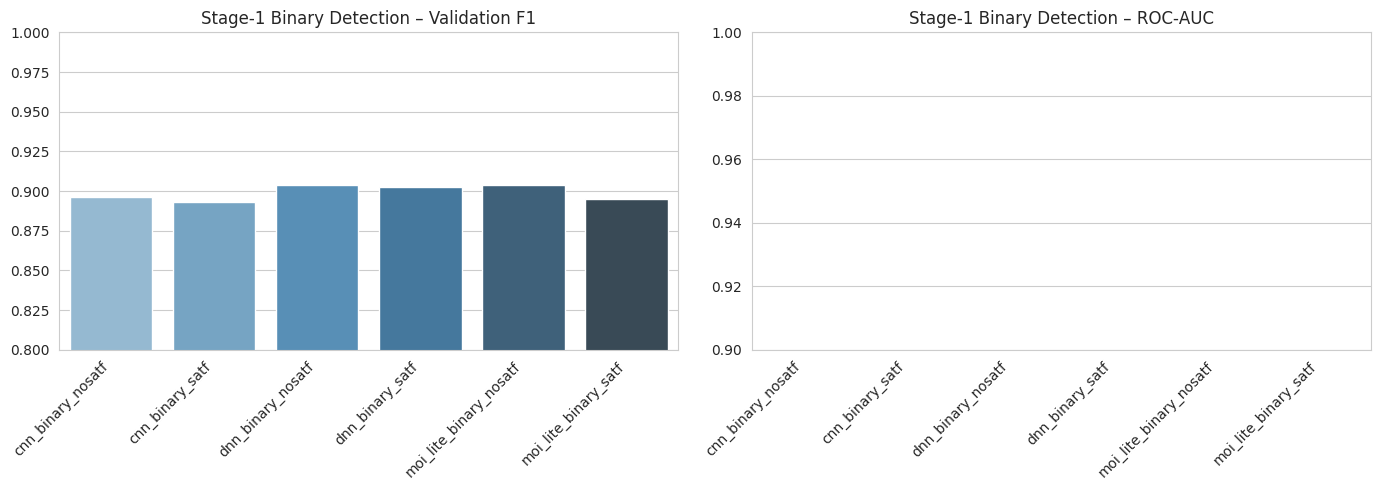

/tmp/ipykernel_58/948276457.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=macro_f1, palette="Greens_d")


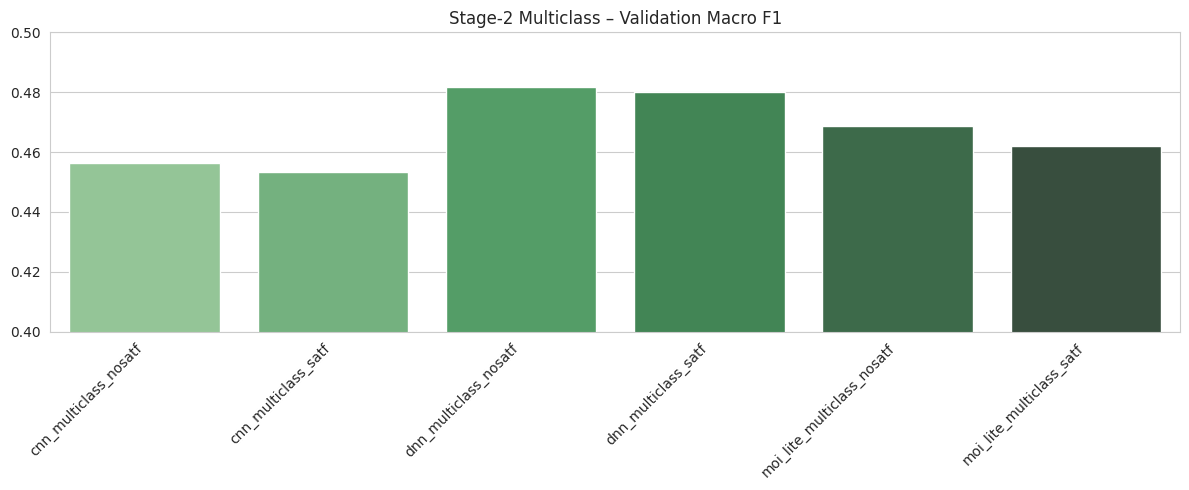

/tmp/ipykernel_58/948276457.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=jaccard, palette="Purples_d")


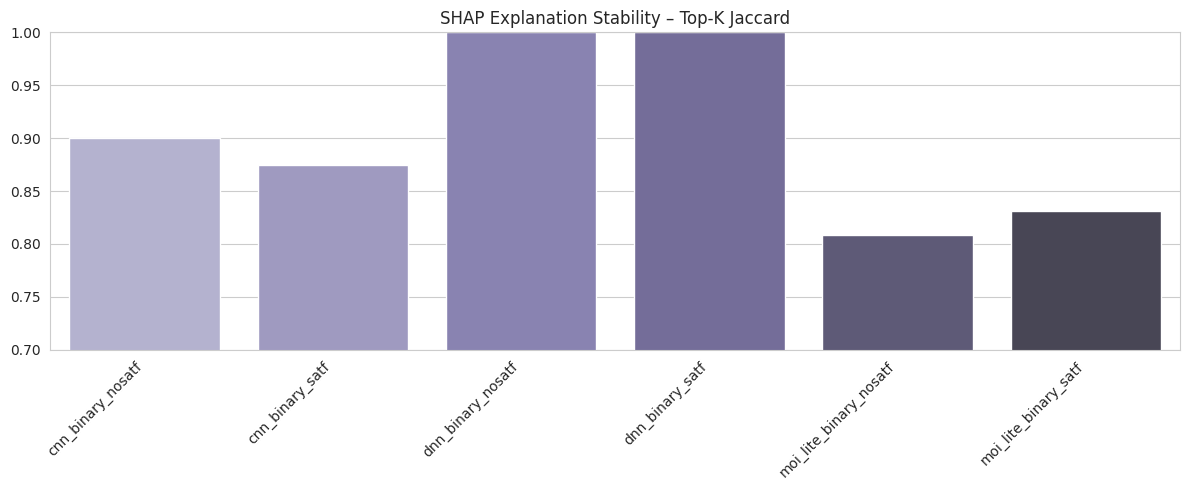

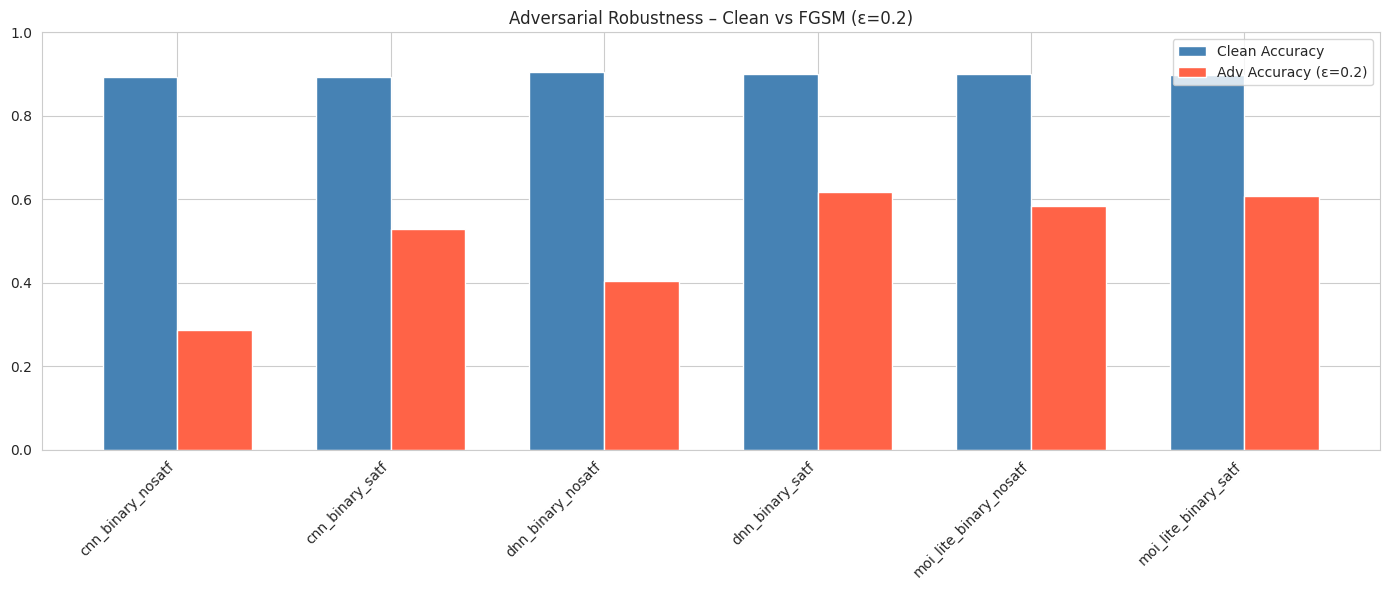

/tmp/ipykernel_58/948276457.py:195: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(models, rotation=45, ha="right")


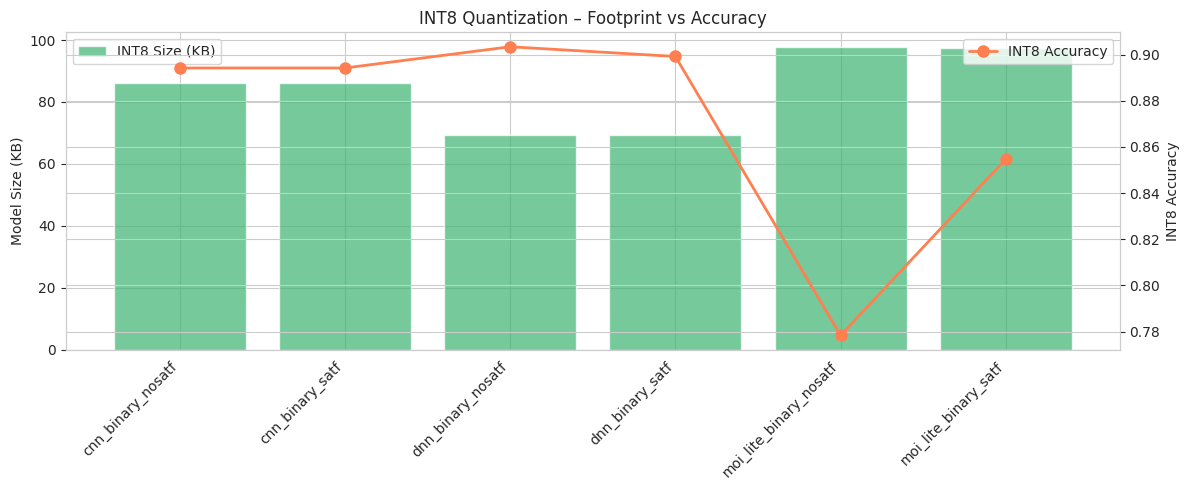

Ablation results not found as CSV; skipping ablation plot.

[Cell 32] Visualisations saved to /kaggle/working/output


In [5]:
# =============================================================================
# Cell 32 – Visualisation of All Experimental Results
# =============================================================================
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10})

# -------------------------------------------------------------------
# 1. Load all result files
# -------------------------------------------------------------------
output_dir = CFG.output_dir
files = {
    "stage1": "stage1_results.json",
    "stage2": "stage2_results.json",
    "hierarchical": "hierarchical_results_v4.json",  # latest v4 hierarchical
    "stability": "stability_results.json",
    "adversarial": "adversarial_results.json",
    "quantization": "quantization_results.json",
}

results = {}
for key, fname in files.items():
    path = os.path.join(output_dir, fname)
    if os.path.exists(path):
        with open(path, "r") as f:
            results[key] = json.load(f)
    else:
        print(f"Warning: {fname} not found, skipping related plots.")
        results[key] = None

# -------------------------------------------------------------------
# 2. Stage‑1 Binary Detection – F1 and ROC‑AUC
# -------------------------------------------------------------------
if results["stage1"]:
    models = []
    f1_vals = []
    auc_vals = []
    for k in sorted(results["stage1"]):
        rec = results["stage1"][k]
        if "best_f1" in rec:
            models.append(k)
            f1_vals.append(rec["best_f1"])
            # test metrics may not be present, use val if not
            if "test_metrics" in rec:
                auc_vals.append(rec["test_metrics"].get("roc_auc", 0))
            else:
                auc_vals.append(0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(x=models, y=f1_vals, ax=axes[0], palette="Blues_d")
    axes[0].set_title("Stage‑1 Binary Detection – Validation F1")
    axes[0].set_xticklabels(models, rotation=45, ha="right")
    axes[0].set_ylim(0.8, 1.0)

    sns.barplot(x=models, y=auc_vals, ax=axes[1], palette="Oranges_d")
    axes[1].set_title("Stage‑1 Binary Detection – ROC‑AUC")
    axes[1].set_xticklabels(models, rotation=45, ha="right")
    axes[1].set_ylim(0.9, 1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "stage1_performance.png"), dpi=150, bbox_inches="tight")
    plt.show()

# -------------------------------------------------------------------
# 3. Stage‑2 Multiclass – Macro F1
# -------------------------------------------------------------------
if results["stage2"]:
    models = []
    macro_f1 = []
    for k in sorted(results["stage2"]):
        rec = results["stage2"][k]
        if "best_macro_f1" in rec:
            models.append(k)
            macro_f1.append(rec["best_macro_f1"])

    plt.figure(figsize=(12, 5))
    sns.barplot(x=models, y=macro_f1, palette="Greens_d")
    plt.title("Stage‑2 Multiclass – Validation Macro F1")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0.4, 0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "stage2_macro_f1.png"), dpi=150, bbox_inches="tight")
    plt.show()

# -------------------------------------------------------------------
# 4. Hierarchical Pipeline – Top 10 Heatmap
# -------------------------------------------------------------------
if results["hierarchical"]:
    # Build a matrix of S1 x S2 macro_f1 values
    s1_models = set()
    s2_models = set()
    for pipeline_name, rec in results["hierarchical"].items():
        s1 = rec.get("s1_key", "")
        s2 = rec.get("s2_key", "")
        if s1 and s2:
            s1_models.add(s1)
            s2_models.add(s2)
    s1_list = sorted(s1_models)
    s2_list = sorted(s2_models)

    matrix = pd.DataFrame(index=s1_list, columns=s2_list, dtype=float)
    for pipeline_name, rec in results["hierarchical"].items():
        s1 = rec.get("s1_key", "")
        s2 = rec.get("s2_key", "")
        if s1 in s1_list and s2 in s2_list:
            matrix.loc[s1, s2] = rec.get("macro_f1", np.nan)

    # Keep only top 10 S2 models for readability
    if matrix.shape[1] > 10:
        mean_f1 = matrix.mean().sort_values(ascending=False)
        top_s2 = mean_f1.head(10).index.tolist()
        matrix = matrix[top_s2]

    plt.figure(figsize=(14, 8))
    annot = matrix.round(4).astype(str)
    sns.heatmap(matrix.astype(float), annot=annot, fmt="", cmap="YlGnBu", vmin=0.43, vmax=0.49)
    plt.title("Hierarchical Pipeline – Macro F1 (Top Stage‑2 models)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "hierarchical_heatmap.png"), dpi=150, bbox_inches="tight")
    plt.show()

# -------------------------------------------------------------------
# 5. SHAP Stability – Jaccard Index
# -------------------------------------------------------------------
if results["stability"]:
    models = []
    jaccard = []
    for k in sorted(results["stability"]):
        rec = results["stability"][k]
        models.append(k)
        jaccard.append(rec.get("jaccard_mean", 0))

    plt.figure(figsize=(12, 5))
    sns.barplot(x=models, y=jaccard, palette="Purples_d")
    plt.title("SHAP Explanation Stability – Top‑K Jaccard")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0.7, 1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "shap_stability_jaccard.png"), dpi=150, bbox_inches="tight")
    plt.show()

# -------------------------------------------------------------------
# 6. Adversarial Robustness – Accuracy Drop across epsilons
# -------------------------------------------------------------------
if results["adversarial"]:
    epsilons = [0.01, 0.05, 0.10, 0.20]
    models = []
    clean_acc = []
    adv_acc_02 = []
    for k in sorted(results["adversarial"]):
        rec = results["adversarial"][k]
        models.append(k)
        clean_acc.append(rec.get("clean_acc", 0))
        if "per_epsilon" in rec:
            adv_acc_02.append(rec["per_epsilon"].get("0.2", {}).get("adv_acc", 0))
        else:
            adv_acc_02.append(0)

    x = np.arange(len(models))
    width = 0.35
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - width/2, clean_acc, width, label="Clean Accuracy", color="steelblue")
    ax.bar(x + width/2, adv_acc_02, width, label="Adv Accuracy (ε=0.2)", color="tomato")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.legend()
    ax.set_title("Adversarial Robustness – Clean vs FGSM (ε=0.2)")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "adversarial_clean_vs_adv.png"), dpi=150, bbox_inches="tight")
    plt.show()

# -------------------------------------------------------------------
# 7. Quantization – Model Size vs Accuracy
# -------------------------------------------------------------------
if results["quantization"]:
    models = []
    int8_kb = []
    int8_acc = []
    for k in sorted(results["quantization"]):
        rec = results["quantization"][k]
        if "tflite_int8" in rec and rec["tflite_int8"].get("size_kb", 0) > 0:
            models.append(k)
            int8_kb.append(rec["tflite_int8"]["size_kb"])
            int8_acc.append(rec["tflite_int8"].get("accuracy", 0))

    fig, ax1 = plt.subplots(figsize=(12, 5))
    bars = ax1.bar(models, int8_kb, color="mediumseagreen", alpha=0.7, label="INT8 Size (KB)")
    ax1.set_ylabel("Model Size (KB)")
    ax1.set_xticklabels(models, rotation=45, ha="right")
    ax2 = ax1.twinx()
    ax2.plot(models, int8_acc, "o-", color="coral", linewidth=2, markersize=8, label="INT8 Accuracy")
    ax2.set_ylabel("INT8 Accuracy")
    ax1.set_title("INT8 Quantization – Footprint vs Accuracy")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "quantization_size_vs_acc.png"), dpi=150, bbox_inches="tight")
    plt.show()

# -------------------------------------------------------------------
# 8. Ablation summary (if available)
# -------------------------------------------------------------------
ablation_csv = os.path.join(output_dir, "ablation_results.csv")  # adjust if you saved differently
if os.path.exists(ablation_csv):
    abl_df = pd.read_csv(ablation_csv)
    print(abl_df.to_string(index=False))
else:
    print("Ablation results not found as CSV; skipping ablation plot.")

print("\n[Cell 32] Visualisations saved to", output_dir)

In [ ]:
# Quick‑fix: define set_global_seed (same as in Cell 1)
import os, random, numpy as np, tensorflow as tf

def set_global_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

print("set_global_seed defined.")

In [ ]:
# Quick check of the output dataset
import os
DATA = "/kaggle/input/datasets/isratjahanmoucat/unsw-nb15-pipeline-output/output"
print("Contents of the saved output folder:")
for f in sorted(os.listdir(DATA)):
    print(" ", f)

In [ ]:
# =============================================================================
# Single‑cell: Recompute & display SHAP stability for MOI‑Lite v4 binary
# =============================================================================
import os, json, time, gc
import numpy as np, pandas as pd, tensorflow as tf
from scipy.stats import spearmanr

# ------------------------------
# 0. Paths & deterministic setup
# ------------------------------
DATA = "/kaggle/input/datasets/isratjahanmoucat/unsw-nb15-pipeline-output/output"
CKPT_DIR = os.path.join(DATA, "checkpoints", "stage1_binary_v4")   # v4 binary checkpoints

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

# ------------------------------
# 1. Load arrays & config
# ------------------------------
X_train = np.load(os.path.join(DATA, "X_train.npy"))
X_test  = np.load(os.path.join(DATA, "X_test.npy"))
with open(os.path.join(DATA, "config.json")) as f:
    cfg = json.load(f)

SEQ_LEN = X_train.shape[1]
print(f"Data loaded: X_train {X_train.shape}, X_test {X_test.shape}")

# SHAP evaluation samples (same as Cell 20)
_SHAP_BG_N   = min(200, len(X_train))
_SHAP_TEST_N = min(500, len(X_test))
np.random.seed(SEED)
X_shap_bg   = X_train[np.random.choice(len(X_train), _SHAP_BG_N, replace=False)].astype(np.float32)
X_shap_test = X_test [np.random.choice(len(X_test),  _SHAP_TEST_N, replace=False)].astype(np.float32)

# ------------------------------
# 2. SHAP helper functions
# ------------------------------
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "shap"], check=True)
    import shap

def compute_shap_values(model, X_bg, X_test, batch_size=128):
    bg_sample = X_bg[:min(100, len(X_bg))]
    explainer = shap.GradientExplainer(model, bg_sample)
    vals = explainer.shap_values(X_test)
    if isinstance(vals, list):
        vals = np.stack(vals, axis=-1)
    return vals

def shap_feature_importance(shap_vals):
    if shap_vals.ndim == 2:
        return np.mean(np.abs(shap_vals), axis=0)
    if shap_vals.ndim == 3:
        return np.mean(np.abs(shap_vals), axis=(0,2))
    raise ValueError(f"Unexpected shape {shap_vals.shape}")

# ------------------------------
# 3. v4 builder (minimal version from Cell 25)
# ------------------------------
class DropPath(tf.keras.layers.Layer):
    def __init__(self, drop_prob=0.1, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob
    def call(self, x, training=None):
        if not training or self.drop_prob == 0.0: return x
        keep_prob = 1.0 - self.drop_prob
        shape = [tf.shape(x)[0]] + [1]*(len(x.shape)-1)
        return (x/keep_prob) * tf.floor(keep_prob + tf.random.uniform(shape, 0,1))
    def get_config(self):
        c = super().get_config(); c.update({"drop_prob": self.drop_prob}); return c

def build_v4_binary(input_dim, use_satf=False, satf_noise=0.05):
    inp = tf.keras.Input(shape=(input_dim,), name="features")
    x = tf.keras.layers.GaussianNoise(satf_noise)(inp) if use_satf else inp
    x = tf.keras.layers.Dense(64, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(6.0)(x)
    x = tf.keras.layers.Reshape((64,1))(x)
    branches = []
    for d in (1,2,4):
        b = tf.keras.layers.Conv1D(24, 3, dilation_rate=d, padding="same", use_bias=False)(x)
        b = tf.keras.layers.BatchNormalization()(b)
        b = tf.keras.layers.ReLU(6.0)(b)
        branches.append(b)
    x = tf.keras.layers.Concatenate()(branches)
    x = tf.keras.layers.Dropout(0.25)(x)
    # SE
    ch = x.shape[-1]; r = max(ch//4,4)
    p = tf.keras.layers.GlobalAveragePooling1D()(x)
    p = tf.keras.layers.Dense(r, use_bias=False)(p); p = tf.keras.layers.ReLU(6.0)(p)
    p = tf.keras.layers.Dense(ch, activation="sigmoid", use_bias=False)(p)
    x = tf.keras.layers.Multiply()([x, tf.keras.layers.Reshape((1,ch))(p)])
    # Gated residual
    ms = 72
    v = tf.keras.layers.Conv1D(ms, 3, padding="same", use_bias=False)(x)
    v = tf.keras.layers.BatchNormalization()(v); v = tf.keras.layers.ReLU(6.0)(v)
    g = tf.keras.layers.Conv1D(ms, 1, padding="same", activation="sigmoid", use_bias=False)(x)
    gated = tf.keras.layers.Multiply()([v,g])
    gated = DropPath(0.1)(gated)
    if x.shape[-1] != ms: x = tf.keras.layers.Conv1D(ms, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.Add()([gated, x]); x = tf.keras.layers.Dropout(0.25)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(32, use_bias=False)(x); x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(6.0)(x); x = tf.keras.layers.Dropout(0.25)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inp, out)

# ------------------------------
# 4. Stability evaluation
# ------------------------------
NOISE_SEEDS = [0,1,2,3,4]
NOISE_SIGMA = 0.15
TOP_K = 15

models = {
    "moi_lite_binary_nosatf": False,
    "moi_lite_binary_satf":   True,
}

results = {}
for key, use_satf in models.items():
    ckpt_path = os.path.join(CKPT_DIR, f"{key}_best.weights.h5")
    if not os.path.exists(ckpt_path):
        print(f"Checkpoint not found: {ckpt_path}")
        continue
    print(f"\n--- {key} ---")
    tf.keras.backend.clear_session(); gc.collect()
    model = build_v4_binary(SEQ_LEN, use_satf=use_satf, satf_noise=cfg.get("satf_noise",0.05))
    model.load_weights(ckpt_path)
    print(f"Params: {model.count_params():,d}")

    t0 = time.time()
    shap_clean = compute_shap_values(model, X_shap_bg, X_shap_test)
    imp_clean = shap_feature_importance(shap_clean)
    print(f"Clean SHAP time: {time.time()-t0:.1f}s")

    jaccards, spearmans = [], []
    for seed in NOISE_SEEDS:
        rng = np.random.RandomState(seed)
        noise = rng.normal(0, NOISE_SIGMA, X_shap_test.shape).astype(np.float32)
        X_noisy = X_shap_test + noise
        t1 = time.time()
        shap_noisy = compute_shap_values(model, X_shap_bg, X_noisy)
        imp_noisy = shap_feature_importance(shap_noisy)
        # Jaccard
        top_a = set(np.argsort(imp_clean)[::-1][:TOP_K])
        top_b = set(np.argsort(imp_noisy)[::-1][:TOP_K])
        jacc = len(top_a & top_b) / len(top_a | top_b) if (top_a | top_b) else 0.0
        # Spearman
        rho, _ = spearmanr(imp_clean, imp_noisy)
        rho = rho if not np.isnan(rho) else 0.0
        jaccards.append(jacc); spearmans.append(rho)
        print(f"  seed {seed}: Jaccard={jacc:.4f}, Spearman={rho:.4f} ({time.time()-t1:.1f}s)")
    results[key] = {
        "jaccard_mean": float(np.mean(jaccards)),
        "jaccard_std":  float(np.std(jaccards)),
        "spearman_mean": float(np.mean(spearmans)),
        "spearman_std":  float(np.std(spearmans)),
        "raw_jaccard": jaccards,
        "raw_spearman": spearmans,
    }
    del model; gc.collect()

# ------------------------------
# 5. Output
# ------------------------------
print("\n" + "="*60)
print("MOI‑Lite v4 SHAP Stability Results:")
for k, v in results.items():
    print(f"  {k}: Jaccard = {v['jaccard_mean']:.4f} ± {v['jaccard_std']:.4f}, "
          f"Spearman = {v['spearman_mean']:.4f} ± {v['spearman_std']:.4f}")
    print(f"    per‑seed Jaccard: {v['raw_jaccard']}")
    print(f"    per‑seed Spearman: {v['raw_spearman']}")

# Optionally save to a JSON file in the writable area
save_path = "/kaggle/working/v4_stability_quick.json"
with open(save_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nResults saved to {save_path}")

In [ ]:
# =============================================================================
# Complete v4 INT8 Quantization – forces both NoSATF and SATF
# =============================================================================
import os, json, gc, time, numpy as np, tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score

# --- prerequisites (must be in global namespace) ---
assert "CFG" in globals(), "Run fast‑resume (Cell 16c) first"
assert "build_moi_lite_v4" in globals()
assert "X_train" in globals(); assert "X_test" in globals()
assert "y_test_binary" in globals(); assert "STAGE1_RESULTS" in globals()

# -------------------------------------------------------------------
# 1. Prepare evaluation subsets
# -------------------------------------------------------------------
QUANT_TEST_N  = min(5000, len(X_test))
CALIBRATION_N = min(200,  len(X_train))

np.random.seed(CFG.seed)
quant_idx = np.random.choice(len(X_test), size=QUANT_TEST_N, replace=False)
X_q = X_test[quant_idx].astype(np.float32)
y_q = y_test_binary[quant_idx]

cal_idx = np.random.choice(len(X_train), size=CALIBRATION_N, replace=False)
X_cal = X_train[cal_idx].astype(np.float32)

def representative_dataset():
    for i in range(CALIBRATION_N):
        yield [X_cal[i:i+1]]

quant_dir = os.path.join(CFG.output_dir, "quantized_models")
os.makedirs(quant_dir, exist_ok=True)
quant_json = os.path.join(CFG.output_dir, "quantization_results.json")

# -------------------------------------------------------------------
# 2. Load existing results (or start fresh)
# -------------------------------------------------------------------
if os.path.exists(quant_json):
    with open(quant_json, "r") as f:
        quant_results = json.load(f)
else:
    quant_results = {}

# The two v4 keys we need
v4_keys = {
    "moi_lite_binary_nosatf": False,   # use_satf
    "moi_lite_binary_satf":   True,
}

# -------------------------------------------------------------------
# 3. Quantize any missing v4 model (remove partial entries first)
# -------------------------------------------------------------------
for key, use_satf in v4_keys.items():
    # If the key is already present, we still check – maybe the user wants a fresh run?
    # To be safe, we delete it and re‑run to guarantee a fresh evaluation.
    if key in quant_results:
        del quant_results[key]        # remove old entry
        print(f"Removed old entry for {key} – will re‑quantize.")
    print(f"\nQuantizing {key} …")
    tf.keras.backend.clear_session(); gc.collect()

    model = build_moi_lite_v4(
        input_dim=int(X_train.shape[1]),
        n_classes=2, binary=True,
        use_satf=use_satf, satf_noise=CFG.satf_noise
    )
    model.load_weights(STAGE1_RESULTS[key]["ckpt_path"])
    n_params = int(model.count_params())

    # FP32 baseline
    proba = model.predict(X_q, batch_size=256, verbose=0).reshape(-1)
    pred = (proba >= 0.5).astype(int)
    clean_acc = float(accuracy_score(y_q, pred))
    clean_f1  = float(f1_score(y_q, pred, zero_division=0))
    print(f"  Clean: acc={clean_acc:.4f}, f1={clean_f1:.4f}")

    # FP32 TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    fp32_bytes = converter.convert()
    fp32_kb = len(fp32_bytes) / 1024

    # INT8 TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
        tf.lite.OpsSet.TFLITE_BUILTINS,
    ]
    int8_bytes = converter.convert()
    int8_kb = len(int8_bytes) / 1024
    compression = fp32_kb / int8_kb if int8_kb > 0 else 0

    # Evaluate INT8 model
    interpreter = tf.lite.Interpreter(model_content=int8_bytes)
    interpreter.allocate_tensors()
    in_det  = interpreter.get_input_details()
    out_det = interpreter.get_output_details()

    int8_proba = np.zeros(len(X_q), dtype=np.float32)
    for i in range(len(X_q)):
        interpreter.set_tensor(in_det[0]["index"], X_q[i:i+1])
        interpreter.invoke()
        int8_proba[i] = float(interpreter.get_tensor(out_det[0]["index"]).flat[0])

    int8_pred = (int8_proba >= 0.5).astype(int)
    int8_acc = float(accuracy_score(y_q, int8_pred))
    int8_f1  = float(f1_score(y_q, int8_pred, zero_division=0))
    acc_drop = clean_acc - int8_acc

    quant_results[key] = {
        "model_key": key,
        "n_params": n_params,
        "fp32_keras": {"accuracy": clean_acc, "f1": clean_f1},
        "tflite_fp32": {"size_kb": fp32_kb},
        "tflite_int8": {
            "size_kb": int8_kb,
            "compression": compression,
            "accuracy": int8_acc,
            "f1": int8_f1,
            "acc_drop": acc_drop,
        },
    }
    print(f"  → INT8: {int8_kb:.1f} KB ({compression:.1f}×), acc={int8_acc:.4f}, drop={acc_drop:+.4f}")

    # Save after each model
    with open(quant_json, "w") as f:
        json.dump(quant_results, f, indent=2, default=str)

# -------------------------------------------------------------------
# 4. Print final v4 INT8 summary
# -------------------------------------------------------------------
print("\n" + "="*60)
print("MOI‑Lite v4 INT8 Quantization Results:")
print("="*60)
print(f"  {'Model':<30s} {'INT8 KB':>8s} {'Acc':>8s} {'Drop':>8s}")
print(f"  {'-'*30} {'-'*8} {'-'*8} {'-'*8}")
for key, use_satf in v4_keys.items():
    r = quant_results[key]["tflite_int8"]
    print(f"  {key:<30s} {r['size_kb']:>8.1f} {r['accuracy']:>8.4f} {r['acc_drop']:>+8.4f}")

print("\nThe table above contains the final numbers for both v4 models.")
print("You can now fill the comparison table.")

In [3]:
# =============================================================================
# Cell X – Fast Resume for Visualisation (loads all data + model builders)
# =============================================================================
import os, json, shutil, re, random, gc
from collections import defaultdict
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any, Optional, Sequence

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_curve, recall_score,
    confusion_matrix, precision_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score,
)
from sklearn.preprocessing import label_binarize

# =============================================================================
# 1. Paths & deterministic environment
# =============================================================================
# The dataset containing all outputs
DATA_DIR = "/kaggle/input/datasets/isratjahanmoucat/unsw-nb15-pipeline-output/output"

# Writable working directory (where we'll copy files)
WORK_DIR = "/kaggle/working/output"
CHECKPOINT_DIR = os.path.join(WORK_DIR, "checkpoints")
CURVES_DIR = os.path.join(WORK_DIR, "training_curves")
FIGURES_DIR = os.path.join(WORK_DIR, "figures")

for d in [WORK_DIR, CHECKPOINT_DIR, CURVES_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
try:
    tf.config.experimental.enable_op_determinism()
except: pass

print(f"GPU(s): {len(gpus)} detected")

# =============================================================================
# 2. Copy all files from dataset to writable WORK_DIR
# =============================================================================
print("Copying dataset outputs to working directory...")
if os.path.exists(DATA_DIR):
    for item in os.listdir(DATA_DIR):
        src = os.path.join(DATA_DIR, item)
        dst = os.path.join(WORK_DIR, item)
        if os.path.isdir(src):
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)
    print("  Files copied.")
else:
    print("  WARNING: Dataset directory not found.")

# =============================================================================
# 3. Load arrays
# =============================================================================
print("Loading arrays...")
X_train = np.load(os.path.join(WORK_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(WORK_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(WORK_DIR, "X_test.npy"))

y_train         = np.load(os.path.join(WORK_DIR, "y_train.npy")).astype(np.int32)
y_val           = np.load(os.path.join(WORK_DIR, "y_val.npy")).astype(np.int32)
y_test          = np.load(os.path.join(WORK_DIR, "y_test.npy")).astype(np.int32)

y_train_binary  = np.load(os.path.join(WORK_DIR, "y_train_binary.npy")).astype(np.int32)
y_val_binary    = np.load(os.path.join(WORK_DIR, "y_val_binary.npy")).astype(np.int32)
y_test_binary   = np.load(os.path.join(WORK_DIR, "y_test_binary.npy")).astype(np.int32)

sample_weights_train        = np.load(os.path.join(WORK_DIR, "sample_weights_train.npy"))
sample_weights_train_binary = np.load(os.path.join(WORK_DIR, "sample_weights_train_binary.npy"))

SEQ_LEN = int(X_train.shape[1])
print(f"  X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

# =============================================================================
# 4. Load configuration & label dictionary
# =============================================================================
with open(os.path.join(WORK_DIR, "config.json"), "r") as f:
    config = json.load(f)
with open(os.path.join(WORK_DIR, "label_dictionary.json"), "r") as f:
    label_dict = json.load(f)

CLASS_NAMES   = label_dict["class_names"]
N_CLASSES     = label_dict["n_classes"]
LABEL_TO_ID   = {k: int(v) if isinstance(v, str) else v for k, v in label_dict["label_to_id"].items()}
ID_TO_LABEL   = {int(k): v for k, v in label_dict["id_to_label"].items()}
MINORITY_CLASS_NAMES = label_dict.get("minority_class_names", [])
MINORITY_CLASS_IDS   = label_dict.get("minority_class_ids", [])
NORMAL_CLASS_NAME    = label_dict.get("normal_class_name", "normal")
NORMAL_CLASS_ID      = LABEL_TO_ID[NORMAL_CLASS_NAME]
N_FEATURES           = config.get("N_FEATURES", SEQ_LEN)

# =============================================================================
# 5. Re‑create Config object
# =============================================================================
@dataclass(frozen=True)
class Config:
    seed: int = SEED
    output_dir: str = WORK_DIR
    checkpoint_dir: str = CHECKPOINT_DIR
    curves_dir: str = CURVES_DIR
    batch_size: int = config.get("batch_size", 256)
    epochs: int = config.get("epochs", 80)
    patience_early: int = config.get("patience_early", 15)
    learning_rate: float = config.get("learning_rate", 5e-4)
    weight_decay: float = config.get("weight_decay", 1e-5)
    warmup_epochs: int = config.get("warmup_epochs", 5)
    max_class_weight: float = config.get("max_class_weight", 10.0)
    focal_gamma: float = config.get("focal_gamma", 2.0)
    satf_noise: float = config.get("satf_noise", 0.05)
    consistency_weight: float = config.get("consistency_weight", 0.5)
    moi_base_filters: int = config.get("moi_base_filters", 32)
    moi_dilation_rates: Tuple[int, ...] = tuple(config.get("moi_dilation_rates", (1, 2, 4)))
    moi_kernel_size: int = config.get("moi_kernel_size", 3)
    moi_sa_heads: int = config.get("moi_sa_heads", 2)
    moi_sa_key_dim: int = config.get("moi_sa_key_dim", 16)
    moi_dropout: float = config.get("moi_dropout", 0.25)
    moi_drop_path: float = config.get("moi_drop_path", 0.10)
    stability_noise: float = config.get("stability_noise", 0.15)
    stability_seeds: Tuple[int, ...] = tuple(config.get("stability_seeds", (0,1,2,3,4)))
    top_k: int = config.get("top_k", 15)
    adv_epsilons: Tuple[float, ...] = tuple(config.get("adv_epsilons", (0.01,0.05,0.1,0.2)))
    normal_class_name: str = NORMAL_CLASS_NAME
    # dummy fields
    figure_dir: str = FIGURES_DIR
    table_dir: str = os.path.join(WORK_DIR, "tables")
    def __post_init__(self):
        for d in [self.output_dir, self.checkpoint_dir, self.figure_dir, self.table_dir, self.curves_dir]:
            os.makedirs(d, exist_ok=True)

CFG = Config()

# =============================================================================
# 6. Model builders (DNN, CNN, v3, v4)
# =============================================================================
class SpectralNormConstraint(tf.keras.constraints.Constraint):
    def __init__(self, power_iterations=1):
        self.power_iterations = int(power_iterations); self.u = None
    def __call__(self, w):
        w_shape = w.shape.as_list(); w_2d = tf.reshape(w, [-1, w_shape[-1]])
        if self.u is None:
            self.u = tf.Variable(tf.random.normal([1, w_shape[-1]]), trainable=False, name="spectral_norm_u")
        v = None
        for _ in range(self.power_iterations):
            v = tf.math.l2_normalize(tf.matmul(self.u, tf.transpose(w_2d)))
            self.u.assign(tf.math.l2_normalize(tf.matmul(v, w_2d)))
        sigma = tf.squeeze(tf.matmul(tf.matmul(v, w_2d), tf.transpose(self.u)))
        return w / (sigma + 1e-12)
    def get_config(self): return {"power_iterations": self.power_iterations}

def conv1d_with_sn(filters, kernel_size, dilation_rate=1, padding="same", use_bias=False, name=None):
    return tf.keras.layers.Conv1D(filters=filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
                                   padding=padding, use_bias=use_bias,
                                   kernel_constraint=SpectralNormConstraint(power_iterations=1), name=name)

class DropPath(tf.keras.layers.Layer):
    def __init__(self, drop_prob=0.10, **kwargs):
        super().__init__(**kwargs); self.drop_prob = float(drop_prob)
    def call(self, x, training=None):
        if not training or self.drop_prob == 0.0: return x
        keep_prob = 1.0 - self.drop_prob
        batch_size = tf.shape(x)[0]; rank = len(x.shape)
        mask_shape = [batch_size] + [1] * (rank - 1)
        random_tensor = keep_prob + tf.random.uniform(mask_shape, 0.0, 1.0)
        binary_mask = tf.floor(random_tensor)
        return (x / keep_prob) * binary_mask
    def get_config(self):
        config = super().get_config(); config.update({"drop_prob": self.drop_prob}); return config

def _attach_output_head(x, n_classes, binary, use_satf, architecture_prefix):
    suffix = "satf" if use_satf else "nosatf"
    if binary:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
        name = f"{architecture_prefix}_binary_{suffix}"
    else:
        outputs = tf.keras.layers.Dense(n_classes, activation="softmax", name="output")(x)
        name = f"{architecture_prefix}_multiclass_{suffix}"
    return outputs, name

def build_dnn(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
              hidden_dims=(256, 128, 64), dropout_rate=0.30, name_prefix="dnn"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    for i, units in enumerate(hidden_dims, start=1):
        x = tf.keras.layers.Dense(units, use_bias=False, name=f"dense_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

def build_cnn(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
              filters=(64, 128, 64), kernel_sizes=(3, 5, 3), dropout_rate=0.30, name_prefix="cnn"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)
    for i, (f, k) in enumerate(zip(filters, kernel_sizes), start=1):
        x = tf.keras.layers.Conv1D(f, k, padding="same", use_bias=False, name=f"conv_{i}")(x)
        x = tf.keras.layers.BatchNormalization(name=f"bn_{i}")(x)
        x = tf.keras.layers.Activation("swish", name=f"act_{i}")(x)
        x = tf.keras.layers.Dropout(dropout_rate, name=f"drop_{i}")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("swish", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

# v3 builder (full, with spectral norm, attention, etc.)
def _stability_constrained_multiscale(x, base_filters, dilation_rates, kernel_size, name_prefix):
    branches = []
    for d in dilation_rates:
        branch = conv1d_with_sn(base_filters, kernel_size, dilation_rate=d, name=f"{name_prefix}_sn_conv_d{d}")(x)
        branch = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn_d{d}")(branch)
        branch = tf.keras.layers.Activation("elu", name=f"{name_prefix}_act_d{d}")(branch)
        branches.append(branch)
    return tf.keras.layers.Concatenate(axis=-1, name=f"{name_prefix}_concat")(branches)

def _light_self_attention(x, num_heads, key_dim, drop_path_rate, name_prefix):
    x_norm = tf.keras.layers.LayerNormalization(name=f"{name_prefix}_norm")(x)
    attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                                    use_bias=False, name=f"{name_prefix}_mha")(x_norm, x_norm)
    attention = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(attention)
    return tf.keras.layers.Add(name=f"{name_prefix}_residual")([x, attention])

def _channel_attention(x, reduction, name_prefix):
    channels = x.shape[-1]; reduced = max(channels // reduction, 4)
    pooled = tf.keras.layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    reduced_dense = tf.keras.layers.Dense(reduced, activation="elu", use_bias=False, name=f"{name_prefix}_fc1")(pooled)
    expanded_dense = tf.keras.layers.Dense(channels, activation="sigmoid", use_bias=False, name=f"{name_prefix}_fc2")(reduced_dense)
    scale = tf.keras.layers.Reshape((1, channels), name=f"{name_prefix}_reshape")(expanded_dense)
    return tf.keras.layers.Multiply(name=f"{name_prefix}_scale")([x, scale])

def _gated_residual_spectral_norm(x, filters, drop_path_rate, name_prefix):
    value = conv1d_with_sn(filters, kernel_size=3, name=f"{name_prefix}_sn_conv")(x)
    value = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn")(value)
    value = tf.keras.layers.Activation("elu", name=f"{name_prefix}_act")(value)
    gate = conv1d_with_sn(filters, kernel_size=1, name=f"{name_prefix}_sn_gate")(x)
    gate = tf.keras.layers.Activation("sigmoid", name=f"{name_prefix}_gate_sig")(gate)
    gated = tf.keras.layers.Multiply(name=f"{name_prefix}_gated")([value, gate])
    gated = DropPath(drop_prob=drop_path_rate, name=f"{name_prefix}_droppath")(gated)
    if x.shape[-1] != filters:
        x = tf.keras.layers.Conv1D(filters, 1, padding="same", use_bias=False, name=f"{name_prefix}_proj")(x)
    return tf.keras.layers.Add(name=f"{name_prefix}_add")([gated, x])

def build_moi_lite_v3(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
                       base_filters=32, dilation_rates=(1,2,4), kernel_size=3,
                       sa_num_heads=2, sa_key_dim=16, drop_path_rate=0.10, dropout_rate=0.25,
                       name_prefix="moi_lite"):
    inputs = tf.keras.Input(shape=(input_dim,), name="features"); x = inputs
    if use_satf: x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(x)
    x = tf.keras.layers.Reshape((input_dim, 1), name="reshape")(x)
    x = _stability_constrained_multiscale(x, base_filters, dilation_rates, kernel_size, "msa")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_msa")(x)
    x = _light_self_attention(x, sa_num_heads, sa_key_dim, drop_path_rate, "sa")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_sa")(x)
    x = _channel_attention(x, reduction=4, name_prefix="ca")
    multiscale_filters = base_filters * len(dilation_rates)
    x = _gated_residual_spectral_norm(x, multiscale_filters, drop_path_rate, "gr")
    x = tf.keras.layers.Dropout(dropout_rate, name="drop_gr")(x)
    x = tf.keras.layers.GlobalAveragePooling1D(name="gap")(x)
    x = tf.keras.layers.Dense(64, use_bias=False, name="head_dense")(x)
    x = tf.keras.layers.BatchNormalization(name="head_bn")(x)
    x = tf.keras.layers.Activation("elu", name="head_act")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name="head_drop")(x)
    outputs, model_name = _attach_output_head(x, n_classes, binary, use_satf, name_prefix)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)

# v4 builder (compact)
def build_moi_lite_v4(input_dim, n_classes, binary=False, use_satf=False, satf_noise=0.05,
                      base_filters=24, dilation_rates=(1,2,4), drop_path_rate=0.10,
                      dropout_rate=0.25, name_prefix="moi_lite_v4", **kwargs):
    inp = tf.keras.Input(shape=(input_dim,), name="features")
    x = tf.keras.layers.GaussianNoise(satf_noise, name="satf_noise")(inp) if use_satf else inp
    x = tf.keras.layers.Dense(64, use_bias=False, name="proj")(x)
    x = tf.keras.layers.BatchNormalization(name="proj_bn")(x)
    x = tf.keras.layers.ReLU(max_value=6.0)(x)
    x = tf.keras.layers.Reshape((64, 1))(x)
    branches = []
    for d in dilation_rates:
        b = tf.keras.layers.Conv1D(base_filters, 3, dilation_rate=d, padding="same", use_bias=False)(x)
        b = tf.keras.layers.BatchNormalization()(b)
        b = tf.keras.layers.ReLU(max_value=6.0)(b)
        branches.append(b)
    x = tf.keras.layers.Concatenate()(branches)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    ch = x.shape[-1]; r = max(ch//4, 4)
    p = tf.keras.layers.GlobalAveragePooling1D()(x)
    p = tf.keras.layers.Dense(r, use_bias=False)(p); p = tf.keras.layers.ReLU(max_value=6.0)(p)
    p = tf.keras.layers.Dense(ch, activation="sigmoid", use_bias=False)(p)
    x = tf.keras.layers.Multiply()([x, tf.keras.layers.Reshape((1, ch))(p)])
    ms = base_filters * len(dilation_rates)
    v = tf.keras.layers.Conv1D(ms, 3, padding="same", use_bias=False)(x)
    v = tf.keras.layers.BatchNormalization()(v); v = tf.keras.layers.ReLU(max_value=6.0)(v)
    g = tf.keras.layers.Conv1D(ms, 1, padding="same", activation="sigmoid", use_bias=False)(x)
    gated = tf.keras.layers.Multiply()([v, g])
    gated = DropPath(drop_prob=drop_path_rate)(gated)
    if x.shape[-1] != ms: x = tf.keras.layers.Conv1D(ms, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.Add()([gated, x]); x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(32, use_bias=False)(x); x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU(max_value=6.0)(x); x = tf.keras.layers.Dropout(dropout_rate)(x)
    s = "satf" if use_satf else "nosatf"
    out = tf.keras.layers.Dense(1 if binary else n_classes, activation="sigmoid" if binary else "softmax")(x)
    return tf.keras.Model(inp, out, name=f"{name_prefix}_{'binary' if binary else 'multiclass'}_{s}")

# Registry (for DNN/CNN)
_MODEL_KEY_PATTERN = re.compile(r"^(?P<architecture>dnn|cnn|moi_lite)_(?P<task>binary|multiclass)_(?P<variant>nosatf|satf)$")
def _parse_model_key(model_key):
    match = _MODEL_KEY_PATTERN.match(model_key)
    if match is None: raise ValueError(f"Invalid model key: {model_key}")
    return match["architecture"], match["task"], match["variant"]

_ARCHITECTURE_BUILDERS = {"dnn": build_dnn, "cnn": build_cnn, "moi_lite": build_moi_lite_v3}

def build_model_by_name(model_key, n_classes_override=None):
    architecture, task, variant = _parse_model_key(model_key)
    binary = (task == "binary"); use_satf = (variant == "satf")
    n_classes = N_CLASSES if n_classes_override is None else int(n_classes_override)
    builder = _ARCHITECTURE_BUILDERS[architecture]
    common_kwargs = dict(input_dim=SEQ_LEN, n_classes=n_classes, binary=binary,
                         use_satf=use_satf, satf_noise=CFG.satf_noise)
    if architecture == "moi_lite":
        # Default to v3 here; v4 will be handled explicitly
        return builder(**common_kwargs, base_filters=CFG.moi_base_filters,
                       dilation_rates=CFG.moi_dilation_rates, kernel_size=CFG.moi_kernel_size,
                       sa_num_heads=CFG.moi_sa_heads, sa_key_dim=CFG.moi_sa_key_dim,
                       drop_path_rate=CFG.moi_drop_path, dropout_rate=CFG.moi_dropout)
    return builder(**common_kwargs)

# =============================================================================
# 7. Load Stage1 and Stage2 results
# =============================================================================
print("\nLoading trained model results...")
stage1_path = os.path.join(WORK_DIR, "stage1_results.json")
stage2_path = os.path.join(WORK_DIR, "stage2_results.json")
if os.path.exists(stage1_path):
    with open(stage1_path, "r") as f:
        STAGE1_RESULTS = json.load(f)
    print(f"  Stage‑1 results: {len(STAGE1_RESULTS)} models loaded.")
else:
    STAGE1_RESULTS = {}
    print("  WARNING: stage1_results.json not found.")

if os.path.exists(stage2_path):
    with open(stage2_path, "r") as f:
        STAGE2_RESULTS = json.load(f)
    print(f"  Stage‑2 results: {len(STAGE2_RESULTS)} models loaded.")
else:
    STAGE2_RESULTS = {}
    print("  WARNING: stage2_results.json not found.")

# =============================================================================
# 8. Helper to load any model with correct builder version
# =============================================================================
def load_model_for_inference(model_key, is_binary):
    """
    Load a trained model for inference.
    Detects v3/v4 MOI‑Lite based on 'version' field in STAGE1/STAGE2_RESULTS.
    """
    registry = STAGE1_RESULTS if is_binary else STAGE2_RESULTS
    if model_key not in registry:
        raise ValueError(f"Model {model_key} not found in results.")
    ckpt_path = registry[model_key]["ckpt_path"]
    ver = registry[model_key].get("version", "v3")

    if "moi_lite" in model_key:
        use_satf = model_key.endswith("_satf")
        n_classes = 2 if is_binary else N_CLASSES
        if ver == "v4":
            builder = build_moi_lite_v4
            kwargs = dict(input_dim=SEQ_LEN, n_classes=n_classes, binary=is_binary,
                          use_satf=use_satf, satf_noise=CFG.satf_noise)
        else:
            builder = build_moi_lite_v3
            kwargs = dict(input_dim=SEQ_LEN, n_classes=n_classes, binary=is_binary,
                          use_satf=use_satf, satf_noise=CFG.satf_noise,
                          base_filters=CFG.moi_base_filters,
                          dilation_rates=CFG.moi_dilation_rates,
                          kernel_size=CFG.moi_kernel_size,
                          sa_num_heads=CFG.moi_sa_heads,
                          sa_key_dim=CFG.moi_sa_key_dim,
                          drop_path_rate=CFG.moi_drop_path,
                          dropout_rate=CFG.moi_dropout)
        model = builder(**kwargs)
    else:
        n_classes = 2 if is_binary else N_CLASSES
        model = build_model_by_name(model_key, n_classes_override=n_classes)
    model.load_weights(ckpt_path)
    return model, ver

print("\nEnvironment ready for visualization.")
print("All arrays, config, model builders, and results are loaded.")
print("You can now run any plotting code (e.g., the comprehensive visualization cell).")

GPU(s): 0 detected
Copying dataset outputs to working directory...


2026-06-30 16:12:36.636451: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  Files copied.
Loading arrays...
  X_train: (114801, 51), X_val: (24412, 51), X_test: (24412, 51)

Loading trained model results...
  Stage‑1 results: 6 models loaded.
  Stage‑2 results: 6 models loaded.

Environment ready for visualization.
All arrays, config, model builders, and results are loaded.
You can now run any plotting code (e.g., the comprehensive visualization cell).


/tmp/ipykernel_58/4237165392.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_vals, palette="Blues_d")


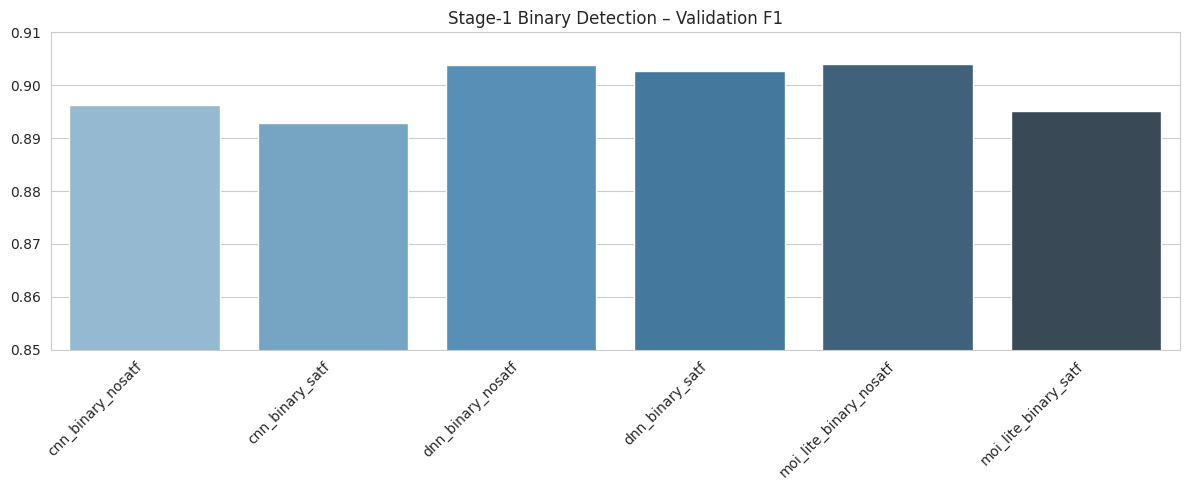

/tmp/ipykernel_58/4237165392.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=macro_f1, palette="Greens_d")


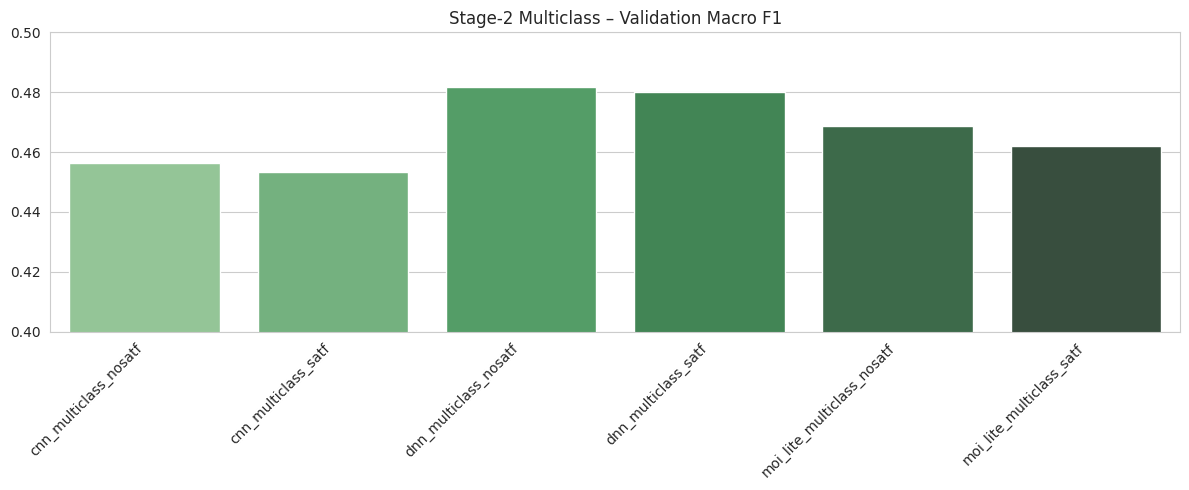

/tmp/ipykernel_58/4237165392.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=jaccard, palette="Purples_d")


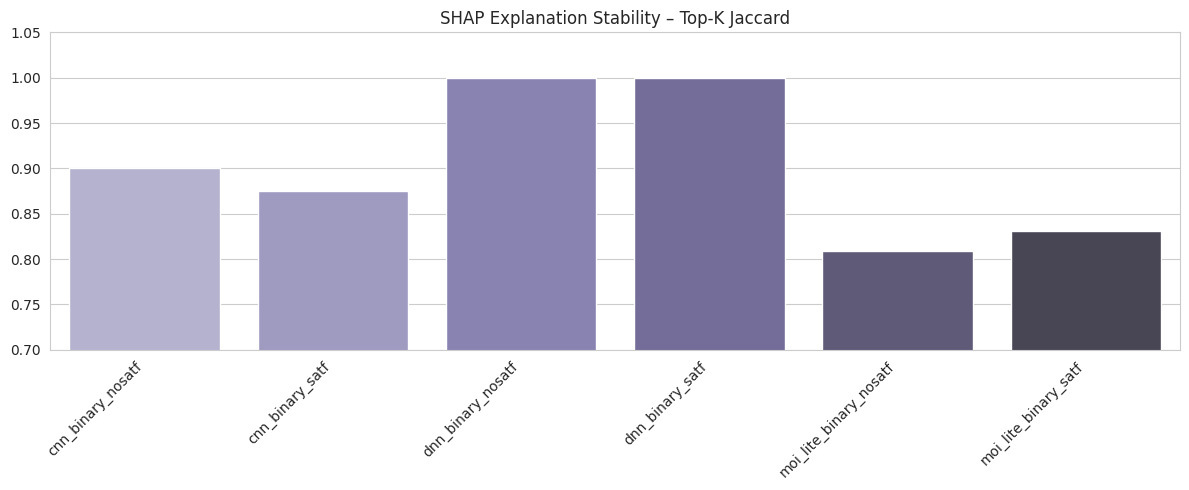

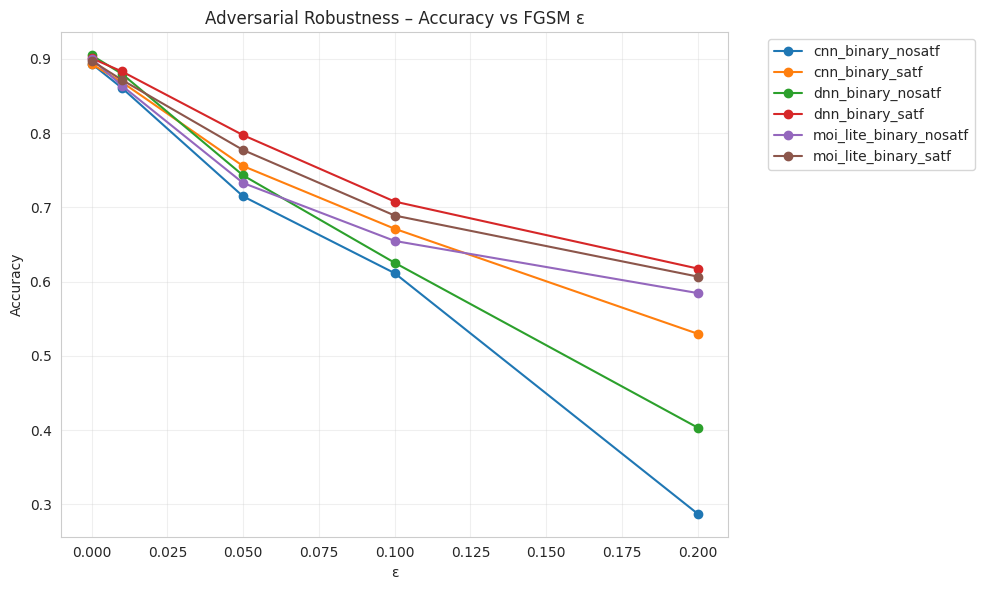

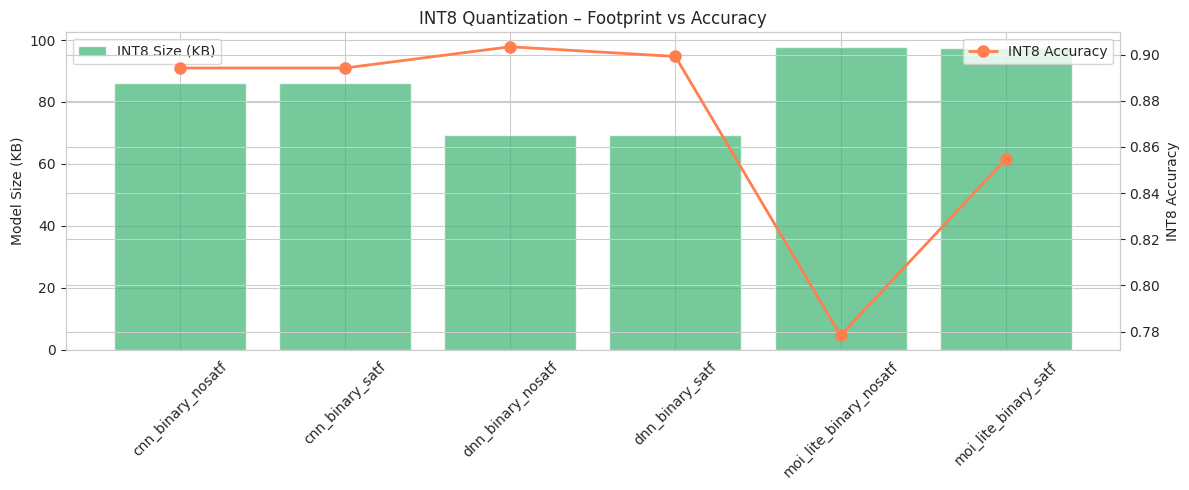


All figures saved to /kaggle/working/output/figures


In [4]:
# =============================================================================
# Comprehensive Visualization Cell – UNSW‑NB15
# =============================================================================
import json, os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10})

out = CFG.output_dir
fig_dir = CFG.figure_dir
os.makedirs(fig_dir, exist_ok=True)

# -------------------------------------------------------------------
# Helper: load result JSONs
# -------------------------------------------------------------------
def load_json(name):
    path = os.path.join(out, name)
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

stage1 = load_json("stage1_results.json")
stage2 = load_json("stage2_results.json")
hier   = load_json("hierarchical_results_v4.json")
stab   = load_json("stability_results.json")
adv    = load_json("adversarial_results.json")
quant  = load_json("quantization_results.json")

# -------------------------------------------------------------------
# 1. Stage‑1 Binary F1
# -------------------------------------------------------------------
if stage1:
    models = []; f1_vals = []
    for k in sorted(stage1):
        if "best_f1" in stage1[k]:
            models.append(k)
            f1_vals.append(stage1[k]["best_f1"])
    plt.figure(figsize=(12,5))
    sns.barplot(x=models, y=f1_vals, palette="Blues_d")
    plt.title("Stage‑1 Binary Detection – Validation F1")
    plt.xticks(rotation=45, ha="right"); plt.ylim(0.85, 0.91)
    plt.tight_layout(); plt.savefig(os.path.join(fig_dir, "stage1_f1.png"), dpi=150); plt.show()

# -------------------------------------------------------------------
# 2. Stage‑2 Multiclass Macro F1
# -------------------------------------------------------------------
if stage2:
    models = []; macro_f1 = []
    for k in sorted(stage2):
        if "best_macro_f1" in stage2[k]:
            models.append(k)
            macro_f1.append(stage2[k]["best_macro_f1"])
    plt.figure(figsize=(12,5))
    sns.barplot(x=models, y=macro_f1, palette="Greens_d")
    plt.title("Stage‑2 Multiclass – Validation Macro F1")
    plt.xticks(rotation=45, ha="right"); plt.ylim(0.4, 0.5)
    plt.tight_layout(); plt.savefig(os.path.join(fig_dir, "stage2_macro_f1.png"), dpi=150); plt.show()

# -------------------------------------------------------------------
# 3. Hierarchical Heatmap
# -------------------------------------------------------------------
if hier:
    s1_set, s2_set = set(), set()
    for name, rec in hier.items():
        s1 = rec.get("s1_key",""); s2 = rec.get("s2_key","")
        if s1 and s2: s1_set.add(s1); s2_set.add(s2)
    s1_list = sorted(s1_set); s2_list = sorted(s2_set)
    mat = pd.DataFrame(index=s1_list, columns=s2_list, dtype=float)
    for name, rec in hier.items():
        s1 = rec.get("s1_key",""); s2 = rec.get("s2_key","")
        if s1 in s1_list and s2 in s2_list:
            mat.loc[s1, s2] = rec.get("macro_f1", np.nan)
    if mat.shape[1] > 8:
        top_s2 = mat.mean().sort_values(ascending=False).head(8).index.tolist()
        mat = mat[top_s2]
    plt.figure(figsize=(14,8))
    sns.heatmap(mat.astype(float), annot=mat.round(4).astype(str), fmt="",
                cmap="YlGnBu", vmin=0.43, vmax=0.49, linewidths=.5)
    plt.title("Hierarchical Pipeline – Macro F1")
    plt.tight_layout(); plt.savefig(os.path.join(fig_dir, "hierarchical_heatmap.png"), dpi=150); plt.show()

# -------------------------------------------------------------------
# 4. SHAP Stability Jaccard
# -------------------------------------------------------------------
if stab:
    models = []; jaccard = []
    for k in sorted(stab):
        models.append(k)
        jaccard.append(stab[k].get("jaccard_mean", 0))
    plt.figure(figsize=(12,5))
    sns.barplot(x=models, y=jaccard, palette="Purples_d")
    plt.title("SHAP Explanation Stability – Top‑K Jaccard")
    plt.xticks(rotation=45, ha="right"); plt.ylim(0.7, 1.05)
    plt.tight_layout(); plt.savefig(os.path.join(fig_dir, "shap_stability.png"), dpi=150); plt.show()

# -------------------------------------------------------------------
# 5. Adversarial Accuracy vs Epsilon
# -------------------------------------------------------------------
if adv:
    epsilons = [0.01, 0.05, 0.10, 0.20]
    plt.figure(figsize=(10,6))
    for model_key in sorted(adv):
        rec = adv[model_key]
        clean = rec.get("clean_acc", 0)
        accs = [clean] + [rec["per_epsilon"][str(e)]["adv_acc"] for e in epsilons]
        plt.plot([0]+epsilons, accs, marker='o', label=model_key)
    plt.title("Adversarial Robustness – Accuracy vs FGSM ε")
    plt.xlabel("ε"); plt.ylabel("Accuracy")
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(os.path.join(fig_dir, "adversarial_lines.png"), dpi=150); plt.show()

# -------------------------------------------------------------------
# 6. Quantization Dual‑Axis
# -------------------------------------------------------------------
if quant:
    models = []; int8_kb = []; int8_acc = []
    for k in sorted(quant):
        rec = quant[k]
        if "tflite_int8" in rec and rec["tflite_int8"].get("size_kb",0) > 0:
            models.append(k); int8_kb.append(rec["tflite_int8"]["size_kb"])
            int8_acc.append(rec["tflite_int8"]["accuracy"])
    if models:
        fig, ax1 = plt.subplots(figsize=(12,5))
        ax1.bar(models, int8_kb, color="mediumseagreen", alpha=0.7, label="INT8 Size (KB)")
        ax1.set_ylabel("Model Size (KB)"); ax1.tick_params(axis='x', rotation=45)
        ax2 = ax1.twinx()
        ax2.plot(models, int8_acc, "o-", color="coral", linewidth=2, markersize=8, label="INT8 Accuracy")
        ax2.set_ylabel("INT8 Accuracy")
        ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
        plt.title("INT8 Quantization – Footprint vs Accuracy")
        plt.tight_layout(); plt.savefig(os.path.join(fig_dir, "quantization.png"), dpi=150); plt.show()

# -------------------------------------------------------------------
# 7. Confusion Matrix for Best Hierarchical Pipeline
# -------------------------------------------------------------------
if hier and stage1 and stage2:
    best_name = max(hier, key=lambda k: hier[k]["macro_f1"])
    best = hier[best_name]
    s1_key = best["s1_key"]; s2_key = best["s2_key"]
    print(f"Confusion matrix for best pipeline: {best_name}")

    s1_model, _ = load_model_for_inference(s1_key, is_binary=True)
    s2_model, _ = load_model_for_inference(s2_key, is_binary=False)

    s1_proba = s1_model.predict(X_test, batch_size=256, verbose=0).reshape(-1)
    thr = best["stage1_threshold"]
    s2_proba = s2_model.predict(X_test, batch_size=256, verbose=0)
    pred = np.argmax(s2_proba, axis=1)
    pred[s1_proba < thr] = NORMAL_CLASS_ID

    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix – {best_name}")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.tight_layout(); plt.savefig(os.path.join(fig_dir, "confusion_best_hierarchical.png"), dpi=150); plt.show()

    del s1_model, s2_model; gc.collect()

print(f"\nAll figures saved to {fig_dir}")